# B04 · TabICL and scalable two-stage ICL

Offline portable notebook: Python + NumPy. Three live learner functions drive the attention and missingness exercises. The embedded packet contains complete raw author evidence and upstream source; it replays saved predictions, not new inference. Full model source is visible in the appendices. Figure3 remains source-gated; learner PENDING_WRITTEN_DEFENSE.

In [ ]:
import base64,hashlib,io,json,math,re,tarfile,tempfile,zipfile
from pathlib import Path
import numpy as np
workspace=Path(tempfile.mkdtemp(prefix="b04-notebook-"))

<p class="eyebrow">Research bridge · B04 · core</p>

# TabICL: compress features, then learn from context

**Your win:** trace a query through TabICLv2 and design a context-length comparison that separates representation cost, information access and prediction quality. Read the core in about 20 minutes; use the lab for implementation and defense.

[B03](https://avistian.github.io/relational/lessons/b03-pfn-tabpfn-generations.html) left a practical question: if support rows replace task-specific weight updates, what happens when that support grows? TabICL first constructs one vector per row, then runs dataset-level attention on those vectors. This is a useful flat-table baseline for our relational mission, and a building block for relational systems; it does not itself recover missing joins or temporal histories. Recall [L066](https://avistian.github.io/relational/lessons/0066-tabicl-column-row-attention.html) and the earlier ICL scaling work before treating this as a new model from scratch.

Prerequisites: matrix shapes, dot-product attention, entropy and support-fitted preprocessing. [B03](https://avistian.github.io/relational/lessons/b03-pfn-tabpfn-generations.html) reviews the first and third questions; ask the agent for a worked attention example if needed.

## 1. Two stages, three operations

Think of the first stage as constructing a compact description of each row. The second stage asks: given these descriptions and the support labels, what should this query's label be? The first stage contains **column embedding and row interaction**; “two-stage” does not mean two neural layers.

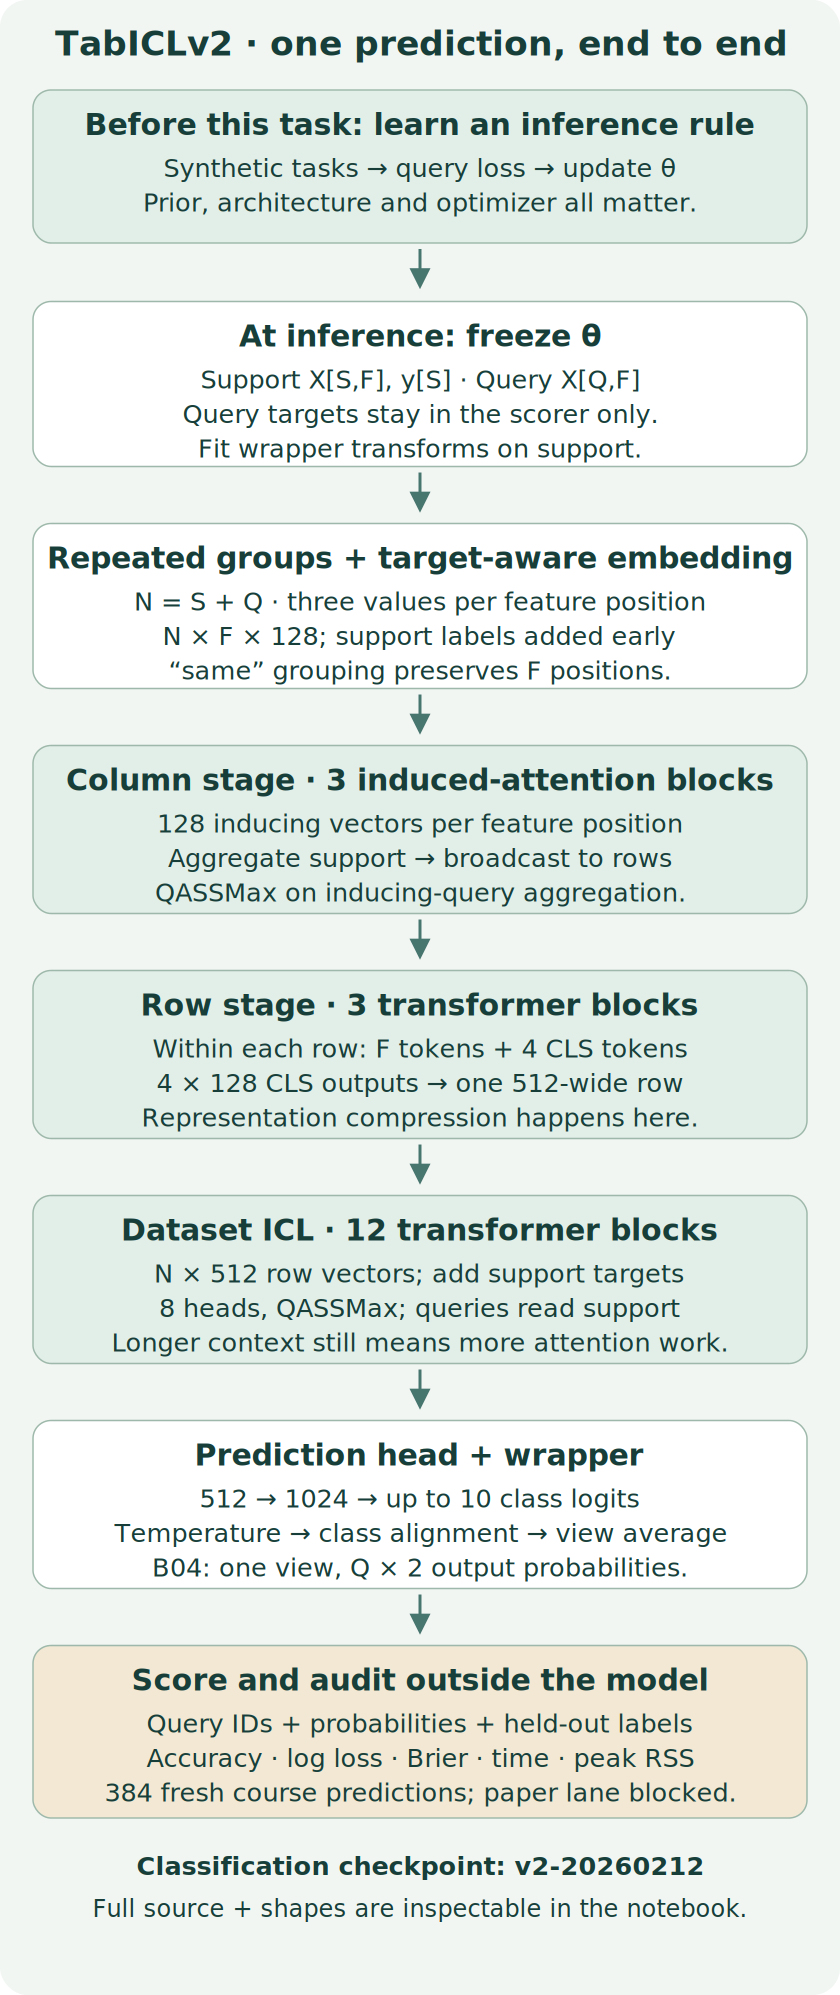

Let S be support rows, Q query rows, N=S+Q and F retained features. The pinned classification checkpoint uses 128-wide feature embeddings. Repeated three-feature grouping in `same` mode keeps F positions—it does **not** turn 30 features into 10 tokens. Support labels enter the feature embeddings early; unknown query labels are never inserted. Column attention uses 128 inducing vectors to gather support information and broadcast it back. Within each row, four CLS tokens collect feature information; concatenating their outputs yields 512 numbers per row. Twelve ICL blocks then let query rows read labeled support representations before a prediction head produces class probabilities. [Architecture and configuration](https://arxiv.org/html/2602.11139v1#A1.SS2) · [Pinned model source](https://avistian.github.io/relational/labs/sources/b04/upstream/src/tabicl/_model/tabicl.py).

**Worked shape trace:** S=128, Q=64, F=30 gives 192×30×128 feature embeddings, then 192×512 row vectors, then 64×2 probabilities for the two-class course task. Each row block handles 34 tokens including CLS. The checkpoint has a ten-class head; its wrapper selects the task's classes. These shapes omit table batches and ensemble views.

**Predict:** With 60 submitted features and the same support, which stage sees a wider input? The row stage does, before compression; ICL still sees512-wide row vectors. Constant-column filtering may reduce the actually retained width.

## 2. Compression saves a dimension, not every quadratic term

A cell-based row-attention stage repeats comparisons across feature positions. Moving dataset attention after row compression removes that factor from this stage. Inducing attention also replaces dense column-wise row comparisons with gather/broadcast operations. Row interaction still depends on feature width; dataset attention still depends on support length. Exact runtime depends on dimensions, masks, kernels, caching and preprocessing. A cost expression is a reason to measure, not a speed result. [TabICL architectural comparison](https://arxiv.org/html/2602.11139v1#S2.SS1) · [Inference implementation](https://avistian.github.io/relational/labs/sources/b04/upstream/src/tabicl/_model/attention.py).

**Small count:** For one query and 128 support rows, dataset attention needs 128 query-to-support scores per head after compression. Repeating this independently for 30 feature positions would need3,840 such scores. This isolates that operation only: it excludes support-to-support attention, projection work and representation construction. Flash-style kernels may avoid storing every score even when they perform the corresponding computation.

## 3. More context can dilute attention

Use a deliberately simple oracle: one anchor has logit 2 and each of n−1 distractors has logit 0. Its attention weight is `exp(2)/(exp(2)+n−1)`. It falls from about .881 at n=2 to .105 at n=64 even though the anchor's logit is unchanged. With an illustrative log(n) multiplier, the anchor weight becomes `n²/(n²+n−1)`, about .985 at n=64. This is exact arithmetic for chosen logits, not measured model accuracy.

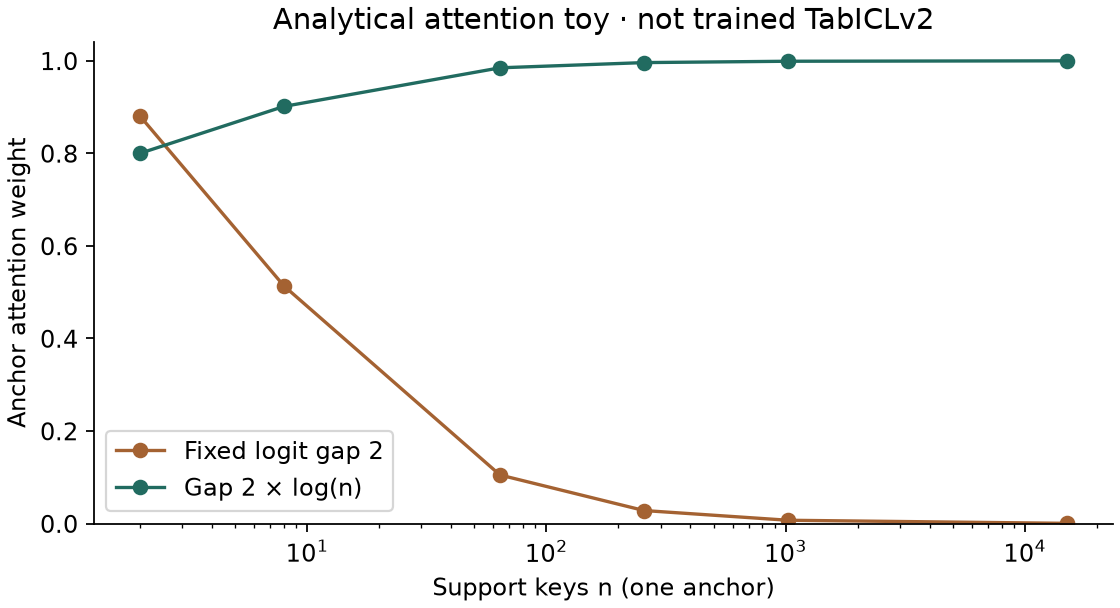

**Portable interaction:** change n and the logit gap in APPLY below; predict the attention weight before running.

TabICLv2 uses a learned, query-aware scaling rule before dot-product attention:

`q_scaled = q × base_MLP(log S) × [1 + tanh(gate_MLP(q))]`.

The base depends on support length; the gate depends on the projected query and modulates each coordinate. The final attention still uses softmax and the head-dimension normalization. The toy's fixed log multiplier is **not** this learned rule. A random-weight output/gradient check agrees with the pinned QASSMax implementation, but validates only the equation. [QASSMax definition](https://arxiv.org/html/2602.11139v1#S3) · [Complete query-scaling code](https://avistian.github.io/relational/labs/sources/b04/upstream/src/tabicl/_model/ssmax.py).

Normalized attention entropy is `−Σ p log(p)/log(n)`: 0 for a point mass, 1 for uniform attention when n>1. Neither low entropy nor a large anchor weight guarantees correct prediction; attending sharply to the wrong support row can be confidently wrong.

## 4. One intervention answers one question

**Retrieval check:** does more support guarantee higher accuracy? Explain before checking the defense rubric.

Holding a checkpoint fixed while increasing support changes both available evidence and context length. It tests an operating point; it does not isolate an architectural cause. Holding queries fixed helps paired comparison. Changing only attention scaling with fixed Q/K/V isolates a local numerical mechanism. Training matched attention variants under the same prior, updates and validation protocol addresses a different causal question. Swapping scaling in an already trained model is not equivalent to those matched pretrained variants.

The paper also changes its task prior and optimizer. Its ablations are the relevant source for attribution; a cross-version leaderboard cannot assign every gain to QASSMax. Preserve the difference between the paper's ablation checkpoints and its final production checkpoint. [Ablation study](https://arxiv.org/html/2602.11139v1#S7).

## 5. Measure the whole information path

We froze one checkpoint, all raw rows, a support ordering and 64 query IDs before running six course configurations. Nested supports contain 32/128/384 rows. Four 16-row query batches are compared with one 64-row call at support128. Query labels are only used by the independent scorer; transforms are fitted on support. These statements describe this worker and source configuration, not every release or deployment.

| Configuration | Support | Correct / 64 | Log loss | Predict seconds | Peak RSS MiB |
|---|---:|---:|---:|---:|---:|
| clean-32 | 32 | 61 | 0.174837 | 0.505 | 664.58 |
| clean-128 | 128 | 63 | 0.095919 | 0.609 | 677.20 |
| clean-384 | 384 | 63 | 0.044251 | 1.236 | 680.25 |
| batch-128 | 128 | 63 | 0.095919 | 1.975 | 677.64 |
| mean-128 | 128 | 62 | 0.132061 | 0.652 | 674.66 |
| indicator-128 | 128 | 62 | 0.127319 | 1.135 | 693.95 |


**Portable evidence:** the independent report below regenerates every table row.

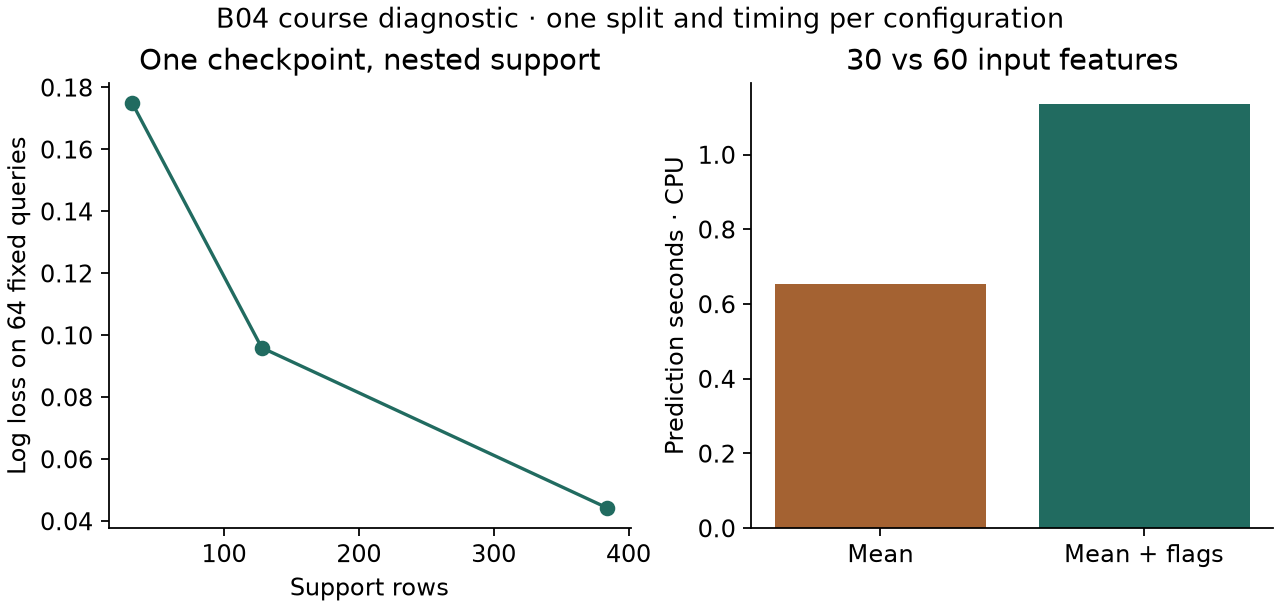

The smaller batches produce identical probabilities here but spend more prediction time repeating uncached work. They do not establish universal batch invariance. Memory is fresh-process peak CPU RSS including imports, model and data—not GPU memory or isolated attention storage. One timing observation per configuration cannot reproduce a hardware speedup claim. Three small support sizes cannot establish million-row scaling.

The separate missingness comparison masks 15% of values independently, fits column means on the 128 support rows, and either fills missing entries or also appends 30 flags. Accuracy stays 62/64 in both arms; log loss improves slightly with flags while Brier score worsens. Flags change the representation and computation. This single MCAR split does not establish robustness to changed missingness mechanisms.

The pinned release's DataFrame encoder constructs a numeric mean imputer; its ndarray route passes through that stage. B04 explicitly supplies its own support-fitted numeric imputation before either model arm. Do not generalize a README statement across input types or releases. Inspect the actual path and test it. [Pinned preprocessing](https://avistian.github.io/relational/labs/sources/b04/upstream/src/tabicl/_sklearn/preprocessing.py) · [Complete frozen protocol and raw results](https://avistian.github.io/relational/labs/b04-reproduction.md).

## 6. Full reproduction: a specific gate remains closed

**B04-TABICLV2-FIG3-ATTENTION-FADING is INCOMPLETE_SOURCE_PROTOCOL.** Figure 3 uses four negative clusters, one support anchor, 20 fixed nearby queries and three scaling variants. We archived the paper, figure assets, upstream source and author checkpoint inventories, but could not authenticate the exact generator/seeds/full grid, the three matched checkpoint identities or raw reference values. The released v2 classifier is sufficient for our course diagnostic, not for reconstructing all three original arms. [Original Figure 3](https://arxiv.org/html/2602.11139v1#S3.F3) · [Source gate](https://avistian.github.io/relational/labs/evidence/b04/source-gate.json).

The reproducibility operator refuses benchmark dispatch. No random substitute was labeled Figure 3. Full pretraining and the full benchmark suite are NOT_RUN. Current upstream includes pretraining/prior code, but its README says the released checkpoints did not use cautious weight decay, unlike paper v1's description. Preserve the discrepancy rather than silently combining recipes. [Pinned release notes](https://github.com/soda-inria/tabicl/blob/0dbff3ec8fc68c123c87af77b0ea8b25cd2d23f3/README.md).

The course diagnostic completed all six frozen configurations on CPU for **USD0 cloud/API spend**. All 384 prediction rows were independently scored; ten corruptions were rejected. Query-scaling source parity, saved-evidence replay, fresh checkpoint inference and original pretraining remain distinct evidence.

## 7. Build, check, defend

[Student notebook](https://avistian.github.io/relational/labs/b04-tabicl-scalable-icl.ipynb) · [Executed solution](https://avistian.github.io/relational/labs/solutions/b04-tabicl-scalable-icl.ipynb) · [Readable notebook](https://avistian.github.io/relational/labs/html/b04-tabicl-scalable-icl.html) · [Field guide](https://avistian.github.io/relational/reference/b04-scalable-icl.html).

Implement three live functions: stable attention with normalized entropy, support-only mean fitting, and transformation with optional missingness flags. Hand-check a two-key readout before using NumPy. Then use your functions to regenerate the distractor curve and reconstruct every diagnostic's transformed inputs; replay all predictions with the independent scorer. The solution includes the complete upstream model modules and classifier/preprocessor source for inspection, plus the exact diagnostic worker. The embedded packet runs offline; replay does not generate fresh model predictions.

**EXIT — write before opening the rubric:** Trace the 192×30 input through the model; explain what compression saves and what remains expensive; distinguish the three kinds of attention comparison above; interpret the batching and missingness findings; identify the evidence needed to unblock Figure 3. Propose one falsifier of your explanation and say how you would revise it. State the limitation of the small support sweep.

<details><summary>Defense rubric · reveal after writing</summary><p>A strong answer locates row compression after column embedding, preserves the512-wide ICL path, keeps query targets out of preprocessing/inference, distinguishes information changes from architecture interventions, gives both quality and resource measures, and refuses to infer paper parity or general missingness robustness. An acceptable falsifier might find that batch-dependent preprocessing changes predictions despite the model mask; then the wrapper must join the information-access contract.</p></details>

**Revisit after 1, 7 and 30 days:** reconstruct the shape trace without the figure, derive the anchor-weight formula, and design a different missingness failure case. Ask the agent follow-up questions or submit your defense for feedback. Author checks do not complete your learning: **PENDING_WRITTEN_DEFENSE**; the Year 5 exit gate remains separate.

**Next:** [B05](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b05) asks what changes when pretraining tasks come from real data and support is retrieved. [B12](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b12) revisits tabular ICL inside OpenRFM; [B18a](https://avistian.github.io/relational/plan/year-5-6-bridge.md#b18a) tests context and missingness changes. Primary reading: [TabICLv2 §§3–7](https://arxiv.org/html/2602.11139v1#S3), with the pinned release beside it.


In [ ]:
payload=base64.b64decode('...')
assert hashlib.sha256(payload).hexdigest()=='875472ec3665fe66b087b7c089b7d78fcde10ca3821308dee105b5db99c60711'
with zipfile.ZipFile(io.BytesIO(payload)) as z:z.extractall(workspace)
evidence=workspace/"labs/evidence/b04"
raw=json.loads((evidence/"inputs.json").read_text())
protocol=json.loads((evidence/"diagnostic-protocol.json").read_text())
records=[json.loads((evidence/(c["name"]+".json")).read_text()) for c in protocol["configs"]]

## TODO · attention_readout

Implement stable dot-product attention, weighted value readout and entropy/log(n). Handle n=1. Hand oracle: logits log(3),0 and values2,10 should yield readout4.

In [ ]:
def attention_readout(query, keys, values, scale=1.0):
    raise NotImplementedError("Implement attention_readout")

## TODO · fit_missingness

Fit column means using only observed support entries. Freeze zero for entirely missing columns. Reject infinities and empty training data.

In [ ]:
def fit_missingness(support):
    raise NotImplementedError("Implement fit_missingness")

## TODO · transform_missingness

Apply frozen means without refitting. Optionally append one missing flag per original feature in the same order. Preserve the input arrays.

In [ ]:
def transform_missingness(rows, means, indicators=False):
    raise NotImplementedError("Implement transform_missingness")

## CHECK · independent hand and intervention oracles

In [ ]:
def check_functions(attention_readout, fit_missingness, transform_missingness):
    # Scalar hand oracle: logits log(3),0 produce weights .75,.25.
    out,p,h=attention_readout([1.],[[np.log(3.)],[0.]],[[2.],[10.]])
    np.testing.assert_allclose(p,[.75,.25],atol=1e-14)
    np.testing.assert_allclose(out,[4.],atol=1e-14)
    assert abs(h-(-.75*np.log(.75)-.25*np.log(.25))/np.log(2))<1e-14
    _,p2,h2=attention_readout([1.],[[np.log(3.)+10000],[10000]],[[2.],[10.]])
    np.testing.assert_allclose(p2,p,atol=1e-12)
    _,u,hu=attention_readout([0.],[[1.],[8.],[9.]],np.eye(3))
    np.testing.assert_allclose(u,[1/3]*3);assert abs(hu-1)<1e-14
    assert attention_readout([1.],[[2.]],[[3.]])[2]==0
    # Appending distractors lowers anchor mass; log(n) scaling changes that calculation.
    mass=[]
    for n in [2,8,64]:
        k=np.zeros((n,1));k[0]=2
        _,a,_=attention_readout([1.],k,np.eye(n))
        _,b,_=attention_readout([1.],k,np.eye(n),np.log(n))
        assert abs(a[0]-np.exp(2)/(np.exp(2)+n-1))<1e-13
        assert abs(b[0]-n*n/(n*n+n-1))<1e-13
        mass.append(a[0])
    assert mass[0]>mass[1]>mass[2]
    s=np.array([[1.,np.nan,np.nan],[3.,4.,np.nan],[np.nan,8.,np.nan]])
    before=s.copy();mu=fit_missingness(s)
    np.testing.assert_equal(s,before);np.testing.assert_equal(mu,[2.,6.,0.])
    q=np.array([[np.nan,100.,np.nan],[99.,np.nan,1.]])
    z=transform_missingness(q,mu,True)
    np.testing.assert_equal(z,[[2,100,0,1,0,1],[99,6,1,0,1,0]])
    np.testing.assert_equal(mu,[2,6,0]);np.testing.assert_equal(fit_missingness(s),mu)
    # Changing query values cannot change the learned support means.
    q[0,1]=-1e6;assert transform_missingness(q,mu)[1,1]==6
    cases=[lambda:fit_missingness([[np.inf]]),lambda:fit_missingness([]),
           lambda:transform_missingness([[1,2]],[0]),
           lambda:attention_readout([1],[],[]),
           lambda:attention_readout([1],[[float('nan')]],[[1]]),
           lambda:attention_readout([1],[[1]],[[1]],float('inf'))]
    for f in cases:
        try:f()
        except ValueError:pass
        else:raise AssertionError('Malformed input accepted')
    return {'status':'PASS','oracles':'analytical attention, entropy endpoints, distractors, support-only means, empty columns, invalid inputs'}

In [ ]:
print(check_functions(attention_readout,fit_missingness,transform_missingness))

## APPLY · derive the distractor curve using your attention function

Before execution, predict whether entropy and anchor mass rise or fall. This is a numerical operator experiment with chosen Q/K/V, not QASSMax inference. Change the gap to0 and explain both curves.

In [ ]:
gap=2.0
for n in [2,8,64,256,1024,15001]:
    keys=np.zeros((n,1));keys[0]=gap
    values=np.zeros((n,1));values[0]=1
    for scale in [1.0,np.log(n)]:
        out,weights,entropy=attention_readout([1.],keys,values,scale)
        expected=1/(1+(n-1)*np.exp(-gap*scale))
        assert abs(out[0]-expected)<1e-12
        print(n,round(scale,4),round(weights[0],6),round(entropy,6))

## APPLY · your preprocessing reconstructs every measured configuration

No model runs here. Check frozen means for all six settings and show that changing query values cannot refit support means. Explicit missingness flags submit60 columns; the source wrapper may remove constant ones.

In [ ]:
X=np.array(raw["X"]);missing=np.array(raw["missing_mask"]);query_ids=raw["query_ids"]
for record in records:
    config=record["config"];table=X.copy()
    if config["missing"]:table[missing]=np.nan
    support=table[record["support_ids"]];query=table[query_ids]
    means=fit_missingness(support)
    np.testing.assert_allclose(means,record["means"],rtol=1e-12,atol=1e-12)
    xs=transform_missingness(support,means,config["indicators"])
    xq=transform_missingness(query,means,config["indicators"])
    assert xs.shape[1]==record["transformed_features"] and np.isfinite(xq).all()
    print(config["name"],xs.shape,xq.shape)

## PROVIDED · independent scalar scoring and source gate

This code does not import your functions. It independently validates identities, means, pairing and probabilities, then regenerates all metrics. The source audit authenticates archived bytes and reports exactly what the bounded search did not recover.

In [ ]:
def audit_records(raw,protocol,records):
    expected=protocol['configs'];assert len(records)==len(expected)==6
    assert {r['config']['name'] for r in records}=={c['name'] for c in expected}
    by_name={r['config']['name']:r for r in records};rows=[]
    query=raw['query_ids'];support=raw['support_order'];assert len(query)==64 and len(set(query))==64
    assert len(set(support))==len(support) and not set(support)&set(query)
    X,y,mask=raw['X'],raw['y'],raw['missing_mask'];F=len(X[0]);assert len(X)==len(y)==len(mask)==569 and F==30
    for c in expected:
        r=by_name[c['name']];assert r['config']==c
        assert r['inputs_sha256']==protocol['inputs_sha256'] and r['checkpoint_sha256']==protocol['checkpoint']['sha256']
        assert r['query_ids']==query and r['support_ids']==support[:c['support_n']]
        assert r['classes']==[0,1] and len(r['probabilities'])==len(query)
        assert r['transformed_features']==F*(2 if c['indicators'] else 1)
        assert len(r['means'])==F
        for j in range(F):
            values=[X[i][j] for i in r['support_ids'] if not (c['missing'] and mask[i][j])]
            mu=math.fsum(values)/len(values) if values else 0.
            assert math.isclose(mu,r['means'][j],rel_tol=1e-12,abs_tol=1e-12)
        correct=0;loss=0.;brier=0.
        for i,p in zip(query,r['probabilities']):
            assert len(p)==2 and all(math.isfinite(v) and 0<=v<=1 for v in p)
            assert abs(sum(p)-1)<2e-6
            pred=max(range(2),key=lambda k:p[k]);correct+=int(pred==y[i])
            loss-=math.log(max(1e-15,min(1.,p[y[i]])));brier+=(p[1]-y[i])**2
        for field in ['fit_seconds','predict_seconds','peak_process_rss_mib']:assert math.isfinite(r[field]) and r[field]>0
        rows.append(dict(name=c['name'],support_n=c['support_n'],features=r['transformed_features'],correct=correct,total=len(query),accuracy=correct/len(query),log_loss=loss/len(query),brier=brier/len(query),fit_seconds=r['fit_seconds'],predict_seconds=r['predict_seconds'],peak_process_rss_mib=r['peak_process_rss_mib']))
    delta=max(abs(a-b) for p,q in zip(by_name['clean-128']['probabilities'],by_name['batch-128']['probabilities']) for a,b in zip(p,q))
    return dict(status='COMPLETE_COURSE_DIAGNOSTIC',rows=rows,prediction_rows=sum(x['total'] for x in rows),predict_calls=9,batch_max_abs_delta=delta,batch_atol=protocol['query_batch_atol'],batch_within_tolerance=delta<=protocol['query_batch_atol'],paper_parity='NOT_ESTABLISHED',long_context_scaling='NOT_TESTED_BY_THIS_SMALL_SWEEP')

In [ ]:
def source_gate(root):
    p=Path(root);manifest=json.loads((p/'manifest.json').read_text())
    for item in manifest['files']:
        data=(p/item['file']).read_bytes()
        assert hashlib.sha256(data).hexdigest()==item['sha256'],item['file']
        assert len(data)==item['bytes']
    # Inspect actual immutable archive rather than trusting a prose absence claim.
    with tarfile.open(p/'upstream.tar.gz') as t:
        files={str(Path(*Path(x.name).parts[1:])):t.extractfile(x).read() for x in t.getmembers() if x.isfile()}
    matches=[name for name,data in files.items() if name.endswith(('.py','.sh','.md','.ipynb')) and re.search(rb'needle|haystack',data,re.I)]
    assert not matches, 'New candidate Figure 3 source needs review'
    hf=json.loads((p/'hf-v2.json').read_text());weights=[x['rfilename'] for x in hf['siblings'] if x['rfilename'].endswith('.ckpt')]
    assert weights==['tabicl-classifier-v1-20250208.ckpt','tabicl-classifier-v1.1-20250506.ckpt','tabicl-classifier-v2-20260212.ckpt','tabicl-regressor-v2-20260212.ckpt']
    assert b'use_cautious_wd' in files['README.md']
    missing=['exact generator parameters and seeds','ordered complete context grid and input rows','No-SSMax and SSMax matched Figure-3 checkpoint identities','Figure-3 QASSMax checkpoint identity','raw probabilities/entropy reference and exact aggregation implementation']
    return dict(experiment='B04-TABICLV2-FIG3-ATTENTION-FADING',status='INCOMPLETE_SOURCE_PROTOCOL',benchmark_runs=0,commit=manifest['commit'],authenticated_files=len(manifest['files']),archive_files=len(files),figure_source_matches=matches,released_weights=weights,missing=missing,scope='Pinned complete upstream archive, paper v1 and Figure 3 assets, author HF repositories, first two GitHub issue pages (165 entries at retrieval); not proof of global unavailability',pretraining='NOT_RUN',full_benchmark='NOT_RUN')

In [ ]:
assert hashlib.sha256((evidence/"inputs.json").read_bytes()).hexdigest()==protocol["inputs_sha256"]
report={"source":source_gate(workspace/"labs/sources/b04"),"diagnostic":audit_records(raw,protocol,records)}
assert report["source"]==json.loads((evidence/"source-gate.json").read_text())
assert report["diagnostic"]==json.loads((evidence/"diagnostic-audit.json").read_text())
Path("b04-report.json").write_text(json.dumps(report,indent=2)+"\n")
print(json.dumps(report,indent=2))

## CHECK · execute complete archived audit with ten corruptions

Your live functions already passed the earlier checks. This separate subprocess checks the original evidence and archive independently.

In [ ]:
import subprocess,sys
verified=subprocess.run([sys.executable,str(workspace/"labs/_verify_b04.py")],cwd=workspace,check=True,capture_output=True,text=True)
print("Complete independent archive replay and mutation checks PASS")

## EXIT · defend the result

Trace192×30 inputs to64×2 predictions. Compare fixed-checkpoint support sweeps, fixed-Q/K/V operator interventions and matched pretrained ablations. Explain the quality/resource tradeoffs, query-batching limits and exact Figure3 blockers. Give one falsifier and a revision condition. Revisit after1/7/30 days and ask the teaching agent for feedback.

In [ ]:
submission={"shape_trace":"","cost_scope":"","three_comparisons":"","batching_limit":"","missingness_tradeoff":"","figure3_blockers":"","falsifier":"","revision_condition":"","status":"PENDING_WRITTEN_DEFENSE"}
Path("b04-submission.json").write_text(json.dumps(submission,indent=2)+"\n")

## Source appendix · complete visible computation

The following are the unmodified upstream model modules and the classifier/preprocessor used by the fresh diagnostic. They are provided for inspection, not executed as notebook globals. The complete repository archive and license are embedded in the packet. Start with `tabicl.py` for composition, `embedding.py` for grouping and support masking, `interaction.py` for CLS compression, `learning.py` for dataset ICL, and `ssmax.py` for the learned scaling equation. Other modules expose attention, residual/FFN blocks, RoPE and inference management.

Source commit: `0dbff3ec8fc68c123c87af77b0ea8b25cd2d23f3`.

### src/tabicl/_model/__init__.py

```python
"""Private. Users should not import from this subpackage.

``TabICL`` is wrapped by :class:`tabicl.TabICLClassifier`,
:class:`tabicl.TabICLRegressor`, and :class:`tabicl.TabICLForecaster`.
``InferenceConfig`` is re-exported at :class:`tabicl.InferenceConfig`.
"""

from .tabicl import TabICL
from .inference_config import InferenceConfig

```

### src/tabicl/_model/_cgroup_memory.py

```python
"""Cgroup-aware CPU memory headroom for inference offload decisions.

``psutil.virtual_memory().available`` is the host's free RAM. The real cap for a
container is ``limit - usage`` on this process's cgroup, which is often not
``/sys/fs/cgroup/memory.max`` (Kubernetes, ``docker run --cgroupns=host``).

Look up the path in ``/proc/self/cgroup``, resolve the controller mount from
``/proc/self/mountinfo``, walk from there to the mount root, and return the
smallest ``limit - usage`` among ancestors that have a real limit.

On hybrid hosts the ``0::`` v2 line can coexist with a v1 ``memory:`` line.
If the v2 walk finds no cap (the memory controller still lives on v1), the
v1 files are used next.

Never raises: a memory estimate is not worth crashing inference over.
"""

from __future__ import annotations

from pathlib import Path

import psutil

_PROC_CGROUP = Path("/proc/self/cgroup")
_PROC_MOUNTINFO = Path("/proc/self/mountinfo")
_V2_ROOT = Path("/sys/fs/cgroup")
_V1_ROOT = Path("/sys/fs/cgroup/memory")


def _parse_bytes(raw: str) -> int | None:
    token = raw.split()[0] if raw.split() else ""
    if token == "max":
        return None
    try:
        return int(token)
    except ValueError:
        return None


def _read_bytes(path: Path) -> int | None:
    try:
        return _parse_bytes(path.read_text())
    except OSError:
        return None


def _headroom_at(directory: Path, limit_name: str, usage_name: str, physical: int) -> int | None:
    limit = _read_bytes(directory / limit_name)
    if limit is None or limit <= 0 or limit >= physical:
        return None
    usage = _read_bytes(directory / usage_name)
    if usage is None:
        # Finite cap, unknown usage: do not pretend the cgroup is empty.
        return 0
    return max(0, limit - usage)


def _min_headroom_along_ancestors(
    start: Path, stop: Path, limit_name: str, usage_name: str, physical: int
) -> int | None:
    """Smallest ``limit - usage`` on ``start`` and its parents up to ``stop``.

    Levels with no file, ``"max"``, a non-positive limit, or a limit at or
    above ``physical`` are skipped. Returns None if no ancestor has a real cap.
    The walk stays under ``stop`` and is bounded so a malformed tree cannot
    loop.
    """
    best: int | None = None
    path = start
    for _ in range(64):
        try:
            path.relative_to(stop)
        except ValueError:
            break
        headroom = _headroom_at(path, limit_name, usage_name, physical)
        if headroom is not None:
            best = headroom if best is None else min(best, headroom)
        if path == stop or path.parent == path:
            break
        path = path.parent
    return best


def _process_cgroup_relpath(proc_cgroup: Path, *, v2: bool) -> str | None:
    """Relative cgroup path for this process, from a ``cgroup`` proc file.

    For v2, that is the suffix of the ``0::/foo`` line. For v1, the path on
    the ``memory:`` controller line (``4:memory:/foo``). Returns None if the
    file is unreadable or has no matching line.
    """
    try:
        text = proc_cgroup.read_text()
    except OSError:
        return None
    for line in text.splitlines():
        if v2:
            if line.startswith("0::"):
                return line[3:]
            continue
        fields = line.split(":", 2)
        if len(fields) == 3 and "memory" in fields[1].split(","):
            return fields[2]
    return None


def _unescape_mountinfo(value: str) -> str:
    """Decode octal escapes used in mountinfo path fields (space is ``\\040``)."""
    return (
        value.replace("\\040", " ")
        .replace("\\011", "\t")
        .replace("\\012", "\n")
        .replace("\\134", "\\")
    )


def _parse_mountinfo(
    text: str, *, fstype: str, controller: str | None = None
) -> list[tuple[Path, str]]:
    """Return ``(mountpoint, hierarchy_root)`` pairs from a mountinfo dump.

    ``hierarchy_root`` is field 4: the path inside the cgroup filesystem that
    is mounted. Hierarchy-root mounts (field 4 ``/``) come first so a
    ``/proc/self/cgroup`` path can be joined onto them directly. For cgroup
    v1, ``controller`` must appear in the super-block options (``memory`` in
    ``rw,memory`` or ``rw,cpu,memory``).
    """
    found: list[tuple[Path, str]] = []
    for line in text.splitlines():
        parts = line.split()
        try:
            hyphen = parts.index("-")
        except ValueError:
            continue
        if len(parts) < 5 or hyphen + 1 >= len(parts) or parts[hyphen + 1] != fstype:
            continue
        if controller is not None:
            super_opts = parts[hyphen + 3] if hyphen + 3 < len(parts) else ""
            if controller not in super_opts.split(","):
                continue
        found.append((Path(_unescape_mountinfo(parts[4])), _unescape_mountinfo(parts[3])))
    found.sort(key=lambda item: item[1] != "/")
    return found


def _read_text(path: Path) -> str:
    try:
        return path.read_text()
    except OSError:
        return ""


def _under_mount(mountpoint: Path, mount_root: str, rel: str) -> Path | None:
    """Directory for ``rel`` on this mount, or None if ``rel`` is outside it.

    ``mount_root`` is mountinfo field 4. A bind-mount of ``/system.slice`` at
    ``mountpoint`` maps ``/system.slice/foo`` to ``mountpoint/foo``.
    """
    rel_parts = [p for p in rel.split("/") if p and p != "."]
    root_parts = [p for p in mount_root.split("/") if p and p != "."]
    # A ".." segment must not walk above the mount. Stay at the mount root.
    if any(p == ".." for p in rel_parts + root_parts):
        return mountpoint
    # Bind-mount of /system.slice cannot serve a process in /user.slice.
    if rel_parts[: len(root_parts)] != root_parts:
        return None
    suffix = rel_parts[len(root_parts) :]
    return mountpoint.joinpath(*suffix) if suffix else mountpoint


def _controller_mounts(
    explicit: Path | None,
    mountinfo_text: str,
    *,
    fstype: str,
    default: Path,
    controller: str | None = None,
) -> list[tuple[Path, str]]:
    """Mounts for a controller: explicit test root, else mountinfo, else ``default``."""
    if explicit is not None:
        return [(explicit, "/")]
    return _parse_mountinfo(mountinfo_text, fstype=fstype, controller=controller) or [
        (default, "/")
    ]


def _headroom_on_mounts(
    rel: str,
    mounts: list[tuple[Path, str]],
    limit_name: str,
    usage_name: str,
    physical: int,
) -> int | None:
    """Tightest ``limit - usage`` among mounts that contain ``rel``."""
    min_headroom: int | None = None
    for mountpoint, mount_root in mounts:
        start = _under_mount(mountpoint, mount_root, rel)
        if start is None:
            continue
        headroom = _min_headroom_along_ancestors(
            start, mountpoint, limit_name, usage_name, physical
        )
        if headroom is not None:
            min_headroom = headroom if min_headroom is None else min(min_headroom, headroom)
    return min_headroom


def _cgroup_memory_headroom(
    *,
    proc_cgroup: Path = _PROC_CGROUP,
    proc_mountinfo: Path = _PROC_MOUNTINFO,
    v2_root: Path | None = None,
    v1_root: Path | None = None,
    physical_bytes: int | None = None,
) -> int | None:
    """Bytes this process may still allocate under its cgroup, or None if unlimited.

    Reads ``proc_cgroup`` (``/proc/self/cgroup`` by default) and joins the
    relative path onto the controller mount from ``proc_mountinfo`` (or
    ``v2_root`` / ``v1_root`` when tests inject a fake sysfs tree). v2 uses
    ``memory.max`` / ``memory.current``; v1 uses ``memory.limit_in_bytes`` /
    ``memory.usage_in_bytes``. Parents are walked to the mount and the
    smallest ``limit - usage`` is returned.

    A ``0::`` v2 line is not proof that the memory controller lives on v2.
    Hybrid hosts list both hierarchies; if the v2 walk finds no cap, the v1
    ``memory:`` entry is inspected next.

    ``"max"``, a v1 ~2**63 unlimited sentinel, and any limit at or above
    physical RAM are treated as no cap at that level. If ``proc_cgroup`` is
    missing, the v2/v1 root files are tried (Docker's private cgroup namespace).

    Never raises: any error falls through to None so callers can keep using
    psutil's host figure.
    """
    try:
        physical = physical_bytes if physical_bytes is not None else psutil.virtual_memory().total
        mountinfo_text = _read_text(proc_mountinfo)
        rel_v2 = _process_cgroup_relpath(proc_cgroup, v2=True)
        rel_v1 = _process_cgroup_relpath(proc_cgroup, v2=False)

        if rel_v2 is not None:
            headroom = _headroom_on_mounts(
                rel_v2,
                _controller_mounts(
                    v2_root, mountinfo_text, fstype="cgroup2", default=_V2_ROOT
                ),
                "memory.max",
                "memory.current",
                physical,
            )
            if headroom is not None:
                return headroom
        if rel_v1 is not None:
            headroom = _headroom_on_mounts(
                rel_v1,
                _controller_mounts(
                    v1_root,
                    mountinfo_text,
                    fstype="cgroup",
                    default=_V1_ROOT,
                    controller="memory",
                ),
                "memory.limit_in_bytes",
                "memory.usage_in_bytes",
                physical,
            )
            if headroom is not None:
                return headroom
        if rel_v2 is not None or rel_v1 is not None:
            # A hierarchy line existed but published no cap ("max", v1 sentinel).
            return None
        # /proc/self/cgroup missing: last try, Docker private-namespace root files.
        v2 = _controller_mounts(v2_root, mountinfo_text, fstype="cgroup2", default=_V2_ROOT)[0][0]
        v1 = _controller_mounts(
            v1_root, mountinfo_text, fstype="cgroup", default=_V1_ROOT, controller="memory"
        )[0][0]
        for root, limit_name, usage_name in (
            (v2, "memory.max", "memory.current"),
            (v1, "memory.limit_in_bytes", "memory.usage_in_bytes"),
        ):
            headroom = _headroom_at(root, limit_name, usage_name, physical)
            if headroom is not None:
                return headroom
        return None
    except Exception:
        return None

```

### src/tabicl/_model/attention.py

```python
from __future__ import annotations
from contextlib import contextmanager
from typing import Optional, Tuple, Union

import torch
from torch import Tensor, nn
from torch.nn import functional as F

from .rope import RotaryEmbedding
from .kv_cache import KVCacheEntry

try:
    from flash_attn_interface import flash_attn_varlen_func as flash_attn3

    HAS_FLASH_ATTN3 = True
except ImportError:
    HAS_FLASH_ATTN3 = False

_use_flash_attn3 = True


@contextmanager
def flash_attn3_toggle(enabled: bool):
    """Context manager to temporarily enable or disable Flash Attention 3.

    Used by ``InferenceManager._run_forward()`` in ``inference.py`` to control
    whether Flash Attention 3 is used during each forward pass based on the
    ``use_fa3`` configuration.
    """
    global _use_flash_attn3
    old = _use_flash_attn3
    _use_flash_attn3 = enabled
    try:
        yield
    finally:
        _use_flash_attn3 = old


def set_flash_attn3_enabled(enabled: bool):
    """Globally enable or disable Flash Attention 3 for this process.

    Used by the pre-training ``Trainer`` (``--use_flash_attn3``): FA3 runs attention
    in fp16, so the TabICLv2 recipe enables it only for stages 2 and 3.
    """
    global _use_flash_attn3
    _use_flash_attn3 = enabled


def sdpa_with_flattened_batch(
    q: Tensor,
    k: Tensor,
    v: Tensor,
    attn_mask: Optional[Tensor] = None,
    dropout_p: float = 0.0,
    ssmax_layer: Optional[nn.Module] = None,
) -> Tensor:
    """Applies scaled dot-product attention with flattened batch dimensions.

    This function handles arbitrary batch dimensions by flattening them before
    applying PyTorch's ``scaled_dot_product_attention`` and then reshaping the
    output back to the original shape. This flattening is necessary to properly
    trigger Flash Attention.

    Parameters
    ----------
    q : Tensor
        Query tensor of shape (..., nh, tgt_len, hs) where:

        - ... represents arbitrary batch dimensions
        - nh is the number of attention heads
        - tgt_len is the target sequence length
        - hs is the head size (embedding dimension per head)

    k : Tensor
        Key tensor of shape (..., nh, src_len, hs) with matching batch dimensions.

    v : Tensor
        Value tensor of shape (..., nh, src_len, hs) with matching batch dimensions.

    attn_mask : Optional[Tensor], default=None
        Attention mask of shape (..., nh, tgt_len, src_len).

    dropout_p : float, default=0.0
        Dropout probability applied to attention weights.

    ssmax_layer : Optional[nn.Module], default=None
        If provided, applies scalable softmax (SSMax) scaling to queries before
        attention computation.

    Returns
    -------
    Tensor
        Attention output tensor of shape (..., nh, tgt_len, hs) preserving the
        original batch dimensions of the input.
    """

    q_shape = q.shape
    q = q.reshape(-1, *q.shape[-3:])
    k = k.reshape(-1, *k.shape[-3:])
    v = v.reshape(-1, *v.shape[-3:])
    if attn_mask is not None:
        attn_mask = attn_mask.reshape(-1, *attn_mask.shape[-3:])

    if ssmax_layer is not None:
        src_len = k.size(-2)
        q = ssmax_layer(q, src_len)

    # FlashAttn3 doesn't support dropout and custom attention mask
    if HAS_FLASH_ATTN3 and _use_flash_attn3 and q.is_cuda and attn_mask is None and dropout_p == 0.0:
        # FlashAttention only supports fp16, bf16, and fp8_e4m3
        # Convert to bf16 if needed, then convert back to original dtype
        orig_dtype = q.dtype
        if orig_dtype not in (torch.float16, torch.bfloat16):
            fa_dtype = torch.float16
        else:
            fa_dtype = orig_dtype

        flat_bs, nheads, seqlen_q, headdim = q.shape
        seqlen_k = k.shape[-2]
        q_fa = q.transpose(1, 2).reshape(flat_bs * seqlen_q, nheads, headdim).contiguous().to(fa_dtype)
        k_fa = k.transpose(1, 2).reshape(flat_bs * seqlen_k, nheads, headdim).contiguous().to(fa_dtype)
        v_fa = v.transpose(1, 2).reshape(flat_bs * seqlen_k, nheads, headdim).contiguous().to(fa_dtype)
        cu_seqlens_q = torch.arange(0, (flat_bs + 1) * seqlen_q, seqlen_q, dtype=torch.int32, device=q.device)
        cu_seqlens_k = torch.arange(0, (flat_bs + 1) * seqlen_k, seqlen_k, dtype=torch.int32, device=q.device)
        out = flash_attn3(q_fa, k_fa, v_fa, cu_seqlens_q, cu_seqlens_k, seqlen_q, seqlen_k)
        out = out.view(flat_bs, seqlen_q, nheads, headdim).transpose(1, 2).to(orig_dtype)
    else:
        out = F.scaled_dot_product_attention(q, k, v, attn_mask, dropout_p)

    return out.view(q_shape)


def multi_head_attention_forward(
    query: Tensor,
    num_heads: int,
    in_proj_weight: Tensor,
    in_proj_bias: Tensor,
    dropout_p: float,
    out_proj_weight: Tensor,
    out_proj_bias: Tensor,
    key: Optional[Tensor] = None,
    value: Optional[Tensor] = None,
    cached_kv: Optional[KVCacheEntry] = None,
    training: bool = True,
    key_padding_mask: Optional[Tensor] = None,
    attn_mask: Optional[Tensor] = None,
    rope: Optional[RotaryEmbedding] = None,
    ssmax_layer: Optional[nn.Module] = None,
    need_kv: bool = False,
) -> Union[Tensor, Tuple[Tensor, Tensor, Tensor]]:
    """Multi-head attention with support for rotary position embeddings.

    Parameters
    ----------
    query : Tensor
        Query tensor of shape (..., tgt_len, embed_dim).

    num_heads : int
        Number of attention heads.

    in_proj_weight : Tensor
        Combined weight matrix for Q, K, V input projections.

    in_proj_bias : Tensor
        Combined bias vector for input projections.

    dropout_p : float
        Dropout probability applied to attention weights.

    out_proj_weight : Tensor
        Output projection weight matrix.

    out_proj_bias : Tensor
        Output projection bias vector.

    key : Optional[Tensor], default=None
        Key tensor of shape (..., src_len, embed_dim).
        Required when ``cached_kv`` is None.

    value : Optional[Tensor], default=None
        Value tensor of shape (..., src_len, embed_dim).
        Required when ``cached_kv`` is None.

    cached_kv : Optional[KVCacheEntry], default=None
        Pre-computed key and value projections for caching. When provided:

        - key and value parameters are ignored
        - Only query projection is computed
        - cached_kv.key shape: (..., num_heads, src_len, head_dim)
        - cached_kv.value shape: (..., num_heads, src_len, head_dim)
        - RoPE is applied only to queries (keys should already have RoPE applied)

    training : bool, default=True
        Whether the model is in training mode (affects dropout).

    key_padding_mask : Optional[Tensor], default=None
        Mask of shape (..., src_len) that identifies padding elements
        in the key sequence to be ignored:

        - For binary masks: True values indicate positions to ignore.
        - For float masks: Values are directly added to attention scores.

    attn_mask : Optional[Tensor], default=None
        Attention mask of shape (tgt_len, src_len) or
        (..., num_heads, tgt_len, src_len).

    rope : Optional[RotaryEmbedding]
        Rotary positional encoding.

    ssmax_layer : Optional[nn.Module], default=None
        If provided, applies scalable softmax (SSMax) scaling to queries before
        attention computation.

    need_kv : bool, default=False
        If True and ``cached_kv`` is None, also returns the computed K and V
        projections along with the attention output. Useful for caching K/V for
        subsequent calls.

    Returns
    -------
    Union[Tensor, Tuple[Tensor, Tensor, Tensor]]
        If ``need_kv`` is False or ``cached_kv`` is provided:
            Attention output tensor of shape (..., tgt_len, embed_dim).
        If ``need_kv`` is True and ``cached_kv`` is None:
            Tuple of (attn_output, k, v) where:

            - attn_output: shape (..., tgt_len, embed_dim)
            - k: shape (..., num_heads, src_len, head_dim)
            - v: shape (..., num_heads, src_len, head_dim)
    """

    # Extract shape information, supporting arbitrary batch dimensions
    *batch_shape, tgt_len, embed_dim = query.shape
    head_dim = embed_dim // num_heads
    assert head_dim * num_heads == embed_dim, f"embed_dim {embed_dim} not divisible by num_heads {num_heads}"

    if cached_kv is None:
        # Standard: project Q, K, V jointly
        if key is None or value is None:
            raise ValueError("key and value must be provided when cached_kv is None")
        src_len = key.shape[-2]
        assert key.shape == value.shape, f"key shape {key.shape} does not match value shape {value.shape}"
        q, k, v = F._in_projection_packed(query, key, value, in_proj_weight, in_proj_bias)
        q = q.view(*batch_shape, tgt_len, num_heads, head_dim).transpose(-3, -2)
        k = k.view(*batch_shape, src_len, num_heads, head_dim).transpose(-3, -2)
        v = v.view(*batch_shape, src_len, num_heads, head_dim).transpose(-3, -2)
        if rope is not None:
            q = rope.rotate_queries_or_keys(q)
            k = rope.rotate_queries_or_keys(k)
    else:
        # Use cached K/V, project Q only
        k, v = cached_kv.key, cached_kv.value
        src_len = k.shape[-2]
        q_proj_weight = in_proj_weight[:embed_dim]
        q_proj_bias = in_proj_bias[:embed_dim] if in_proj_bias is not None else None
        q = F.linear(query, q_proj_weight, q_proj_bias)
        q = q.view(*batch_shape, tgt_len, num_heads, head_dim).transpose(-3, -2)
        if rope is not None:
            q = rope.rotate_queries_or_keys(q)

    # Disable dropout during evaluation
    if not training:
        dropout_p = 0.0

    # Process attention mask
    correct_2d_shape = (tgt_len, src_len)
    correct_nd_shape = (*batch_shape, num_heads, tgt_len, src_len)
    if attn_mask is not None:
        if attn_mask.dim() == 2:
            if attn_mask.shape != correct_2d_shape:
                raise ValueError(f"2D attn_mask should have shape {correct_2d_shape}, but got {attn_mask.shape}")
            attn_mask = attn_mask.expand(*batch_shape, num_heads, tgt_len, src_len)
        elif attn_mask.dim() == len(correct_nd_shape):
            if attn_mask.shape != correct_nd_shape:
                raise ValueError(
                    f"{len(correct_nd_shape)}D attn_mask should have shape {correct_nd_shape}, "
                    f"but got {attn_mask.shape}"
                )
        else:
            raise ValueError(f"attn_mask must be 2D or {len(correct_nd_shape)}D, got {attn_mask.dim()}D")

    # Process key padding mask
    if key_padding_mask is not None:
        if key_padding_mask.shape != (*batch_shape, src_len):
            raise ValueError(
                f"key_padding_mask should have shape {(*batch_shape, src_len)}, but got {key_padding_mask.shape}"
            )
        key_padding_mask = key_padding_mask.view(*batch_shape, 1, 1, src_len).expand(
            *batch_shape, num_heads, tgt_len, src_len
        )

        if attn_mask is None:
            attn_mask = key_padding_mask
        else:
            attn_mask = attn_mask + key_padding_mask

    attn_output = sdpa_with_flattened_batch(
        q, k, v, attn_mask, dropout_p, ssmax_layer=ssmax_layer
    )  # (..., nh, tgt_len, hs)

    # Reshape and project output
    attn_output = attn_output.transpose(-3, -2).contiguous().view(*batch_shape, tgt_len, embed_dim)
    attn_output = F.linear(attn_output, out_proj_weight, out_proj_bias)  # (batch_shape, tgt_len, E)

    if need_kv and cached_kv is None:
        return attn_output, k, v

    return attn_output

```

### src/tabicl/_model/embedding.py

```python
from __future__ import annotations

from typing import List, Optional, Union, Literal
from collections import OrderedDict
import math

import torch
from torch import nn, Tensor
import torch.nn.functional as F

from .layers import SkippableLinear, OneHotAndLinear
from .encoders import SetTransformer
from .kv_cache import KVCache
from .inference import InferenceManager
from .inference_config import MgrConfig, InferenceConfig


class ColEmbedding(nn.Module):
    """Distribution-aware column-wise embedding.

    This module maps each scalar cell in a column to a high-dimensional embedding while
    capturing statistical regularities within the column. Unlike traditional approaches
    that use separate embedding layers per column, it employs a shared set transformer
    to process all features.

    ColEmbedding operates in two modes depending on the `affine` parameter:

    When ``affine=True``:

    1. Each scalar cell is first linearly projected into the embedding dimension
    2. The set transformer generates distribution-aware weights and biases for each column
    3. The final column embeddings are computed as: :math:`\\text{column} \\times W + b`

    When ``affine=False``:

    1. Each scalar cell is first linearly projected into the embedding dimension
    2. The set transformer processes the projected features
    3. The final column embeddings are directly the set transformer's output

    Parameters
    ----------
    embed_dim : int
        Embedding dimension.

    num_blocks : int
        Number of induced self-attention blocks used in the set transformer.

    nhead : int
        Number of attention heads of the set transformer.

    dim_feedforward : int
        Dimension of the feedforward network of the set transformer.

    num_inds : int
        Number of inducing points used in self-attention blocks of the set transformer.

    dropout : float, default=0.0
        Dropout probability used in the set transformer.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu" or "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    affine : bool, default=True
        If True, computes embeddings as: :math:`\\text{features} \\times W + b`.
        If False, directly uses the set transformer output as embeddings.

    feature_group : bool or Literal["same", "valid"], default=False
        Feature grouping mode:
        - False: No grouping
        - True or "same": Group through circular permutation (output has same number of groups as features)
        - "valid": Group through padding and reshaping (output may have fewer groups)

    feature_group_size : int, default=3
        Number of features per group when feature_group is enabled.

    target_aware : bool, default=False
        If True, incorporates target information into embeddings during training.
        The target values are embedded into the same embedding space and added to each feature's embeddings,
        enabling the model to be aware of target information.

    max_classes : int, default=10
        Number of classes for classification task. If 0, assumes regression task.

    reserve_cls_tokens : int, default=4
        Number of slots to reserve for CLS tokens to avoid concatenation.

    ssmax : bool or str, default=False
        Type of scalable softmax to use in attention. Note that only the first attention layer of
        the induced self-attention blocks uses SSMax.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:
            - "none": No scaling applied
            - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where s is learnable per-head parameter
            - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length
            - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP
            - "qassmax-mlp": Query-aware scaling: :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`
            - "qassmax-mlp-elementwise": Elementwise query-aware scaling

    mixed_radix_ensemble : bool, default=True
        If True, enables mixed-radix ensembling for many-class classification. Only effective
        if target_aware=True and max_classes > 0.

        When enabled and num_classes > max_classes, labels are decomposed into D digits
        via mixed-radix representation with balanced bases :math:`[k_0, \\ldots, k_{D-1}]` where each
        :math:`k_i \\leq` max_classes and :math:`\\prod_i k_i \\geq` num_classes. Each digit defines a coarser
        grouping of the original classes. The set transformer is run once per digit, and the
        final outputs are averaged across all digits.

    recompute : bool, default=False
        If True, uses gradient checkpointing to save memory at the cost of additional computation.
    """

    def __init__(
        self,
        embed_dim: int,
        num_blocks: int,
        nhead: int,
        dim_feedforward: int,
        num_inds: int,
        dropout: float = 0.0,
        activation: str | callable = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        affine: bool = True,
        feature_group: Union[bool, Literal["same", "valid"]] = False,
        feature_group_size: int = 3,
        target_aware: bool = False,
        max_classes: int = 10,
        reserve_cls_tokens: int = 4,
        ssmax: Union[bool, str] = False,
        zero_init: bool = True,
        mixed_radix_ensemble: bool = True,
        recompute: bool = False,
    ) -> None:
        super().__init__()
        self.embed_dim = embed_dim
        self.reserve_cls_tokens = reserve_cls_tokens
        self.feature_group = feature_group
        self.feature_group_size = feature_group_size
        self.target_aware = target_aware
        self.max_classes = max_classes
        self.affine = affine
        self.mixed_radix_ensemble = mixed_radix_ensemble
        self.in_linear = SkippableLinear(feature_group_size if feature_group else 1, embed_dim)

        self.tf_col = SetTransformer(
            num_blocks=num_blocks,
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            num_inds=num_inds,
            dropout=dropout,
            activation=activation,
            norm_first=norm_first,
            bias_free_ln=bias_free_ln,
            ssmax=ssmax,
            zero_init=zero_init,
            recompute=recompute,
        )

        if target_aware:
            if max_classes > 0:  # Classification
                self.y_encoder = OneHotAndLinear(max_classes, embed_dim)
            else:  # Regression
                self.y_encoder = nn.Linear(1, embed_dim)

        if affine:
            self.out_w = SkippableLinear(embed_dim, embed_dim)
            self.ln_w = nn.LayerNorm(embed_dim, bias=not bias_free_ln) if norm_first else nn.Identity()

            self.out_b = SkippableLinear(embed_dim, embed_dim)
            self.ln_b = nn.LayerNorm(embed_dim, bias=not bias_free_ln) if norm_first else nn.Identity()

        self.inference_mgr = InferenceManager(enc_name="tf_col", out_dim=embed_dim)

    @staticmethod
    def map_feature_shuffle(reference_pattern: List[int], other_pattern: List[int]) -> List[int]:
        """Map feature shuffle pattern from the reference table to another table.

        Parameters
        ----------
        reference_pattern : List[int]
            The shuffle pattern of features in a reference table w.r.t. the original table.

        other_pattern : List[int]
            The shuffle pattern of features in another table w.r.t. the original table.

        Returns
        -------
        List[int]
            A mapping from the reference table's ordering to another table's ordering.
        """

        orig_to_other = {feature: idx for idx, feature in enumerate(other_pattern)}
        mapping = [orig_to_other[feature] for feature in reference_pattern]

        return mapping

    def feature_grouping(self, X: Tensor) -> Tensor:
        """Group features into fixed-size groups.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)

        Returns
        -------
        Tensor
            Grouped tensor of shape (B, T, G, feature_group_size) where G is the number of groups.
        """
        if not self.feature_group:
            return X.unsqueeze(-1)  # (B, T, H, 1)

        B, T, H = X.shape
        size = self.feature_group_size

        # Determine grouping mode
        mode = "same" if self.feature_group is True else self.feature_group

        if mode == "same":
            # Group through circular permutation
            idxs = torch.arange(H, dtype=torch.long, device=X.device)
            X = torch.stack([X[:, :, (idxs + 2**i) % H] for i in range(size)], dim=-1)
        else:
            # Group through padding and reshaping
            x_pad_cols = (size - H % size) % size
            if x_pad_cols > 0:
                X = F.pad(X, (0, x_pad_cols), value=0)
            X = X.reshape(B, T, -1, size)

        return X  # (B, T, G, size)

    def _compute_mixed_radix_bases(self, num_classes: int) -> List[int]:
        """Compute balanced bases for mixed-radix decomposition.

        For :math:`C >` max_classes, computes balanced bases :math:`[k_0, \\ldots, k_{D-1}]` where each
        :math:`k_i \\leq` max_classes and :math:`\\prod_i k_i \\geq C`. Each digit in the mixed-radix
        representation defines a coarser grouping of the original classes.

        For example, with num_classes=25 and max_classes=10, this method returns
        bases=[5, 5], i.e., both digits have 5 possible values.

        Detailed mapping for 25 classes with bases=[5, 5]:
        Each class label y is decomposed as (y // 5, y % 5) in mixed-radix representation:

            Class | Digit 0 (y//5) | Digit 1 (y%5)
            ------|----------------|---------------
              0   |       0        |       0
              1   |       0        |       1
              2   |       0        |       2
              3   |       0        |       3
              4   |       0        |       4
              5   |       1        |       0
              6   |       1        |       1
              ...
             24   |       4        |       4

        Each digit provides a different view (coarser grouping) of the original classes:
        - Digit 0 groups: {0-4}, {5-9}, {10-14}, {15-19}, {20-24}
        - Digit 1 groups: {0,5,10,15,20}, {1,6,11,16,21}, {2,7,12,17,22}, {3,8,13,18,23}, {4,9,14,19,24}
        Both digits have exactly 5 distinct values {0,1,2,3,4}.

        Parameters
        ----------
        num_classes : int
            Total number of unique classes.

        Returns
        -------
        List[int]
            List of bases :math:`[k_0, \\ldots, k_{D-1}]`, all <= max_classes, product >= num_classes.
        """
        if num_classes <= self.max_classes:
            return [num_classes]

        D = math.ceil(math.log(num_classes) / math.log(self.max_classes))
        k = math.ceil(num_classes ** (1.0 / D))
        k = min(k, self.max_classes)

        # If product is insufficient, increment bases one by one
        bases = [k] * D
        product = k**D
        idx = 0
        while product < num_classes and idx < D:
            if bases[idx] < self.max_classes:
                product = product // bases[idx] * (bases[idx] + 1)
                bases[idx] += 1
            idx += 1

        return bases

    def _extract_mixed_radix_digit(self, y: Tensor, digit_idx: int, bases: List[int]) -> Tensor:
        """Extract a specific digit from the mixed-radix representation of labels.

        For bases :math:`[k_0, k_1, \\ldots, k_{D-1}]`:

        .. math::

            \\text{Digit } 0 &: y \\mathbin{//} (k_1 \\cdot k_2 \\cdots k_{D-1}) \\mod k_0 \\\\
            \\text{Digit } 1 &: y \\mathbin{//} (k_2 \\cdot k_3 \\cdots k_{D-1}) \\mod k_1 \\\\
            &\\;\\vdots \\\\
            \\text{Digit } D{-}1 &: y \\mod k_{D-1}

        Parameters
        ----------
        y : Tensor
            Original class labels of shape (...).

        digit_idx : int
            Digit index.

        bases : List[int]
            List of bases :math:`[k_0, \\ldots, k_{D-1}]`.

        Returns
        -------
        Tensor
            Digit values in [0, bases[digit_idx]-1], same shape as y.
        """
        # Compute divisor: product of all bases after this digit
        divisor = 1
        for i in range(digit_idx + 1, len(bases)):
            divisor *= bases[i]

        return (y.long() // divisor) % bases[digit_idx]

    def _compute_embeddings(
        self, features: Tensor, train_size: int, y_train: Optional[Tensor] = None, embed_with_test: bool = False
    ) -> Tensor:
        """Feature embedding using a shared set transformer.

        Parameters
        ----------
        features : Tensor
            Input features of shape (..., T, in_dim) where:
             - ... represents arbitrary batch dimensions
             - T is the number of samples (rows)
             - in_dim is 1 (no grouping) or feature_group_size (with grouping)

        train_size : int
            Position to split the input into training and test data.
            Inducing points will only attend to training data (positions < train_size)
            in the set transformer to prevent information leakage from test data.

        y_train : Optional[Tensor], default=None
            Target values of shape (..., train_size). Required when target_aware=True.
            For classification, contains class labels. For regression, contains target values.

        embed_with_test : bool, default=False
            If True, inducing points attend to all samples (train + test).
            If False, inducing points only attend to training samples.

        Returns
        -------
        Tensor
            Embeddings of shape (..., T, E) where E is the embedding dimension.
        """

        src = self.in_linear(features)  # (..., T, in_dim) -> (..., T, E)

        if not self.target_aware:
            src = self.tf_col(src, train_size=None if embed_with_test else train_size)
        else:
            assert y_train is not None, "y_train must be provided when target_aware=True."

            # Determine if mixed-radix ensemble is needed
            num_classes = int(y_train.max().item()) + 1
            needs_mixed_radix = self.max_classes > 0 and num_classes > self.max_classes

            if not needs_mixed_radix:
                # Standard target-aware embedding
                if self.max_classes > 0:
                    y_emb = self.y_encoder(y_train.float())
                else:
                    y_emb = self.y_encoder(y_train.unsqueeze(-1))
                src[..., :train_size, :] = src[..., :train_size, :] + y_emb
                src = self.tf_col(src, train_size=None if embed_with_test else train_size)
            else:
                # Mixed-radix ensembling for many-class classification
                if not self.mixed_radix_ensemble:
                    raise ValueError(
                        f"Number of classes ({num_classes}) exceeds max_classes ({self.max_classes}). "
                        f"Set mixed_radix_ensemble=True to enable mixed-radix ensembling."
                    )

                # Compute balanced bases for mixed-radix decomposition
                bases = self._compute_mixed_radix_bases(num_classes)
                num_digits = len(bases)
                src_accum = torch.zeros_like(src)
                src_with_y = src.clone()

                # Run the set transformer for each digit, accumulate, and average
                for digit_idx in range(num_digits):
                    y_digit = self._extract_mixed_radix_digit(y_train, digit_idx, bases)
                    y_emb = self.y_encoder(y_digit.float())
                    src_with_y[..., :train_size, :] = src[..., :train_size, :] + y_emb
                    src_accum = src_accum + self.tf_col(src_with_y, train_size=None if embed_with_test else train_size)

                src = src_accum / num_digits

        if self.affine:
            weights = self.ln_w(self.out_w(src))
            biases = self.ln_b(self.out_b(src))
            embeddings = features * weights + biases
        else:
            embeddings = src

        return embeddings

    def _train_forward(
        self, X: Tensor, y_train: Tensor, d: Optional[Tensor] = None, embed_with_test: bool = False
    ) -> Tensor:
        """Transform input table into embeddings for training.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)

        y_train : Tensor
            Target values for training samples of shape (B, train_size).
            Used only for target-aware embedding.

        d : Optional[Tensor], default=None
            The number of features per dataset of shape (B,).
            Only supported when feature grouping is disabled.

        embed_with_test : bool, default=False
            If True, inducing points attend to all samples (train + test).
            If False, inducing points only attend to training samples.

        Returns
        -------
        Tensor
            Embeddings of shape (B, T, G+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - G is the number of feature groups
             - C is the number of class tokens
             - E is embedding dimension.
        """
        if self.feature_group:
            assert d is None, "d is not supported when feature grouping is enabled."
            return self._train_forward_with_feature_group(X, y_train, embed_with_test)
        else:
            return self._train_forward_without_feature_group(X, y_train, d, embed_with_test)

    def _train_forward_with_feature_group(self, X: Tensor, y_train: Tensor, embed_with_test: bool) -> Tensor:
        """Training path when feature grouping is enabled."""
        train_size = y_train.shape[1]
        X = self.feature_grouping(X)  # (B, T, G, group_size)
        if self.reserve_cls_tokens > 0:
            X = F.pad(X, (0, 0, self.reserve_cls_tokens, 0), value=-100.0)

        features = X.transpose(1, 2)  # (B, G+C, T, group_size)
        if self.target_aware:
            assert y_train is not None, "y_train must be provided when target_aware=True."
            y_train = y_train.unsqueeze(1).expand(-1, features.shape[1], -1)

        embeddings = self._compute_embeddings(features, train_size, y_train, embed_with_test)
        return embeddings.transpose(1, 2)  # (B, T, G+C, E)

    def _train_forward_without_feature_group(
        self, X: Tensor, y_train: Tensor, d: Optional[Tensor], embed_with_test: bool
    ) -> Tensor:
        """Training path without feature grouping, supporting variable number of features per table."""
        train_size = y_train.shape[1]

        if self.reserve_cls_tokens > 0:
            X = F.pad(X, (self.reserve_cls_tokens, 0), value=-100.0)

        if d is None:
            features = X.transpose(1, 2).unsqueeze(-1)  # (B, H+C, T, 1)
            if self.target_aware:
                assert y_train is not None, "y_train must be provided when target_aware=True."
                y_train = y_train.unsqueeze(1).expand(-1, features.shape[1], -1)
            embeddings = self._compute_embeddings(features, train_size, y_train, embed_with_test)
        else:
            if self.reserve_cls_tokens > 0:
                d = d + self.reserve_cls_tokens

            B, T, HC = X.shape
            X = X.transpose(1, 2)  # (B, H+C, T)

            # Create mask to extract non-empty features
            indices = torch.arange(HC, device=X.device).unsqueeze(0).expand(B, HC)
            mask = indices < d.unsqueeze(1)  # (B, H+C)
            features = X[mask].unsqueeze(-1)  # (N, T, 1) where N = sum(d)

            if self.target_aware:
                assert y_train is not None, "y_train must be provided when target_aware=True."
                # Expand y_train for each non-empty feature: (B, train_size) -> (N, train_size)
                y_train = y_train.unsqueeze(1).expand(-1, HC, -1)  # (B, H+C, train_size)
                y_train = y_train[mask]  # (N, train_size)

            effective_embeddings = self._compute_embeddings(features, train_size, y_train, embed_with_test)

            # Fill computed embeddings back into full tensor
            embeddings = torch.zeros(B, HC, T, self.embed_dim, device=X.device, dtype=effective_embeddings.dtype)
            embeddings[mask] = effective_embeddings

        return embeddings.transpose(1, 2)  # (B, T, H+C, E)

    def _inference_forward(
        self,
        X: Tensor,
        y_train: Tensor,
        embed_with_test: bool = False,
        feature_shuffles: Optional[List[List[int]]] = None,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """Transform input table into embeddings for inference.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)

        y_train : Tensor
            Target values for training samples of shape (B, train_size).
            Used only for target-aware embedding.

        embed_with_test : bool, default=False
            If True, inducing points attend to all samples (train + test).
            If False, inducing points only attend to training samples.

        feature_shuffles : Optional[List[List[int]]], default=None
            A list of feature shuffle patterns for each table in the batch. It is only
            effective when feature grouping is disabled. When provided, indicates that
            X contains the same table with different feature orders. In this case,
            embeddings are computed once and then shuffled accordingly.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager.

        Returns
        -------
        Tensor
            Embeddings of shape (B, T, G+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - G is the number of feature groups
             - C is the number of class tokens
             - E is embedding dimension.
        """
        # Configure inference parameters
        if mgr_config is None:
            mgr_config = InferenceConfig().COL_CONFIG
        self.inference_mgr.configure(**mgr_config)

        train_size = y_train.shape[1]
        if self.feature_group:
            embeddings = self._inference_with_feature_group(X, y_train, train_size, embed_with_test)
        else:
            embeddings = self._inference_without_feature_group(
                X, y_train, train_size, embed_with_test, feature_shuffles
            )

        return embeddings.transpose(1, 2)  # (B, T, G+C, E)

    def _inference_with_feature_group(
        self, X: Tensor, y_train: Tensor, train_size: int, embed_with_test: bool
    ) -> Tensor:
        """Inference path when feature grouping is enabled."""

        X = self.feature_grouping(X)  # (B, T, G, group_size)
        if self.reserve_cls_tokens > 0:
            X = F.pad(X, (0, 0, self.reserve_cls_tokens, 0), value=-100.0)

        features = X.transpose(1, 2)  # (B, G+C, T, group_size)
        if self.target_aware:
            assert y_train is not None, "y_train must be provided when target_aware=True."
            y_train = y_train.unsqueeze(1).expand(-1, features.shape[1], -1)
        else:
            y_train = None

        return self.inference_mgr(
            self._compute_embeddings,
            inputs=OrderedDict(
                [
                    ("features", features),
                    ("train_size", train_size),
                    ("y_train", y_train),
                    ("embed_with_test", embed_with_test),
                ]
            ),
        )

    def _inference_without_feature_group(
        self,
        X: Tensor,
        y_train: Tensor,
        train_size: int,
        embed_with_test: bool,
        feature_shuffles: Optional[List[List[int]]],
    ) -> Tensor:
        """Inference path when feature grouping is disabled."""

        if feature_shuffles is None:
            if self.reserve_cls_tokens > 0:
                X = F.pad(X, (self.reserve_cls_tokens, 0), value=-100.0)

            features = X.transpose(1, 2).unsqueeze(-1)  # (B, H+C, T, 1)
            if self.target_aware:
                assert y_train is not None, "y_train must be provided when target_aware=True."
                y_train = y_train.unsqueeze(1).expand(-1, features.shape[1], -1)
            else:
                y_train = None

            embeddings = self.inference_mgr(
                self._compute_embeddings,
                inputs=OrderedDict(
                    [
                        ("features", features),
                        ("train_size", train_size),
                        ("y_train", y_train),
                        ("embed_with_test", embed_with_test),
                    ]
                ),
            )
        else:
            # Shuffle optimisation: compute once, reorder for each table
            B = X.shape[0]
            first_table = X[0]
            if self.reserve_cls_tokens > 0:
                first_table = F.pad(first_table, (self.reserve_cls_tokens, 0), value=-100.0)

            features = first_table.transpose(0, 1).unsqueeze(-1)  # (H+C, T, 1)
            if self.target_aware:
                assert y_train is not None, "y_train must be provided when target_aware=True."
                y_first = y_train[0].unsqueeze(0).expand(features.shape[0], -1)
            else:
                y_first = None

            first_embeddings = self.inference_mgr(
                self._compute_embeddings,
                inputs=OrderedDict(
                    [
                        ("features", features),
                        ("train_size", train_size),
                        ("y_train", y_first),
                        ("embed_with_test", embed_with_test),
                    ]
                ),
                output_repeat=B,
            )

            # Apply shuffles for tables after the first one
            embeddings = first_embeddings.unsqueeze(0).repeat(B, 1, 1, 1)  # (B, H+C, T, E)
            first_pattern = feature_shuffles[0]
            for i in range(1, B):
                mapping = self.map_feature_shuffle(first_pattern, feature_shuffles[i])
                if self.reserve_cls_tokens > 0:
                    mapping = [m + self.reserve_cls_tokens for m in mapping]
                    mapping = list(range(self.reserve_cls_tokens)) + mapping
                embeddings[i] = first_embeddings[mapping]

        return embeddings

    def forward(
        self,
        X: Tensor,
        y_train: Tensor,
        d: Optional[Tensor] = None,
        embed_with_test: bool = False,
        feature_shuffles: Optional[List[List[int]]] = None,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """Transform input table into embeddings.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)

        y_train : Tensor
            Target values for training samples of shape (B, train_size).
            Used only for target-aware embedding.

        d : Optional[Tensor], default=None
            The number of features per dataset of shape (B,). Used only in training mode and
            when feature grouping is disabled. If feature grouping is enabled, it must be None.

        embed_with_test : bool, default=False
            If True, inducing points attend to all samples (train + test) in the set transformer.
            If False, inducing points only attend to training samples.

        feature_shuffles : Optional[List[List[int]]], default=None
            A list of feature shuffle patterns for each table in the batch. Used only in inference mode.
            It is only effective when feature grouping is disabled. When provided, indicates that X contains
            the same table with different feature orders. In this case, embeddings are computed once and
            then shuffled accordingly.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager. Used only in inference mode.

        Returns
        -------
        Tensor
            Embeddings of shape (B, T, G+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - G is the number of feature groups
             - C is the number of class tokens
             - E is embedding dimension.
        """
        if self.training:
            embeddings = self._train_forward(X, y_train, d, embed_with_test)
        else:
            embeddings = self._inference_forward(X, y_train, embed_with_test, feature_shuffles, mgr_config)

        return embeddings  # (B, T, G+C, E)

    def _compute_embeddings_with_cache(
        self,
        features: Tensor,
        col_cache: KVCache,
        train_size: Optional[int] = None,
        y_train: Optional[Tensor] = None,
        use_cache: bool = False,
        store_cache: bool = True,
    ) -> Tensor:
        """Feature embedding using a shared set transformer with KV caching.

        Parameters
        ----------
        features : Tensor
            Input features of shape (..., T, in_dim).

        col_cache : KVCache
            Cache object for storing/retrieving ISAB K/V projections.

        train_size : Optional[int], default=None
            Position to split the input into training and test data.

        y_train : Optional[Tensor], default=None
            Target values of shape (..., train_size). Required when
            store_cache=True and target_aware=True; ignored when use_cache=True.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        Returns
        -------
        Tensor
            Embeddings of shape (..., T, E).
        """
        src = self.in_linear(features)

        if not self.target_aware:
            src = self.tf_col.forward_with_cache(
                src, col_cache=col_cache, train_size=train_size, use_cache=use_cache, store_cache=store_cache
            )
        else:
            # When using cache, skip y_train embedding — it's already baked
            # into the cached K/V projections from the store_cache pass.
            if store_cache:
                assert y_train is not None, "y_train must be provided when target_aware=True and store_cache=True."

                if self.max_classes > 0:
                    y_emb = self.y_encoder(y_train.float())
                else:
                    y_emb = self.y_encoder(y_train.unsqueeze(-1))
                src[..., :train_size, :] = src[..., :train_size, :] + y_emb

            src = self.tf_col.forward_with_cache(
                src, col_cache=col_cache, train_size=train_size, use_cache=use_cache, store_cache=store_cache
            )

        if self.affine:
            weights = self.ln_w(self.out_w(src))
            biases = self.ln_b(self.out_b(src))
            embeddings = features * weights + biases
        else:
            embeddings = src

        return embeddings

    def forward_with_cache(
        self,
        X: Tensor,
        col_cache: KVCache,
        y_train: Optional[Tensor] = None,
        use_cache: bool = False,
        store_cache: bool = True,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """Transform input table into embeddings with KV caching support.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H).

        col_cache : KVCache
            Cache object for storing/retrieving ISAB K/V projections.

        y_train : Optional[Tensor], default=None
            Target values for training samples of shape (B, train_size).
            Required when store_cache=True; ignored when use_cache=True.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager. If None, uses the default
            COL_CONFIG from InferenceConfig.

        Returns
        -------
        Tensor
            Embeddings of shape (B, T, G+C, E).
        """

        if use_cache == store_cache:
            raise ValueError("Exactly one of use_cache or store_cache must be True")

        if store_cache:
            assert y_train is not None, "y_train must be provided when store_cache=True"
            # many-class classification is not supported with caching
            if self.target_aware and self.max_classes > 0:
                num_classes = int(y_train.max().item()) + 1
                if num_classes > self.max_classes:
                    raise ValueError(
                        f"KV caching is not supported for classification with more classes "
                        f"({num_classes}) than max_classes ({self.max_classes}). Mixed-radix ensemble "
                        f"requires multiple forward passes which is incompatible with caching."
                    )

        if mgr_config is None:
            mgr_config = InferenceConfig().COL_CONFIG
        self.inference_mgr.configure(**mgr_config)

        if self.feature_group:
            X = self.feature_grouping(X)  # (B, T, G, group_size)
            if self.reserve_cls_tokens > 0:
                X = F.pad(X, (0, 0, self.reserve_cls_tokens, 0), value=-100.0)
            features = X.transpose(1, 2)  # (B, G+C, T, group_size)
        else:
            if self.reserve_cls_tokens > 0:
                X = F.pad(X, (self.reserve_cls_tokens, 0), value=-100.0)
            features = X.transpose(1, 2).unsqueeze(-1)  # (B, H+C, T, 1)

        if store_cache:
            train_size = y_train.shape[1]
            y_train = y_train.unsqueeze(1).expand(-1, features.shape[1], -1)
        else:
            train_size = None
            y_train = None

        embeddings = self.inference_mgr(
            self._compute_embeddings_with_cache,
            inputs=OrderedDict(
                [
                    ("features", features),
                    ("col_cache", col_cache),
                    ("train_size", train_size),
                    ("y_train", y_train),
                    ("use_cache", use_cache),
                    ("store_cache", store_cache),
                ]
            ),
        )
        return embeddings.transpose(1, 2)

```

### src/tabicl/_model/encoders.py

```python
from __future__ import annotations

from typing import Optional, Union
from functools import partial

from torch import nn, Tensor
from torch.utils.checkpoint import checkpoint

from .rope import RotaryEmbedding
from .layers import MultiheadAttentionBlock, InducedSelfAttentionBlock
from .kv_cache import KVCacheEntry, KVCache


class Encoder(nn.Module):
    """Stack of multihead attention blocks.

    Parameters
    ----------
    num_blocks : int
        Number of multihead attention blocks in the stack.

    d_model : int
        Model dimension.

    nhead : int
        Number of attention heads and should be a divisor of ``d_model``.

    dim_feedforward : int
        Dimension of the feedforward network in each block.

    dropout : float, default=0.0
        Dropout probability.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu" or "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    use_rope : bool, default=False
        Whether to use rotary positional encoding.

    rope_base : int, default=100000
        A base scaling factor for rotary position encoding.

    rope_interleaved : bool, default=True
        If True, uses interleaved rotation where dimension pairs are (0,1), (2,3), etc.
        If False, uses non-interleaved rotation where the embedding is split into
        first half [0:d//2] and second half [d//2:d].

    ssmax : bool or str, default=False
        Type of scalable softmax to use.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:

        - "none": No scaling applied.
        - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where
          :math:`s` is a learnable per-head parameter.
        - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length.
        - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP.
        - "qassmax-mlp": Query-aware scaling:
          :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`.
        - "qassmax-mlp-elementwise": Elementwise query-aware scaling.

    recompute : bool, default=False
        If True, uses gradient checkpointing to save memory at the cost of
        additional computation.
    """

    def __init__(
        self,
        num_blocks: int,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        dropout: float = 0.0,
        activation: str = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        use_rope: bool = False,
        rope_base: int = 100000,
        rope_interleaved: bool = True,
        ssmax: Union[bool, str] = False,
        zero_init: bool = True,
        recompute: bool = False,
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by nhead ({nhead})")

        self.blocks = nn.ModuleList(
            [
                MultiheadAttentionBlock(
                    d_model=d_model,
                    nhead=nhead,
                    dim_feedforward=dim_feedforward,
                    dropout=dropout,
                    activation=activation,
                    norm_first=norm_first,
                    bias_free_ln=bias_free_ln,
                    ssmax=ssmax,
                    zero_init=zero_init,
                )
                for _ in range(num_blocks)
            ]
        )

        self.rope = (
            RotaryEmbedding(dim=d_model // nhead, theta=rope_base, interleaved=rope_interleaved) if use_rope else None
        )
        self.recompute = recompute

    def forward(self, src: Tensor, train_size: Optional[int] = None) -> Tensor:
        """Process input through the stacked blocks.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        train_size : Optional[int], default=None
            Positive integer indicating the number of training samples.
            When provided, queries attend only to the first ``train_size``
            positions. Useful in the ICL transformer where only training
            samples serve as context.

        Returns
        -------
        Tensor
            Output tensor with same shape as ``src``.
        """
        out = src
        for block in self.blocks:
            if self.recompute:
                kwargs = {"train_size": train_size, "rope": self.rope}
                out = checkpoint(partial(block, **kwargs), out, use_reentrant=False)
            else:
                out = block(q=out, train_size=train_size, rope=self.rope)

        return out

    def forward_with_cache(
        self,
        src: Tensor,
        icl_cache: KVCache,
        train_size: Optional[int] = None,
        use_cache: bool = False,
        store_cache: bool = True,
    ) -> Tensor:
        """Process input through the stacked blocks with KV caching support.

        1. If ``store_cache=True``, this method processes the full sequence and
           stores K/V projections from training data (positions
           ``[0:train_size]``) at each layer.

        2. If ``use_cache=True``, this method assumes ``src`` only contains test
           data and uses cached K/V from training data for attention at each layer.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        icl_cache : KVCache
            Cache object for storing/retrieving K/V projections per layer.

        train_size : Optional[int], default=None
            Positive integer indicating the number of training samples.
            When provided, queries attend only to the first ``train_size``
            positions.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        Returns
        -------
        Tensor
            Output tensor with same shape as ``src``.
        """

        if use_cache == store_cache:
            raise ValueError("Exactly one of use_cache or store_cache must be True")

        if store_cache and train_size is None:
            raise ValueError("train_size must be provided when store_cache=True")

        out = src
        for layer_idx, block in enumerate(self.blocks):
            if use_cache:
                # When using cache, src is already test-only data; no train_size needed
                out = block(q=out, rope=self.rope, cached_kv=icl_cache.kv[layer_idx])
            else:
                # Compute K/V for training data and store in cache
                out, k_proj, v_proj = block(q=out, train_size=train_size, rope=self.rope, need_kv=True)
                icl_cache.kv[layer_idx] = KVCacheEntry(key=k_proj, value=v_proj)

        return out


class SetTransformer(nn.Module):
    """Stack of induced self-attention blocks.

    A set transformer uses induced self-attention mechanism to efficiently
    process variable-sized sets while maintaining permutation invariance.

    Parameters
    ----------
    num_blocks : int
        Number of induced self-attention blocks in the stack.

    d_model : int
        Model dimension.

    nhead : int
        Number of attention heads and should be a divisor of ``d_model``.

    dim_feedforward : int
        Dimension of the feedforward network in each block.

    num_inds : int, default=16
        Number of inducing points used in self-attention blocks.

    dropout : float, default=0.0
        Dropout probability.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu" or "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    ssmax : bool or str, default=False
        Type of scalable softmax to use in attention. Note that only the first
        attention layer of the induced self-attention blocks uses SSMax.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:

        - "none": No scaling applied.
        - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where
          :math:`s` is a learnable per-head parameter.
        - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length.
        - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP.
        - "qassmax-mlp": Query-aware scaling:
          :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`.
        - "qassmax-mlp-elementwise": Elementwise query-aware scaling.

    recompute : bool, default=False
        If True, uses gradient checkpointing to save memory at the cost of
        additional computation.

    References
    ----------
    .. [1] Lee et al. "Set Transformer: A Framework for Attention-based
           Permutation-Invariant Neural Networks", ICML 2019
    """

    def __init__(
        self,
        num_blocks: int,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        num_inds: int = 16,
        dropout: float = 0.0,
        activation: str = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        ssmax: Union[bool, str] = False,
        zero_init: bool = True,
        recompute: bool = False,
    ):
        super().__init__()

        if d_model % nhead != 0:
            raise ValueError(f"d_model ({d_model}) must be divisible by nhead ({nhead})")

        self.blocks = nn.ModuleList(
            [
                InducedSelfAttentionBlock(
                    d_model=d_model,
                    nhead=nhead,
                    dim_feedforward=dim_feedforward,
                    num_inds=num_inds,
                    dropout=dropout,
                    activation=activation,
                    norm_first=norm_first,
                    bias_free_ln=bias_free_ln,
                    ssmax=ssmax,
                    zero_init=zero_init,
                )
                for _ in range(num_blocks)
            ]
        )
        self.recompute = recompute

    def forward(self, src: Tensor, train_size: Optional[int] = None) -> Tensor:
        """Process input through the stacked blocks.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        train_size : Optional[int], default=None
            Position to split the input into training and test data. When provided,
            inducing points will only attend to training data in the first attention
            stage of induced self-attention blocks to prevent information leakage.

        Returns
        -------
        Tensor
            Output tensor with same shape as ``src``.
        """
        out = src
        for block in self.blocks:
            if self.recompute:
                out = checkpoint(partial(block, train_size=train_size), out, use_reentrant=False)
            else:
                out = block(out, train_size)

        return out

    def forward_with_cache(
        self,
        src: Tensor,
        col_cache: KVCache,
        train_size: Optional[int] = None,
        use_cache: bool = False,
        store_cache: bool = True,
    ) -> Tensor:
        """Process input through the stacked ISAB blocks with KV caching support.

        Each block has two attention stages:

        1. Stage 1: Inducing points attend to training data, producing ``hidden``.
        2. Stage 2: Input attends to ``hidden``, producing the output.

        We cache the K/V projections of ``hidden`` for Stage 2, which allows test
        samples to reuse the cached K/V without recomputing Stage 1.

        If ``store_cache=True``, this method:

        - Runs Stage 1: inducing points attend to training data to produce ``hidden``.
        - Caches K/V projections of ``hidden`` for each block.
        - Runs Stage 2: all samples attend to ``hidden``.

        If ``use_cache=True``, this method:

        - Skips Stage 1 (uses cached K/V from ``hidden``).
        - Runs Stage 2: test samples attend to cached K/V.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        col_cache : KVCache
            Cache object for storing/retrieving K/V projections of ``hidden``.

        train_size : Optional[int], default=None
            Position to split the input into training and test data. If storing
            cache, it must be provided to ensure the cache is populated with
            training data correctly. If using cache, it is ignored.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        Returns
        -------
        Tensor
            Output tensor with same shape as ``src``.
        """

        if use_cache == store_cache:
            raise ValueError("Exactly one of use_cache or store_cache must be True")

        if store_cache and train_size is None:
            raise ValueError("train_size must be provided when store_cache=True")

        out = src
        for block_idx, block in enumerate(self.blocks):
            out = block.forward_with_cache(out, col_cache, block_idx, train_size, use_cache, store_cache)

        return out

```

### src/tabicl/_model/inference.py

```python
from __future__ import annotations

import os
import uuid
import math
import shutil
import psutil
import warnings
import weakref
import itertools
from enum import Enum, auto
from dataclasses import dataclass
from collections import OrderedDict
from typing import List, Tuple, Dict, Callable, Iterator, Literal, Optional, Any, Union

import numpy as np
from tqdm.auto import tqdm

import torch
from torch import Tensor

from .kv_cache import KVCache
from .attention import flash_attn3_toggle
from ._cgroup_memory import _cgroup_memory_headroom
from .._torch_devices import resolve_torch_device


def devices_match(a: torch.device, b: torch.device) -> bool:
    """Return whether two devices refer to the same backend placement.

    ``torch.device("cuda")`` (index ``None``) matches ``cuda:0``, and likewise
    for MPS/XPU. When both sides carry an explicit index they must agree.
    """
    if a.type != b.type:
        return False
    if a.index is None or b.index is None:
        return True
    return a.index == b.index


class MemoryEstimator:
    """Estimates peak activation memory requirements for different attention-based components.

    Peak inference memory refers to the maximum amount of memory (typically GPU memory) used during
    the inference phase of a model. This is the highest memory consumption observed at any point.

    The coefficients and intercepts for each component are derived through memory profiling and regression:

    1. Collect memory usage data by running models with different batch sizes and sequence lengths
    2. Fit a polynomial regression:

       .. math::

           c_1 \\cdot \\text{batch\\_size} + c_2 \\cdot \\text{seq\\_len}
           + c_3 \\cdot (\\text{batch\\_size} \\times \\text{seq\\_len}) + \\text{intercept}

    3. Use the fitted coefficients to estimate memory for new batch sizes and sequence lengths

    Memory profiling was conducted using float32 without automatic mixed precision (AMP).
    When using AMP, actual memory usage will be lower than the estimates provided by this class.
    """

    # Coefficients and intercepts for memory estimation (from profiling)
    coefficients: Dict[str, list] = {
        "tf_col": [1.456149314e-01, 1.94081457e-05, 4.88223400e-03],
        "tf_row": [-2.06831848e-05, 2.27205969e-04, 5.37117114e-03],
        "tf_icl": [-4.03932756e-02, 5.42811085e-07, 1.95312473e-02],
    }
    intercepts: Dict[str, float] = {
        "tf_col": 142.91294659096457,
        "tf_row": 138.53653545318957,
        "tf_icl": 142.84243874417552,
    }

    @staticmethod
    def estimate_peak_mem(
        batch_size: int,
        seq_len: int,
        enc_name: str,
        include_inputs: bool = True,
        in_dim: Optional[int] = None,
    ) -> float:
        """Estimate peak memory usage for a given component with specified batch size and sequence length.

        Parameters
        ----------
        batch_size : int
            Batch size for inference.

        seq_len : int
            Sequence length for inference.

        enc_name : str
            Model encoder name to estimate memory for. One of:
            - ``"tf_col"``: Column embedding encoder
            - ``"tf_row"``: Row interaction encoder
            - ``"tf_icl"``: In-context learning encoder

        include_inputs : bool, default=True
            Whether to include memory usage for input tensors.

        in_dim : Optional[int], default=None
            Model dimension for the encoder.

        Returns
        -------
        float
            Estimated peak memory usage in MB for the specified encoder.
        """
        coefs = MemoryEstimator.coefficients[enc_name]
        inter = MemoryEstimator.intercepts[enc_name]
        peak_activation_mem = coefs[0] * batch_size + coefs[1] * seq_len + coefs[2] * batch_size * seq_len + inter

        if include_inputs:
            assert in_dim is not None, "Input dimension must be provided for input memory estimation"
            bytes_per_element = 4  # float32
            n_elements = batch_size * seq_len * in_dim
            mem_inputs = n_elements * bytes_per_element / (1024**2)
            peak_activation_mem += mem_inputs

        return peak_activation_mem

    @staticmethod
    def estimate_batch_size(
        seq_len: int,
        target_memory: float,
        enc_name: str,
        include_inputs: bool = True,
        in_dim: Optional[int] = None,
    ) -> int:
        """Estimate the batch size that fits within the target memory budget.

        The memory model from ``estimate_peak_mem`` is linear in ``bs``:

        .. math::

            \\text{mem} = c_1 \\cdot bs + c_2 \\cdot seq + c_3 \\cdot bs \\cdot seq + \\text{intercept}

        When ``include_inputs=True``, an additional input-memory term is added:

        .. math::

            \\text{mem} \\mathrel{+}= bs \\cdot seq \\cdot \\text{in\\_dim} \\cdot 4 / 1024^2

        Solving for ``bs`` gives:

        .. math::

            bs = \\frac{\\text{target} - c_2 \\cdot seq - \\text{intercept}}
                      {c_1 + c_3 \\cdot seq + seq \\cdot \\text{in\\_dim} \\cdot 4 / 1024^2}

        Parameters
        ----------
        seq_len : int
            Sequence length for inference.

        target_memory : float
            Target memory usage in MB.

        enc_name : str
            Model encoder name to estimate memory for.

        include_inputs : bool, default=True
            Whether to include memory usage for input tensors.

        in_dim : Optional[int], default=None
            Model dimension for the encoder.

        Returns
        -------
        int
            Estimated batch size that fits within target memory constraints.
        """
        if target_memory <= 0:
            return 1
        coefs = MemoryEstimator.coefficients[enc_name]
        intercept = MemoryEstimator.intercepts[enc_name]

        numerator = target_memory - coefs[1] * seq_len - intercept
        denominator = coefs[0] + coefs[2] * seq_len
        if include_inputs and in_dim is not None:
            denominator += seq_len * in_dim * 4 / (1024**2)

        if denominator <= 0:
            return 1

        return max(1, int(numerator / denominator))


class OffloadMode(Enum):
    """Offload mode for intermediate results."""

    GPU = auto()  # Keep everything on GPU (fastest if it fits)
    CPU = auto()  # Offload to CPU pinned memory
    DISK = auto()  # Offload to disk via memory-mapped files
    AUTO = auto()  # Automatically choose based on available memory


@dataclass
class OffloadReason:
    """Structured reason for offload mode resolution."""

    key: str
    detail: Optional[str] = None

    def __str__(self):
        return f"{self.key}: {self.detail}" if self.detail else self.key


@dataclass
class OffloadConfig:
    """Configuration for offloading behavior."""

    mode: OffloadMode = OffloadMode.AUTO

    # Thresholds for AUTO mode
    auto_offload_threshold: float = 0.5  # Offload if output > this fraction of GPU memory
    cpu_safety_factor: float = 0.85  # Safety margin for CPU memory
    disk_safety_factor: float = 0.95  # Safety margin for disk space

    # CPU options
    max_pinned_memory_mb: float = 32768.0  # Max pinned memory (32GB default), use regular memory above this

    # Disk options
    disk_offload_dir: Optional[str] = None  # Directory for memory-mapped files
    disk_min_free_mb: float = 1024.0  # Minimum free disk space to maintain
    disk_flush_mb: float = 2048.0  # Flush memmap after writing this many MB
    disk_cleanup: bool = True  # Auto-cleanup disk files via weakref
    disk_file_prefix: str = ""  # Prefix for disk files
    disk_dtype: Optional[torch.dtype] = None  # Override dtype for disk storage

    # Async options
    use_async: bool = True  # Use async D2H copy
    async_depth: int = 4  # Number of pending async copies before blocking


class PinnedBufferPool:
    """Pool of pinned CPU memory buffers for efficient GPU-to-CPU transfers.

    Pinned (page-locked) memory enables faster async GPU-to-CPU data transfers
    by allowing the GPU to directly access the CPU memory without involving
    the CPU. This class maintains a pool of such buffers to avoid the overhead
    of repeated allocation and deallocation.

    The pool is organized by (shape, dtype) pairs, allowing efficient reuse
    of buffers with matching dimensions.

    Parameters
    ----------
    max_buffers_per_shape : int, default=4
        Maximum number of buffers to keep pooled for each unique (shape, dtype)
        combination. Higher values use more memory but reduce allocation frequency.

    Notes
    -----
    - Pinned memory locks physical RAM and cannot be swapped to disk
    - For very large tensors, consider using non-pinned memory to avoid
      exhausting physical memory
    - Buffers are automatically returned to the pool after use via `put()`
    """

    def __init__(self, max_buffers_per_shape: int = 4):
        self._pool: Dict[Tuple[Tuple[int, ...], torch.dtype], List[Tensor]] = {}
        self._max_per_shape = max_buffers_per_shape

    def get(self, shape: Tuple[int, ...], dtype: torch.dtype) -> Tensor:
        """Get a pinned buffer, creating one if necessary."""
        key = (shape, dtype)
        pool = self._pool.get(key)
        if pool:
            return pool.pop()
        return torch.empty(shape, dtype=dtype, device="cpu", pin_memory=True)

    def put(self, buf: Tensor) -> None:
        """Return a buffer to the pool for reuse."""
        if not buf.is_pinned():
            return  # Don't pool non-pinned buffers
        key = (tuple(buf.shape), buf.dtype)
        pool = self._pool.setdefault(key, [])
        if len(pool) < self._max_per_shape:
            pool.append(buf)

    def clear(self) -> None:
        """Clear all pooled buffers."""
        self._pool.clear()


class DiskTensor:
    """A tensor backed by a memory-mapped file on disk.

    Uses numpy memmap for storage and provides a torch tensor view
    for seamless integration with PyTorch operations. This enables
    storing tensors larger than available RAM by using disk space.

    Memory-mapped files allow efficient random access to large files
    without loading them entirely into memory. The operating system
    handles paging data between disk and memory as needed.

    Parameters
    ----------
    shape : Tuple[int, ...]
        Shape of the tensor.

    dtype : torch.dtype
        Data type of the tensor.

    path : str
        Path to the memory-mapped file.

    cleanup : bool
        Whether to delete the file when this object is garbage collected.
    """

    def __init__(
        self,
        shape: Tuple[int, ...],
        dtype: torch.dtype,
        path: str,
        cleanup: bool = True,
    ):
        self.shape = shape
        self.dtype = dtype
        self.path = path
        self._cleanup = cleanup

        # Handle dtype mapping (numpy doesn't support bfloat16)
        self._storage_dtype, self._np_dtype, self._needs_view = self._resolve_dtype(dtype)

        # Create the memory-mapped file
        os.makedirs(os.path.dirname(path), exist_ok=True)
        nbytes = int(np.dtype(self._np_dtype).itemsize * math.prod(shape))

        # Pre-allocate file
        with open(path, "wb") as f:
            f.truncate(nbytes)

        # Create memmap and torch view
        self._memmap = np.memmap(path, mode="r+", dtype=self._np_dtype, shape=shape)
        self._tensor = torch.from_numpy(self._memmap)

        if self._needs_view:
            # View as the target dtype (e.g., bfloat16)
            self._tensor = self._tensor.view(dtype)

        # Setup cleanup finalizer
        if cleanup:
            self._finalizer = weakref.finalize(self, self._cleanup_file, path)

    @staticmethod
    def _resolve_dtype(dtype: torch.dtype) -> Tuple[torch.dtype, np.dtype, bool]:
        """Resolve torch dtype to numpy dtype for storage."""
        if dtype == torch.bfloat16:
            # Store as uint16, view as bfloat16
            return torch.uint16, np.uint16, True
        elif dtype == torch.float16:
            return torch.float16, np.float16, False
        elif dtype == torch.float32:
            return torch.float32, np.float32, False
        elif dtype == torch.float64:
            return torch.float64, np.float64, False
        elif dtype == torch.int32:
            return torch.int32, np.int32, False
        elif dtype == torch.int64:
            return torch.int64, np.int64, False
        else:
            # Default to float32
            return torch.float32, np.float32, False

    @staticmethod
    def _cleanup_file(path: str) -> None:
        """Cleanup function called by weakref.finalize."""
        try:
            os.remove(path)
        except (FileNotFoundError, OSError):
            pass

    @property
    def tensor(self) -> Tensor:
        """Get the torch tensor view of this disk tensor."""
        return self._tensor

    def __getitem__(self, indices) -> Tensor:
        """Index into the tensor."""
        return self._tensor[indices]

    def __setitem__(self, indices, value: Tensor) -> None:
        """Write to the tensor (automatically persists to disk)."""
        if not value.is_cpu:
            value = value.cpu()
        self._tensor[indices] = value

    def flush(self) -> None:
        """Flush changes to disk."""
        self._memmap.flush()

    @property
    def nbytes(self) -> int:
        """Return total size in bytes."""
        return self._memmap.nbytes


class AsyncCopyManager:
    """Manages asynchronous device-to-CPU copies using backend streams.

    Uses a dedicated backend stream (when available) for device-to-host (D2H)
    transfers, allowing device computation to overlap with data movement.
    The workflow is:

    1. Device tensor is copied to a pinned buffer on the copy stream
    2. An event is recorded to track completion
    3. When the event completes, data is written to final target (CPU/disk)
    4. The pinned buffer is returned to the pool for reuse

    Parameters
    ----------
    device : torch.device
        The execution device to use for transfers.

    max_pending : int, default=4
        Maximum number of pending async copies before blocking. Higher values
        increase memory usage but can improve throughput by hiding latency.

    buffer_pool : PinnedBufferPool, optional
        Pool of pinned memory buffers to use. If None, a new pool is created.

    Notes
    -----
    - Uses async copy when backend stream/event APIs are available
    - Falls back to sync copy for backends without async stream support
    - Pending copies are automatically drained when max_pending is reached
    - Call ``drain_all()`` to ensure all copies complete before using the data
    """

    def __init__(self, device: torch.device, max_pending: int = 4, buffer_pool: Optional[PinnedBufferPool] = None):
        self.device = device
        self.max_pending = max_pending
        self.buffer_pool = buffer_pool or PinnedBufferPool(max_buffers_per_shape=8)

        backend_name = getattr(device, "type", None)
        self._backend_api = getattr(torch, backend_name, None) if backend_name is not None else None

        is_available = getattr(self._backend_api, "is_available", None)
        backend_available = callable(is_available) and is_available() if self._backend_api is not None else False

        # Create dedicated copy stream when backend exposes stream/event primitives.
        self._copy_stream: Optional[Any] = None
        stream_ctor = getattr(self._backend_api, "Stream", None)
        if backend_available and callable(stream_ctor):
            try:
                self._copy_stream = stream_ctor(device=device)
            except Exception:
                self._copy_stream = None

        # Pending copies: (pinned_buffer, target, indices, event)
        self._pending: List[Tuple[Tensor, Any, tuple, Optional[Any]]] = []
        self._bytes_written: float = 0.0  # Track bytes in MB for flush control
        self._warned_sync_fallback = False

    def _warn_sync_fallback(self, reason: str) -> None:
        """Warn once per manager when async copy is unavailable for this backend.

        MPS has no stream/event D2H APIs, so the sync fallback is expected and
        stays silent there. Unexpected backends still warn once.
        """
        if self._warned_sync_fallback:
            return

        if self.device.type == "mps":
            return

        warnings.warn(
            f"AsyncCopyManager falling back to synchronous copy on backend '{self.device.type}': {reason}.",
            RuntimeWarning,
            stacklevel=3,
        )
        self._warned_sync_fallback = True

    def _sync_copy(
        self,
        device_tensor: Tensor,
        target: Union[Tensor, DiskTensor],
        indices: tuple,
        reason: Optional[str] = None,
    ) -> None:
        """Fallback synchronous copy path used when async primitives are unavailable."""
        if reason is not None:
            self._warn_sync_fallback(reason)
        target[indices] = device_tensor.cpu()
        self._bytes_written += device_tensor.numel() * device_tensor.element_size() / (1024 * 1024)

    def submit_copy(
        self,
        device_tensor: Tensor,
        target: Union[Tensor, DiskTensor],
        indices: tuple,
    ) -> None:
        """Submit an async copy from the execution device to target storage.

        Parameters
        ----------
        device_tensor : Tensor
            Source tensor on the execution device.

        target : Union[Tensor, DiskTensor]
            Target storage (CPU tensor or disk tensor).

        indices : tuple
            Indices where to write in the target.
        """
        if self._copy_stream is None:
            self._sync_copy(device_tensor, target, indices, reason="backend does not provide async stream support")
            return

        current_stream_fn = getattr(self._backend_api, "current_stream", None)
        stream_ctx_fn = getattr(self._backend_api, "stream", None)
        event_ctor = getattr(self._backend_api, "Event", None)
        if (
            not callable(current_stream_fn)
            or not callable(stream_ctx_fn)
            or not callable(event_ctor)
            or not hasattr(device_tensor, "record_stream")
        ):
            self._sync_copy(
                device_tensor,
                target,
                indices,
                reason="backend does not provide full async stream/event primitives",
            )
            return

        # Get a pinned buffer
        pinned_buf = self.buffer_pool.get(tuple(device_tensor.shape), device_tensor.dtype)

        # Capture compute stream before switching context
        compute_stream = current_stream_fn(device=self.device)

        # Tell the caching allocator that copy_stream is also using device_tensor's memory,
        # so it won't be reclaimed until the copy completes.
        device_tensor.record_stream(self._copy_stream)

        # Async copy device -> pinned buffer on dedicated stream
        with stream_ctx_fn(self._copy_stream):
            # Wait for compute stream to finish producing device_tensor
            self._copy_stream.wait_stream(compute_stream)
            pinned_buf.copy_(device_tensor, non_blocking=True)
            event = event_ctor()
            event.record(self._copy_stream)

        self._pending.append((pinned_buf, target, indices, event))

        # Drain if too many pending
        while len(self._pending) >= self.max_pending:
            self._drain_one()

    def _drain_one(self) -> float:
        """Complete one pending copy, return bytes written in MB."""
        if not self._pending:
            return 0.0

        pinned_buf, target, indices, event = self._pending.pop(0)
        if event is not None:
            event.synchronize()

        target[indices] = pinned_buf

        bytes_mb = pinned_buf.numel() * pinned_buf.element_size() / (1024 * 1024)
        self._bytes_written += bytes_mb

        # Return buffer to pool
        self.buffer_pool.put(pinned_buf)

        return bytes_mb

    def drain_all(self) -> float:
        """Complete all pending copies, return total bytes written in MB."""
        while self._pending:
            self._drain_one()
        return self._bytes_written

    def get_bytes_written(self) -> float:
        """Get total bytes written so far in MB."""
        return self._bytes_written

    def reset_bytes_counter(self) -> None:
        """Reset the bytes written counter."""
        self._bytes_written = 0.0

    def clear(self) -> None:
        """Clear pending copies without completing them."""
        self._pending.clear()


class InferenceManager:
    """Manages memory-efficient model inference by automatically batching inputs.

    Key Features
    ------------
    1. Automatic Batch Size Estimation: Estimates safe batch sizes based on
       available GPU memory using pre-computed memory coefficients from profiling.

    2. Multi-dimensional Batching: Splits large inputs into smaller batches
       across multiple batch dimensions, processing them sequentially.

    3. Flexible Offloading: Supports three storage backends for outputs:
       - GPU: Keep everything in GPU memory (fastest, but limited by VRAM)
       - CPU: Offload to CPU memory with optional pinned memory for faster transfers
       - Disk: Offload to memory-mapped files for unlimited capacity

    4. OOM Recovery: Automatically reduces batch size when out-of-memory errors
       occur, retrying until inference succeeds or minimum batch size is reached.

    5. Async Data Transfer: Uses backend stream/event primitives for
       overlapping computation with device-to-CPU data movement when available.

    6. Result Merging: Combines outputs from multiple batches into a single
       contiguous tensor.

    Offloading Modes
    ----------------
    - ``"gpu"``: Keep output on GPU. Fastest option if the output fits in VRAM.
    - ``"cpu"``: Offload to CPU memory. Uses pinned memory for outputs smaller than
      ``max_pinned_memory_mb``, otherwise uses regular (swappable) memory.
    - ``"disk"``: Offload to memory-mapped files. Lowest memory footprint, useful
      for very large outputs that exceed both GPU and CPU memory.
    - ``"auto"``: Automatically choose based on available memory. Prefers GPU if
      output fits, then CPU, then disk.

    Parameters
    ----------
    enc_name : str
        Name of encoder for memory estimation. This determines which set of
        pre-computed memory coefficients to use. One of:
        - ``"tf_col"``: Column embedding encoder
        - ``"tf_row"``: Row interaction encoder
        - ``"tf_icl"``: In-context learning encoder

    out_dim : int
        Output dimension of the model. Used for pre-allocating output tensors
        with the correct shape.

    out_no_seq : bool, default=False
        Whether to remove the sequence dimension from output tensor. If True,
        output shape will be ``(..., out_dim)`` instead of ``(..., seq_len, out_dim)``.
    """

    def __init__(self, enc_name: str, out_dim: int, out_no_seq: bool = False):
        self.enc_name = enc_name
        self.out_dim = out_dim
        self.out_no_seq = out_no_seq
        self._is_configured = False

        # Internal state
        self._buffer_pool: Optional[PinnedBufferPool] = None
        self._disk_finalizers: List[weakref.finalize] = []

    def configure(
        self,
        min_batch_size: int = 1,
        safety_factor: float = 0.8,
        offload: Union[bool, Literal["auto", "gpu", "cpu", "disk"], OffloadMode] = "auto",
        auto_offload_threshold: float = 0.5,
        device: Optional[Union[str, torch.device]] = None,
        use_amp: bool = True,
        use_fa3: bool = True,
        verbose: bool = False,
        # Disk options
        disk_offload_dir: Optional[str] = None,
        disk_min_free_mb: float = 1024.0,
        disk_flush_mb: float = 8192.0,
        disk_cleanup: bool = True,
        disk_file_prefix: str = "",
        disk_dtype: Optional[torch.dtype] = None,
        # CPU options
        cpu_safety_factor: float = 0.85,
        disk_safety_factor: float = 0.95,
        max_pinned_memory_mb: float = 32768.0,  # 32GB
        # Async options
        use_async: bool = True,
        async_depth: int = 4,
    ):
        """Configure inference parameters. Must be called before using InferenceManager.

        Parameters
        ----------
        min_batch_size : int, default=1
            Minimum batch size to try before raising an error. If OOM occurs even
            with this batch size, inference cannot proceed and an error is raised.

        safety_factor : float, default=0.8
            Factor (0-1) to multiply estimated batch size by for conservative memory
            usage. Lower values are safer but may result in more batches.

        offload : Union[bool, str, OffloadMode], default="auto"
            Where to store output tensors during inference:

            - ``"gpu"`` or ``False``: Keep on GPU. Fastest but limited by VRAM.
            - ``"cpu"`` or ``True``: Offload to CPU memory. Uses pinned memory for
              faster transfers if output size <= ``max_pinned_memory_mb``.
            - ``"disk"``: Offload to memory-mapped files. Supports outputs larger than RAM.
            - ``"auto"``: Automatically choose based on available memory. Uses
              ``auto_offload_threshold`` to decide when to offload from GPU.

        auto_offload_threshold : float, default=0.5
            GPU memory threshold (0-1) for automatic offloading. Only used when
            ``offload="auto"``. If output size exceeds this fraction of available
            GPU memory, outputs are offloaded to CPU or disk.

        device : Optional[str or torch.device], default=None
            Device to use for computation. If None, defaults to CUDA if available,
            otherwise XPU, then MPS, and falls back to CPU.

        use_amp : bool, default=True
            Whether to use automatic mixed precision (AMP) during inference.
            AMP can significantly reduce memory usage and improve performance.

        use_fa3 : bool, default=True
            Whether to use Flash Attention 3 during inference. FA3 can improve
            performance for large sequences but may be slower for small datasets.
            Only effective when the flash_attn_interface package is installed.

        verbose : bool, default=False
            Whether to show progress bars and detailed logging information
            during inference.

        disk_offload_dir : Optional[str], default=None
            Directory for disk offloading (memory-mapped files). If None,
            disk offloading is disabled. When CPU memory is insufficient and
            ``disk_offload_dir`` is None, an error will be raised.

        disk_min_free_mb : float, default=1024.0
            Minimum free disk space (in MB) to maintain. The manager will not
            use disk offloading if it would reduce free space below this threshold.

        disk_flush_mb : float, default=8192.0
            Flush memory-mapped files to disk after writing this many MB.
            Larger values may improve performance but use more memory.

        disk_cleanup : bool, default=True
            Whether to automatically cleanup disk files when tensors are garbage
            collected. If False, files must be manually deleted.

        disk_file_prefix : str, default=""
            Prefix for disk file names. Useful for identifying files from
            different inference runs.

        disk_dtype : Optional[torch.dtype], default=None
            Override dtype for disk storage. If None, uses the input dtype.
            Can be used to save disk space by storing in lower precision.

        cpu_safety_factor : float, default=0.85
            Safety margin for CPU memory. Only this fraction of available CPU
            memory will be considered usable for offloading.

        disk_safety_factor : float, default=0.95
            Safety margin for disk space. Only this fraction of available disk
            space will be considered usable for offloading.

        max_pinned_memory_mb : float, default=32768.0
            Maximum size (in MB) for pinned CPU memory allocation. Outputs larger
            than this will use regular (non-pinned) memory which can be swapped.
            Pinned memory is faster for GPU-CPU transfers but locks physical RAM.
            Set to 0 to disable pinned memory entirely.

        use_async : bool, default=True
            Whether to use async D2H (device-to-host) copy with backend stream/event
            primitives when available. Enables overlapping computation with data
            transfer for better throughput.

        async_depth : int, default=4
            Maximum number of pending async copies before blocking. Higher values
            can improve throughput but increase memory usage for pinned buffers.
        """
        self.min_batch_size = int(min_batch_size)
        self.safety_factor = float(safety_factor)
        self.auto_offload_threshold = float(auto_offload_threshold)
        self.use_amp = bool(use_amp)
        self.use_fa3 = bool(use_fa3)
        self.verbose = bool(verbose)

        # Disk settings
        self.disk_offload_dir = disk_offload_dir
        self.disk_min_free_mb = float(disk_min_free_mb)
        self.disk_flush_mb = float(disk_flush_mb)
        self.disk_cleanup = bool(disk_cleanup)
        self.disk_file_prefix = str(disk_file_prefix)
        self.disk_dtype = disk_dtype

        # Safety factors
        self.cpu_safety_factor = float(cpu_safety_factor)
        self.disk_safety_factor = float(disk_safety_factor)
        self.max_pinned_memory_mb = float(max_pinned_memory_mb)

        # Async settings
        self.use_async = bool(use_async)
        self.async_depth = max(1, int(async_depth))

        # Normalize offload mode
        self.offload_mode = self._normalize_offload(offload)

        # Setup device
        self.exe_device = resolve_torch_device(device)

        # Initialize buffer pool
        self._buffer_pool = PinnedBufferPool()

        self._is_configured = True

    def _normalize_offload(self, offload: Any) -> OffloadMode:
        """Normalize various offload specifications to OffloadMode."""
        if isinstance(offload, OffloadMode):
            return offload
        if offload is None or offload is False:
            return OffloadMode.GPU
        if offload is True:
            return OffloadMode.CPU
        if isinstance(offload, str):
            s = offload.lower().strip()
            if s == "gpu":
                return OffloadMode.GPU
            if s == "cpu":
                return OffloadMode.CPU
            if s == "disk":
                return OffloadMode.DISK
            if s == "auto":
                return OffloadMode.AUTO
        raise ValueError(f"Invalid offload={offload!r}. Expected bool or one of 'auto', 'gpu', 'cpu', 'disk'.")

    def get_available_cpu_memory(self) -> float:
        """Get available CPU memory in MB, respecting any cgroup limit.

        Returns
        -------
        float
            Available CPU memory in megabytes. This is the amount of memory
            that can be allocated without causing swap -- or, inside a
            memory-limited container, without being killed.

        Notes
        -----
        ``psutil.virtual_memory().available`` reports the **host's** free memory and is
        blind to cgroup limits, so inside a memory-limited container (Docker, Kubernetes,
        most GPU clouds) it can substantially overstate what this process may actually
        allocate. Measured on one such container: psutil reported **450.8 GB available**
        against a real headroom of **102.4 GB**, an overestimate of 4.4x.

        This value feeds ``_resolve_offload_mode``, which decides whether ``offload="auto"``
        keeps outputs in CPU memory or escalates to disk. Overestimating it means never
        escalating, and the resulting failure is unusually hard to diagnose: the cgroup OOM
        killer sends SIGKILL, so the process dies with **no Python traceback and no CUDA
        error**, which from the outside is indistinguishable from a clean exit.

        Under the hood, this method intersects the value returned by
        ``psutil.virtual_memory().available`` with cgroup memory constraints for the current
        process, if any.
        """
        available = psutil.virtual_memory().available
        headroom = _cgroup_memory_headroom()
        if headroom is not None:
            available = min(available, headroom)
        return available / (1024 * 1024)

    def _get_device_backend_api(self) -> Optional[Any]:
        """Return torch backend module matching the execution device type.

        This relies on common backend naming conventions where
        ``torch.device("<backend>").type == "<backend>"`` and backend-specific
        APIs live under ``torch.<backend>`` (e.g. ``torch.cuda``, ``torch.xpu``).
        """
        backend_name = self.exe_device.type
        backend_api = getattr(torch, backend_name, None)
        if backend_api is None:
            return None

        is_available = getattr(backend_api, "is_available", None)
        if callable(is_available) and not is_available():
            return None

        return backend_api

    def _empty_backend_cache(self, backend_api: Optional[Any] = None) -> None:
        """Best-effort cache clearing for the current execution backend."""
        if backend_api is None:
            backend_api = self._get_device_backend_api()
        if backend_api is None:
            return

        empty_cache = getattr(backend_api, "empty_cache", None)
        if callable(empty_cache):
            empty_cache()

    def _is_tensor_on_exe_device(self, tensor: Tensor) -> bool:
        """Return whether the tensor is already on the configured execution device."""
        return isinstance(tensor, torch.Tensor) and devices_match(tensor.device, self.exe_device)

    def get_available_gpu_memory(self) -> float:
        """Get available GPU memory in MB.

        Synchronizes device operations and clears cache before checking to get
        an accurate reading of available memory.

        Backends that expose ``mem_get_info`` (CUDA, XPU) use that API. On MPS,
        which does not provide ``mem_get_info``, free memory is approximated as
        ``recommended_max_memory - current_allocated_memory`` so that
        auto-batching can still run.

        Returns
        -------
        float
            Available GPU memory in megabytes, or 0.0 if the selected backend
            does not expose memory information.
        """
        backend_api = self._get_device_backend_api()
        if backend_api is None:
            return 0.0

        synchronize = getattr(backend_api, "synchronize", None)
        if callable(synchronize):
            synchronize()

        self._empty_backend_cache(backend_api)

        mem_get_info = getattr(backend_api, "mem_get_info", None)
        if callable(mem_get_info):
            try:
                free_mem, _ = mem_get_info(self.exe_device)
            except TypeError:
                # Some backends may expose mem_get_info() without a device argument.
                free_mem, _ = mem_get_info()
            except Exception:
                return 0.0
            return free_mem / (1024 * 1024)

        # MPS (and similar) fallback without mem_get_info.
        recommended = getattr(backend_api, "recommended_max_memory", None)
        current = getattr(backend_api, "current_allocated_memory", None)
        if callable(recommended) and callable(current):
            try:
                free_mem = recommended() - current()
            except Exception:
                return 0.0
            return max(0.0, free_mem) / (1024 * 1024)

        return 0.0

    def get_available_disk_space(self, path: Optional[str]) -> float:
        """Get available disk space at the specified path in MB.

        Parameters
        ----------
        path : Optional[str]
            Path to check for available disk space. Directory will be created
            if it doesn't exist. If None, returns 0.0.

        Returns
        -------
        float
            Available disk space in megabytes, or 0.0 if path is None or
            cannot be accessed.
        """
        if path is None:
            return 0.0
        try:
            os.makedirs(path, exist_ok=True)
            return shutil.disk_usage(path).free / (1024 * 1024)
        except OSError:
            return 0.0

    def _estimate_tensor_mb(self, shape: Tuple[int, ...], dtype: torch.dtype, repeat: int = 1) -> float:
        """Estimate tensor size in MB.

        Parameters
        ----------
        shape : Tuple[int, ...]
            Shape of the tensor.

        dtype : torch.dtype
            Data type of the tensor.

        repeat : int, default=1
            Multiplier for the size (e.g. if tensor will be duplicated).

        Returns
        -------
        float
            Estimated size in megabytes.
        """
        bytes_per_element = torch.tensor([], dtype=dtype).element_size()
        return bytes_per_element * math.prod(shape) * int(repeat) / (1024 * 1024)

    def estimate_safe_batch_size(
        self, seq_len: int, include_inputs: bool = True, in_dim: Optional[int] = None, max_bs: int = 50000
    ) -> Tuple[float, int]:
        """Estimate safe batch size based on available GPU memory.

        Uses pre-computed memory coefficients from profiling to estimate how many
        elements can be processed in a single batch without causing OOM.

        Parameters
        ----------
        seq_len : int
            Sequence length of the input data.

        include_inputs : bool, default=True
            Whether to include input tensor memory in the estimation.

        in_dim : int, optional
            Input dimension. Required if ``include_inputs`` is True.

        max_bs : int, default=50000
            Maximum batch size to return, regardless of available memory.
            This caps batch size to avoid CUDA errors with flash attention.

        Returns
        -------
        available_mem : float
            Available GPU memory in MB.

        safe_bs : int
            Estimated safe batch size (capped by ``max_bs``).
        """
        available_mem = self.get_available_gpu_memory()
        target_mem = available_mem * self.safety_factor

        estimated_bs = MemoryEstimator.estimate_batch_size(seq_len, target_mem, self.enc_name, include_inputs, in_dim)

        if estimated_bs > max_bs and self.verbose:
            print(
                f"Warning: Estimated batch size {estimated_bs} exceeds maximum safe limit. "
                f"Capping batch size to {max_bs}."
            )

        safe_bs = min(max(self.min_batch_size, estimated_bs), max_bs)
        return available_mem, safe_bs

    def _resolve_offload_mode(
        self, output_mb: float, gpu_free_mb: float, cpu_free_mb: float, disk_free_mb: float
    ) -> Tuple[OffloadMode, OffloadReason]:
        """Resolve actual offload mode, returns (mode, reason).

        For user-requested modes, the requested mode is used if it fits.
        Otherwise, modes fall back: GPU -> CPU -> DISK -> CPU(swap as last resort).

        For AUTO mode, the priority is:
            GPU (if within threshold) -> CPU -> DISK -> CPU(swap as last resort).

        Note: CPU mode can use either pinned or non-pinned memory.
        - Pinned memory: faster for async GPU-CPU transfers, but locks physical memory
        - Non-pinned memory: slower transfers, but can use virtual memory (swap)
        """

        has_gpu = gpu_free_mb > 0
        has_disk = self.disk_offload_dir is not None
        effective_disk = max(0, disk_free_mb - self.disk_min_free_mb) if has_disk else 0

        safe_cpu_mb = cpu_free_mb * self.cpu_safety_factor
        safe_disk_mb = effective_disk * self.disk_safety_factor

        gpu_fits = has_gpu and output_mb <= gpu_free_mb
        cpu_fits = output_mb <= safe_cpu_mb
        disk_fits = has_disk and output_mb <= safe_disk_mb

        # User-requested mode with cascading fallback
        # If the requested mode fails, downgrade one tier at a time: GPU -> CPU -> DISK -> CPU (swap as last resort)
        if self.offload_mode != OffloadMode.AUTO:
            requested = self.offload_mode

            if requested == OffloadMode.GPU:
                if gpu_fits:
                    return OffloadMode.GPU, OffloadReason(
                        "user_gpu_fits", f"{output_mb:.0f}MB <= {gpu_free_mb:.0f}MB gpu free"
                    )
                elif cpu_fits:
                    return OffloadMode.CPU, OffloadReason("user_gpu_fails", "gpu (requested) tight -> cpu")
                elif disk_fits:
                    return OffloadMode.DISK, OffloadReason("user_gpu_fails", "gpu (requested) tight, cpu tight -> disk")
                else:
                    return OffloadMode.CPU, OffloadReason(
                        "user_gpu_fails", "gpu (requested) tight, cpu tight, disk tight -> cpu (swap)"
                    )

            if requested == OffloadMode.CPU:
                if cpu_fits:
                    return OffloadMode.CPU, OffloadReason(
                        "user_cpu_fits", f"{output_mb:.0f}MB <= {safe_cpu_mb:.0f}MB safe cpu free"
                    )
                elif disk_fits:
                    return OffloadMode.DISK, OffloadReason("user_cpu_fails", "cpu (requested) tight -> disk")
                else:
                    return OffloadMode.CPU, OffloadReason(
                        "user_cpu_fails", "cpu (requested) tight, disk tight -> cpu (swap)"
                    )

            if requested == OffloadMode.DISK:
                if not has_disk:
                    raise ValueError(
                        "Disk offload requested but disk_offload_dir is not configured. "
                        "Please specify disk_offload_dir in the configuration."
                    )

                if disk_fits:
                    return OffloadMode.DISK, OffloadReason(
                        "user_disk_fits", f"{output_mb:.0f}MB <= {safe_disk_mb:.0f}MB safe disk free"
                    )
                else:
                    return OffloadMode.CPU, OffloadReason("user_disk_fails", "disk (requested) tight -> cpu (swap)")

        # AUTO mode
        output_pct = output_mb / max(gpu_free_mb, 1e-6) if has_gpu else 1.0
        gpu_within_threshold = has_gpu and output_pct <= self.auto_offload_threshold

        if gpu_within_threshold:
            return OffloadMode.GPU, OffloadReason(
                "auto_gpu_fits",
                f"{output_mb:.0f}MB <= {self.auto_offload_threshold * gpu_free_mb:.0f}MB safe gpu free",
            )
        elif cpu_fits:
            return OffloadMode.CPU, OffloadReason(
                "auto_cpu_fits", f"gpu tight -> cpu ({output_mb:.0f}MB <= {safe_cpu_mb:.0f}MB safe cpu free)"
            )
        elif disk_fits:
            return OffloadMode.DISK, OffloadReason(
                "auto_disk_fits",
                f"gpu tight, cpu tight -> disk ({output_mb:.0f}MB <= {safe_disk_mb:.0f}MB safe disk free)",
            )
        else:
            return OffloadMode.CPU, OffloadReason("auto_cpu_swap", "gpu tight, cpu tight, disk tight -> cpu (swap)")

    def _allocate_output_buffer(
        self,
        mode: OffloadMode,
        shape: Tuple[int, ...],
        dtype: torch.dtype,
    ) -> Tuple[Union[Tensor, DiskTensor], Dict[str, Any]]:
        """Allocate output buffer according to mode."""
        info: Dict[str, Any] = {"mode": mode.name, "shape": shape, "dtype": str(dtype)}
        output_mb = self._estimate_tensor_mb(shape, dtype)

        if mode == OffloadMode.GPU:
            try:
                out = torch.empty(shape, dtype=dtype, device=self.exe_device)
                return out, info
            except RuntimeError as e:
                info["alloc_error"] = str(e)
                # Fallback to CPU
                mode = OffloadMode.CPU

        if mode == OffloadMode.CPU:
            try:
                # Only use pinned memory for smaller allocations
                use_pinned = output_mb <= self.max_pinned_memory_mb
                if self.verbose and not use_pinned:
                    print(
                        f"  Using regular (non-pinned) CPU memory for {output_mb:.0f}MB output (max_pinned={self.max_pinned_memory_mb:.0f}MB)"
                    )
                out = torch.empty(shape, dtype=dtype, device="cpu", pin_memory=use_pinned)
                info["pinned"] = use_pinned
                return out, info
            except RuntimeError as e:
                info["alloc_error"] = str(e)
                if self.disk_offload_dir is None:
                    raise RuntimeError(
                        f"CPU memory allocation failed ({e}) and disk offload is not available. "
                        f"Please specify disk_offload_dir in the configuration to enable disk offloading, "
                        f"or reduce the output size (estimated: {output_mb:.0f}MB)."
                    ) from e
                if self.verbose:
                    print(f"  CPU allocation failed: {e}, falling back to disk")
                mode = OffloadMode.DISK

        # Disk mode
        if self.disk_offload_dir is None:
            raise RuntimeError(
                "Disk offload requested but disk_offload_dir is not configured. "
                "Please specify disk_offload_dir in the configuration."
            )
        fname = f"{self.disk_file_prefix}{self.enc_name}_{uuid.uuid4().hex}.mmap"
        path = os.path.join(self.disk_offload_dir, fname)

        storage_dtype = self.disk_dtype or dtype
        disk_tensor = DiskTensor(shape, storage_dtype, path, cleanup=self.disk_cleanup)

        if self.disk_cleanup:
            self._disk_finalizers.append(disk_tensor._finalizer)
            # Prune dead finalizers
            self._disk_finalizers = [f for f in self._disk_finalizers if f.alive]

        info.update({"path": path, "storage_dtype": str(storage_dtype)})
        return disk_tensor, info

    def _to_exe_device(self, tensor: Tensor) -> Tensor:
        """Move tensor to execution device if not already there.

        Parameters
        ----------
        tensor : Tensor
            Input tensor to move to execution device.

        Returns
        -------
        Tensor
            Tensor on the execution device. If already on the correct
            device, returns the original tensor.
        """
        if self._is_tensor_on_exe_device(tensor):
            return tensor
        if isinstance(tensor, torch.Tensor):
            return tensor.to(self.exe_device, non_blocking=True)
        return tensor

    def _prepare_inputs(self, inputs: OrderedDict[str, Any]) -> Dict[str, Any]:
        """Move all inputs to execution device.

        Tensors are moved via to_exe_device, populated KVCaches are moved to
        exe_device, empty KVCaches and non-tensor values are passed through.
        """
        prepared: Dict[str, Any] = {}
        for name, value in inputs.items():
            if isinstance(value, torch.Tensor):
                prepared[name] = self._to_exe_device(value)
            elif isinstance(value, KVCache):
                prepared[name] = value.to(self.exe_device) if value.is_populated() else value
            else:
                prepared[name] = value
        return prepared

    def _run_forward(self, forward_fn: Callable[..., Tensor], inputs: Dict[str, Any]) -> Tensor:
        """Execute forward function with no_grad and optional AMP."""
        with torch.no_grad(), flash_attn3_toggle(self.use_fa3):
            if self.use_amp:
                with torch.autocast(device_type=self.exe_device.type):
                    return forward_fn(**inputs)
            return forward_fn(**inputs)

    def __call__(
        self,
        forward_fn: Callable[..., Tensor],
        inputs: OrderedDict[str, Any],
        auto_batch: bool = True,
        output_repeat: int = 1,
    ) -> Tensor:
        """Execute forward pass with automatic batching and memory management.

        This method runs the provided forward function on the inputs, automatically
        handling batch splitting, memory offloading, and OOM recovery. It is the
        main entry point for running inference through the manager.

        Parameters
        ----------
        forward_fn : Callable[..., Tensor]
            Model forward function that takes keyword arguments matching the keys
            in ``inputs`` and returns a tensor output.

        inputs : OrderedDict[str, Any]
            OrderedDict of inputs where the first value must be a tensor of shape
            ``(..., seq_len, in_dim)``. The leading dimensions are treated as batch
            dimensions that may be split for memory efficiency. Non-tensor values
            are passed through unchanged.

        auto_batch : bool, default=True
            Whether to automatically split inputs into smaller batches based on
            estimated safe batch size. If False, processes all inputs at once.

        output_repeat : int, default=1
            Memory estimation multiplier for the output tensor. Use values > 1 when
            the output will be manipulated to create multiple derived outputs in
            subsequent operations (e.g. shuffled multiple times for feature ordering).

        Returns
        -------
        Tensor
            Combined output tensor from all batches. The tensor will be on the
            device determined by the offload mode:

            - GPU mode: Returns GPU tensor
            - CPU mode: Returns CPU tensor (pinned or non-pinned)
            - Disk mode: Returns CPU tensor backed by memory-mapped file

        Notes
        -----
        - For CPU execution, batching is not supported and the forward runs once
          via ``_run_forward`` (optional AMP + input preparation).
        - Accelerator backends with a usable memory query (CUDA, XPU, and MPS via
          an approximate free-memory estimate) use auto-batching and OOM recovery.
        - When OOM occurs, batch size is halved and inference is retried.
        - Async copy is used when ``use_async=True`` and offloading to CPU/disk.
        """

        if not self._is_configured:
            raise RuntimeError("InferenceManager must be configured before running inference. Call configure() first.")

        # Non-batched execution
        if not auto_batch:
            return self._run_forward(forward_fn, self._prepare_inputs(inputs))

        # CPU: no accelerator memory APIs for safe batch sizing; still route
        # through _run_forward so AMP/no_grad wrapping stays consistent.
        if self.exe_device.type == "cpu":
            return self._run_forward(forward_fn, self._prepare_inputs(inputs))

        # Extract shape/dtype info
        first_value = next(iter(inputs.values()))
        if not isinstance(first_value, torch.Tensor):
            raise ValueError("First input must be a tensor.")
        if first_value.dim() < 3:
            raise ValueError(f"First tensor input must have at least 3 dimensions, got {first_value.dim()}")

        *batch_dims, seq_len, in_dim = first_value.shape
        input_dtype = first_value.dtype
        inputs_on_device = self._is_tensor_on_exe_device(first_value)
        total_bs = math.prod(batch_dims)

        # Estimate batch size
        gpu_mem, batch_size = self.estimate_safe_batch_size(seq_len, include_inputs=not inputs_on_device, in_dim=in_dim)

        if self.verbose:
            print(
                f"\nAvailable GPU memory: {gpu_mem / 1024:.2f}GB, seq_len: {seq_len}, "
                f"estimated batch size for {self.enc_name}: {batch_size}"
            )

        # Calculate output shape
        if self.out_no_seq:
            output_shape = (*batch_dims, self.out_dim)
        else:
            output_shape = (*batch_dims, seq_len, self.out_dim)

        # Estimate output size
        output_mb = self._estimate_tensor_mb(tuple(output_shape), input_dtype, repeat=output_repeat)
        cpu_free = self.get_available_cpu_memory()
        disk_free = self.get_available_disk_space(self.disk_offload_dir)

        # Resolve offload mode
        mode, reason = self._resolve_offload_mode(output_mb, gpu_mem, cpu_free, disk_free)

        if self.verbose:
            eff_disk = max(0, disk_free - self.disk_min_free_mb)
            print(
                f"Offload decision: mode={mode.name} (reason={reason})\n"
                f"Output size: {output_mb / 1024:.2f}GB (repeat={output_repeat}), "
                f"CPU free: {cpu_free / 1024:.2f}GB, "
                f"GPU free: {gpu_mem / 1024:.2f}GB, "
                f"Disk free (effective): {eff_disk / 1024:.2f}GB @ {self.disk_offload_dir}"
            )

        # Single batch case
        if batch_size >= total_bs:
            out = self._run_forward(forward_fn, self._prepare_inputs(inputs))

            if mode == OffloadMode.GPU:
                return out
            if mode == OffloadMode.CPU:
                return out.cpu()
            # DISK
            outputs, _ = self._allocate_output_buffer(mode, tuple(out.shape), input_dtype)
            if isinstance(outputs, DiskTensor):
                outputs[...] = out.cpu()
                outputs.flush()
                return outputs.tensor
            outputs.copy_(out.cpu())
            return outputs

        # Multi-batch execution
        outputs, _ = self._allocate_output_buffer(mode, tuple(output_shape), input_dtype)

        # Setup async copy manager if using async and offloading
        async_copy: Optional[AsyncCopyManager] = None
        if self.use_async and mode != OffloadMode.GPU:
            async_copy = AsyncCopyManager(
                self.exe_device,
                max_pending=self.async_depth,
                buffer_pool=self._buffer_pool,
            )

        # Track in MB for consistency with disk_flush_mb
        bytes_since_flush_mb = 0.0

        # Identify store-mode caches that need to be accumulated back into the original inputs
        store_cache_keys = {name for name, v in inputs.items() if isinstance(v, KVCache) and not v.is_populated()}

        # Main inference loop with OOM recovery
        while True:
            try:
                split_sizes = self.compute_split_sizes(batch_dims, batch_size)
                n_batches = self.compute_n_batches(batch_dims, split_sizes)
                batch_iterator = self.create_multidim_batches(inputs, batch_dims, split_sizes)

                if self.verbose:
                    batch_iterator = tqdm(
                        batch_iterator, total=n_batches, desc=f"Processing {self.enc_name}", unit="batch"
                    )

                for batch_dict, indices in batch_iterator:
                    out = self._run_forward(forward_fn, batch_dict)

                    # Accumulate store-mode caches back into the original inputs.
                    # Each batch received a fresh empty KVCache and forward_fn fills
                    # it in-place (e.g., forward_with_cache stores K/V projections
                    # into the cache object it receives).  After the batch completes,
                    # we copy those per-batch entries into the pre-allocated cache.
                    for cache_key in store_cache_keys:
                        batch_cache = batch_dict[cache_key]
                        if batch_cache.is_populated():
                            original_cache = inputs[cache_key]
                            if not original_cache.is_populated():
                                # First populated batch: use its shapes as a template to
                                # pre-allocate zero tensors with the full batch dimensions.
                                original_cache.preallocate(batch_cache, tuple(batch_dims), device=self.exe_device)
                            original_cache[indices] = batch_cache

                    if mode == OffloadMode.GPU:
                        outputs[indices] = out
                    else:
                        if async_copy is not None:
                            async_copy.submit_copy(out, outputs, indices)
                            # Check if we need to flush (async manager tracks bytes internally)
                            if isinstance(outputs, DiskTensor) and self.disk_flush_mb > 0:
                                if async_copy.get_bytes_written() >= self.disk_flush_mb:
                                    outputs.flush()
                                    async_copy.reset_bytes_counter()
                        else:
                            out_cpu = out.cpu()
                            outputs[indices] = out_cpu
                            bytes_since_flush_mb += out_cpu.numel() * out_cpu.element_size() / (1024 * 1024)

                            # Periodic flush for disk
                            if isinstance(outputs, DiskTensor) and self.disk_flush_mb > 0:
                                if bytes_since_flush_mb >= self.disk_flush_mb:
                                    outputs.flush()
                                    bytes_since_flush_mb = 0.0

                    del out
                    del batch_dict

                # Drain async copies
                if async_copy is not None:
                    async_copy.drain_all()

                # Final flush
                if isinstance(outputs, DiskTensor):
                    outputs.flush()
                    return outputs.tensor

                return outputs

            except torch.OutOfMemoryError as e:
                if async_copy is not None:
                    async_copy.clear()

                # Clear pre-allocated cache entries before retry
                for cache_key in store_cache_keys:
                    inputs[cache_key].kv.clear()

                if batch_size <= self.min_batch_size:
                    raise RuntimeError(
                        f"Failed to execute even with minimum batch size {self.min_batch_size}. Error: {e}"
                    )

                if self.verbose:
                    print(f"OOM with batch_size={batch_size}, reducing to {max(self.min_batch_size, batch_size // 2)}")

                self._empty_backend_cache()

                batch_size = max(self.min_batch_size, batch_size // 2)

    @staticmethod
    def compute_split_sizes(batch_dims: Tuple[int], batch_size: int) -> List[int]:
        """Plan how to split batch dimensions based on memory constraints.

        Given batch dimensions and a target batch size, determines how many elements
        to process from each dimension in a single batch.

        Parameters
        ----------
        batch_dims : Tuple[int]
            Shape of batch dimensions (e.g. ``(10, 20)`` for 10x20 batches).

        batch_size : int
            Maximum number of elements to process at once.

        Returns
        -------
        List[int]
            Split sizes for each dimension. The product of split sizes will be
            at most ``batch_size``.
        """
        elements_left = batch_size
        split_sizes: List[int] = []

        for dim_size in batch_dims:
            if elements_left >= dim_size:
                split_sizes.append(dim_size)
                elements_left //= dim_size
            else:
                split_sizes.append(max(1, elements_left))
                elements_left = 1

        return split_sizes

    @staticmethod
    def compute_n_batches(batch_dims: Tuple[int], split_sizes: List[int]) -> int:
        """Compute total number of batches given batch dimensions and split sizes.

        Parameters
        ----------
        batch_dims : Tuple[int]
            Shape of batch dimensions.

        split_sizes : List[int]
            Split sizes for each dimension from ``compute_split_sizes``.

        Returns
        -------
        int
            Total number of batches needed to process all data.
        """
        n = 1
        for dim_size, bs in zip(batch_dims, split_sizes):
            n *= math.ceil(dim_size / bs)
        return n

    def create_multidim_batches(
        self,
        inputs: OrderedDict[str, Any],
        batch_dims: Tuple[int],
        split_sizes: List[int],
    ) -> Iterator[Tuple[Dict[str, Any], Tuple[slice, ...]]]:
        """Create a multi-dimensional batch iterator for splitting large inputs.

        Yields batches of inputs along with indices for placing results in the
        output tensor. Handles multi-dimensional batch dimensions by generating
        all combinations of slice indices.

        Parameters
        ----------
        inputs : OrderedDict[str, Any]
            Dictionary of inputs. Tensor values are sliced; others pass through.

        batch_dims : Tuple[int]
            Shape of batch dimensions to iterate over.

        split_sizes : List[int]
            Split sizes for each dimension.

        Yields
        ------
        batch_dict : Dict[str, Any]
            Dictionary of sliced inputs moved to execution device.

        indices : Tuple[slice, ...]
            Tuple of slice objects for placing results in output tensor.
        """
        slices: List[List[slice]] = []
        for dim_size, bs in zip(batch_dims, split_sizes):
            dim_slices: List[slice] = []
            for start in range(0, dim_size, bs):
                end = min(start + bs, dim_size)
                dim_slices.append(slice(start, end))
            slices.append(dim_slices)

        for slice_tuple in itertools.product(*slices):
            batch_dict: Dict[str, Any] = {}
            for name, value in inputs.items():
                if isinstance(value, torch.Tensor):
                    batch_dict[name] = self._to_exe_device(value[slice_tuple])
                elif isinstance(value, KVCache):
                    if value.is_populated():
                        # use_cache mode: slice the populated cache along batch dims
                        # and move to execution device
                        batch_dict[name] = value[slice_tuple].to(self.exe_device)
                    else:
                        # store_cache mode: give each batch a fresh empty cache and
                        # forward_fn will populate it in-place
                        batch_dict[name] = KVCache()
                else:
                    batch_dict[name] = value
            yield batch_dict, slice_tuple

```

### src/tabicl/_model/inference_config.py

```python
from __future__ import annotations

from dataclasses import dataclass
from typing import Dict

import torch


class MgrConfig:
    """Config class for ``InferenceManager``.

    Allowed Keys
    ------------
    **General:**

    - ``device``: Device to use for inference.
    - ``use_amp``: Whether to use automatic mixed precision during inference.
    - ``use_fa3``: Whether to use Flash Attention 3 during inference.
    - ``verbose``: Whether to print detailed information during inference.

    **Batching:**

    - ``min_batch_size``: Minimum batch size to try before raising an error.
    - ``safety_factor``: Factor to multiply estimated batch size by for conservative
      memory usage.

    **Offloading:**

    - ``offload``: Where to store output tensors during inference.

      - ``"gpu"`` or ``False``: Keep outputs on GPU. Fastest but limited by VRAM.
      - ``"cpu"`` or ``True``: Offload to CPU memory. Uses pinned memory for faster
        transfers if output size <= ``max_pinned_memory_mb``.
      - ``"disk"``: Offload to memory-mapped files. Supports outputs larger than RAM.
      - ``"auto"``: Automatically choose based on available memory (default).
        Uses ``auto_offload_threshold`` to decide when to offload from GPU.

    - ``auto_offload_threshold``: GPU memory threshold (0-1) for automatic offloading.
      When ``offload="auto"``, outputs exceeding this fraction of available GPU memory
      are offloaded to CPU or disk. Default is 0.5 (50%).

    **CPU offloading:**

    - ``cpu_safety_factor``: Safety margin (0-1) for CPU memory estimation.
    - ``max_pinned_memory_mb``: Maximum output size (MB) to use pinned memory.
      Larger outputs use regular memory which can be swapped.

    **Disk offloading:**

    - ``disk_offload_dir``: Directory for memory-mapped files. If None, disk
      offloading is disabled and an error is raised when CPU memory is insufficient.
    - ``disk_min_free_mb``: Minimum free disk space to maintain (MB).
    - ``disk_flush_mb``: Flush to disk after writing this many MB.
    - ``disk_cleanup``: Auto-cleanup files when tensors are garbage collected.
    - ``disk_file_prefix``: Prefix for memory-mapped file names.
    - ``disk_dtype``: Override dtype for disk storage (e.g. float16 to save space).
    - ``disk_safety_factor``: Safety margin (0-1) for disk space estimation.

    **Async transfer:**

    - ``use_async``: Use async device-to-host transfers with backend stream/event
      primitives when available (falls back to synchronous copy otherwise).
    - ``async_depth``: Max pending async copies before blocking.
    """

    _ALLOWED_KEYS = {
        # General
        "device",
        "use_amp",
        "use_fa3",
        "verbose",
        # Batching
        "min_batch_size",
        "safety_factor",
        # Offloading
        "offload",
        "auto_offload_threshold",
        # CPU offloading
        "cpu_safety_factor",
        "max_pinned_memory_mb",
        # Disk offloading
        "disk_offload_dir",
        "disk_min_free_mb",
        "disk_flush_mb",
        "disk_cleanup",
        "disk_file_prefix",
        "disk_dtype",
        "disk_safety_factor",
        # Async transfer
        "use_async",
        "async_depth",
    }
    _TYPE_SPECS = {
        # General
        "device": {
            "expected_type": (type(None), str, torch.device),
            "validator": None,
            "error_msg": "device must be a string or torch.device",
        },
        "use_amp": {"expected_type": bool, "validator": None, "error_msg": "use_amp must be a boolean"},
        "use_fa3": {"expected_type": bool, "validator": None, "error_msg": "use_fa3 must be a boolean"},
        "verbose": {"expected_type": bool, "validator": None, "error_msg": "verbose must be a boolean"},
        # Batching
        "min_batch_size": {
            "expected_type": int,
            "validator": lambda x: x >= 1,
            "error_msg": "min_batch_size must be an integer >= 1",
        },
        "safety_factor": {
            "expected_type": float,
            "validator": lambda x: 0.0 <= x <= 1.0,
            "error_msg": "safety_factor must be a float between 0 and 1",
        },
        # Offloading
        "offload": {
            "expected_type": (bool, str),
            "validator": lambda x: isinstance(x, bool) or x in ("auto", "gpu", "cpu", "disk"),
            "error_msg": "offload must be a boolean or one of 'auto', 'gpu', 'cpu', 'disk'",
        },
        "auto_offload_threshold": {
            "expected_type": float,
            "validator": lambda x: 0.0 <= x <= 1.0,
            "error_msg": "auto_offload_threshold must be a float between 0 and 1",
        },
        # CPU offloading
        "cpu_safety_factor": {
            "expected_type": float,
            "validator": lambda x: 0.0 <= x <= 1.0,
            "error_msg": "cpu_safety_factor must be a float between 0 and 1",
        },
        "max_pinned_memory_mb": {
            "expected_type": (int, float),
            "validator": lambda x: x >= 0,
            "error_msg": "max_pinned_memory_mb must be a non-negative number",
        },
        # Disk offloading
        "disk_offload_dir": {
            "expected_type": (type(None), str),
            "validator": None,
            "error_msg": "disk_offload_dir must be a string path or None",
        },
        "disk_min_free_mb": {
            "expected_type": (int, float),
            "validator": lambda x: x >= 0,
            "error_msg": "disk_min_free_mb must be a non-negative number",
        },
        "disk_flush_mb": {
            "expected_type": (int, float),
            "validator": lambda x: x >= 0,
            "error_msg": "disk_flush_mb must be a non-negative number",
        },
        "disk_cleanup": {"expected_type": bool, "validator": None, "error_msg": "disk_cleanup must be a boolean"},
        "disk_file_prefix": {"expected_type": str, "validator": None, "error_msg": "disk_file_prefix must be a string"},
        "disk_dtype": {
            "expected_type": (type(None), torch.dtype),
            "validator": None,
            "error_msg": "disk_dtype must be a torch.dtype or None",
        },
        "disk_safety_factor": {
            "expected_type": float,
            "validator": lambda x: 0.0 <= x <= 1.0,
            "error_msg": "disk_safety_factor must be a float between 0 and 1",
        },
        # Async transfer
        "use_async": {"expected_type": bool, "validator": None, "error_msg": "use_async must be a boolean"},
        "async_depth": {
            "expected_type": int,
            "validator": lambda x: x >= 1,
            "error_msg": "async_depth must be an integer >= 1",
        },
    }

    def __init__(self, **kwargs):
        for key, value in kwargs.items():
            self._validate_and_set(key, value)

    def keys(self):
        """Return set of keys that have values set."""
        return {k for k in self._ALLOWED_KEYS if hasattr(self, k)}

    def items(self):
        """Return items as dict.items()."""
        return {k: getattr(self, k) for k in self.keys()}.items()

    def _validate_and_set(self, key, value):
        """Validate parameter type and value before setting."""
        if key not in self._ALLOWED_KEYS:
            raise KeyError(f"Invalid config key: {key}. Allowed keys: {self._ALLOWED_KEYS}")

        type_spec = self._TYPE_SPECS.get(key)
        expected_type = type_spec["expected_type"]
        validator = type_spec["validator"]
        error_msg = type_spec["error_msg"]

        if not isinstance(value, expected_type):
            raise TypeError(f"{error_msg}. Got {type(value).__name__}")

        if validator and not validator(value):
            raise ValueError(error_msg)

        setattr(self, key, value)

    def __iter__(self):
        """Return iterator over allowed keys that have values set."""
        return iter(k for k in self._ALLOWED_KEYS if hasattr(self, k))

    def __getitem__(self, key):
        if key not in self._ALLOWED_KEYS:
            raise KeyError(f"Invalid config key: {key}. Allowed keys: {self._ALLOWED_KEYS}")
        return getattr(self, key, None)

    def get(self, key, default=None):
        """Get value for key or raise KeyError if key doesn't exist.

        Parameters
        ----------
        key : str
            The configuration key to get.

        default : Any, default=None
            Default value to return if the key exists but the value is None.

        Returns
        -------
        Any
            The value for the key, or default if the value is None.
        """
        try:
            value = self[key]
            return default if value is None else value
        except KeyError:
            raise KeyError(f"Invalid config key: {key}. Allowed keys: {self._ALLOWED_KEYS}")

    def update(self, other):
        """Update configuration with values from another dict-like object."""
        if not isinstance(other, (dict, MgrConfig)):
            raise TypeError(f"Expected dict or MgrConfig, got {type(other)}")

        for key, value in other.items() if isinstance(other, dict) else vars(other).items():
            self._validate_and_set(key, value)
        return self


@dataclass
class InferenceConfig:
    """Configuration class for inference."""

    COL_CONFIG: MgrConfig = None
    ROW_CONFIG: MgrConfig = None
    ICL_CONFIG: MgrConfig = None

    def __post_init__(self):
        if isinstance(self.COL_CONFIG, dict):
            self.COL_CONFIG = MgrConfig(**self.COL_CONFIG)
        elif self.COL_CONFIG is None:
            self.COL_CONFIG = MgrConfig(
                # General
                device=None,
                use_amp=True,
                use_fa3=True,
                verbose=False,
                # Batching
                min_batch_size=1,
                safety_factor=0.8,
                # Offloading
                offload="auto",
                auto_offload_threshold=0.5,
                # CPU offloading
                cpu_safety_factor=0.85,
                max_pinned_memory_mb=32768.0,  # 32 GB
                # Disk offloading
                disk_offload_dir=None,
                disk_min_free_mb=1024.0,  # 1 GB
                disk_flush_mb=8192.0,  # 8 GB
                disk_cleanup=True,
                disk_file_prefix="",
                disk_dtype=None,
                disk_safety_factor=0.95,
                # Async transfer
                use_async=True,
                async_depth=4,
            )
        elif not isinstance(self.COL_CONFIG, MgrConfig):
            raise TypeError(f"COL_CONFIG must be a dict or MgrConfig, got {type(self.COL_CONFIG)}")

        if isinstance(self.ROW_CONFIG, dict):
            self.ROW_CONFIG = MgrConfig(**self.ROW_CONFIG)
        elif self.ROW_CONFIG is None:
            self.ROW_CONFIG = MgrConfig(
                # General
                device=None,
                use_amp=True,
                use_fa3=True,
                verbose=False,
                # Batching
                min_batch_size=1,
                safety_factor=0.8,
                # Offloading
                offload=False,
                auto_offload_threshold=0.5,
                # CPU offloading
                cpu_safety_factor=0.85,
                max_pinned_memory_mb=32768.0,  # 32 GB
                # Disk offloading
                disk_offload_dir=None,
                disk_min_free_mb=1024.0,  # 1 GB
                disk_flush_mb=8192.0,  # 8 GB
                disk_cleanup=True,
                disk_file_prefix="",
                disk_dtype=None,
                disk_safety_factor=0.95,
                # Async transfer
                use_async=True,
                async_depth=4,
            )
        elif not isinstance(self.ROW_CONFIG, MgrConfig):
            raise TypeError(f"ROW_CONFIG must be a dict or MgrConfig, got {type(self.ROW_CONFIG)}")

        if isinstance(self.ICL_CONFIG, dict):
            self.ICL_CONFIG = MgrConfig(**self.ICL_CONFIG)
        elif self.ICL_CONFIG is None:
            self.ICL_CONFIG = MgrConfig(
                # General
                device=None,
                use_amp=True,
                use_fa3=True,
                verbose=False,
                # Batching
                min_batch_size=1,
                safety_factor=0.8,
                # Offloading
                offload=False,
                auto_offload_threshold=0.5,
                # CPU offloading
                cpu_safety_factor=0.85,
                max_pinned_memory_mb=32768.0,  # 32 GB
                # Disk offloading
                disk_offload_dir=None,
                disk_min_free_mb=1024.0,  # 1 GB
                disk_flush_mb=8192.0,  # 8 GB
                disk_cleanup=True,
                disk_file_prefix="",
                disk_dtype=None,
                disk_safety_factor=0.95,
                # Async transfer
                use_async=True,
                async_depth=4,
            )
        elif not isinstance(self.ICL_CONFIG, MgrConfig):
            raise TypeError(f"ICL_CONFIG must be a dict or MgrConfig, got {type(self.ICL_CONFIG)}")

    def update_from_dict(self, config_dict: Dict[str, Dict]):
        """Update configurations from a dictionary.

        Parameters
        ----------
        config_dict : Dict[str, Dict]
            Dictionary containing configuration updates for ``COL_CONFIG``,
            ``ROW_CONFIG``, and/or ``ICL_CONFIG``.

        Raises
        ------
        KeyError
            If dictionary contains keys other than the allowed configuration
            names.
        """
        allowed_keys = {"COL_CONFIG", "ROW_CONFIG", "ICL_CONFIG"}
        for key in config_dict:
            if key not in allowed_keys:
                raise KeyError(f"Invalid config key: {key}. Allowed keys: {allowed_keys}")

            getattr(self, key).update(config_dict[key])

```

### src/tabicl/_model/interaction.py

```python
from __future__ import annotations

from typing import Optional
from functools import partial
from collections import OrderedDict

import torch
from torch import nn, Tensor
from torch.utils.checkpoint import checkpoint

from .encoders import Encoder
from .inference import InferenceManager
from .inference_config import MgrConfig, InferenceConfig


class RowInteraction(nn.Module):
    """Context-aware row-wise interaction.

    This module captures interactions between features within each row using a transformer
    encoder with rotary positional encoding. It prepends learnable class tokens to the
    learned feature embeddings and uses these tokens to aggregate information.

    Parameters
    ----------
    embed_dim : int
        Embedding dimension.

    num_blocks : int
        Number of blocks used in the encoder.

    nhead : int
        Number of attention heads of the encoder.

    dim_feedforward : int
        Dimension of the feedforward network of the encoder.

    num_cls : int, default=4
        Number of learnable CLS tokens to prepend to the feature embeddings. The outputs
        of these CLS tokens are concatenated for the final representation per row.

    rope_base : float, default=100000
        Base scaling factor for rotary position encoding.

    rope_interleaved : bool, default=True
        If True, uses interleaved rotation where dimension pairs are (0,1), (2,3), etc.
        If False, uses non-interleaved rotation where the embedding is split into
        first half [0:d//2] and second half [d//2:d].

    dropout : float, default=0.0
        Dropout probability used in the encoder.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu" or "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    recompute : bool, default=False
        If True, uses gradient checkpointing to save memory at the cost of additional computation.
    """

    def __init__(
        self,
        embed_dim: int,
        num_blocks: int,
        nhead: int,
        dim_feedforward: int,
        num_cls: int = 4,
        rope_base: float = 100000,
        rope_interleaved: bool = True,
        dropout: float = 0.0,
        activation: str | callable = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        zero_init: bool = True,
        recompute: bool = False,
    ) -> None:
        super().__init__()
        self.embed_dim = embed_dim
        self.num_blocks = num_blocks
        self.num_cls = num_cls
        self.norm_first = norm_first
        self.recompute = recompute

        self.tf_row = Encoder(
            num_blocks=num_blocks,
            d_model=embed_dim,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation=activation,
            norm_first=norm_first,
            bias_free_ln=bias_free_ln,
            use_rope=True,
            rope_base=rope_base,
            rope_interleaved=rope_interleaved,
            zero_init=zero_init,
            recompute=recompute,
        )

        self.cls_tokens = nn.Parameter(torch.empty(num_cls, embed_dim))
        nn.init.trunc_normal_(self.cls_tokens, std=0.02)

        self.out_ln = nn.LayerNorm(embed_dim, bias=not bias_free_ln) if norm_first else nn.Identity()
        self.inference_mgr = InferenceManager(enc_name="tf_row", out_dim=embed_dim * self.num_cls, out_no_seq=True)

    def _aggregate_embeddings(self, embeddings: Tensor, key_mask: Optional[Tensor] = None) -> Tensor:
        """Process a batch of rows through a transformer encoder.

        This method:

        1. Processes embeddings through the transformer
        2. Extracts only the class token representations and applies normalization if pre-norm
        3. Concatenates the class tokens into a single vector per row

        Parameters
        ----------
        embeddings : Tensor
            Feature embeddings of shape (B, T, H+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features
             - C is the number of class tokens
             - E is the embedding dimension

        key_mask : Optional[Tensor], default=None
            Boolean mask of shape (B, T, H+C) where True indicates positions
            to ignore during attention (empty feature slots).

        Returns
        -------
        Tensor
            Flattened class token outputs of shape (B*T, C*E).
        """
        rope = self.tf_row.rope

        # Process all blocks except the last
        if self.recompute:
            for block in self.tf_row.blocks[:-1]:
                embeddings = checkpoint(
                    partial(block, key_padding_mask=key_mask, rope=rope), embeddings, use_reentrant=False
                )
        else:
            for block in self.tf_row.blocks[:-1]:
                embeddings = block(embeddings, key_padding_mask=key_mask, rope=rope)

        # Last block: q = CLS tokens, k/v = full sequence
        last_block = self.tf_row.blocks[-1]
        if self.recompute:
            cls_outputs = checkpoint(
                lambda emb: last_block(
                    q=emb[..., : self.num_cls, :], k=emb, v=emb, key_padding_mask=key_mask, rope=rope
                ),
                embeddings,
                use_reentrant=False,
            )
        else:
            cls_outputs = last_block(
                q=embeddings[..., : self.num_cls, :], k=embeddings, v=embeddings, key_padding_mask=key_mask, rope=rope
            )
        del embeddings
        cls_outputs = self.out_ln(cls_outputs)

        return cls_outputs.flatten(-2)  # (B, T, C*E)

    def _train_forward(self, embeddings: Tensor, d: Optional[Tensor] = None) -> Tensor:
        """Transform feature embeddings into row representations for training.

        Parameters
        ----------
        embeddings : Tensor
            Feature embeddings of shape (B, T, H+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features
             - C is the number of class tokens
             - E is the embedding dimension

        d : Optional[Tensor], default=None
            The number of features per dataset. Used only in training mode.

        Returns
        -------
        Tensor
            Row representations of shape (B, T, C*E) where C is the number of class tokens.
        """

        B, T, HC, E = embeddings.shape
        device = embeddings.device

        cls_tokens = self.cls_tokens.expand(B, T, self.num_cls, self.embed_dim)
        # When col embedding is frozen (partial freezing, see #128), embeddings is a
        # no-grad view whose in-place mutation would conflict with autograd. Detach
        # gives a fresh autograd leaf sharing the same storage — zero-copy.
        if torch.is_grad_enabled() and not embeddings.requires_grad:
            embeddings = embeddings.detach()
        embeddings[:, :, : self.num_cls] = cls_tokens.to(device)

        # Create mask to prevent from attending to empty features
        if d is None:
            key_mask = None
        else:
            d = d + self.num_cls
            indices = torch.arange(HC, device=device).view(1, 1, HC).expand(B, T, HC)
            key_mask = indices >= d.view(B, 1, 1)  # (B, T, HC)

        representations = self._aggregate_embeddings(embeddings, key_mask)  # (B, T, C*E)

        return representations  # (B, T, C*E)

    def _inference_forward(self, embeddings: Tensor, mgr_config: MgrConfig = None) -> Tensor:
        """Transform feature embeddings into row representations for inference.

        Parameters
        ----------
        embeddings : Tensor
            Feature embeddings of shape (B, T, H+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features
             - C is the number of class tokens
             - E is the embedding dimension

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager.

        Returns
        -------
        Tensor
            Row representations of shape (B, T, C*E) where C is the number of class tokens.
        """
        # Configure inference parameters
        if mgr_config is None:
            mgr_config = InferenceConfig().ROW_CONFIG
        self.inference_mgr.configure(**mgr_config)

        B, T = embeddings.shape[:2]
        cls_tokens = self.cls_tokens.expand(B, T, self.num_cls, self.embed_dim)
        # When col embedding is frozen (partial freezing, see #128), embeddings is a
        # no-grad view whose in-place mutation would conflict with autograd. Detach
        # gives a fresh autograd leaf sharing the same storage — zero-copy.
        if torch.is_grad_enabled() and not embeddings.requires_grad:
            embeddings = embeddings.detach()
        embeddings[:, :, : self.num_cls] = cls_tokens.to(embeddings.device)
        representations = self.inference_mgr(
            self._aggregate_embeddings, inputs=OrderedDict([("embeddings", embeddings)])
        )

        return representations  # (B, T, C*E)

    def forward(self, embeddings: Tensor, d: Optional[Tensor] = None, mgr_config: MgrConfig = None) -> Tensor:
        """Transform feature embeddings into row representations.

        Parameters
        ----------
        embeddings : Tensor
            Feature embeddings of shape (B, T, H+C, E) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features
             - C is the number of class tokens
             - E is the embedding dimension

        d : Optional[Tensor], default=None
            The number of features per dataset. Used only in training mode.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager. Used only in inference mode.

        Returns
        -------
        Tensor
            Row representations of shape (B, T, C*E) where C is the number of class tokens.
        """

        if self.training:
            representations = self._train_forward(embeddings, d)
        else:
            representations = self._inference_forward(embeddings, mgr_config)

        return representations  # (B, T, C*E)

```

### src/tabicl/_model/kv_cache.py

```python
"""
This module provides cache data structures for storing key-value projections
from attention layers, enabling efficient inference by reusing computed values
across test samples.

The caching strategy focuses on:
1. ColEmbedding: Cache K/V of the second attention layer of ISAB blocks
2. ICLearning: Cache K/V from training data at each layer of the ICL transformer
"""

from __future__ import annotations
from typing import Dict, List, Optional, Tuple
from dataclasses import dataclass, field

import torch
from torch import Tensor


@dataclass
class KVCacheEntry:
    """A single key-value cache entry for an attention layer.

    Attributes
    ----------
    key : Optional[Tensor]
        Cached key projections of shape ``(batch, num_heads, seq_len, head_dim)``.

    value : Optional[Tensor]
        Cached value projections of shape ``(batch, num_heads, seq_len, head_dim)``.
    """

    key: Optional[Tensor] = None
    value: Optional[Tensor] = None

    def is_valid(self) -> bool:
        """Check if this cache entry contains valid data."""
        return self.key is not None and self.value is not None

    def __getitem__(self, indices) -> KVCacheEntry:
        """Slice key/value along batch dimensions.

        Returns a new KVCacheEntry with sliced tensors, or an empty entry
        if this entry is not valid.
        """
        if not self.is_valid():
            return KVCacheEntry()
        return KVCacheEntry(key=self.key[indices], value=self.value[indices])

    def __setitem__(self, indices, other: KVCacheEntry):
        """Write a batch slice into this entry."""
        if other.is_valid() and self.is_valid():
            self.key[indices] = other.key
            self.value[indices] = other.value

    def to(self, device, dtype=None) -> KVCacheEntry:
        """Move this entry to the given device and optionally cast dtype.

        Returns a new KVCacheEntry.
        """
        if not self.is_valid():
            return KVCacheEntry()
        return KVCacheEntry(
            key=self.key.to(device=device, dtype=dtype),
            value=self.value.to(device=device, dtype=dtype),
        )

    @staticmethod
    def concat(entries: List[KVCacheEntry], dim: int = 0) -> KVCacheEntry:
        """Concatenate multiple KVCacheEntry objects along a dimension.

        Parameters
        ----------
        entries : List[KVCacheEntry]
            Entries to concatenate. All must be valid.

        dim : int, default=0
            Dimension to concatenate along (batch dimension).

        Returns
        -------
        KVCacheEntry
            New entry with concatenated key and value tensors.
        """
        keys = [e.key for e in entries if e.is_valid()]
        values = [e.value for e in entries if e.is_valid()]
        if not keys:
            return KVCacheEntry()
        return KVCacheEntry(key=torch.cat(keys, dim=dim), value=torch.cat(values, dim=dim))


@dataclass
class KVCache:
    """Base class for key-value caches used across model components.

    Provides common structure and operations for caches that store
    ``Dict[int, KVCacheEntry]`` mappings.

    Attributes
    ----------
    kv : Dict[int, KVCacheEntry]
        Maps layer/block index to cached key-value projections.
    """

    kv: Dict[int, KVCacheEntry] = field(default_factory=dict)

    def is_populated(self) -> bool:
        """Check if this cache has valid entries.

        Returns True when the cache contains data (use_cache mode).
        Returns False when the cache is empty (store_cache mode).
        """
        return any(entry.is_valid() for entry in self.kv.values())

    def __getitem__(self, indices) -> KVCache:
        """Slice all entries along batch dimensions.

        Returns a new cache of the same subclass type with sliced entries.
        """
        sliced_kv = {idx: entry[indices] for idx, entry in self.kv.items()}
        return self.__class__(kv=sliced_kv)

    def __setitem__(self, indices, other: KVCache):
        """Write batch-sliced entries into this pre-allocated cache."""
        for idx, other_entry in other.kv.items():
            if idx in self.kv:
                target = self.kv[idx]
                assert target.is_valid(), f"Cannot write to cache index {idx} because it is not valid."
                self.kv[idx][indices] = other_entry.to(target.key.device, dtype=target.key.dtype)

    def to(self, device, dtype=None) -> KVCache:
        """Move all entries to the given device and optionally cast dtype.

        Returns a new cache of the same subclass type.
        """
        moved_kv = {idx: entry.to(device, dtype=dtype) for idx, entry in self.kv.items()}
        return self.__class__(kv=moved_kv)

    @staticmethod
    def concat(caches: List[KVCache], dim: int = 0) -> KVCache:
        """Concatenate multiple KVCache objects along a dimension.

        Parameters
        ----------
        caches : List[KVCache]
            Caches to concatenate. All must have the same layer indices.

        dim : int, default=0
            Dimension to concatenate along (batch dimension).

        Returns
        -------
        KVCache
            New cache with concatenated entries at each layer index.
        """
        all_indices = set()
        for cache in caches:
            all_indices.update(cache.kv.keys())
        merged_kv = {}
        for idx in sorted(all_indices):
            entries = [cache.kv[idx] for cache in caches if idx in cache.kv]
            merged_kv[idx] = KVCacheEntry.concat(entries, dim=dim)
        return KVCache(kv=merged_kv)

    def preallocate(self, reference: KVCache, batch_shape: tuple, device="cpu", dtype=None):
        """Pre-allocate entries in this cache based on shapes from a reference.

        K/V tensors always have shape ``(*batch, num_heads, seq_len, head_dim)``.
        This method keeps the last three dimensions from the reference entry and
        prepends ``batch_shape`` as the leading dimensions.

        Parameters
        ----------
        reference : KVCache
            A cache from a single batch whose entry shapes are used as a
            template.

        batch_shape : tuple
            The full batch shape to use for the leading dimensions.

        device : str or torch.device
            Device on which to allocate the tensors.

        dtype : torch.dtype or None
            Data type for the allocated tensors. If None, uses the reference
            entry's dtype.
        """
        for idx, ref_entry in reference.kv.items():
            if ref_entry.is_valid():
                target_dtype = dtype if dtype is not None else ref_entry.key.dtype
                key_shape = batch_shape + ref_entry.key.shape[-3:]
                value_shape = batch_shape + ref_entry.value.shape[-3:]
                self.kv[idx] = KVCacheEntry(
                    key=torch.zeros(key_shape, dtype=target_dtype, device=device),
                    value=torch.zeros(value_shape, dtype=target_dtype, device=device),
                )


@dataclass
class TabICLCache:
    """Top-level cache container for the entire TabICL model.

    This aggregates caches for different components of TabICL:

    - ColEmbedding cache (for ISAB blocks in column embedding)
    - ICLearning cache (for Encoder layers in the ICL transformer)

    Attributes
    ----------
    col_cache : Optional[KVCache]
        Cache for ColEmbedding ISAB blocks.

    row_repr : Optional[Tensor]
        Cached row representations from the model.

    icl_cache : Optional[KVCache]
        Cache for ICLearning Encoder layers.

    train_shape : Tuple[int, int, int]
        Shape ``(batch_size, train_size, num_features)`` of training data the
        cache was built with.

    num_classes : Optional[int]
        Number of classes in classification tasks (0 for regression).
        Stored when caching to ensure consistent output shape during cache use.
    """

    col_cache: Optional[KVCache] = None
    row_repr: Optional[Tensor] = None
    icl_cache: Optional[KVCache] = None
    train_shape: Tuple[int, int, int] = (0, 0, 0)
    num_classes: Optional[int] = None

    def __post_init__(self):
        """Initialize sub-caches if not provided."""
        if self.col_cache is None:
            self.col_cache = KVCache()
        if self.icl_cache is None:
            self.icl_cache = KVCache()

    @property
    def cache_type(self) -> str:
        """Return the cache type: 'kv', 'repr', or 'empty'."""
        if self.row_repr is not None:
            return "repr"
        col_populated = self.col_cache is not None and self.col_cache.kv
        icl_populated = self.icl_cache is not None and self.icl_cache.kv
        if col_populated or icl_populated:
            return "kv"
        return "empty"

    def cache_size_mb(self) -> int:
        """Return the memory occupied by cached tensors in MB."""
        total = 0
        # Count memory from ColEmbedding
        if self.col_cache:
            for kv in self.col_cache.kv.values():
                if kv.key is not None:
                    total += kv.key.numel() * kv.key.element_size()
                if kv.value is not None:
                    total += kv.value.numel() * kv.value.element_size()
        # Count memory from row representations
        if self.row_repr is not None:
            total += self.row_repr.numel() * self.row_repr.element_size()
        # Count memory from ICLearning
        if self.icl_cache:
            for kv in self.icl_cache.kv.values():
                if kv.key is not None:
                    total += kv.key.numel() * kv.key.element_size()
                if kv.value is not None:
                    total += kv.value.numel() * kv.value.element_size()

        return total // (1024 * 1024)

    def is_empty(self) -> bool:
        """Check if the cache is empty."""
        col_empty = self.col_cache is None or not self.col_cache.kv
        row_empty = self.row_repr is None
        icl_empty = self.icl_cache is None or not self.icl_cache.kv

        return col_empty and row_empty and icl_empty

    def slice_batch(self, start: int, end: int) -> TabICLCache:
        """Slice this cache along the batch dimension (dim 0).

        Parameters
        ----------
        start : int
            Start index of the batch slice.

        end : int
            End index of the batch slice (exclusive).

        Returns
        -------
        TabICLCache
            New cache with sliced tensors (views of the original tensors).
        """
        indices = slice(start, end)
        return TabICLCache(
            col_cache=self.col_cache[indices] if self.col_cache else KVCache(),
            row_repr=self.row_repr[indices] if self.row_repr is not None else None,
            icl_cache=self.icl_cache[indices] if self.icl_cache else KVCache(),
            train_shape=(end - start, self.train_shape[1], self.train_shape[2]),
            num_classes=self.num_classes,
        )

    def to(self, device, dtype=None) -> TabICLCache:
        """Move all cached tensors to the given device and optionally cast dtype.

        Parameters
        ----------
        device : str or torch.device
            Target device (e.g. ``'cpu'``, ``'cuda:0'``).

        dtype : torch.dtype or None
            Target dtype. If None, preserves the existing dtype.

        Returns
        -------
        TabICLCache
            New cache with all tensors on the target device.
        """
        return TabICLCache(
            col_cache=self.col_cache.to(device, dtype=dtype) if self.col_cache else KVCache(),
            row_repr=self.row_repr.to(device=device, dtype=dtype) if self.row_repr is not None else None,
            icl_cache=self.icl_cache.to(device, dtype=dtype) if self.icl_cache else KVCache(),
            train_shape=self.train_shape,
            num_classes=self.num_classes,
        )

    @staticmethod
    def concat(caches: List[TabICLCache], dim: int = 0) -> TabICLCache:
        """Concatenate multiple TabICLCache objects along the batch dimension.

        Parameters
        ----------
        caches : List[TabICLCache]
            Caches to concatenate.

        dim : int, default=0
            Dimension to concatenate along (batch dimension).

        Returns
        -------
        TabICLCache
            New cache with concatenated ``col_cache`` and ``icl_cache`` tensors.
        """
        col_caches = [c.col_cache for c in caches if c.col_cache is not None]
        row_reprs = [c.row_repr for c in caches if c.row_repr is not None]
        icl_caches = [c.icl_cache for c in caches if c.icl_cache is not None]

        total_batch = sum(c.train_shape[0] for c in caches)
        train_size = caches[0].train_shape[1]
        n_features = caches[0].train_shape[2]

        return TabICLCache(
            col_cache=KVCache.concat(col_caches, dim=dim) if col_caches else KVCache(),
            row_repr=torch.cat(row_reprs, dim=dim) if row_reprs else None,
            icl_cache=KVCache.concat(icl_caches, dim=dim) if icl_caches else KVCache(),
            train_shape=(total_batch, train_size, n_features),
            num_classes=caches[0].num_classes,
        )

```

### src/tabicl/_model/layers.py

```python
from __future__ import annotations
from typing import Optional, Tuple, Union

import torch
from torch import nn, Tensor
import torch.nn.functional as F

from .ssmax import create_ssmax_layer
from .rope import RotaryEmbedding
from .attention import multi_head_attention_forward
from .kv_cache import KVCacheEntry, KVCache


class ClassNode:
    """Node in the hierarchical classification tree for handling many-class problems.

    Attributes
    ----------
    depth : int
        Current depth level in the hierarchical tree.

    is_leaf : bool
        Whether this node handles a small enough subset of classes directly.

    classes_ : Tensor
        List of unique class indices this node is responsible for.

    child_nodes : list
        Child nodes for non-leaf nodes, each handling a subset of classes.

    class_mapping : dict
        Maps original class indices to group indices for internal nodes.

    group_indices : Tensor
        Transformed labels after mapping original classes to their group indices.

    R : Tensor
        Feature data associated with this node.

    y : Tensor
        Target labels associated with this node.
    """

    def __init__(self, depth=0):
        self.depth = depth
        self.is_leaf = False
        self.classes_ = None
        self.child_nodes = []
        self.class_mapping = {}
        self.group_indices = None
        self.R = None
        self.y = None


class OneHotAndLinear(nn.Linear):
    """Combines one-hot encoding and linear projection in a single efficient operation
    to convert categorical indices to embeddings.

    Parameters
    ----------
    num_classes : int
        Number of distinct categories for one-hot encoding.

    embed_dim : int
        Output embedding dimension.
    """

    def __init__(self, num_classes: int, embed_dim: int):
        super().__init__(num_classes, embed_dim)
        self.num_classes = num_classes
        self.embed_dim = embed_dim

    def forward(self, src: Tensor) -> Tensor:
        """Transform integer indices to dense embeddings.

        Parameters
        ----------
        src : Tensor
            Integer tensor of shape (batch_size, sequence_length) containing
            category indices.

        Returns
        -------
        Tensor
            Embedded representation of shape (batch_size, sequence_length, embed_dim).
        """
        # Convert indices to one-hot vectors and apply linear projection
        one_hot = F.one_hot(src.long(), self.num_classes).to(src.dtype)
        return F.linear(one_hot.float(), self.weight, self.bias)


class SkippableLinear(nn.Linear):
    """Linear layer that handles inputs where all values equal ``skip_value``.

    First applies the linear transformation to all inputs, then replaces outputs
    for inputs where all values equal ``skip_value`` with the ``skip_value``.

    Parameters
    ----------
    in_features : int
        Size of each input sample.

    out_features : int
        Size of each output sample.

    bias : bool, default=True
        If set to False, the layer will not learn an additive bias.

    skip_value : float, default=-100.0
        Value used to mark inputs that should be skipped.
    """

    def __init__(self, in_features: int, out_features: int, bias: bool = True, skip_value: float = -100.0):
        super().__init__(in_features, out_features, bias)
        self.skip_value = skip_value

    def forward(self, src: Tensor) -> Tensor:
        """Forward pass that handles inputs flagged with ``skip_value``.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., in_features).

        Returns
        -------
        Tensor
            Output tensor of shape (..., out_features) where rows corresponding
            to skipped inputs are filled with ``skip_value``.
        """

        out = F.linear(src, self.weight, self.bias)
        skip_mask = (src == self.skip_value).all(dim=-1)
        if skip_mask.any():
            out[skip_mask] = self.skip_value

        return out


class MultiheadAttention(nn.MultiheadAttention):
    """Enhanced multi-head attention with RoPE, scalable softmax, and KV caching.

    Parameters
    ----------
    embed_dim : int
        Model dimension (total size of each attention head combined).

    num_heads : int
        Number of attention heads.

    dropout : float, default=0.0
        Dropout probability applied to attention weights.

    ssmax : bool or str, default=False
        Type of scalable softmax to use.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:

        - "none": No scaling applied.
        - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where
          :math:`s` is a learnable per-head parameter.
        - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length.
        - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP.
        - "qassmax-mlp": Query-aware scaling:
          :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`.
        - "qassmax-mlp-elementwise": Elementwise query-aware scaling.

    Notes
    -----
    The implementation always uses ``batch_first=True``, so input tensors have
    shape (..., seq_len, embed_dim).

    References
    ----------
    .. [1] Su et al., "RoFormer: Enhanced Transformer with Rotary Position Embedding"
           https://arxiv.org/abs/2104.09864

    .. [2] Liu et al., "Scalable-Softmax Is Superior for Attention"
           https://arxiv.org/abs/2501.19399
    """

    def __init__(self, embed_dim: int, num_heads: int, dropout: float = 0.0, ssmax: Union[bool, str] = False):
        super().__init__(embed_dim, num_heads, dropout, batch_first=True)
        if isinstance(ssmax, bool):
            ssmax = "qassmax-mlp-elementwise" if ssmax else "none"
        self.ssmax_layer = create_ssmax_layer(ssmax_type=ssmax, num_heads=num_heads, embed_dim=embed_dim)

    def forward(
        self,
        query: Tensor,
        key: Optional[Tensor] = None,
        value: Optional[Tensor] = None,
        cached_kv: Optional[KVCacheEntry] = None,
        key_padding_mask: Optional[Tensor] = None,
        attn_mask: Optional[Tensor | int] = None,
        rope: Optional[RotaryEmbedding] = None,
        need_kv: bool = False,
    ) -> Union[Tensor, Tuple[Tensor, Tensor, Tensor]]:
        """Compute multi-head attention.

        Parameters
        ----------
        query : Tensor
            Query tensor of shape (..., tgt_len, embed_dim).

        key : Optional[Tensor], default=None
            Key tensor of shape (..., src_len, embed_dim).
            Required when ``cached_kv`` is None.

        value : Optional[Tensor], default=None
            Value tensor of shape (..., src_len, embed_dim).
            Required when ``cached_kv`` is None.

        cached_kv : Optional[KVCacheEntry], default=None
            Pre-computed key and value projections for caching. When provided,
            key and value parameters are ignored.

        key_padding_mask : Optional[Tensor], default=None
            Mask of shape (..., src_len) that identifies padding elements
            in the key sequence to be ignored:

            - For binary masks: True values indicate positions to ignore.
            - For float masks: Values are directly added to attention scores.

        attn_mask : Optional[Tensor], default=None
            Attention mask of shape (tgt_len, src_len) or
            (..., num_heads, tgt_len, src_len).

        rope : Optional[RotaryEmbedding]
            Rotary positional encoding.

        need_kv : bool, default=False
            If True and ``cached_kv`` is None, also returns the computed K and V
            projections along with the attention output. Useful for caching K/V
            for subsequent calls.

        Returns
        -------
        Union[Tensor, Tuple[Tensor, Tensor, Tensor]]
            If ``need_kv`` is False or ``cached_kv`` is provided:
                Attention output of shape (..., tgt_len, embed_dim).
            If ``need_kv`` is True and ``cached_kv`` is None:
                Tuple of (attn_output, k, v) where:

                - attn_output: shape (..., tgt_len, embed_dim)
                - k: shape (..., num_heads, src_len, head_dim)
                - v: shape (..., num_heads, src_len, head_dim)
        """

        key_padding_mask = F._canonical_mask(
            mask=key_padding_mask,
            mask_name="key_padding_mask",
            other_type=F._none_or_dtype(attn_mask),
            other_name="src_mask",
            target_type=query.dtype,
        )

        attn_mask = F._canonical_mask(
            mask=attn_mask,
            mask_name="attn_mask",
            other_type=None,
            other_name="",
            target_type=query.dtype,
            check_other=False,
        )

        return multi_head_attention_forward(
            query,
            self.num_heads,
            self.in_proj_weight,
            self.in_proj_bias,
            self.dropout,
            self.out_proj.weight,
            self.out_proj.bias,
            key=key,
            value=value,
            cached_kv=cached_kv,
            training=self.training,
            key_padding_mask=key_padding_mask,
            attn_mask=attn_mask,
            rope=rope,
            ssmax_layer=self.ssmax_layer,
            need_kv=need_kv,
        )


class MultiheadAttentionBlock(nn.TransformerEncoderLayer):
    """Attention block supporting RoPE, scalable softmax, and KV caching.

    Parameters
    ----------
    d_model : int
        Model dimension.

    nhead : int
        Number of attention heads.

    dim_feedforward : int
        Dimension of the feedforward network.

    dropout : float, default=0.0
        Dropout probability.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu", "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    ssmax : bool or str, default=False
        Type of scalable softmax to use in attention.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:

        - "none": No scaling applied.
        - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where
          :math:`s` is a learnable per-head parameter.
        - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length.
        - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP.
        - "qassmax-mlp": Query-aware scaling:
          :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`.
        - "qassmax-mlp-elementwise": Elementwise query-aware scaling.
    """

    def __init__(
        self,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        dropout: float = 0.0,
        activation: str | callable = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        ssmax: Union[bool, str] = False,
        zero_init: bool = True,
    ):
        super().__init__(
            d_model, nhead, dim_feedforward, dropout, activation=activation, norm_first=norm_first, batch_first=True
        )
        if bias_free_ln:
            self.norm1 = nn.LayerNorm(d_model, bias=False)
            self.norm2 = nn.LayerNorm(d_model, bias=False)

        del self.self_attn
        self.attn = MultiheadAttention(d_model, nhead, dropout, ssmax)
        if zero_init:
            self.init_weights()

    def init_weights(self):
        """Initialize projection layers to zero for stable training."""
        nn.init.zeros_(self.attn.out_proj.weight)
        nn.init.zeros_(self.attn.out_proj.bias)
        nn.init.zeros_(self.linear2.weight)
        nn.init.zeros_(self.linear2.bias)

    def forward(
        self,
        q: Tensor,
        k: Optional[Tensor] = None,
        v: Optional[Tensor] = None,
        cached_kv: Optional[KVCacheEntry] = None,
        key_padding_mask: Optional[Tensor] = None,
        attn_mask: Optional[Tensor] = None,
        train_size: Optional[int] = None,
        rope: Optional[RotaryEmbedding] = None,
        need_kv: bool = False,
    ) -> Union[Tensor, Tuple[Tensor, Tensor, Tensor]]:
        """Process input through attention.

        Parameters
        ----------
        q : Tensor
            Query tensor of shape (..., tgt_len, d_model).

        k : Optional[Tensor], default=None
            Key tensor of shape (..., src_len, d_model).
            If None, uses ``q`` for self-attention.

        v : Optional[Tensor], default=None
            Value tensor of shape (..., src_len, d_model).
            If None, uses ``q`` for self-attention.

        cached_kv : Optional[KVCacheEntry], default=None
            Pre-computed K/V projections for caching. When provided,
            ``k`` and ``v`` parameters are ignored.

        key_padding_mask : Optional[Tensor], default=None
            Mask of shape (..., src_len) that identifies padding elements
            in the key sequence to be ignored:

            - For binary masks: True values indicate positions to ignore.
            - For float masks: Values are directly added to attention scores.

        attn_mask : Optional[Tensor], default=None
            Attention mask of shape (tgt_len, src_len) or
            (..., num_heads, tgt_len, src_len).

        train_size : Optional[int], default=None
            When provided (requires k=None and v=None for self-attention), the full
            sequence is used as query while only the first ``train_size`` positions
            serve as key/value. Useful in the ICL transformer where only training
            samples provide context.

        rope : Optional[RotaryEmbedding]
            Rotary positional encoding.

        need_kv : bool, default=False
            If True, also returns the computed K and V projections along with the
            output. Useful for caching K/V for subsequent calls.

        Returns
        -------
        Union[Tensor, Tuple[Tensor, Tensor, Tensor]]
            If ``need_kv`` is False:
                Output tensor of shape (..., tgt_len, d_model).
            If ``need_kv`` is True:
                Tuple of (output, k, v) where:

                - output: shape (..., tgt_len, d_model)
                - k: shape (..., num_heads, src_len, head_dim)
                - v: shape (..., num_heads, src_len, head_dim)
        """

        if train_size is None:
            k = q if k is None else k
            v = q if v is None else v
        else:
            assert k is None and v is None, "k and v must be None when train_size is provided"
            k = v = q[..., :train_size, :]

        k_proj, v_proj = None, None
        use_cache = cached_kv is not None

        if self.norm_first:
            # Pre-norm: normalize first, then apply attention
            q_normed = self.norm1(q)
            if use_cache:
                attn = self._attn_block(
                    q_normed, cached_kv=cached_kv, key_padding_mask=key_padding_mask, attn_mask=attn_mask, rope=rope
                )
            else:
                if train_size is None:
                    k_normed = self.norm1(k) if k is not q else q_normed
                    v_normed = self.norm1(v) if v is not k else k_normed
                else:
                    k_normed = v_normed = q_normed[..., :train_size, :]

                attn_result = self._attn_block(
                    q_normed,
                    k_normed,
                    v_normed,
                    key_padding_mask=key_padding_mask,
                    attn_mask=attn_mask,
                    rope=rope,
                    need_kv=need_kv,
                )

                if need_kv and isinstance(attn_result, tuple):
                    attn, k_proj, v_proj = attn_result
                else:
                    attn = attn_result

            x = q + attn
            x = x + self._ff_block(self.norm2(x))
        else:
            # Post-norm: attention first, then normalize
            if use_cache:
                attn = self._attn_block(
                    q, cached_kv=cached_kv, key_padding_mask=key_padding_mask, attn_mask=attn_mask, rope=rope
                )
            else:
                attn_result = self._attn_block(
                    q, k, v, key_padding_mask=key_padding_mask, attn_mask=attn_mask, rope=rope, need_kv=need_kv
                )

                if need_kv and isinstance(attn_result, tuple):
                    attn, k_proj, v_proj = attn_result
                else:
                    attn = attn_result

            x = self.norm1(q + attn)
            x = self.norm2(x + self._ff_block(x))

        if need_kv and k_proj is not None:
            return x, k_proj, v_proj

        return x

    def _attn_block(
        self,
        q: Tensor,
        k: Optional[Tensor] = None,
        v: Optional[Tensor] = None,
        cached_kv: Optional[KVCacheEntry] = None,
        key_padding_mask: Optional[Tensor] = None,
        attn_mask: Optional[Tensor] = None,
        rope: Optional[RotaryEmbedding] = None,
        need_kv: bool = False,
    ) -> Union[Tensor, Tuple[Tensor, Tensor, Tensor]]:
        result = self.attn(
            q,
            k,
            v,
            cached_kv=cached_kv,
            key_padding_mask=key_padding_mask,
            attn_mask=attn_mask,
            rope=rope,
            need_kv=need_kv,
        )
        if need_kv and isinstance(result, tuple):
            attn, k_proj, v_proj = result
            return self.dropout1(attn), k_proj, v_proj
        return self.dropout1(result)

    def _ff_block(self, x: Tensor) -> Tensor:
        x = self.linear2(self.dropout(self.activation(self.linear1(x))))
        return self.dropout2(x)


class InducedSelfAttentionBlock(nn.Module):
    """Induced Self-Attention for efficient :math:`O(n)` attention on large sets.

    This module implements a bottleneck attention mechanism using a small set of
    learned inducing points that mediate interactions between input elements.
    The complexity is reduced from :math:`O(n^2)` to :math:`O(n)` by:

    1. Projecting inputs onto inducing points (size :math:`m \\ll n`)
    2. Propagating information through these inducing points
    3. Projecting back to the original sequence

    Parameters
    ----------
    d_model : int
        Model dimension.

    nhead : int
        Number of attention heads.

    dim_feedforward : int
        Dimension of the feedforward network.

    num_inds : int
        Number of inducing points (controls capacity vs. efficiency).

    dropout : float, default=0.0
        Dropout probability.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu" or "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    skip_value : float, default=-100.0
        Value used to mark inputs that should be skipped.

    ssmax : bool or str, default=False
        Type of scalable softmax to use in attention. Note that only the first
        attention layer uses SSMax.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:

        - "none": No scaling applied.
        - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where
          :math:`s` is a learnable per-head parameter.
        - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length.
        - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP.
        - "qassmax-mlp": Query-aware scaling:
          :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`.
        - "qassmax-mlp-elementwise": Elementwise query-aware scaling.

    References
    ----------
    .. [1] Lee et al. "Set Transformer: A Framework for Attention-based
           Permutation-Invariant Neural Networks", ICML 2019
    """

    def __init__(
        self,
        d_model: int,
        nhead: int,
        dim_feedforward: int,
        num_inds: int,
        dropout: float = 0.0,
        activation: str | callable = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        ssmax: Union[bool, str] = False,
        zero_init: bool = True,
        skip_value: float = -100.0,
    ):
        super().__init__()
        self.skip_value = skip_value

        if isinstance(ssmax, bool):
            ssmax = "qassmax-mlp-elementwise" if ssmax else "none"

        # Two-stage attention mechanism
        self.multihead_attn1 = MultiheadAttentionBlock(
            d_model, nhead, dim_feedforward, dropout, activation, norm_first, bias_free_ln, ssmax, zero_init
        )
        self.multihead_attn2 = MultiheadAttentionBlock(
            d_model, nhead, dim_feedforward, dropout, activation, norm_first, bias_free_ln, zero_init=zero_init
        )

        # Learnable inducing points
        self.num_inds = num_inds
        self.ind_vectors = nn.Parameter(torch.empty(num_inds, d_model))
        nn.init.trunc_normal_(self.ind_vectors, std=0.02)

    def induced_attention(self, src: Tensor, train_size: Optional[int] = None) -> Tensor:
        """Apply induced self-attention to input sequence.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        train_size : Optional[int], default=None
            Position to split the input into training and test data.

        Returns
        -------
        Tensor
            Output tensor with same shape as input.
        """

        *batch_shape, _, d_model = src.shape
        ind_vectors = self.ind_vectors.expand(*batch_shape, self.num_inds, d_model)

        if train_size is None:
            hidden = self.multihead_attn1(ind_vectors, src, src)
        else:
            hidden = self.multihead_attn1(ind_vectors, src[..., :train_size, :], src[..., :train_size, :])

        out = self.multihead_attn2(src, hidden, hidden)

        return out

    def forward(self, src: Tensor, train_size: Optional[int] = None) -> Tensor:
        """Apply induced self-attention to input sequence.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        train_size : Optional[int], default=None
            Position to split the input into training and test data. When provided,
            inducing points will only attend to training data in the first attention
            stage to prevent information leakage from test data during evaluation.

        Returns
        -------
        Tensor
            Output tensor with same shape as input.
        """

        skip_mask = (src == self.skip_value).all(dim=(-2, -1))  # batch shape
        if skip_mask.any():
            if skip_mask.all():
                out = torch.full_like(src, self.skip_value)
            else:
                out = torch.empty_like(src)
                out[~skip_mask] = self.induced_attention(src[~skip_mask], train_size)
                out[skip_mask] = self.skip_value
        else:
            out = self.induced_attention(src, train_size)

        return out

    def induced_attention_with_cache(
        self,
        src: Tensor,
        col_cache: KVCache,
        block_idx: int,
        train_size: Optional[int] = None,
        use_cache: bool = False,
        store_cache: bool = True,
    ) -> Tensor:
        """Apply induced self-attention with optional caching.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        col_cache : KVCache
            Cache object for storing/retrieving K/V of the second attention layer.

        block_idx : int
            Index of this block for cache key.

        train_size : Optional[int], default=None
            Position to split the input into training and test data. If storing
            cache, it must be provided to ensure the cache is populated with
            training data correctly. If using cache, it is ignored.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        Returns
        -------
        Tensor
            Output tensor with same shape as input.
        """

        *batch_shape, _, d_model = src.shape
        ind_vectors = self.ind_vectors.expand(*batch_shape, self.num_inds, d_model)

        if use_cache:
            assert block_idx in col_cache.kv, f"Cache miss for kv at ISAB {block_idx}"
            out = self.multihead_attn2(src, cached_kv=col_cache.kv[block_idx])

        if store_cache:
            assert train_size is not None, "train_size must be provided when store_cache=True"
            hidden = self.multihead_attn1(ind_vectors, src[..., :train_size, :], src[..., :train_size, :])
            out, k_proj, v_proj = self.multihead_attn2(src, hidden, hidden, need_kv=True)
            col_cache.kv[block_idx] = KVCacheEntry(key=k_proj, value=v_proj)

        return out

    def forward_with_cache(
        self,
        src: Tensor,
        col_cache: KVCache,
        block_idx: int,
        train_size: Optional[int] = None,
        use_cache: bool = False,
        store_cache: bool = True,
    ) -> Tensor:
        """Apply induced self-attention with optional caching, handling skip values.

        Parameters
        ----------
        src : Tensor
            Input tensor of shape (..., seq_len, d_model).

        col_cache : KVCache
            Cache object for storing/retrieving hidden tensors and K/V.

        block_idx : int
            Index of this block for cache key.

        train_size : Optional[int], default=None
            Position to split the input into training and test data. If storing
            cache, it must be provided to ensure the cache is populated with
            training data correctly. If using cache, it is ignored.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        Returns
        -------
        Tensor
            Output tensor with same shape as input.
        """

        if use_cache == store_cache:
            raise ValueError("Exactly one of use_cache or store_cache must be True")

        if store_cache and train_size is None:
            raise ValueError("train_size must be provided when store_cache=True")

        # When using cache, we need consistent batch dimensions, so we don't apply skip_mask
        # The cache was populated with the full batch shape
        skip_mask = (src == self.skip_value).all(dim=(-2, -1))
        if skip_mask.all():
            return torch.full_like(src, self.skip_value)
        else:
            out = self.induced_attention_with_cache(src, col_cache, block_idx, train_size, use_cache, store_cache)
            # Restore skip values in output
            if skip_mask.any():
                out[skip_mask] = self.skip_value
            return out

```

### src/tabicl/_model/learning.py

```python
from __future__ import annotations

from typing import Optional, Union
from collections import OrderedDict
import math
import torch
from torch import nn, Tensor

from .layers import ClassNode, OneHotAndLinear
from .encoders import Encoder
from .kv_cache import KVCache
from .inference import InferenceManager
from .inference_config import MgrConfig, InferenceConfig


class ICLearning(nn.Module):
    """Dataset-wise in-context learning.

    Parameters
    ----------
    out_dim : int
        Output dimension of the model.

    max_classes : int
        Determines the task type and output behavior:
        - If max_classes=0: The model performs regression using quantile prediction.
        - If max_classes>0: The model performs classification. This value specifies
          the number of classes the model supports natively. If the number of classes
          in the dataset exceeds this value, hierarchical classification is used.

    d_model : int
        Model dimension.

    num_blocks : int
        Number of blocks used in the ICL encoder.

    nhead : int
        Number of attention heads of the ICL encoder.

    dim_feedforward : int
        Dimension of the feedforward network of the ICL encoder.

    dropout : float, default=0.0
        Dropout probability.

    activation : str or unary callable, default="gelu"
        The activation function used in the feedforward network, can be
        either string ("relu" or "gelu") or unary callable.

    norm_first : bool, default=True
        If True, uses pre-norm architecture (LayerNorm before attention and feedforward).

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers.

    ssmax : bool or str, default=False
        Type of scalable softmax to use in the ICL encoder.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:
            - "none": No scaling applied
            - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where s is learnable per-head parameter
            - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length
            - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP
            - "qassmax-mlp": Query-aware scaling: :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`
            - "qassmax-mlp-elementwise": Elementwise query-aware scaling

    recompute : bool, default=False
        If True, uses gradient checkpointing to save memory at the cost of additional computation.
    """

    def __init__(
        self,
        max_classes: int,
        out_dim: int,
        d_model: int,
        num_blocks: int,
        nhead: int,
        dim_feedforward: int,
        dropout: float = 0.0,
        activation: str | callable = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        ssmax: Union[bool, str] = False,
        zero_init: bool = True,
        recompute: bool = False,
    ):
        super().__init__()

        self.max_classes = max_classes
        self.norm_first = norm_first

        self.tf_icl = Encoder(
            num_blocks=num_blocks,
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation=activation,
            norm_first=norm_first,
            bias_free_ln=bias_free_ln,
            ssmax=ssmax,
            zero_init=zero_init,
            recompute=recompute,
        )
        if self.norm_first:
            self.ln = nn.LayerNorm(d_model, bias=not bias_free_ln)

        if max_classes > 0:  # Classification
            self.y_encoder = OneHotAndLinear(max_classes, d_model)
        else:  # Regression
            self.y_encoder = nn.Linear(1, d_model)

        self.decoder = nn.Sequential(nn.Linear(d_model, d_model * 2), nn.GELU(), nn.Linear(d_model * 2, out_dim))
        self.inference_mgr = InferenceManager(enc_name="tf_icl", out_dim=out_dim)

    def _grouping(self, num_classes: int) -> tuple[Tensor, int]:
        """Divide classes into balanced groups for hierarchical classification.

        This method implements a balanced partitioning strategy that divides classes
        into approximately equal-sized groups to minimize tree depth. The number of
        groups formed at this level will not exceed `max_classes`.

        Parameters
        ----------
        num_classes : int
            Total number of unique classes to partition into groups.

        Returns
        -------
        group_assignments : Tensor
            Tensor mapping each class index to its assigned group (0-indexed).

        num_groups : int
            Total number of groups created (will be <= max_classes).

        Notes
        -----
        For example, with max_classes=10 and num_classes=25:
        - Distributes 25 classes into 3 groups. Sizes: [9, 8, 8].
        - Returns assignments tensor and num_groups = 3.

        With max_classes=10 and num_classes=101:
        - Distributes 101 classes into 10 groups. Sizes: [11, 10, 10, 10, 10, 10, 10, 10, 10, 10].
        - Returns assignments tensor and num_groups = 10.
        - The child node receiving 11 classes will be further divided into 2 groups: [6, 5].
        """

        if num_classes <= self.max_classes:
            return torch.zeros(num_classes, dtype=torch.int), 1

        num_groups = min(math.ceil(num_classes / self.max_classes), self.max_classes)
        group_assignments = torch.zeros(num_classes, dtype=torch.int)
        current_pos = 0

        remaining_classes = num_classes
        remaining_groups = num_groups
        for i in range(num_groups):
            group_size = math.ceil(remaining_classes / remaining_groups)
            group_assignments[current_pos : current_pos + group_size] = i
            current_pos += group_size
            remaining_classes -= group_size
            remaining_groups -= 1

        return group_assignments, num_groups

    def _fit_node(self, node: ClassNode, R: Tensor, y: Tensor, current_depth: int):
        """Recursively build a node in the hierarchical classification tree.

        For each node, this method either:

        1. Creates a leaf node if the number of classes is small enough to handle directly
        2. Splits classes into groups and recursively creates child nodes for each group

        Parameters
        ----------
        node : ClassNode
            Current node being constructed in the tree.

        R : Tensor
            Row representations of shape (num_samples, D) where num_samples is the number of
            examples assigned to this node.

        y : Tensor
            Targets of shape (num_samples,) corresponding to the samples in R.

        current_depth : int
            Current depth in the hierarchical tree (root = 0).
        """

        unique_classes = torch.unique(y).int()
        node.classes_ = unique_classes

        if len(unique_classes) <= self.max_classes:
            # Create leaf node for direct classification
            node.is_leaf = True
            node.R = R
            node.y = y
            return

        # Merge classes into groups
        group_assignments, num_groups = self._grouping(len(unique_classes))

        # Create mapping from original class labels to their corresponding group numbers
        node.class_mapping = {c.item(): g.item() for c, g in zip(unique_classes, group_assignments)}
        node.group_indices = torch.tensor([node.class_mapping[c.item()] for c in y], dtype=torch.int)
        node.R = R
        node.y = y
        node.is_leaf = False

        # Create child nodes for each group
        for group in range(num_groups):
            mask = node.group_indices == group
            child_node = ClassNode(current_depth + 1)
            self._fit_node(child_node, R[mask], y[mask], current_depth + 1)
            node.child_nodes.append(child_node)

    def _fit_hierarchical(self, R_train: Tensor, y_train: Tensor):
        """Initialize the hierarchical classification tree.

        Parameters
        ----------
        R_train : Tensor
            Row representations of training data of shape (train_size, D).

        y_train : Tensor
            Training targets of shape (train_size,).
        """

        self.root = ClassNode(depth=0)
        self._fit_node(self.root, R_train, y_train, current_depth=0)

    def _label_encoding(self, y: Tensor) -> Tensor:
        """Remapping target values to contiguous integers starting from 0."""

        unique_vals, _ = torch.unique(y, return_inverse=True)
        indices = unique_vals.argsort()
        return indices[torch.searchsorted(unique_vals, y)]

    def _icl_predictions(self, R: Tensor, y_train: Tensor) -> Tensor:
        """In-context learning predictions.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - D is the dimension of row representations

        y_train : Tensor
            Training targets of shape (B, train_size), where train_size is the position
            to split the input into training and test data.

        Returns
        -------
        Tensor
            Predictions of shape (B, T, out_dim):

            - For regression (max_classes=0): out_dim = num_quantiles
            - For classification (max_classes>0): out_dim = max_classes
        """

        train_size = y_train.shape[1]
        if self.max_classes > 0:  # Classification
            Ry_train = self.y_encoder(y_train.float())
        else:  # Regression
            Ry_train = self.y_encoder(y_train.unsqueeze(-1))
        # When upstream modules are frozen (partial freezing, see #128), R is a
        # no-grad view whose in-place mutation would conflict with autograd. Detach
        # gives a fresh autograd leaf sharing the same storage — zero-copy.
        if torch.is_grad_enabled() and not R.requires_grad:
            R = R.detach()
        R[:, :train_size] = R[:, :train_size] + Ry_train

        src = self.tf_icl(R, train_size=train_size)
        if self.norm_first:
            src = self.ln(src)
        out = self.decoder(src)

        return out

    def _predict_standard(
        self,
        R: Tensor,
        y_train: Tensor,
        return_logits: bool = False,
        softmax_temperature: float = 0.9,
        auto_batch: bool = True,
    ) -> Tensor:
        """Generate predictions for standard classification with up to `max_classes` classes.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - D is the dimension of row representations

        y_train : Tensor
            Training targets of shape (B, train_size), where train_size is the position
            to split the input into training and test data.

        return_logits : bool, default=False
            If True, return logits instead of probabilities.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        auto_batch : bool, default=True
            Whether to use InferenceManager to automatically split inputs into smaller batches.

        Returns
        -------
        Tensor
            For regression (max_classes=0):
                Predictions of shape (B, test_size, num_quantiles), where test_size = T - train_size

            For classification (max_classes>0):
                If return_logits=True: Logits of shape (B, test_size, num_classes)
                If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """

        out = self.inference_mgr(
            self._icl_predictions, inputs=OrderedDict([("R", R), ("y_train", y_train)]), auto_batch=auto_batch
        )

        train_size = y_train.shape[1]
        if self.max_classes == 0:
            out = out[:, train_size:]
        else:
            num_classes = len(torch.unique(y_train[0]))
            out = out[:, train_size:, :num_classes]
            if not return_logits:
                out = torch.softmax(out / softmax_temperature, dim=-1)

        return out

    def _predict_hierarchical(
        self, R_test: Tensor, softmax_temperature: float = 0.9, inference_recurrence: Optional[int] = None
    ) -> Tensor:
        """Generate predictions using the hierarchical classification tree.

        This method traverses the tree from leaves to root, computing probabilities at each level
        and combining them according to the probability chain rule.

        Parameters
        ----------
        R_test : Tensor
            Row representations of test data of shape (test_size, D).

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        Returns
        -------
        Tensor
            Probability over all classes, shape (test_size, C).
        """

        test_size = R_test.shape[0]
        device = R_test.device
        num_classes = len(self.root.classes_)

        def process_node(node, R_test):
            """Recursively process a node in the hierarchical tree.

            For leaf nodes: Directly predict class probabilities within the node's subset
            For internal nodes: Combine predictions from child nodes weighted by group probabilities
            """

            # Concatenate test data with node data
            node_R = torch.cat([node.R.to(device), R_test], dim=0)

            # Case 1: Leaf node - direct classification
            if node.is_leaf:
                node_y = self._label_encoding(node.y.to(device))
                # Get predictions for this leaf
                leaf_preds = self._predict_standard(
                    R=node_R.unsqueeze(0),
                    y_train=node_y.unsqueeze(0),
                    softmax_temperature=softmax_temperature,
                    auto_batch=False,
                ).squeeze(0)
                # Map leaf predictions to the global class space
                global_preds = torch.zeros((test_size, num_classes), device=device)
                for local_idx, global_idx in enumerate(node.classes_):
                    global_preds[:, global_idx] = leaf_preds[:, local_idx]

                return global_preds

            # Case 2: Internal node - classification into groups
            # Initialize output tensor for all classes
            final_probs = torch.zeros((test_size, num_classes), device=device)

            # Get group probabilities for this node
            node_y = node.group_indices.to(device)
            group_probs = self._predict_standard(
                R=node_R.unsqueeze(0),
                y_train=node_y.unsqueeze(0),
                softmax_temperature=softmax_temperature,
                auto_batch=False,
            ).squeeze(0)

            # Recursively process child nodes and combine predictions
            for group_idx, child_node in enumerate(node.child_nodes):
                child_probs = process_node(child_node, R_test)
                final_probs += child_probs * group_probs[:, group_idx : group_idx + 1]

            return final_probs

        return process_node(self.root, R_test)

    def _inference_forward(
        self,
        R: Tensor,
        y_train: Tensor,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """In-context learning based on learned row representations for inference.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - D is the dimension of row representations

        y_train : Tensor
            Training targets of shape (B, train_size), where train_size is the position
            to split the input into training and test data.

        return_logits : bool, default=True
            If True, return logits instead of probabilities.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager.

        Returns
        -------
        Tensor
            For regression (max_classes=0):
                Predictions of shape (B, test_size, num_quantiles), where test_size = T - train_size

            For classification (max_classes>0):
                If return_logits=True: Logits of shape (B, test_size, num_classes)
                If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """
        # Configure inference parameters
        if mgr_config is None:
            mgr_config = InferenceConfig().ICL_CONFIG
        self.inference_mgr.configure(**mgr_config)

        if self.max_classes == 0:  # Regression
            out = self._predict_standard(R, y_train)
        else:  # Classification
            num_classes = len(torch.unique(y_train[0]))
            assert all(
                len(torch.unique(yi)) == num_classes for yi in y_train
            ), "All tables must have the same number of classes"

            if num_classes <= self.max_classes:
                # Standard classification
                out = self._predict_standard(
                    R, y_train, return_logits=return_logits, softmax_temperature=softmax_temperature
                )
            else:
                # Hierarchical classification
                out = []
                train_size = y_train.shape[1]
                for ri, yi in zip(R, y_train):
                    if mgr_config.offload:
                        ri, yi = ri.cpu(), yi.cpu()
                    else:
                        ri, yi = ri.to(mgr_config.device), yi.to(mgr_config.device)
                    self._fit_hierarchical(ri[:train_size], yi)
                    probs = self._predict_hierarchical(ri[train_size:])
                    out.append(probs)
                out = torch.stack(out, dim=0)
                if return_logits:
                    out = softmax_temperature * torch.log(out + 1e-6)

        return out

    def forward(
        self,
        R: Tensor,
        y_train: Tensor,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """In-context learning based on learned row representations.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - D is the dimension of row representations

        y_train : Tensor
            Training targets of shape (B, train_size), where train_size is the position
            to split the input into training and test data.

        return_logits : bool, default=True
            If True, return logits instead of probabilities. Used only in inference mode.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function. Used only in inference mode.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager. Used only in inference mode.

        Returns
        -------
        Tensor
            For training mode:
                Predictions of shape (B, test_size, out_dim):

                - For regression (max_classes=0): out_dim = num_quantiles
                - For classification (max_classes>0): out_dim = max_classes

            For inference mode:
                For regression (max_classes=0):
                    Predictions of shape (B, test_size, num_quantiles)

                For classification (max_classes>0):
                    If return_logits=True: Logits of shape (B, test_size, num_classes)
                    If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """

        if self.training:
            train_size = y_train.shape[1]
            out = self._icl_predictions(R, y_train)
            out = out[:, train_size:]
        else:
            out = self._inference_forward(R, y_train, return_logits, softmax_temperature, mgr_config)

        return out

    def prepare_repr_cache(self, R: Tensor, y_train: Tensor) -> Tensor:
        """Add target embedding to train representations.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - D is the dimension of row representations

        y_train : Tensor
            Training targets of shape (B, train_size), where train_size is the position
            to split the input into training and test data.

        Returns
        -------
        Tensor
            Full representations with y_train baked into the train portion,
            shape (B, T, D).
        """

        train_size = y_train.shape[1]
        if self.max_classes > 0:
            Ry_train = self.y_encoder(y_train.float())
        else:
            Ry_train = self.y_encoder(y_train.unsqueeze(-1))
        R[:, :train_size] = R[:, :train_size] + Ry_train

        return R

    def _icl_predictions_repr_cache(self, R: Tensor, train_size: int) -> Tensor:
        """In-context learning predictions with representation cache.

        This method does not add target embedding because it is already
        baked into the cached train representations.

        Parameters
        ----------
        R : Tensor
            Full representations of shape (B, T, D) where
            R[:, :train_size] has y_train already baked in.

        train_size : int
            Number of training samples.

        Returns
        -------
        Tensor
            Predictions of shape (B, T, out_dim).
        """

        src = self.tf_icl(R, train_size=train_size)
        if self.norm_first:
            src = self.ln(src)
        out = self.decoder(src)

        return out

    def forward_with_repr_cache(
        self,
        R: Tensor,
        train_size: int,
        num_classes: Optional[int] = None,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """In-context learning with representation cache.

        Runs the ICL transformer on pre-assembled representations where
        the training portion already has y_train baked in.

        Parameters
        ----------
        R : Tensor
            Full representations of shape (B, T, D) where
            R[:, :train_size] has y_train already baked in.

        train_size : int
            Number of training samples.

        num_classes : Optional[int], default=None
            Number of classes for classification tasks.

        return_logits : bool, default=True
            If True, return raw logits instead of probabilities.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager. If None, uses the default
            ICL_CONFIG from InferenceConfig.

        Returns
        -------
        Tensor
            For regression (max_classes=0):
                Predictions of shape (B, test_size, num_quantiles)

            For classification (max_classes>0):
                If return_logits=True: Logits of shape (B, test_size, num_classes)
                If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """

        if mgr_config is None:
            mgr_config = InferenceConfig().ICL_CONFIG
        self.inference_mgr.configure(**mgr_config)

        out = self.inference_mgr(
            self._icl_predictions_repr_cache,
            inputs=OrderedDict([("R", R), ("train_size", train_size)]),
        )

        out = out[:, train_size:]
        if self.max_classes > 0:
            assert num_classes is not None, "num_classes must be provided for classification"
            out = out[..., :num_classes]
            if not return_logits:
                out = torch.softmax(out / softmax_temperature, dim=-1)

        return out

    def _icl_predictions_with_cache(
        self,
        R: Tensor,
        icl_cache: KVCache,
        y_train: Optional[Tensor] = None,
        use_cache: bool = False,
        store_cache: bool = True,
    ) -> Tensor:
        """In-context learning predictions with KV caching.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D).

        icl_cache : KVCache
            Cache object for storing/retrieving K/V projections.

        y_train : Optional[Tensor], default=None
            Training targets of shape (B, train_size). Required when store_cache=True;
            ignored when use_cache=True.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        Returns
        -------
        Tensor
            Predictions of shape (B, T, out_dim) or (B, test_size, out_dim) when use_cache=True:

            - For regression (max_classes=0): out_dim = num_quantiles
            - For classification (max_classes>0): out_dim = max_classes
        """
        # When using cache, skip y_train embedding — it's already baked
        # into the cached K/V projections from the store_cache pass.
        if store_cache:
            assert y_train is not None, "y_train must be provided when store_cache=True"
            train_size = y_train.shape[1]

            if self.max_classes > 0:  # Classification
                Ry_train = self.y_encoder(y_train.float())
            else:  # Regression
                Ry_train = self.y_encoder(y_train.unsqueeze(-1))
            R[:, :train_size] = R[:, :train_size] + Ry_train

        src = self.tf_icl.forward_with_cache(
            R,
            icl_cache=icl_cache,
            train_size=train_size if store_cache else None,
            use_cache=use_cache,
            store_cache=store_cache,
        )
        if self.norm_first:
            src = self.ln(src)
        out = self.decoder(src)

        return out

    def forward_with_cache(
        self,
        R: Tensor,
        icl_cache: KVCache,
        y_train: Optional[Tensor] = None,
        num_classes: Optional[int] = None,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        use_cache: bool = False,
        store_cache: bool = True,
        mgr_config: MgrConfig = None,
    ) -> Tensor:
        """In-context learning with KV caching support.

        Parameters
        ----------
        R : Tensor
            Row representations of shape (B, T, D).

        icl_cache : KVCache
            Cache object for storing/retrieving K/V projections.

        y_train : Optional[Tensor], default=None
            Training targets of shape (B, train_size). Required when store_cache=True;
            ignored when use_cache=True.

        num_classes : Optional[int], default=None
            Number of classes for classification. If None, computed from y_train.
            When use_cache=True, this should be provided from the cache.

        return_logits : bool, default=True
            If True, return logits instead of probabilities.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        mgr_config : MgrConfig, default=None
            Configuration for InferenceManager. If None, uses the default
            ICL_CONFIG from InferenceConfig.

        Returns
        -------
        Tensor
            For regression (max_classes=0):
                Predictions of shape (B, test_size, num_quantiles)

            For classification (max_classes>0):
                If return_logits=True: Logits of shape (B, test_size, num_classes)
                If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """

        if use_cache == store_cache:
            raise ValueError("Exactly one of use_cache or store_cache must be True")

        if store_cache:
            assert y_train is not None, "y_train must be provided when store_cache=True"
            # many-class classification is not supported with caching
            if self.max_classes > 0:
                num_classes = len(torch.unique(y_train[0]))
                if num_classes > self.max_classes:
                    raise ValueError(
                        f"KV caching is not supported for classification with more classes "
                        f"({num_classes}) than max_classes ({self.max_classes}). Hierarchical classification "
                        f"requires multiple forward passes which is incompatible with caching."
                    )
        else:
            assert num_classes is not None, "num_classes must be provided when use_cache=True"

        if mgr_config is None:
            mgr_config = InferenceConfig().ICL_CONFIG
        self.inference_mgr.configure(**mgr_config)

        out = self.inference_mgr(
            self._icl_predictions_with_cache,
            inputs=OrderedDict(
                [
                    ("R", R),
                    ("icl_cache", icl_cache),
                    ("y_train", y_train),
                    ("use_cache", use_cache),
                    ("store_cache", store_cache),
                ]
            ),
        )

        if store_cache:
            train_size = y_train.shape[1]
            out = out[:, train_size:]

        if self.max_classes > 0:
            out = out[..., :num_classes]
            if not return_logits:
                out = torch.softmax(out / softmax_temperature, dim=-1)

        return out

```

### src/tabicl/_model/quantile_dist.py

```python
from typing import List, Tuple, Literal, Optional
import warnings

import numpy as np
import torch
from torch import nn, Tensor
from torch.distributions import Distribution

try:
    from numba import njit, prange

    NUMBA_AVAILABLE = True
except ImportError:
    NUMBA_AVAILABLE = False


class QuantileDistributionConfig:
    """Configuration constants for QuantileDistribution.

    Numerical Stability Parameters
    ------------------------------
    TOL : float, default=1e-6
        General numerical tolerance for avoiding division by zero.

    MIN_SLOPE : float, default=1e-6
        Minimum allowed slope :math:`dQ/d\\alpha` in spline regions.
        Prevents infinite PDF values. Smaller values allow sharper peaks.

    MAX_SLOPE : float, default=1e6
        Maximum allowed slope :math:`dQ/d\\alpha` in spline regions.
        Prevents numerical overflow. Larger values allow heavier tails.

    Tail Parameters
    ---------------
    MIN_BETA : float, default=0.01
        Minimum tail scale parameter :math:`\\beta`. Prevents degenerate
        (zero-width) tails.

    MAX_BETA : float, default=100.0
        Maximum tail scale parameter :math:`\\beta`. Prevents extremely heavy
        tails that cause overflow.

    MIN_ETA : float, default=-0.49
        Minimum GPD shape parameter :math:`\\eta`.
        :math:`\\eta > 0` ensures heavy tails; :math:`\\eta = 0` gives
        exponential; :math:`\\eta < 0` gives light tails.
        Negative values allow modeling bounded/light-tailed distributions.

    MAX_ETA : float, default=0.49
        Maximum GPD shape parameter :math:`\\eta`.
        Must be :math:`< 0.5` for finite variance, :math:`< 1` for finite mean.

    ETA_TOLERANCE : float, default=0.01
        Threshold for treating :math:`\\eta \\approx 0` (use exponential
        approximation).

    Computational Limits
    --------------------
    MAX_LOG_RATIO : float, default=15.0
        Maximum :math:`\\log(\\text{ratio})` in tail computations. Prevents
        :math:`\\exp()` overflow. :math:`\\exp(15) \\approx 3.3 \\times 10^6`.

    MAX_EXPONENT : float, default=15.0
        Maximum exponent before :math:`\\exp()` call. Prevents
        overflow/underflow.

    MAX_CRPS : float, default=1e4
        Maximum CRPS value (for clamping extreme values).

    Tail Inference Parameters
    -------------------------
    TAIL_QUANTILES_FOR_ESTIMATION : int, default=20
        Number of quantiles in each tail used for parameter estimation.
    """

    TOL: float = 1e-6
    MIN_SLOPE: float = 1e-6
    MAX_SLOPE: float = 1e6
    MIN_BETA: float = 0.01
    MAX_BETA: float = 100.0
    MIN_ETA: float = -0.49
    MAX_ETA: float = 0.49
    ETA_TOLERANCE: float = 0.01
    MAX_LOG_RATIO: float = 15.0
    MAX_EXPONENT: float = 15.0
    MAX_CRPS: float = 1e4
    TAIL_QUANTILES_FOR_ESTIMATION: int = 20


def isotonic_regression_pava(y: Tensor, weights: Optional[Tensor] = None) -> Tensor:
    """Pool Adjacent Violators Algorithm (PAVA) for isotonic regression.

    Solves:

    .. math::

        \\arg\\min_x \\sum_i w_i (y_i - x_i)^2 \\quad \\text{subject to} \\quad x_i \\le x_{i+1}

    Parameters
    ----------
    y : Tensor
        Input values to make monotonically non-decreasing.
        Shape: ``(*batch_shape, n)``.

    weights : Tensor, optional
        Case weights. Must be positive.
        Shape: ``(*batch_shape, n)`` or None for uniform weights.

    Returns
    -------
    Tensor
        Isotonic (monotonically non-decreasing) values.
        Shape: ``(*batch_shape, n)``.
    """
    if not NUMBA_AVAILABLE:
        warnings.warn(
            "Numba not available. Install with 'pip install numba' for fast isotonic regression."
            " Use sorting as fallback."
        )
        return torch.sort(y, dim=-1).values

    batch_shape = y.shape[:-1]
    n = y.shape[-1]
    device = y.device
    dtype = y.dtype

    y_np = y.reshape(-1, n).detach().cpu().numpy().astype(np.float64)
    if weights is None:
        result_np = _pava_batch_numba_no_weights(y_np)
    else:
        w_np = weights.reshape(-1, n).detach().cpu().numpy().astype(np.float64)
        result_np = _pava_batch_numba(y_np, w_np)

    result = torch.from_numpy(result_np).to(dtype=dtype, device=device)
    return result.reshape(*batch_shape, n)


if NUMBA_AVAILABLE:

    @njit(cache=True)
    def _pava_single_numba_no_weights(y: np.ndarray) -> np.ndarray:
        """Single-sequence PAVA without weights (optimized path)."""
        n = len(y)
        if n <= 1:
            return y.copy()

        block_values = np.empty(n, dtype=y.dtype)
        block_counts = np.empty(n, dtype=np.int64)
        block_ends = np.empty(n, dtype=np.int64)
        num_blocks = 0

        for i in range(n):
            block_values[num_blocks] = y[i]
            block_counts[num_blocks] = 1
            block_ends[num_blocks] = i
            num_blocks += 1

            # Merge while violation exists
            while num_blocks > 1 and block_values[num_blocks - 2] > block_values[num_blocks - 1]:
                v1, c1 = block_values[num_blocks - 2], block_counts[num_blocks - 2]
                v2, c2 = block_values[num_blocks - 1], block_counts[num_blocks - 1]
                end2 = block_ends[num_blocks - 1]

                # Uniform weights: simple average
                merged_count = c1 + c2
                merged_val = (v1 * c1 + v2 * c2) / merged_count

                block_values[num_blocks - 2] = merged_val
                block_counts[num_blocks - 2] = merged_count
                block_ends[num_blocks - 2] = end2
                num_blocks -= 1

        # Reconstruct
        result = np.empty(n, dtype=y.dtype)
        start = 0
        for b in range(num_blocks):
            val = block_values[b]
            end = block_ends[b]
            for j in range(start, end + 1):
                result[j] = val
            start = end + 1

        return result

    @njit(cache=True)
    def _pava_single_numba(y: np.ndarray, w: np.ndarray) -> np.ndarray:
        """Single-sequence PAVA with weights."""
        n = len(y)
        if n <= 1:
            return y.copy()

        block_values = np.empty(n, dtype=y.dtype)
        block_weights = np.empty(n, dtype=w.dtype)
        block_ends = np.empty(n, dtype=np.int64)
        num_blocks = 0

        for i in range(n):
            block_values[num_blocks] = y[i]
            block_weights[num_blocks] = w[i]
            block_ends[num_blocks] = i
            num_blocks += 1

            # Merge while violation exists
            while num_blocks > 1 and block_values[num_blocks - 2] > block_values[num_blocks - 1]:
                v1, w1 = block_values[num_blocks - 2], block_weights[num_blocks - 2]
                v2, w2 = block_values[num_blocks - 1], block_weights[num_blocks - 1]
                end2 = block_ends[num_blocks - 1]

                merged_w = w1 + w2
                merged_v = (v1 * w1 + v2 * w2) / merged_w

                block_values[num_blocks - 2] = merged_v
                block_weights[num_blocks - 2] = merged_w
                block_ends[num_blocks - 2] = end2
                num_blocks -= 1

        # Reconstruct
        result = np.empty(n, dtype=y.dtype)
        start = 0
        for b in range(num_blocks):
            val = block_values[b]
            end = block_ends[b]
            for j in range(start, end + 1):
                result[j] = val
            start = end + 1

        return result

    @njit(parallel=True, cache=True)
    def _pava_batch_numba_no_weights(y_batch: np.ndarray) -> np.ndarray:
        """Batch PAVA without weights"""
        batch_size = y_batch.shape[0]
        result = np.empty_like(y_batch)
        for b in prange(batch_size):
            result[b] = _pava_single_numba_no_weights(y_batch[b])
        return result

    @njit(parallel=True, cache=True)
    def _pava_batch_numba(y_batch: np.ndarray, w_batch: np.ndarray) -> np.ndarray:
        """Batch PAVA with weights"""
        batch_size = y_batch.shape[0]
        result = np.empty_like(y_batch)
        for b in prange(batch_size):
            result[b] = _pava_single_numba(y_batch[b], w_batch[b])
        return result


def enforce_monotonicity(quantiles: Tensor, method: str = "sort", weights: Optional[Tensor] = None) -> Tensor:
    """Enforce monotonicity of quantiles to fix crossing.

    Parameters
    ----------
    quantiles : Tensor
        Predicted quantiles that may have crossing violations.
        Shape: ``(*batch_shape, num_quantiles)``.

    method : str, default="sort"
        Method for fixing crossing:

        - ``"sort"``: Sort values (fast, default)
        - ``"isotonic"``: Pool Adjacent Violators (optimal L2, :math:`O(N)`)
        - ``"cummax"``: Cumulative maximum (fast but distorts distribution)

    weights : Tensor, optional
        Case weights for PAVA method.
        Shape: ``(*batch_shape, num_quantiles)`` or None.

    Returns
    -------
    Tensor
        Monotonically non-decreasing quantiles.
        Shape: ``(*batch_shape, num_quantiles)``.
    """
    if method == "isotonic":
        return isotonic_regression_pava(quantiles, weights)
    elif method == "cummax":
        return torch.cummax(quantiles, dim=-1).values
    elif method == "sort":
        return torch.sort(quantiles, dim=-1).values
    else:
        raise ValueError(f"Unknown method: {method}. Use 'isotonic', 'cummax', or 'sort'.")


def estimate_exp_tail_params(
    quantiles: Tensor,
    alpha_levels: Tensor,
    num_tail_quantiles: int = 20,
) -> Tuple[Tensor, Tensor]:
    """Estimate exponential tail parameters using log-space linear regression.

    For exponential tails:

    .. math::

        \\text{Left:} \\quad Q(\\alpha) = \\beta_L \\cdot \\ln(\\alpha) + c_L

        \\text{Right:} \\quad Q(\\alpha) = -\\beta_R \\cdot \\ln(1 - \\alpha) + c_R

    We estimate :math:`\\beta` by regressing :math:`Q` against
    :math:`\\ln(\\alpha)` (or :math:`\\ln(1 - \\alpha)` for right tail).

    Parameters
    ----------
    quantiles : Tensor
        Quantile values after monotonicity correction.
        Shape: ``(*batch_shape, num_quantiles)``.

    alpha_levels : Tensor
        Probability levels corresponding to quantiles.
        Shape: ``(num_quantiles,)``.

    num_tail_quantiles : int, default=20
        Number of quantiles in each tail to use for estimation.

    Returns
    -------
    beta_l : Tensor
        Left tail scale parameter. Shape: ``(*batch_shape,)``.

    beta_r : Tensor
        Right tail scale parameter. Shape: ``(*batch_shape,)``.
    """
    cfg = QuantileDistributionConfig
    n = quantiles.shape[-1]
    k = min(num_tail_quantiles, n // 4)

    # === Left tail: Q(α) = β_L·ln(α) + c_L ===
    alpha_left = alpha_levels[:k]
    q_left = quantiles[..., :k]  # Shape: (*batch_shape, k)

    # Log-transform alpha
    ln_alpha_left = torch.log(alpha_left.clamp(min=cfg.TOL))  # Shape: (k,)

    # Linear regression: β = Cov(Q, ln(α)) / Var(ln(α))
    ln_alpha_mean = ln_alpha_left.mean()
    ln_alpha_centered = ln_alpha_left - ln_alpha_mean  # Shape: (k,)

    q_left_mean = q_left.mean(dim=-1, keepdim=True)  # Shape: (*batch_shape, 1)
    q_left_centered = q_left - q_left_mean  # Shape: (*batch_shape, k)

    # Compute covariance and variance
    cov_left = (q_left_centered * ln_alpha_centered).mean(dim=-1)  # Shape: (*batch_shape,)
    var_ln_alpha_left = (ln_alpha_centered**2).mean()  # Scalar

    beta_l = cov_left / var_ln_alpha_left.clamp(min=cfg.TOL)
    beta_l = torch.clamp(beta_l.abs(), min=cfg.MIN_BETA, max=cfg.MAX_BETA)

    # === Right tail: Q(α) = -β_R·ln(1-α) + c_R ===
    alpha_right = alpha_levels[-k:]
    q_right = quantiles[..., -k:]  # Shape: (*batch_shape, k)

    # Log-transform (1 - alpha)
    ln_one_minus_alpha = torch.log((1 - alpha_right).clamp(min=cfg.TOL))  # Shape: (k,)

    # Linear regression
    ln_1ma_mean = ln_one_minus_alpha.mean()
    ln_1ma_centered = ln_one_minus_alpha - ln_1ma_mean

    q_right_mean = q_right.mean(dim=-1, keepdim=True)
    q_right_centered = q_right - q_right_mean

    cov_right = (q_right_centered * ln_1ma_centered).mean(dim=-1)
    var_ln_1ma = (ln_1ma_centered**2).mean()

    # Note: Q = -β·ln(1-α) + c, so coefficient is -β
    beta_r = -cov_right / var_ln_1ma.clamp(min=cfg.TOL)
    beta_r = torch.clamp(beta_r.abs(), min=cfg.MIN_BETA, max=cfg.MAX_BETA)

    return beta_l, beta_r


def estimate_gpd_tail_params(
    quantiles: Tensor,
    alpha_levels: Tensor,
    num_tail_quantiles: int = 20,
) -> Tuple[Tensor, Tensor, Tensor, Tensor]:
    """Estimate GPD tail parameters using Pickands-like estimator.

    For GPD with shape :math:`\\eta` and scale :math:`\\mu`:

    .. math::

        \\text{Left:} \\quad Q(\\alpha) = q_L - \\frac{\\mu}{\\eta}
        \\left( \\left(\\frac{\\alpha_L}{\\alpha}\\right)^\\eta - 1 \\right)

        \\text{Right:} \\quad Q(\\alpha) = q_R + \\frac{\\mu}{\\eta}
        \\left( \\left(\\frac{1 - \\alpha_R}{1 - \\alpha}\\right)^\\eta - 1 \\right)

    We use a modified Pickands estimator based on quantile spacing ratios.

    Parameters
    ----------
    quantiles : Tensor
        Quantile values after monotonicity correction.
        Shape: ``(*batch_shape, num_quantiles)``.

    alpha_levels : Tensor
        Probability levels.
        Shape: ``(num_quantiles,)``.

    num_tail_quantiles : int, default=20
        Number of quantiles in each tail to use for estimation.

    Returns
    -------
    eta_l : Tensor
        Left tail shape parameter. Shape: ``(*batch_shape,)``.

    mu_l : Tensor
        Left tail scale parameter. Shape: ``(*batch_shape,)``.

    eta_r : Tensor
        Right tail shape parameter. Shape: ``(*batch_shape,)``.

    mu_r : Tensor
        Right tail scale parameter. Shape: ``(*batch_shape,)``.
    """
    cfg = QuantileDistributionConfig
    n = quantiles.shape[-1]
    k = min(num_tail_quantiles, n // 4)

    # First get exponential estimates for μ (scale parameter)
    beta_l, beta_r = estimate_exp_tail_params(quantiles, alpha_levels, num_tail_quantiles)

    # === Left tail - Pickands-like estimation ===
    # Use three quantile levels: idx_1 (most extreme), idx_2 (medium), idx_3 (less extreme)
    idx_1 = 0
    idx_2 = k // 3
    idx_3 = 2 * k // 3

    q1_left = quantiles[..., idx_1]
    q2_left = quantiles[..., idx_2]
    q3_left = quantiles[..., idx_3]

    alpha_1 = alpha_levels[idx_1]
    alpha_2 = alpha_levels[idx_2]
    alpha_3 = alpha_levels[idx_3]

    # For left tail, smaller α = more extreme = smaller Q
    # Q spacing ratios
    delta_q_12 = q2_left - q1_left  # Q2 > Q1 for left tail
    delta_q_23 = q3_left - q2_left  # Q3 > Q2

    # Log-alpha spacing ratios
    ln_alpha_12 = torch.log((alpha_2 / alpha_1).clamp(min=cfg.TOL))
    ln_alpha_23 = torch.log((alpha_3 / alpha_2).clamp(min=cfg.TOL))

    # For exponential tail: ΔQ_12 / ΔQ_23 = ln(α2/α1) / ln(α3/α2)
    expected_q_ratio = ln_alpha_12 / ln_alpha_23.clamp(min=cfg.TOL)
    actual_q_ratio = delta_q_12 / delta_q_23.clamp(min=cfg.TOL)

    # η estimate: deviation from exponential behavior
    # If actual_ratio > expected_ratio: heavier tail (η > 0)
    # If actual_ratio < expected_ratio: lighter tail (η < 0)
    ratio_deviation = actual_q_ratio / expected_q_ratio.clamp(min=cfg.TOL)

    # Map deviation to η using log relationship
    # η ≈ (ln(ratio_deviation)) / (ln(α2/α1))
    eta_l_raw = torch.where(
        ratio_deviation > cfg.TOL,
        torch.log(ratio_deviation.clamp(min=cfg.TOL)) / ln_alpha_12.abs().clamp(min=cfg.TOL),
        torch.zeros_like(ratio_deviation),
    )
    eta_l = torch.clamp(eta_l_raw, min=cfg.MIN_ETA, max=cfg.MAX_ETA)
    mu_l = beta_l

    # === Right tail - Pickands-like estimation ===
    idx_1_r = n - 1
    idx_2_r = n - 1 - k // 3
    idx_3_r = n - 1 - 2 * k // 3

    q1_right = quantiles[..., idx_1_r]
    q2_right = quantiles[..., idx_2_r]
    q3_right = quantiles[..., idx_3_r]

    alpha_1_r = alpha_levels[idx_1_r]
    alpha_2_r = alpha_levels[idx_2_r]
    alpha_3_r = alpha_levels[idx_3_r]

    # For right tail, larger α = larger Q
    delta_q_12_r = q1_right - q2_right  # Q1 > Q2 for right tail
    delta_q_23_r = q2_right - q3_right

    # Use (1-α) ratios
    one_m_1 = (1 - alpha_1_r).clamp(min=cfg.TOL)
    one_m_2 = (1 - alpha_2_r).clamp(min=cfg.TOL)
    one_m_3 = (1 - alpha_3_r).clamp(min=cfg.TOL)

    ln_1ma_12 = torch.log((one_m_2 / one_m_1).clamp(min=cfg.TOL))
    ln_1ma_23 = torch.log((one_m_3 / one_m_2).clamp(min=cfg.TOL))

    expected_q_ratio_r = ln_1ma_12 / ln_1ma_23.clamp(min=cfg.TOL)
    actual_q_ratio_r = delta_q_12_r / delta_q_23_r.clamp(min=cfg.TOL)

    ratio_deviation_r = actual_q_ratio_r / expected_q_ratio_r.clamp(min=cfg.TOL)
    eta_r_raw = torch.where(
        ratio_deviation_r > cfg.TOL,
        torch.log(ratio_deviation_r.clamp(min=cfg.TOL)) / ln_1ma_12.abs().clamp(min=cfg.TOL),
        torch.zeros_like(ratio_deviation_r),
    )
    eta_r = torch.clamp(eta_r_raw, min=cfg.MIN_ETA, max=cfg.MAX_ETA)
    mu_r = beta_r

    return eta_l, mu_l, eta_r, mu_r


class QuantileDistribution(Distribution):
    """Probability distribution constructed from predicted quantiles.

    Wraps a set of predicted quantiles into a proper distribution with:

    - Monotonicity enforcement (fixes quantile crossing)
    - Tail extrapolation (exponential or GPD) with data-inferred parameters
    - Analytical statistics (CDF, PDF, CRPS, mean, variance)

    Parameters
    ----------
    quantiles : Tensor
        Predicted quantile values.
        Shape: ``(*batch_shape, num_quantiles)``.

    alpha_levels : Tensor, optional
        Probability levels corresponding to each quantile.
        Shape: ``(num_quantiles,)``.
        Default: ``linspace(0.0, 1.0, num_quantiles + 2)[1:-1]``.

    tail_type : str, default="exp"
        Type of tail extrapolation beyond the observed quantile range.

        - ``"exp"``: Exponential tails (lighter, suitable for sub-exponential)
        - ``"gpd"``: Generalized Pareto Distribution (heavier, for power-law tails)

    fix_crossing : bool, default=True
        Whether to enforce monotonicity to fix quantile crossing.

    crossing_method : str, default="sort"
        Method for fixing crossing: ``"sort"``, ``"isotonic"``, or ``"cummax"``.
    """

    arg_constraints = {}
    support = torch.distributions.constraints.real
    has_rsample = False

    def __init__(
        self,
        quantiles: Tensor,
        alpha_levels: Optional[Tensor] = None,
        tail_type: Literal["exp", "gpd"] = "exp",
        fix_crossing: bool = True,
        crossing_method: str = "sort",
    ):
        self.cfg = QuantileDistributionConfig
        self.tol = self.cfg.TOL
        self.tail_type = tail_type

        # Store shapes
        self._batch_shape = quantiles.shape[:-1]
        self.num_quantiles = quantiles.shape[-1]

        # Default alpha levels
        if alpha_levels is None:
            alpha_levels = torch.linspace(
                0.0, 1.0, self.num_quantiles + 2, device=quantiles.device, dtype=quantiles.dtype
            )[1:-1]
        self.alpha_levels = alpha_levels

        # Fix quantile crossing
        if fix_crossing:
            quantiles = enforce_monotonicity(quantiles, method=crossing_method)

        self.quantiles = quantiles

        # Setup internal structures
        self._setup_spline()
        self._setup_tails()

        super().__init__(batch_shape=self._batch_shape, validate_args=False)

    def _setup_spline(self):
        """Setup linear spline segments between quantile knots.

        Creates segment boundaries and slopes for piecewise linear interpolation.
        """
        # Expand alpha_levels for batch operations
        alpha = self.alpha_levels
        while alpha.dim() < len(self._batch_shape) + 1:
            alpha = alpha.unsqueeze(0)
        alpha = alpha.expand(*self._batch_shape, -1)

        # Segment boundaries: (*batch_shape, num_segments) where num_segments = num_quantiles - 1
        self.alpha_lo = alpha[..., :-1]  # α_i for segment i
        self.alpha_hi = alpha[..., 1:]  # α_{i+1} for segment i
        self.q_lo = self.quantiles[..., :-1]  # Q(α_i)
        self.q_hi = self.quantiles[..., 1:]  # Q(α_{i+1})

        # Segment properties
        self.delta_alpha = self.alpha_hi - self.alpha_lo  # Shape: (*batch_shape, num_segments)
        self.delta_q = self.q_hi - self.q_lo
        self.slopes = self.delta_q / torch.clamp(self.delta_alpha, min=self.tol)

        self.num_segments = self.num_quantiles - 1

        # Boundary values (scalars for alpha, tensors for q)
        self.alpha_l = self.alpha_levels[0].item()
        self.alpha_r = self.alpha_levels[-1].item()
        self.q_l = self.quantiles[..., 0]  # Shape: (*batch_shape,)
        self.q_r = self.quantiles[..., -1]  # Shape: (*batch_shape,)

        # 1D boundaries for searchsorted (same value for all batch elements)
        self.alpha_lo_1d = self.alpha_levels[:-1]  # (S,)
        self.alpha_hi_1d = self.alpha_levels[1:]  # (S,)

    def _setup_tails(self):
        """Setup tail parameters inferred from boundary quantiles."""
        cfg = self.cfg
        device = self.quantiles.device
        dtype = self.quantiles.dtype

        num_tail_q = cfg.TAIL_QUANTILES_FOR_ESTIMATION

        if self.tail_type == "exp":
            # Estimate β using log-space regression
            self.beta_l, self.beta_r = estimate_exp_tail_params(
                self.quantiles,
                self.alpha_levels,
                num_tail_quantiles=num_tail_q,
            )

            # Compute tail coefficients
            # Left: Q(α) = a_l·ln(α) + b_l where a_l = β_l
            alpha_l_safe = max(self.alpha_l, self.tol)
            self.tail_a_l = self.beta_l
            self.tail_b_l = self.q_l - self.tail_a_l * torch.log(torch.tensor(alpha_l_safe, device=device, dtype=dtype))

            # Right: Q(α) = a_r·ln(1-α) + b_r where a_r = -β_r
            alpha_r_safe = min(self.alpha_r, 1 - self.tol)
            self.tail_a_r = -self.beta_r
            self.tail_b_r = self.q_r - self.tail_a_r * torch.log(
                torch.tensor(1 - alpha_r_safe, device=device, dtype=dtype)
            )
        else:  # GPD tails
            # Estimate GPD parameters using Pickands-like estimator
            self.eta_l, self.mu_l, self.eta_r, self.mu_r = estimate_gpd_tail_params(
                self.quantiles,
                self.alpha_levels,
                num_tail_quantiles=num_tail_q,
            )

    def icdf(self, alpha: Tensor) -> Tensor:
        """Compute quantile function :math:`Q(\\alpha) = F^{-1}(\\alpha)`.

        Parameters
        ----------
        alpha : Tensor
            Probability levels at which to evaluate quantiles.
            Shape: scalar, ``(n,)``, or ``(*batch_shape, n)``.

            If shape is ``(n,)``, broadcasts to ``(*batch_shape, n)``.
            If shape is ``(*batch_shape, n)``, must match distribution batch shape.

        Returns
        -------
        Tensor
            Quantile values :math:`Q(\\alpha)`.
            Shape: ``(*batch_shape, n)`` or ``(*batch_shape,)`` if alpha is scalar.
        """

        squeeze_output = False
        if alpha.dim() == 0:
            alpha = alpha.unsqueeze(0)
            squeeze_output = True

        alpha_shape = alpha.shape

        # Expand alpha for batch dimensions if needed
        if alpha.dim() == 1:
            # Shape (n,) -> (*batch_shape, n)
            alpha_expanded = alpha
            for _ in range(len(self._batch_shape)):
                alpha_expanded = alpha_expanded.unsqueeze(0)
            alpha_expanded = alpha_expanded.expand(*self._batch_shape, *alpha_shape)
        else:
            alpha_expanded = alpha

        # Compute in each region
        q_left = self._icdf_left_tail(alpha_expanded)
        q_right = self._icdf_right_tail(alpha_expanded)
        q_spline = self._icdf_spline(alpha_expanded)

        # Select based on region
        result = torch.where(
            alpha_expanded < self.alpha_l, q_left, torch.where(alpha_expanded > self.alpha_r, q_right, q_spline)
        )

        if squeeze_output:
            result = result.squeeze(-1)

        return result

    def _expand_to_alpha(self, param: Tensor, alpha: Tensor) -> Tensor:
        """Expand batch parameter to match alpha shape.

        Parameters
        ----------
        param : Tensor
            Parameter with shape ``(*batch_shape,)`` or ``(*batch_shape, k)``.

        alpha : Tensor
            Target tensor with shape ``(*batch_shape, n)``.

        Returns
        -------
        Tensor
            Expanded parameter matching alpha shape.
        """
        n_expand = alpha.dim() - param.dim()
        result = param
        for _ in range(n_expand):
            result = result.unsqueeze(-1)
        return result.expand_as(alpha)

    def _icdf_left_tail(self, alpha: Tensor) -> Tensor:
        """Left tail quantile :math:`Q(\\alpha)` for :math:`\\alpha < \\alpha_L`."""
        if self.tail_type == "exp":
            a = self._expand_to_alpha(self.tail_a_l, alpha)
            b = self._expand_to_alpha(self.tail_b_l, alpha)
            alpha_safe = torch.clamp(alpha, min=self.tol)
            return a * torch.log(alpha_safe) + b
        else:
            return self._icdf_gpd_left(alpha)

    def _icdf_right_tail(self, alpha: Tensor) -> Tensor:
        """Right tail quantile :math:`Q(\\alpha)` for :math:`\\alpha > \\alpha_R`."""
        if self.tail_type == "exp":
            a = self._expand_to_alpha(self.tail_a_r, alpha)
            b = self._expand_to_alpha(self.tail_b_r, alpha)
            one_m_alpha = torch.clamp(1 - alpha, min=self.tol)
            return a * torch.log(one_m_alpha) + b
        else:
            return self._icdf_gpd_right(alpha)

    def _icdf_gpd_left(self, alpha: Tensor) -> Tensor:
        r"""GPD left tail: :math:`Q(\alpha) = q_L - \frac{\mu}{\eta}\left((\alpha_L / \alpha)^\eta - 1\right)`."""
        cfg = self.cfg
        eta = self._expand_to_alpha(self.eta_l, alpha)
        mu = self._expand_to_alpha(self.mu_l, alpha)
        q_L = self._expand_to_alpha(self.q_l, alpha)

        is_exp_approx = torch.abs(eta) < cfg.ETA_TOLERANCE
        eta_safe = torch.where(is_exp_approx, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)

        alpha_safe = torch.clamp(alpha, min=self.tol)
        ratio = self.alpha_l / alpha_safe
        log_ratio = torch.clamp(torch.log(ratio), max=cfg.MAX_LOG_RATIO)
        ratio_pow = torch.exp(torch.clamp(eta_safe * log_ratio, max=cfg.MAX_EXPONENT))

        gpd_result = q_L - mu / eta_safe * (ratio_pow - 1.0)
        exp_result = q_L - mu * log_ratio

        return torch.where(is_exp_approx, exp_result, gpd_result)

    def _icdf_gpd_right(self, alpha: Tensor) -> Tensor:
        r"""GPD right tail: :math:`Q(\alpha) = q_R + \frac{\mu}{\eta}\left(\left(\frac{1-\alpha_R}{1-\alpha}\right)^\eta - 1\right)`."""
        cfg = self.cfg
        eta = self._expand_to_alpha(self.eta_r, alpha)
        mu = self._expand_to_alpha(self.mu_r, alpha)
        q_R = self._expand_to_alpha(self.q_r, alpha)

        is_exp_approx = torch.abs(eta) < cfg.ETA_TOLERANCE
        eta_safe = torch.where(is_exp_approx, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)

        one_m_alpha = torch.clamp(1 - alpha, min=self.tol)
        ratio = (1 - self.alpha_r) / one_m_alpha
        log_ratio = torch.clamp(torch.log(ratio), max=cfg.MAX_LOG_RATIO)
        ratio_pow = torch.exp(torch.clamp(eta_safe * log_ratio, max=cfg.MAX_EXPONENT))

        gpd_result = q_R + mu / eta_safe * (ratio_pow - 1.0)
        exp_result = q_R + mu * log_ratio

        return torch.where(is_exp_approx, exp_result, gpd_result)

    def _icdf_spline(self, alpha: Tensor) -> Tensor:
        """Piecewise linear quantile interpolation for :math:`\\alpha_L \\le \\alpha \\le \\alpha_R`.

        Parameters
        ----------
        alpha : Tensor
            Shape: ``(*batch_shape, n)``.

        Returns
        -------
        Tensor
            Shape: ``(*batch_shape, n)``.
        """
        seg_idx = (
            torch.searchsorted(
                self.alpha_lo_1d.contiguous(),
                alpha.contiguous(),
                right=True,
            )
            - 1
        )
        seg_idx = seg_idx.clamp(0, self.num_segments - 1)  # (*batch_shape, n)

        q_lo_g = self.q_lo.gather(-1, seg_idx)
        q_hi_g = self.q_hi.gather(-1, seg_idx)
        alpha_lo_g = self.alpha_lo.gather(-1, seg_idx)
        alpha_hi_g = self.alpha_hi.gather(-1, seg_idx)

        t = (alpha - alpha_lo_g) / (alpha_hi_g - alpha_lo_g).clamp(min=self.tol)
        result = q_lo_g + t.clamp(0.0, 1.0) * (q_hi_g - q_lo_g)

        q_r_exp = self._expand_to_alpha(self.q_r, alpha)
        return torch.where(alpha >= self.alpha_r, q_r_exp, result)

    def cdf(self, z: Tensor) -> Tensor:
        """Compute cumulative distribution function :math:`F(z) = P(Z \\le z)`.

        Parameters
        ----------
        z : Tensor
            Values at which to evaluate CDF.
            Shape: scalar, ``(n,)``, or ``(*batch_shape, ...)``.

            If shape is ``(n,)``, broadcasts to ``(*batch_shape, n)``.

        Returns
        -------
        Tensor
            CDF values in :math:`[0, 1]`.
            Shape: ``(*batch_shape, ...)`` matching z after broadcasting.
        """
        # Handle 1D input by broadcasting (only if z is not already batch_shape)
        if z.dim() == 1 and len(self._batch_shape) > 0 and z.shape != self._batch_shape:
            z = z.unsqueeze(0).expand(*self._batch_shape, -1)

        n_extra = z.dim() - len(self._batch_shape)

        q_l_exp = self.q_l
        q_r_exp = self.q_r
        for _ in range(n_extra):
            q_l_exp = q_l_exp.unsqueeze(-1)
            q_r_exp = q_r_exp.unsqueeze(-1)

        cdf_left = self._cdf_left_tail(z)
        cdf_right = self._cdf_right_tail(z)
        cdf_spline = self._cdf_spline(z)

        return torch.where(z < q_l_exp, cdf_left, torch.where(z > q_r_exp, cdf_right, cdf_spline))

    def _expand_to_z(self, param: Tensor, z: Tensor) -> Tensor:
        """Expand batch parameter to match z shape."""
        n_expand = z.dim() - param.dim()
        result = param
        for _ in range(n_expand):
            result = result.unsqueeze(-1)
        return result.expand_as(z)

    def _cdf_left_tail(self, z: Tensor) -> Tensor:
        """CDF in left tail region (:math:`z < q_L`)."""
        cfg = self.cfg
        if self.tail_type == "exp":
            a = self._expand_to_z(self.tail_a_l, z)
            b = self._expand_to_z(self.tail_b_l, z)
            a_safe = torch.clamp(a.abs(), min=self.tol)
            log_alpha = torch.clamp((z - b) / a_safe, max=0.0)
            alpha = torch.exp(log_alpha)
            return torch.clamp(alpha, min=0.0, max=self.alpha_l)
        else:
            eta = self._expand_to_z(self.eta_l, z)
            mu = self._expand_to_z(self.mu_l, z)
            q_L = self._expand_to_z(self.q_l, z)

            is_exp = torch.abs(eta) < cfg.ETA_TOLERANCE
            eta_safe = torch.where(is_exp, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)
            mu_safe = torch.clamp(mu, min=self.tol)

            psi = torch.clamp((q_L - z) / mu_safe, min=0.0, max=cfg.MAX_EXPONENT)
            inner = torch.clamp(1.0 + eta_safe * psi, min=self.tol)
            exp_arg = torch.clamp(-torch.log(inner) / eta_safe, min=-cfg.MAX_EXPONENT, max=cfg.MAX_EXPONENT)

            gpd_alpha = self.alpha_l * torch.exp(exp_arg)
            exp_alpha = self.alpha_l * torch.exp(-psi)
            alpha = torch.where(is_exp, exp_alpha, gpd_alpha)
            return torch.clamp(alpha, min=0.0, max=self.alpha_l)

    def _cdf_right_tail(self, z: Tensor) -> Tensor:
        """CDF in right tail region (:math:`z > q_R`)."""
        cfg = self.cfg
        if self.tail_type == "exp":
            a = self._expand_to_z(self.tail_a_r, z)
            b = self._expand_to_z(self.tail_b_r, z)
            a_safe = torch.clamp((-a).abs(), min=self.tol)
            log_one_m = torch.clamp((z - b) / (-a_safe), max=0.0)
            one_m_alpha = torch.exp(log_one_m)
            return torch.clamp(1.0 - one_m_alpha, min=self.alpha_r, max=1.0)
        else:
            eta = self._expand_to_z(self.eta_r, z)
            mu = self._expand_to_z(self.mu_r, z)
            q_R = self._expand_to_z(self.q_r, z)

            is_exp = torch.abs(eta) < cfg.ETA_TOLERANCE
            eta_safe = torch.where(is_exp, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)
            mu_safe = torch.clamp(mu, min=self.tol)

            psi = torch.clamp((z - q_R) / mu_safe, min=0.0, max=cfg.MAX_EXPONENT)
            inner = torch.clamp(1.0 + eta_safe * psi, min=self.tol)
            exp_arg = torch.clamp(-torch.log(inner) / eta_safe, min=-cfg.MAX_EXPONENT, max=cfg.MAX_EXPONENT)

            one_m_r = 1 - self.alpha_r
            gpd_one_m = one_m_r * torch.exp(exp_arg)
            exp_one_m = one_m_r * torch.exp(-psi)
            one_m = torch.where(is_exp, exp_one_m, gpd_one_m)
            return torch.clamp(1.0 - one_m, min=self.alpha_r, max=1.0)

    def _cdf_spline(self, z: Tensor) -> Tensor:
        """CDF in spline region via inverse linear interpolation."""
        # Handle z: (*batch_shape,) or (*batch_shape, n)
        added_dim = z.dim() == len(self._batch_shape)
        if added_dim:
            z = z.unsqueeze(-1)  # (*batch_shape, 1)

        # N-D batched: q_lo (*batch_shape, S), z (*batch_shape, n) → same batch dims required
        seg_idx = (
            torch.searchsorted(
                self.q_lo.contiguous(),
                z.contiguous(),
                right=True,
            )
            - 1
        )
        seg_idx = seg_idx.clamp(0, self.num_segments - 1)

        q_lo_g = self.q_lo.gather(-1, seg_idx)
        q_hi_g = self.q_hi.gather(-1, seg_idx)
        alpha_lo_g = self.alpha_lo.gather(-1, seg_idx)
        alpha_hi_g = self.alpha_hi.gather(-1, seg_idx)

        t = (z - q_lo_g) / (q_hi_g - q_lo_g).clamp(min=self.tol)
        result = alpha_lo_g + t.clamp(0.0, 1.0) * (alpha_hi_g - alpha_lo_g)

        q_r_exp = self._expand_to_z(self.q_r, z)
        result = torch.where(
            z >= q_r_exp,
            torch.tensor(self.alpha_r, device=z.device, dtype=z.dtype),
            result,
        )

        if added_dim:
            result = result.squeeze(-1)
        return result

    def _icdf_derivative(self, alpha: Tensor) -> Tensor:
        """Compute :math:`dQ/d\\alpha` at given probability levels.

        Parameters
        ----------
        alpha : Tensor
            Probability levels.
            Shape: ``(*batch_shape, n)``.

        Returns
        -------
        Tensor
            Derivative values :math:`dQ/d\\alpha` (always positive).
            Shape: ``(*batch_shape, n)``.
        """
        cfg = self.cfg

        alpha_l_t = torch.tensor(self.alpha_l, device=alpha.device, dtype=alpha.dtype)
        alpha_r_t = torch.tensor(self.alpha_r, device=alpha.device, dtype=alpha.dtype)

        if alpha.dim() > len(self._batch_shape):
            alpha_l_t = self._expand_to_alpha(alpha_l_t.expand(*self._batch_shape), alpha)
            alpha_r_t = self._expand_to_alpha(alpha_r_t.expand(*self._batch_shape), alpha)

        deriv_left = self._deriv_left_tail(alpha)
        deriv_right = self._deriv_right_tail(alpha)
        deriv_spline = self._deriv_spline(alpha)

        deriv = torch.where(alpha < alpha_l_t, deriv_left, torch.where(alpha > alpha_r_t, deriv_right, deriv_spline))

        return torch.clamp(deriv, min=cfg.MIN_SLOPE, max=cfg.MAX_SLOPE)

    def _deriv_left_tail(self, alpha: Tensor) -> Tensor:
        """Left tail derivative: :math:`dQ/d\\alpha` for :math:`\\alpha < \\alpha_L`."""
        if self.tail_type == "exp":
            a = self._expand_to_alpha(self.tail_a_l, alpha)
            alpha_safe = torch.clamp(alpha, min=self.tol)
            return a / alpha_safe
        else:
            cfg = self.cfg
            eta = self._expand_to_alpha(self.eta_l, alpha)
            mu = self._expand_to_alpha(self.mu_l, alpha)

            is_exp = torch.abs(eta) < cfg.ETA_TOLERANCE
            eta_safe = torch.where(is_exp, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)

            alpha_safe = torch.clamp(alpha, min=self.tol)
            ratio = self.alpha_l / alpha_safe
            log_ratio = torch.clamp(torch.log(ratio), max=cfg.MAX_LOG_RATIO)
            ratio_pow = torch.exp(torch.clamp(eta_safe * log_ratio, max=cfg.MAX_EXPONENT))

            gpd_deriv = mu * ratio_pow / alpha_safe
            exp_deriv = mu / alpha_safe
            return torch.where(is_exp, exp_deriv, gpd_deriv)

    def _deriv_right_tail(self, alpha: Tensor) -> Tensor:
        """Right tail derivative: :math:`dQ/d\\alpha` for :math:`\\alpha > \\alpha_R`."""
        if self.tail_type == "exp":
            a = self._expand_to_alpha(self.tail_a_r, alpha)
            one_m = torch.clamp(1 - alpha, min=self.tol)
            return (-a) / one_m
        else:
            cfg = self.cfg
            eta = self._expand_to_alpha(self.eta_r, alpha)
            mu = self._expand_to_alpha(self.mu_r, alpha)

            is_exp = torch.abs(eta) < cfg.ETA_TOLERANCE
            eta_safe = torch.where(is_exp, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)

            one_m = torch.clamp(1 - alpha, min=self.tol)
            ratio = (1 - self.alpha_r) / one_m
            log_ratio = torch.clamp(torch.log(ratio), max=cfg.MAX_LOG_RATIO)
            ratio_pow = torch.exp(torch.clamp(eta_safe * log_ratio, max=cfg.MAX_EXPONENT))

            gpd_deriv = mu * ratio_pow / one_m
            exp_deriv = mu / one_m
            return torch.where(is_exp, exp_deriv, gpd_deriv)

    def _deriv_spline(self, alpha: Tensor) -> Tensor:
        """Spline derivative: piecewise constant slopes."""
        added_dim = alpha.dim() == len(self._batch_shape)
        if added_dim:
            alpha = alpha.unsqueeze(-1)  # (*batch_shape, 1)

        seg_idx = (
            torch.searchsorted(
                self.alpha_lo_1d.contiguous(),
                alpha.contiguous(),
                right=True,
            )
            - 1
        )
        seg_idx = seg_idx.clamp(0, self.num_segments - 1)

        result = self.slopes.gather(-1, seg_idx)

        # Reproduce original: return 1.0 when alpha is below all segments
        no_segment = alpha < self.alpha_levels[0]
        result = torch.where(no_segment, torch.ones_like(result), result)

        if added_dim:
            result = result.squeeze(-1)
        return result

    def log_prob(self, z: Tensor) -> Tensor:
        """Compute log probability density :math:`\\log f(z)`.

        Uses the relation :math:`f(z) = 1 / Q'(F(z))`, so
        :math:`\\log f(z) = -\\log Q'(F(z))`.

        Parameters
        ----------
        z : Tensor
            Values at which to evaluate log density.
            Shape: scalar, ``(n,)``, or ``(*batch_shape, ...)``.

            If shape is ``(n,)``, broadcasts to ``(*batch_shape, n)``.

        Returns
        -------
        Tensor
            Log probability density values.
            Shape: ``(*batch_shape, ...)`` matching z after broadcasting.
        """
        # Handle 1D input (only if z is not already batch_shape)
        if z.dim() == 1 and len(self._batch_shape) > 0 and z.shape != self._batch_shape:
            z = z.unsqueeze(0).expand(*self._batch_shape, -1)

        alpha = self.cdf(z)
        q_deriv = self._icdf_derivative(alpha)
        return -torch.log(q_deriv)

    def pdf(self, z: Tensor) -> Tensor:
        """Compute probability density function :math:`f(z)`.

        Parameters
        ----------
        z : Tensor
            Values at which to evaluate PDF.
            Shape: scalar, ``(n,)``, or ``(*batch_shape, ...)``.

            If shape is ``(n,)``, broadcasts to ``(*batch_shape, n)``.

        Returns
        -------
        Tensor
            PDF values (non-negative).
            Shape: ``(*batch_shape, ...)`` matching z after broadcasting.
        """
        return torch.exp(self.log_prob(z))

    def crps(self, z: Tensor) -> Tensor:
        """Compute analytical CRPS (Continuous Ranked Probability Score).

        .. math::

            \\text{CRPS} = E[|Z - z|] - 0.5 \\cdot E[|Z - Z'|]
            = \\int_0^{F(z)} 2\\alpha(z - Q(\\alpha))\\,d\\alpha
            + \\int_{F(z)}^1 2(1 - \\alpha)(Q(\\alpha) - z)\\,d\\alpha

        Parameters
        ----------
        z : Tensor
            Observation values.
            Shape: ``(*batch_shape,)`` or ``(*batch_shape, ...)``.

        Returns
        -------
        Tensor
            CRPS values (non-negative, lower is better).
            Shape: same as z.
        """
        cfg = self.cfg

        alpha_z = self.cdf(z)

        crps_left = self._crps_left_tail(z, alpha_z)
        crps_spline = self._crps_spline(z, alpha_z)
        crps_right = self._crps_right_tail(z, alpha_z)

        return torch.clamp(crps_left + crps_spline + crps_right, min=0.0, max=cfg.MAX_CRPS)

    def _crps_left_tail(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """CRPS contribution from left tail :math:`[0, \\alpha_L]`."""
        if self.tail_type == "exp":
            return self._crps_left_tail_exp(z, alpha_z)
        else:
            return self._crps_left_tail_gpd(z, alpha_z)

    def _crps_left_tail_exp(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """Exponential left tail CRPS (compact formula)."""
        a = self._expand_to_z(self.tail_a_l, z)
        b = self._expand_to_z(self.tail_b_l, z)
        q_L = self._expand_to_z(self.q_l, z)
        alpha_L = self.alpha_l

        alpha_L_safe = max(alpha_L, self.tol)
        alpha_tilde = torch.clamp(alpha_z, min=self.tol, max=alpha_L_safe)

        ln_alpha_L = torch.log(torch.tensor(alpha_L_safe, device=z.device, dtype=z.dtype))

        term1 = (z - b) * (alpha_L_safe**2 - 2 * alpha_L_safe + 2 * alpha_tilde)
        term2 = alpha_L_safe**2 * a * (-ln_alpha_L + 0.5)
        term2 = term2 + 2 * torch.where(
            z < q_L,
            alpha_L_safe * a * (ln_alpha_L - 1) + alpha_tilde * (-z + b + a),
            torch.zeros_like(z),
        )

        return term1 + term2

    def _crps_left_tail_gpd(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """GPD left tail CRPS."""
        cfg = self.cfg

        eta = self._expand_to_z(self.eta_l, z)
        mu = self._expand_to_z(self.mu_l, z)
        q_L = self._expand_to_z(self.q_l, z)
        alpha_L = self.alpha_l

        is_exp = torch.abs(eta) < cfg.ETA_TOLERANCE
        eta_safe = torch.where(is_exp, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)

        two_m_eta = torch.clamp((2.0 - eta_safe).abs(), min=cfg.ETA_TOLERANCE)
        two_m_eta = torch.where(2.0 - eta_safe >= 0, two_m_eta, -two_m_eta)
        mu_over_2me = torch.clamp(mu / two_m_eta, min=-cfg.MAX_CRPS, max=cfg.MAX_CRPS)

        alpha_sq = alpha_L**2
        simple_crps = alpha_sq * (z - q_L + mu_over_2me)

        alpha_tilde = torch.clamp(alpha_z, min=self.tol, max=alpha_L - self.tol)
        psi = torch.clamp((q_L - z) / torch.clamp(mu, min=self.tol), min=0.0, max=cfg.MAX_EXPONENT)
        T = torch.clamp(1.0 + eta_safe * psi, min=self.tol)
        exp_power = torch.clamp((1.0 - 2.0 / eta_safe) * torch.log(T), min=-cfg.MAX_EXPONENT, max=cfg.MAX_EXPONENT)
        T_power = torch.exp(exp_power)

        I2 = alpha_sq * mu_over_2me * T_power
        I1 = 2.0 * (q_L - z) * (alpha_L - alpha_tilde) + alpha_sq * mu_over_2me * (1.0 - T_power)
        gpd_crps = I1 + I2

        in_tail = z < q_L
        return torch.where(in_tail, gpd_crps, simple_crps)

    def _crps_right_tail(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """CRPS contribution from right tail :math:`[\\alpha_R, 1]`."""
        if self.tail_type == "exp":
            return self._crps_right_tail_exp(z, alpha_z)
        else:
            return self._crps_right_tail_gpd(z, alpha_z)

    def _crps_right_tail_exp(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """Exponential right tail CRPS (compact formula)."""
        a = self._expand_to_z(self.tail_a_r, z)
        b = self._expand_to_z(self.tail_b_r, z)
        q_R = self._expand_to_z(self.q_r, z)
        alpha_R = self.alpha_r

        alpha_R_safe = min(alpha_R, 1 - self.tol)
        one_m_R = max(1 - alpha_R_safe, self.tol)
        alpha_tilde = torch.clamp(alpha_z, min=alpha_R_safe, max=1 - self.tol)

        ln_one_m_R = torch.log(torch.tensor(one_m_R, device=z.device, dtype=z.dtype))

        term1 = (z - b) * (-1 - alpha_R_safe**2 + 2 * alpha_tilde)
        term2 = a * (-0.5 * (alpha_R_safe + 1) ** 2 + (alpha_R_safe**2 - 1) * ln_one_m_R + 2 * alpha_tilde)
        term2 = term2 + 2 * torch.where(
            z > q_R,
            (1 - alpha_tilde) * (z - b),
            a * one_m_R * ln_one_m_R,
        )

        return term1 + term2

    def _crps_right_tail_gpd(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """GPD right tail CRPS."""
        cfg = self.cfg

        eta = self._expand_to_z(self.eta_r, z)
        mu = self._expand_to_z(self.mu_r, z)
        q_R = self._expand_to_z(self.q_r, z)
        alpha_R = self.alpha_r

        is_exp = torch.abs(eta) < cfg.ETA_TOLERANCE
        eta_safe = torch.where(is_exp, torch.full_like(eta, cfg.ETA_TOLERANCE), eta)

        two_m_eta = torch.clamp((2.0 - eta_safe).abs(), min=cfg.ETA_TOLERANCE)
        two_m_eta = torch.where(2.0 - eta_safe >= 0, two_m_eta, -two_m_eta)
        mu_over_2me = torch.clamp(mu / two_m_eta, min=-cfg.MAX_CRPS, max=cfg.MAX_CRPS)

        one_m_R = max(1 - alpha_R, self.tol)
        one_m_sq = one_m_R**2

        simple_crps = one_m_sq * (q_R - z + mu_over_2me)

        alpha_tilde = torch.clamp(alpha_z, min=alpha_R + self.tol, max=1 - self.tol)
        psi = torch.clamp((z - q_R) / torch.clamp(mu, min=self.tol), min=0.0, max=cfg.MAX_EXPONENT)
        T = torch.clamp(1.0 + eta_safe * psi, min=self.tol)
        exp_power = torch.clamp((1.0 - 2.0 / eta_safe) * torch.log(T), min=-cfg.MAX_EXPONENT, max=cfg.MAX_EXPONENT)
        T_power = torch.exp(exp_power)

        I2 = one_m_sq * mu_over_2me * T_power
        I1 = 2.0 * (z - q_R) * (alpha_tilde - alpha_R) - one_m_sq * mu_over_2me * (1.0 - T_power)
        gpd_crps = I1 + I2

        in_tail = z > q_R
        return torch.where(in_tail, gpd_crps, simple_crps)

    def _crps_spline(self, z: Tensor, alpha_z: Tensor) -> Tensor:
        """CRPS contribution from spline region using unified clamp formula."""
        n_extra = z.dim() - len(self._batch_shape)
        seg_dim = len(self._batch_shape)

        # Expand segment data
        alpha_i = self.alpha_lo
        alpha_ip1 = self.alpha_hi
        q_i = self.q_lo
        m = self.slopes

        for _ in range(n_extra):
            alpha_i = alpha_i.unsqueeze(-1)
            alpha_ip1 = alpha_ip1.unsqueeze(-1)
            q_i = q_i.unsqueeze(-1)
            m = m.unsqueeze(-1)

        z_exp = z.unsqueeze(seg_dim)
        alpha_z_exp = alpha_z.unsqueeze(seg_dim)

        # Unified formula via clamp trick
        r = torch.clamp(alpha_z_exp, alpha_i, alpha_ip1)

        r2, r3 = r**2, r**3
        ai2, ai3 = alpha_i**2, alpha_i**3
        aip12, aip13 = alpha_ip1**2, alpha_ip1**3

        # I1 = ∫_{α_i}^r 2α(z-Q)dα
        I1 = (z_exp - q_i) * (r2 - ai2) - 2 * m * (r3 / 3 - alpha_i * r2 / 2 + ai3 / 6)

        # I2 = ∫_r^{α_{i+1}} 2(1-α)(Q-z)dα
        A = q_i - z_exp
        diff_a = alpha_ip1 - r
        diff_a2 = aip12 - r2
        diff_a3 = aip13 - r3

        int_Qmz = A * diff_a + m * (diff_a2 / 2 - alpha_i * diff_a)
        int_aQmz = A * diff_a2 / 2 + m * (diff_a3 / 3 - alpha_i * diff_a2 / 2)

        I2 = 2 * int_Qmz - 2 * int_aQmz

        seg_crps = I1 + I2
        return seg_crps.sum(dim=seg_dim)

    def pinball(self, z: Tensor, num_quantiles: int = 999) -> Tensor:
        """Numerical CRPS via pinball loss (for validation).

        Parameters
        ----------
        z : Tensor
            Observation values.
            Shape: ``(*batch_shape,)``.

        num_quantiles : int, default=999
            Number of quantile levels for numerical integration.

        Returns
        -------
        Tensor
            Approximate CRPS values.
            Shape: ``(*batch_shape,)``.
        """
        device, dtype = z.device, z.dtype
        alphas = torch.linspace(0.0, 1.0, num_quantiles + 2, device=device, dtype=dtype)[1:-1]
        pred_q = self.icdf(alphas)
        z_exp = z.unsqueeze(-1)
        diff = z_exp - pred_q
        loss = torch.where(diff >= 0, alphas * diff, (alphas - 1) * diff)
        return 2 * loss.mean(dim=-1)

    def mean(self) -> Tensor:
        """Compute mean :math:`E[Z]` using analytical tail-corrected formula.

        Returns
        -------
        Tensor
            Expected value.
            Shape: ``(*batch_shape,)``.
        """
        if self.tail_type == "exp":
            return self._mean_exp_analytical()
        else:
            return self._mean_gpd_analytical()

    def _mean_exp_analytical(self) -> Tensor:
        """Analytical mean for exponential tails."""
        # Left tail: alpha_L * (q_L - beta_L)
        left_int = self.alpha_l * (self.q_l - self.tail_a_l)

        # Spline: trapezoid rule
        spline_int = (self.delta_alpha * (self.q_lo + self.q_hi) / 2).sum(dim=-1)

        # Right tail: (1-α_R) * (q_R - a_R) = (1-α_R) * (q_R + β_R)
        right_int = (1 - self.alpha_r) * (self.q_r - self.tail_a_r)

        return left_int + spline_int + right_int

    def _mean_gpd_analytical(self) -> Tensor:
        """Analytical mean for GPD tails."""
        cfg = self.cfg

        eta_l_safe = torch.clamp(self.eta_l, min=cfg.ETA_TOLERANCE, max=1 - cfg.ETA_TOLERANCE)
        eta_r_safe = torch.clamp(self.eta_r, min=cfg.ETA_TOLERANCE, max=1 - cfg.ETA_TOLERANCE)

        # Left: α_L * (q_L - μ/(1-η))
        left_int = self.alpha_l * (self.q_l - self.mu_l / (1 - eta_l_safe))

        # Spline
        spline_int = (self.delta_alpha * (self.q_lo + self.q_hi) / 2).sum(dim=-1)

        # Right: (1-α_R) * (q_R + μ/(1-η))
        right_int = (1 - self.alpha_r) * (self.q_r + self.mu_r / (1 - eta_r_safe))

        return left_int + spline_int + right_int

    def variance(self) -> Tensor:
        """Compute variance :math:`\\text{Var}[Z] = E[Z^2] - E[Z]^2` using analytical tail-corrected formula.

        Returns
        -------
        Tensor
            Variance (non-negative).
            Shape: ``(*batch_shape,)``.
        """
        if self.tail_type == "exp":
            return self._variance_exp_analytical()
        else:
            return self._variance_gpd_analytical()

    def _variance_exp_analytical(self) -> Tensor:
        """Analytical variance for exponential tails."""
        a_l = self.tail_a_l
        a_r = self.tail_a_r

        # E[Z²] left: α_L * (q_L² - 2*a*q_L + 2*a²)
        e_z2_left = self.alpha_l * (self.q_l**2 - 2 * a_l * self.q_l + 2 * a_l**2)

        # E[Z²] spline: ∑ Δα * (q_i² + q_i*q_{i+1} + q_{i+1}²) / 3
        e_z2_spline = (self.delta_alpha * (self.q_lo**2 + self.q_lo * self.q_hi + self.q_hi**2) / 3).sum(dim=-1)

        # E[Z²] right: (1-α_R) * (q_R² - 2*a*q_R + 2*a²)
        e_z2_right = (1 - self.alpha_r) * (self.q_r**2 - 2 * a_r * self.q_r + 2 * a_r**2)

        e_z2 = e_z2_left + e_z2_spline + e_z2_right
        e_z = self._mean_exp_analytical()

        return torch.clamp(e_z2 - e_z**2, min=0.0)

    def _variance_gpd_analytical(self) -> Tensor:
        """Analytical variance for GPD tails."""
        cfg = self.cfg

        eta_l_safe = torch.clamp(self.eta_l, min=cfg.ETA_TOLERANCE, max=0.49)
        eta_r_safe = torch.clamp(self.eta_r, min=cfg.ETA_TOLERANCE, max=0.49)

        # Left tail E[Z²]
        c_l = self.q_l + self.mu_l / eta_l_safe
        d_l = self.mu_l / eta_l_safe
        one_m_eta_l = 1 - eta_l_safe
        one_m_2eta_l = torch.clamp(1 - 2 * eta_l_safe, min=cfg.ETA_TOLERANCE)
        e_z2_left = self.alpha_l * (c_l**2 - 2 * c_l * d_l / one_m_eta_l + d_l**2 / one_m_2eta_l)

        # Spline E[Z²]
        e_z2_spline = (self.delta_alpha * (self.q_lo**2 + self.q_lo * self.q_hi + self.q_hi**2) / 3).sum(dim=-1)

        # Right tail E[Z²]
        c_r = self.q_r - self.mu_r / eta_r_safe
        d_r = self.mu_r / eta_r_safe
        one_m_eta_r = 1 - eta_r_safe
        one_m_2eta_r = torch.clamp(1 - 2 * eta_r_safe, min=cfg.ETA_TOLERANCE)
        e_z2_right = (1 - self.alpha_r) * (c_r**2 + 2 * c_r * d_r / one_m_eta_r + d_r**2 / one_m_2eta_r)

        e_z2 = e_z2_left + e_z2_spline + e_z2_right
        e_z = self._mean_gpd_analytical()

        return torch.clamp(e_z2 - e_z**2, min=0.0)

    def stddev(self) -> Tensor:
        """Compute standard deviation.

        Returns
        -------
        Tensor
            Standard deviation (non-negative).
            Shape: ``(*batch_shape,)``.
        """
        return torch.sqrt(torch.clamp(self.variance(), min=self.tol))

    def sample(self, sample_shape: torch.Size = torch.Size()) -> Tensor:
        """Draw samples from the distribution.

        Parameters
        ----------
        sample_shape : torch.Size, default=()
            Shape of the sample.
            Default: ``()`` for a single sample per batch element.

        Returns
        -------
        Tensor
            Samples from the distribution.
            Shape: ``(*sample_shape, *batch_shape)``.
        """
        n_samples = max(1, torch.Size(sample_shape).numel())

        # Generate uniforms and apply inverse CDF: (*batch_shape, n_samples)
        u = torch.rand(*self.batch_shape, n_samples, device=self.quantiles.device, dtype=self.quantiles.dtype)
        q = self.icdf(u)

        if not sample_shape:
            return q.squeeze(-1)  # (*batch_shape,)

        # Reshape: (*batch_shape, n_samples) -> (*sample_shape, *batch_shape)
        n_batch = len(self.batch_shape)
        q = q.view(*self.batch_shape, *sample_shape)
        return q.movedim(tuple(range(n_batch)), tuple(range(-n_batch, 0)))


class QuantileToDistribution(nn.Module):
    """Module wrapper that converts predicted quantiles to QuantileDistribution.

    Use this to wrap your quantile prediction model's output into a proper
    probability distribution with analytical statistics.

    Parameters
    ----------
    alpha_levels : List[float] or Tensor, optional
        The quantile levels corresponding to predictions.
        Default: ``linspace(0.0, 1.0, num_quantiles + 2)[1:-1]``.

    num_quantiles : int, default=999
        Number of quantile levels (used if ``alpha_levels`` not provided).

    tail_type : str, default="exp"
        Type of tail extrapolation: ``"exp"`` or ``"gpd"``.

    fix_crossing : bool, default=True
        Whether to enforce monotonicity.

    crossing_method : str, default="sort"
        Method for fixing crossing: ``"isotonic"``, ``"cummax"``, or ``"sort"``.
    """

    def __init__(
        self,
        alpha_levels: Optional[List[float]] = None,
        num_quantiles: int = 999,
        tail_type: Literal["exp", "gpd"] = "exp",
        fix_crossing: bool = True,
        crossing_method: str = "sort",
    ):
        super().__init__()

        self.tail_type = tail_type
        self.fix_crossing = fix_crossing
        self.crossing_method = crossing_method

        # Register alpha levels as buffer
        if alpha_levels is None:
            self.alpha_levels = torch.linspace(0.0, 1.0, num_quantiles + 2)[1:-1]
        else:
            self.alpha_levels = torch.tensor(alpha_levels)

    def forward(self, quantiles: Tensor) -> QuantileDistribution:
        """Convert predicted quantiles to distribution.

        Parameters
        ----------
        quantiles : Tensor
            Predicted quantiles from your model.
            Shape: ``(*batch_shape, num_quantiles)``.

        Returns
        -------
        QuantileDistribution
            Distribution object with analytical methods.
        """
        return QuantileDistribution(
            quantiles=quantiles,
            alpha_levels=self.alpha_levels.to(quantiles.device, dtype=quantiles.dtype),
            tail_type=self.tail_type,
            fix_crossing=self.fix_crossing,
            crossing_method=self.crossing_method,
        )

```

### src/tabicl/_model/rope.py

```python
"""
Rotary positional embedding

Copy from https://github.com/lucidrains/rotary-embedding-torch
"""

from __future__ import annotations
from typing import Literal

from math import pi
from einops import rearrange, repeat

import torch
from torch import nn, einsum, Tensor, broadcast_tensors


def exists(val):
    return val is not None


def default(val, d):
    return val if exists(val) else d


def broadcat(tensors, dim=-1):
    """broadcat, as tortoise-tts was using it"""
    broadcasted_tensors = broadcast_tensors(*tensors)
    return torch.cat(broadcasted_tensors, dim=dim)


def rotate_half_interleaved(x):
    """Interleaved rotation: pairs ``(0,1), (2,3), (4,5)``, etc.

    Given input ``[..., d]``, rearranges to ``[..., d/2, 2]`` and rotates pairs.
    Used by default in most RoPE implementations (e.g. LLaMA).
    """
    x = rearrange(x, "... (d r) -> ... d r", r=2)
    x1, x2 = x.unbind(dim=-1)
    x = torch.stack((-x2, x1), dim=-1)
    return rearrange(x, "... d r -> ... (d r)")


def rotate_half_contiguous(x):
    """Rotate by splitting into contiguous first and second halves.

    Given input ``[..., d]``, splits into ``[..., :d/2]`` and ``[..., d/2:]``
    and rotates. Returns ``[-x2, x1]`` where ``x1`` is the first half and
    ``x2`` is the second half.
    """
    half = x.shape[-1] // 2
    x1 = x[..., :half]
    x2 = x[..., half:]
    return torch.cat([-x2, x1], dim=-1)


@torch.autocast("cuda", enabled=False)
def apply_rotary_emb(freqs, t, start_index=0, scale=1.0, seq_dim=-2, interleaved=True):
    """Apply rotary embeddings to tensor.

    Computes :math:`x \\cdot \\cos(\\theta) + \\text{rotate}(x) \\cdot \\sin(\\theta)`
    for the portion of the input that overlaps with the frequency tensor.

    Parameters
    ----------
    freqs : Tensor
        Frequency tensor for rotation. For interleaved mode, shape is
        ``(..., dim)`` where ``dim = 2 * half``. For non-interleaved mode,
        shape is ``(..., half)``.

    t : Tensor
        Input tensor to rotate.

    start_index : int, default=0
        Starting index for rotation in the last dimension.

    scale : float, default=1.0
        Scaling factor for the rotation.

    seq_dim : int, default=-2
        Sequence dimension.

    interleaved : bool, default=True
        If True, uses interleaved rotation where dimension pairs are
        ``(0,1), (2,3)``, etc. If False, uses non-interleaved rotation
        where the embedding is split into first half ``[0:d//2]`` and
        second half ``[d//2:d]``.

    Returns
    -------
    Tensor
        Rotated tensor, same shape as ``t``.
    """
    dtype = t.dtype

    if t.ndim == 3:
        seq_len = t.shape[seq_dim]
        freqs = freqs[-seq_len:]

    if interleaved:
        rot_dim = freqs.shape[-1]
    else:
        rot_dim = freqs.shape[-1] * 2  # Non-interleaved: freqs has shape (L, half)

    end_index = start_index + rot_dim

    assert (
        rot_dim <= t.shape[-1]
    ), f"feature dimension {t.shape[-1]} is not of sufficient size to rotate in all the positions {rot_dim}"

    # Split t into three parts: left, middle (to be transformed), and right
    t_left = t[..., :start_index]
    t_middle = t[..., start_index:end_index]
    t_right = t[..., end_index:]

    # Apply rotary embeddings without modifying t in place
    # Formula: x * cos + rotate(x) * sin
    if interleaved:
        # Interleaved mode: dimension pairs are (0,1), (2,3), etc.
        # freqs has shape (..., rot_dim) where rot_dim = dim
        t_transformed = (t_middle * freqs.cos() * scale) + (rotate_half_interleaved(t_middle) * freqs.sin() * scale)
    else:
        # Non-interleaved mode: split embedding into first half [0:d//2] and second half [d//2:d]
        # freqs has shape (..., half) for non-interleaved mode
        # Expand to full dim by concatenating: [f0, f1, ..., f0, f1, ...]
        cos_freq = torch.cat([freqs.cos(), freqs.cos()], dim=-1) * scale
        sin_freq = torch.cat([freqs.sin(), freqs.sin()], dim=-1) * scale
        t_transformed = (t_middle * cos_freq) + (rotate_half_contiguous(t_middle) * sin_freq)

    out = torch.cat((t_left, t_transformed, t_right), dim=-1)

    return out.type(dtype)


def apply_learned_rotations(rotations, t, start_index=0, freq_ranges=None):
    """learned rotation helpers"""
    if exists(freq_ranges):
        rotations = einsum("..., f -> ... f", rotations, freq_ranges)
        rotations = rearrange(rotations, "... r f -> ... (r f)")

    rotations = repeat(rotations, "... n -> ... (n r)", r=2)
    return apply_rotary_emb(rotations, t, start_index=start_index)


class RotaryEmbedding(nn.Module):
    """Rotary positional embeddings for use in transformer models.

    Rotary embeddings encode positional information in a way that allows
    continuous rotation of embeddings, enhancing the model's ability to
    capture long-range dependencies and positional relations.

    Attributes
    ----------
    dim : int
        The dimension of the embeddings.

    interleaved : bool
        If True, uses interleaved rotation where dimension pairs are
        ``(0,1), (2,3)``, etc. If False, uses non-interleaved rotation
        where the embedding is split into first half ``[0:d//2]`` and
        second half ``[d//2:d]``.

    custom_freqs : Tensor or None
        Custom frequency tensor for the embeddings.
        If None, default frequencies based on ``freqs_for`` are used.

    freqs_for : {'lang', 'pixel', 'constant'}
        Specifies the type of frequencies to use:
        ``'lang'`` for language, ``'pixel'`` for image data, or
        ``'constant'`` for a fixed frequency.

    theta : float
        A base scaling factor for the rotary embeddings.

    max_freq : int
        The maximum frequency for pixel-based embeddings.

    num_freqs : int
        The number of frequencies to use when ``freqs_for='constant'``.

    learned_freq : bool
        If True, the frequencies are learnable parameters.

    use_xpos : bool
        If True, uses extrapolatable rotary embeddings (XPOS).

    xpos_scale_base : float
        The base scaling factor used for XPOS.

    interpolate_factor : float
        Factor by which the sequence length is interpolated.

    theta_rescale_factor : float
        Rescaling factor applied to theta for longer sequence lengths.

    seq_before_head_dim : bool
        If True, sequences are handled before the head dimension.

    cache_if_possible : bool
        If True, caches computed frequencies and scales to optimize
        performance.
    """

    def __init__(
        self,
        dim,
        interleaved=True,
        custom_freqs: Tensor | None = None,
        freqs_for: Literal["lang", "pixel", "constant"] = "lang",
        theta=10000,
        max_freq=10,
        num_freqs=1,
        learned_freq=False,
        use_xpos=False,
        xpos_scale_base=512,
        interpolate_factor=1.0,
        theta_rescale_factor=1.0,
        seq_before_head_dim=False,
        cache_if_possible=True,
    ):
        super().__init__()
        # proposed by reddit user bloc97, to rescale rotary embeddings to longer sequence length without fine-tuning
        # has some connection to NTK literature
        # https://www.reddit.com/r/LocalLLaMA/comments/14lz7j5/ntkaware_scaled_rope_allows_llama_models_to_have/

        theta *= theta_rescale_factor ** (dim / (dim - 2))

        self.freqs_for = freqs_for

        if exists(custom_freqs):
            freqs = custom_freqs
        elif freqs_for == "lang":
            freqs = 1.0 / (theta ** (torch.arange(0, dim, 2)[: (dim // 2)].float() / dim))
        elif freqs_for == "pixel":
            freqs = torch.linspace(1.0, max_freq / 2, dim // 2) * pi
        elif freqs_for == "constant":
            freqs = torch.ones(num_freqs).float()

        self.cache_if_possible = cache_if_possible

        self.tmp_store("cached_freqs", None)
        self.tmp_store("cached_scales", None)

        self.freqs = nn.Parameter(freqs, requires_grad=learned_freq)

        self.learned_freq = learned_freq

        # dummy for device

        self.tmp_store("dummy", torch.tensor(0))

        # default sequence dimension

        self.seq_before_head_dim = seq_before_head_dim
        self.default_seq_dim = -3 if seq_before_head_dim else -2

        # interpolation factors

        assert interpolate_factor >= 1.0
        self.interpolate_factor = interpolate_factor

        # interleaved rotation mode
        self.interleaved = interleaved

        # xpos

        self.use_xpos = use_xpos
        if not use_xpos:
            self.tmp_store("scale", None)
            return

        scale = (torch.arange(0, dim, 2) + 0.4 * dim) / (1.4 * dim)
        self.scale_base = xpos_scale_base
        self.tmp_store("scale", scale)

        # add apply_rotary_emb as static method

        self.apply_rotary_emb = staticmethod(apply_rotary_emb)

    @property
    def device(self):
        return self.dummy.device

    def tmp_store(self, key, value):
        self.register_buffer(key, value, persistent=False)

    def get_seq_pos(self, seq_len, device, dtype, offset=0):
        return (torch.arange(seq_len, device=device, dtype=dtype) + offset) / self.interpolate_factor

    def rotate_queries_or_keys(self, t, seq_dim=None, offset=0, scale=None):
        seq_dim = default(seq_dim, self.default_seq_dim)

        assert not self.use_xpos or exists(
            scale
        ), "you must use `.rotate_queries_and_keys` method instead and pass in both queries and keys, for length extrapolatable rotary embeddings"

        device, dtype, seq_len = t.device, t.dtype, t.shape[seq_dim]

        seq = self.get_seq_pos(seq_len, device=device, dtype=dtype, offset=offset)

        if self.interleaved:
            freqs = self.forward(seq, seq_len=seq_len, offset=offset)
        else:
            # For non-interleaved mode, compute freqs without repetition
            # freqs shape: (seq_len, half) instead of (seq_len, dim)
            freqs = einsum("..., f -> ... f", seq.type(self.freqs.dtype), self.freqs)

        if seq_dim == -3:
            freqs = rearrange(freqs, "n d -> n 1 d")

        return apply_rotary_emb(freqs, t, scale=default(scale, 1.0), seq_dim=seq_dim, interleaved=self.interleaved)

    def rotate_queries_with_cached_keys(self, q, k, seq_dim=None, offset=0):
        dtype, device, seq_dim = q.dtype, q.device, default(seq_dim, self.default_seq_dim)

        q_len, k_len = q.shape[seq_dim], k.shape[seq_dim]
        assert q_len <= k_len

        q_scale = k_scale = 1.0

        if self.use_xpos:
            seq = self.get_seq_pos(k_len, dtype=dtype, device=device)

            q_scale = self.get_scale(seq[-q_len:]).type(dtype)
            k_scale = self.get_scale(seq).type(dtype)

        rotated_q = self.rotate_queries_or_keys(q, seq_dim=seq_dim, scale=q_scale, offset=k_len - q_len + offset)
        rotated_k = self.rotate_queries_or_keys(k, seq_dim=seq_dim, scale=k_scale**-1)

        rotated_q = rotated_q.type(q.dtype)
        rotated_k = rotated_k.type(k.dtype)

        return rotated_q, rotated_k

    def rotate_queries_and_keys(self, q, k, seq_dim=None):
        seq_dim = default(seq_dim, self.default_seq_dim)

        assert self.use_xpos
        device, dtype, seq_len = q.device, q.dtype, q.shape[seq_dim]

        seq = self.get_seq_pos(seq_len, dtype=dtype, device=device)

        if self.interleaved:
            freqs = self.forward(seq, seq_len=seq_len)
        else:
            # For non-interleaved mode, compute freqs without repetition
            freqs = einsum("..., f -> ... f", seq.type(self.freqs.dtype), self.freqs)
        scale = self.get_scale(seq, seq_len=seq_len).to(dtype)

        if seq_dim == -3:
            freqs = rearrange(freqs, "n d -> n 1 d")
            scale = rearrange(scale, "n d -> n 1 d")

        rotated_q = apply_rotary_emb(freqs, q, scale=scale, seq_dim=seq_dim, interleaved=self.interleaved)
        rotated_k = apply_rotary_emb(freqs, k, scale=scale**-1, seq_dim=seq_dim, interleaved=self.interleaved)

        rotated_q = rotated_q.type(q.dtype)
        rotated_k = rotated_k.type(k.dtype)

        return rotated_q, rotated_k

    def get_scale(self, t: Tensor, seq_len: int | None = None, offset=0):
        assert self.use_xpos

        should_cache = self.cache_if_possible and exists(seq_len)

        if should_cache and exists(self.cached_scales) and (seq_len + offset) <= self.cached_scales.shape[0]:
            return self.cached_scales[offset : (offset + seq_len)]

        scale = 1.0
        if self.use_xpos:
            power = (t - len(t) // 2) / self.scale_base
            scale = self.scale ** rearrange(power, "n -> n 1")
            scale = torch.cat((scale, scale), dim=-1)

        if should_cache:
            self.tmp_store("cached_scales", scale)

        return scale

    def get_axial_freqs(self, *dims):
        Colon = slice(None)
        all_freqs = []

        for ind, dim in enumerate(dims):
            if self.freqs_for == "pixel":
                pos = torch.linspace(-1, 1, steps=dim, device=self.device)
            else:
                pos = torch.arange(dim, device=self.device)

            freqs = self.forward(pos, seq_len=dim)

            all_axis = [None] * len(dims)
            all_axis[ind] = Colon

            new_axis_slice = (Ellipsis, *all_axis, Colon)
            all_freqs.append(freqs[new_axis_slice])

        all_freqs = broadcast_tensors(*all_freqs)
        return torch.cat(all_freqs, dim=-1)

    @torch.autocast("cuda", enabled=False)
    def forward(self, t: Tensor, seq_len=None, offset=0):
        should_cache = (
            self.cache_if_possible and not self.learned_freq and exists(seq_len) and self.freqs_for != "pixel"
        )

        if should_cache and exists(self.cached_freqs) and (offset + seq_len) <= self.cached_freqs.shape[0]:
            return self.cached_freqs[offset : (offset + seq_len)].detach()

        freqs = self.freqs

        freqs = einsum("..., f -> ... f", t.type(freqs.dtype), freqs)
        freqs = repeat(freqs, "... n -> ... (n r)", r=2)

        if should_cache:
            self.tmp_store("cached_freqs", freqs.detach())

        return freqs

```

### src/tabicl/_model/ssmax.py

```python
from __future__ import annotations

import math

import torch
from torch import nn


def _logn(n: int, device: torch.device, dtype: torch.dtype) -> torch.Tensor:
    """Compute :math:`\\log(n)` safely, avoiding fp16 overflow for large ``n``."""
    return torch.tensor(math.log(max(n, 1)), device=device, dtype=dtype)


class SSMax(nn.Module):
    """Scalable Softmax with learnable per-head scaling factors.

    Applies scaling to queries:
    :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)`,
    where :math:`s` is a learnable per-head parameter.

    Parameters
    ----------
    num_heads : int
        Number of attention heads.
    """

    def __init__(self, num_heads: int):
        super().__init__()
        self.scales = nn.Parameter(torch.ones(num_heads))

    def forward(self, q: torch.Tensor, n: int) -> torch.Tensor:
        """Apply SSMax scaling to queries.

        Parameters
        ----------
        q : torch.Tensor
            Query tensor after projection, shape ``(bs, n_heads, seq_len, head_dim)``.

        n : int
            Source sequence length.

        Returns
        -------
        torch.Tensor
            Scaled query tensor, same shape as ``q``.
        """
        logn = _logn(n, q.device, q.dtype)
        scales = self.scales.view(1, -1, 1, 1) * logn
        return q * scales


class SSMaxMLP(nn.Module):
    """Scalable Softmax using an MLP to compute scaling factors.

    Applies scaling to queries:
    :math:`q_{\\text{scaled}} = q \\cdot \\text{mlp}(\\log n)`,
    where the MLP learns to map sequence length to scaling factors.

    Parameters
    ----------
    num_heads : int
        Number of attention heads.

    n_hidden : int, default=64
        Number of hidden units in the MLP.

    elementwise : bool, default=False
        If True, apply elementwise scaling per head dimension, allowing
        different scaling for each element in the head dimension.

    head_dim : int, optional
        Dimension of each attention head. Required if ``elementwise=True``.
    """

    def __init__(
        self,
        num_heads: int,
        n_hidden: int = 64,
        elementwise: bool = False,
        head_dim: int = None,
    ):
        super().__init__()
        self.elementwise = elementwise
        if elementwise:
            if head_dim is None:
                raise ValueError("head_dim must be provided when elementwise=True")
            out_dim = num_heads * head_dim
        else:
            out_dim = num_heads
        self.mlp = nn.Sequential(nn.Linear(1, n_hidden), nn.GELU(), nn.Linear(n_hidden, out_dim))
        self.num_heads = num_heads

    def forward(self, q: torch.Tensor, n: int) -> torch.Tensor:
        """Apply SSMax scaling to queries.

        Parameters
        ----------
        q : torch.Tensor
            Query tensor after projection, shape ``(bs, n_heads, seq_len, head_dim)``.

        n : int
            Source sequence length.

        Returns
        -------
        torch.Tensor
            Scaled query tensor, same shape as ``q``.
        """
        logn = _logn(n, q.device, q.dtype).reshape(1, 1)
        scales = self.mlp(logn)
        if self.elementwise:
            # scales: (1, num_heads * head_dim) -> (1, num_heads, 1, head_dim)
            head_dim = q.shape[-1]
            scales = scales.view(1, self.num_heads, 1, head_dim)
        else:
            scales = scales.view(1, self.num_heads, 1, 1)
        return q * scales


class QASSMaxMLP(nn.Module):
    """Query-Aware Scalable Softmax using MLPs to compute scaling factors.

    Applies scaling to queries:

    .. math::

        q_{\\text{scaled}} = q \\cdot \\text{base\\_mlp}(\\log n)
        \\cdot \\bigl(1 + \\tanh(\\text{query\\_mlp}(q))\\bigr)

    where the base MLP learns length-dependent scaling and the query MLP
    learns query-dependent modulation.

    Parameters
    ----------
    num_heads : int
        Number of attention heads.

    head_dim : int
        Dimension of each attention head.

    n_hidden : int, default=64
        Number of hidden units in the MLPs.

    elementwise : bool, default=False
        If True, apply elementwise scaling per head dimension, allowing
        different scaling for each element in the head dimension.
    """

    def __init__(self, num_heads: int, head_dim: int, n_hidden: int = 64, elementwise: bool = False):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = head_dim
        self.elementwise = elementwise

        if elementwise:
            base_out_dim = num_heads * head_dim
            query_out_dim = head_dim
        else:
            base_out_dim = num_heads
            query_out_dim = 1

        self.base_mlp = nn.Sequential(nn.Linear(1, n_hidden), nn.GELU(), nn.Linear(n_hidden, base_out_dim))
        self.query_mlp = nn.Sequential(nn.Linear(head_dim, n_hidden), nn.GELU(), nn.Linear(n_hidden, query_out_dim))

        # ensures initial modulation is zero
        nn.init.zeros_(self.query_mlp[-1].weight)
        nn.init.zeros_(self.query_mlp[-1].bias)

    def forward(self, q: torch.Tensor, n: int) -> torch.Tensor:
        """Apply QASSMax scaling to queries.

        Parameters
        ----------
        q : torch.Tensor
            Query tensor after projection, shape ``(bs, n_heads, seq_len, head_dim)``.

        n : int
            Source sequence length.

        Returns
        -------
        torch.Tensor
            Scaled query tensor, same shape as ``q``.
        """
        logn = _logn(n, q.device, q.dtype).reshape(1, 1)

        if self.elementwise:
            # base_scales: (1, num_heads * head_dim) -> (1, num_heads, 1, head_dim)
            base_scales = self.base_mlp(logn).view(1, self.num_heads, 1, self.head_dim)
            modulation = 1 + torch.tanh(self.query_mlp(q))  # (bs, n_heads, seq_len, head_dim)
        else:
            base_scales = self.base_mlp(logn).view(1, self.num_heads, 1, 1)
            modulation = 1 + torch.tanh(self.query_mlp(q))  # (bs, n_heads, seq_len, 1)

        scales = base_scales * modulation

        return q * scales


def create_ssmax_layer(ssmax_type: str, num_heads: int, embed_dim: int):
    """Factory function to create SSMax layer based on type."""

    if ssmax_type == "none":
        return None
    elif ssmax_type == "ssmax":
        return SSMax(num_heads)
    elif ssmax_type == "ssmax-mlp":
        return SSMaxMLP(num_heads)
    elif ssmax_type == "ssmax-mlp-elementwise":
        return SSMaxMLP(num_heads, head_dim=embed_dim // num_heads, elementwise=True)
    elif ssmax_type == "qassmax-mlp":
        return QASSMaxMLP(num_heads, embed_dim // num_heads)
    elif ssmax_type == "qassmax-mlp-elementwise":
        return QASSMaxMLP(num_heads, embed_dim // num_heads, elementwise=True)
    else:
        raise ValueError(f"Unknown {ssmax_type=}")

```

### src/tabicl/_model/tabicl.py

```python
from __future__ import annotations
from typing import Optional, List, Union, Literal

import torch
from torch import nn, Tensor

from .embedding import ColEmbedding
from .interaction import RowInteraction
from .learning import ICLearning
from .quantile_dist import QuantileToDistribution
from .kv_cache import TabICLCache
from .inference_config import InferenceConfig


class TabICL(nn.Module):
    """A Tabular In-Context Learning Foundation Model.

    TabICL is a transformer-based architecture for in-context learning on tabular data to make
    predictions without fine-tuning. It processes tabular data through three sequential stages:

    1. Column-wise embedding creates distribution-aware embeddings
    2. Row-wise interaction captures interactions between features within each row
    3. Dataset-wise in-context learning to learn patterns from labeled examples and make predictions

    This class is the underlying raw PyTorch module for TabICL. It is not
    intended to be used directly. Instead, use the classes from the top-level
    `tabicl` package such as :class:`tabicl.TabICLClassifier` or
    :class:`tabicl.TabICLRegressor` that wrap this class to include the
    necessary preprocessing of input features and postprocessing of
    predictions.

    Parameters
    ----------
    max_classes : int, default=10
        Determines the task type and output behavior:
        - If max_classes=0: The model performs regression using quantile prediction.
        - If max_classes>0: The model performs classification. This value specifies
          the number of classes the model supports natively. If the number of classes
          in the dataset exceeds this value, mixed-radix ensembling is used during
          column-wise embedding and hierarchical classification is used during in-context learning.

    num_quantiles : int, default=999
        Number of quantiles to predict for regression tasks. Only used when max_classes=0.
        The model directly predicts these quantile values.

    embed_dim : int, default=128
        Model dimension used in the column / row embedding transformers. For the in-context
        learning transformer, the dimension is this value multiplied by the number of CLS tokens.

    col_num_blocks : int, default=3
        Number of induced self-attention blocks in the column embedding transformer.

    col_nhead : int, default=8
        Number of attention heads in the column embedding transformer.

    col_num_inds : int, default=128
        Number of inducing points in the column embedding transformer.

    col_affine : bool, default=False
        If True, computes embeddings as: :math:`\\text{features} \\times W + b`.
        If False, directly uses the set transformer output as embeddings.

    col_feature_group : bool or Literal["same", "valid"], default="same"
        Feature grouping mode:
        - False: No grouping
        - True or "same": Group through circular permutation (output has same number of groups as features)
        - "valid": Group through padding and reshaping (output may have fewer groups)

    col_feature_group_size : int, default=3
        Number of features per group when feature grouping is enabled.

    col_target_aware : bool, default=True
        If True, incorporates target information into column-wise embeddings.

    col_ssmax : bool or str, default="qassmax-mlp-elementwise"
        Type of scalable softmax to use in the column embedding transformer. Note that only the first
        attention layer of the induced self-attention blocks uses SSMax.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:
            - "none": No scaling applied
            - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where s is learnable per-head parameter
            - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length
            - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP
            - "qassmax-mlp": Query-aware scaling: :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`
            - "qassmax-mlp-elementwise": Elementwise query-aware scaling

    row_num_blocks : int, default=3
        Number of attention blocks in the row interaction transformer.

    row_nhead : int, default=8
        Number of attention heads in the row interaction transformer.

    row_num_cls : int, default=4
        Number of learnable CLS tokens used to aggregate feature information per row.

    row_rope_base : float, default=100000
        Base scaling factor for rotary position encoding in the row interaction transformer.

    row_rope_interleaved : bool, default=True
        If True, uses interleaved rotation where dimension pairs are (0,1), (2,3), etc.
        (the TabICLv1 variant). If False, uses non-interleaved rotation where the
        embedding is split into first half [0:d//2] and second half [d//2:d]
        (the TabICLv2 variant). The two variants are not equivalent; checkpoint
        configs store this flag explicitly.

    icl_num_blocks : int, default=12
        Number of transformer blocks in the in-context learning transformer.

    icl_nhead : int, default=8
        Number of attention heads in the in-context learning transformer.

    icl_ssmax : bool or str, default="qassmax-mlp-elementwise"
        Type of scalable softmax to use in the in-context learning transformer.
        If True, equivalent to "qassmax-mlp-elementwise".
        If False, equivalent to "none".
        If a string, uses the specified scalable softmax type.
        Options include:
            - "none": No scaling applied
            - "ssmax": :math:`q_{\\text{scaled}} = q \\cdot (s \\cdot \\log n)` where s is learnable per-head parameter
            - "ssmax-mlp": Uses MLP to compute scaling factors based on sequence length
            - "ssmax-mlp-elementwise": Elementwise scaling per head dimension using MLP
            - "qassmax-mlp": Query-aware scaling: :math:`\\text{scale} = \\text{base\\_mlp}(\\log n) \\cdot (1 + \\tanh(\\text{query\\_mlp}(q)))`
            - "qassmax-mlp-elementwise": Elementwise query-aware scaling

    ff_factor : int, default=2
        Expansion factor for feedforward networks across all components.

    dropout : float, default=0.0
        Dropout probability across all components.

    activation : str or unary callable, default="gelu"
        Activation function used throughout the model.

    norm_first : bool, default=True
        If True, uses pre-norm architecture across all components.

    bias_free_ln : bool, default=False
        If True, removes bias from all LayerNorm layers (sets bias=False in nn.LayerNorm).

    zero_init : bool, default=True
        If True, zero-initializes the attention output projections and the second
        feedforward linear layer in every transformer block, so all residual branches
        start as identity (TabICLv1 behavior). Set to False for standard PyTorch
        initialization (used for TabICLv2 pre-training). Only affects freshly
        constructed models; irrelevant when loading a trained checkpoint.

    recompute : bool, default=False
        If True, uses gradient checkpointing to save memory at the cost of additional computation.
    """

    def __init__(
        self,
        max_classes: int = 10,
        num_quantiles: int = 999,
        embed_dim: int = 128,
        col_num_blocks: int = 3,
        col_nhead: int = 8,
        col_num_inds: int = 128,
        col_affine: bool = False,
        col_feature_group: Union[bool, Literal["same", "valid"]] = "same",
        col_feature_group_size: int = 3,
        col_target_aware: bool = True,
        col_ssmax: Union[
            bool,
            Literal[
                "none",
                "ssmax",
                "ssmax-mlp",
                "ssmax-mlp-elementwise",
                "qassmax-mlp",
                "qassmax-mlp-elementwise",
            ],
        ] = "qassmax-mlp-elementwise",
        row_num_blocks: int = 3,
        row_nhead: int = 8,
        row_num_cls: int = 4,
        row_rope_base: float = 100000,
        row_rope_interleaved: bool = True,
        icl_num_blocks: int = 12,
        icl_nhead: int = 8,
        icl_ssmax: Union[
            bool,
            Literal[
                "none",
                "ssmax",
                "ssmax-mlp",
                "ssmax-mlp-elementwise",
                "qassmax-mlp",
                "qassmax-mlp-elementwise",
            ],
        ] = "qassmax-mlp-elementwise",
        ff_factor: int = 2,
        dropout: float = 0.0,
        activation: str | callable = "gelu",
        norm_first: bool = True,
        bias_free_ln: bool = False,
        zero_init: bool = True,
        recompute: bool = False,
    ):
        super().__init__()
        icl_dim = embed_dim * row_num_cls  # CLS tokens are concatenated for ICL

        # Determine task type
        if max_classes == 0:  # Regression
            if num_quantiles <= 0:
                raise ValueError("For regression (max_classes=0), num_quantiles must be greater than 0.")
            out_dim = num_quantiles
            self.quantile_dist = QuantileToDistribution(num_quantiles=num_quantiles)
        else:  # Classification
            out_dim = max_classes

        self.max_classes = max_classes
        self.num_quantiles = num_quantiles
        self.embed_dim = embed_dim
        self.col_num_blocks = col_num_blocks
        self.col_nhead = col_nhead
        self.col_num_inds = col_num_inds
        self.col_affine = col_affine
        self.col_feature_group = col_feature_group
        self.col_feature_group_size = col_feature_group_size
        self.col_target_aware = col_target_aware
        self.col_ssmax = col_ssmax
        self.row_num_blocks = row_num_blocks
        self.row_nhead = row_nhead
        self.row_num_cls = row_num_cls
        self.row_rope_base = row_rope_base
        self.row_rope_interleaved = row_rope_interleaved
        self.icl_num_blocks = icl_num_blocks
        self.icl_nhead = icl_nhead
        self.icl_ssmax = icl_ssmax
        self.ff_factor = ff_factor
        self.dropout = dropout
        self.activation = activation
        self.norm_first = norm_first
        self.bias_free_ln = bias_free_ln
        self.zero_init = zero_init

        self.col_embedder = ColEmbedding(
            embed_dim=embed_dim,
            num_blocks=col_num_blocks,
            nhead=col_nhead,
            num_inds=col_num_inds,
            dim_feedforward=embed_dim * ff_factor,
            dropout=dropout,
            activation=activation,
            norm_first=norm_first,
            bias_free_ln=bias_free_ln,
            affine=col_affine,
            feature_group=col_feature_group,
            feature_group_size=col_feature_group_size,
            target_aware=col_target_aware,
            max_classes=max_classes,
            reserve_cls_tokens=row_num_cls,
            ssmax=col_ssmax,
            zero_init=zero_init,
            recompute=recompute,
        )

        self.row_interactor = RowInteraction(
            embed_dim=embed_dim,
            num_blocks=row_num_blocks,
            nhead=row_nhead,
            dim_feedforward=embed_dim * ff_factor,
            num_cls=row_num_cls,
            rope_base=row_rope_base,
            rope_interleaved=row_rope_interleaved,
            dropout=dropout,
            activation=activation,
            norm_first=norm_first,
            bias_free_ln=bias_free_ln,
            zero_init=zero_init,
            recompute=recompute,
        )

        self.icl_predictor = ICLearning(
            out_dim=out_dim,
            max_classes=max_classes,
            d_model=icl_dim,
            num_blocks=icl_num_blocks,
            nhead=icl_nhead,
            dim_feedforward=icl_dim * ff_factor,
            dropout=dropout,
            activation=activation,
            norm_first=norm_first,
            bias_free_ln=bias_free_ln,
            ssmax=icl_ssmax,
            zero_init=zero_init,
            recompute=recompute,
        )

        # KV cache for efficient inference
        self._cache: Optional[TabICLCache] = None

    @property
    def has_cache(self) -> bool:
        """Check if a valid cache is stored."""
        return self._cache is not None and not self._cache.is_empty()

    def clear_cache(self) -> None:
        """Clear the stored cache."""
        self._cache = None

    def _train_forward(
        self, X: Tensor, y_train: Tensor, d: Optional[Tensor] = None, embed_with_test: bool = False
    ) -> Tensor:
        """Column-wise embedding -> row-wise interaction -> dataset-wise in-context learning for training.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)
            The first train_size positions contain training samples, and the remaining positions contain test samples.

        y_train : Tensor
            Training labels of shape (B, train_size) where:
             - B is the number of tables
             - train_size is the number of training samples provided for in-context learning

        d : Optional[Tensor], default=None
            The number of features per dataset.

        embed_with_test : bool, default=False
            If True, allow training samples to attend to test samples during embedding.

        Returns
        -------
        Tensor
            Predictions of shape (B, test_size, out_dim):

            - For regression (max_classes=0): out_dim = num_quantiles
            - For classification (max_classes>0): out_dim = max_classes
        """

        B, T, H = X.shape
        train_size = y_train.shape[1]
        assert train_size <= T, "Number of training samples exceeds total samples"

        # Check if d is provided and has the same length as the number of features
        if d is not None and len(d.unique()) == 1 and d[0] == H:
            d = None

        # Column-wise embedding -> Row-wise interaction
        representations = self.row_interactor(
            self.col_embedder(
                X,
                y_train=y_train,
                d=d,
                embed_with_test=embed_with_test,
            ),
            d=d,
        )

        # Dataset-wise in-context learning
        return self.icl_predictor(representations, y_train=y_train)

    def _inference_forward(
        self,
        X: Tensor,
        y_train: Tensor,
        feature_shuffles: Optional[List[List[int]]] = None,
        embed_with_test: bool = False,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        inference_config: Optional[InferenceConfig] = None,
    ) -> Tensor:
        """Column-wise embedding -> row-wise interaction -> dataset-wise in-context learning.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)
            The first train_size positions contain training samples, and the remaining positions contain test samples.

        y_train : Tensor
            Training labels of shape (B, train_size) where:
             - B is the number of tables
             - train_size is the number of training samples provided for in-context learning

        feature_shuffles : Optional[List[List[int]]], default=None
            A list of feature shuffle patterns for each table in the batch.
            When provided, indicates that X contains the same table with different feature orders.
            In this case, column-wise embeddings are computed once and then shuffled accordingly.

        embed_with_test : bool, default=False
            If True, allow training samples to attend to test samples during embedding.

        return_logits : bool, default=True
            If True, return raw logits instead of probabilities.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        inference_config : Optional[InferenceConfig], default=None
            Inference configuration.

        Returns
        -------
        Tensor
            For regression (max_classes=0):
                Predictions of shape (B, test_size, num_quantiles), where test_size = T - train_size

            For classification (max_classes>0):
                If return_logits=True: Logits of shape (B, test_size, num_classes)
                If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """

        train_size = y_train.shape[1]
        assert train_size <= X.shape[1], "Number of training samples exceeds total samples"

        if inference_config is None:
            inference_config = InferenceConfig()

        # Column-wise embedding -> Row-wise interaction
        representations = self.row_interactor(
            self.col_embedder(
                X,
                y_train=y_train,
                embed_with_test=embed_with_test,
                feature_shuffles=feature_shuffles,
                mgr_config=inference_config.COL_CONFIG,
            ),
            mgr_config=inference_config.ROW_CONFIG,
        )

        # Dataset-wise in-context learning
        out = self.icl_predictor(
            representations,
            y_train=y_train,
            return_logits=return_logits,
            softmax_temperature=softmax_temperature,
            mgr_config=inference_config.ICL_CONFIG,
        )

        return out

    def forward(
        self,
        X: Tensor,
        y_train: Tensor,
        d: Optional[Tensor] = None,
        embed_with_test: bool = False,
        feature_shuffles: Optional[List[List[int]]] = None,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        inference_config: Optional[InferenceConfig] = None,
    ) -> Tensor:
        """Column-wise embedding -> row-wise interaction -> dataset-wise in-context learning.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)
            The first train_size positions contain training samples, and the remaining positions contain test samples.

        y_train : Tensor
            Training labels of shape (B, train_size) where:
             - B is the number of tables
             - train_size is the number of training samples provided for in-context learning

        d : Optional[Tensor], default=None
            The number of features per dataset. Used only in training mode.

        embed_with_test : bool, default=False
            If True, allow training samples to attend to test samples during embedding.

        feature_shuffles : Optional[List[List[int]]], default=None
            A list of feature shuffle patterns for each table in the batch. Used only in inference mode.
            When provided, indicates that X contains the same table with different feature orders.
            In this case, column-wise embeddings are computed once and then shuffled accordingly.

        return_logits : bool, default=True
            If True, return raw logits instead of probabilities. Used only in inference mode.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function. Used only in inference mode.

        inference_config : Optional[InferenceConfig], default=None
            Inference configuration. Used only in inference mode.

        Returns
        -------
        Tensor
            For training mode:
                Predictions of shape (B, test_size, out_dim):

                - For regression (max_classes=0): out_dim = num_quantiles
                - For classification (max_classes>0): out_dim = max_classes

            For inference mode:
                For regression (max_classes=0):
                    Predictions of shape (B, test_size, num_quantiles)

                For classification (max_classes>0):
                    If return_logits=True: Logits of shape (B, test_size, num_classes)
                    If return_logits=False: Probabilities of shape (B, test_size, num_classes)
        """

        if self.training:
            out = self._train_forward(X, y_train, d=d, embed_with_test=embed_with_test)
        else:
            out = self._inference_forward(
                X,
                y_train,
                feature_shuffles=feature_shuffles,
                embed_with_test=embed_with_test,
                return_logits=return_logits,
                softmax_temperature=softmax_temperature,
                inference_config=inference_config,
            )

        return out

    def predict_stats(
        self,
        X: Tensor,
        y_train: Tensor,
        output_type: str = "mean",
        alphas: Optional[List[float]] = None,
        embed_with_test: bool = False,
        inference_config: InferenceConfig = None,
    ) -> Tensor:
        """Compute summary statistics from predicted quantiles.

        Parameters
        ----------
        X : Tensor
            Input tensor of shape (B, T, H) where:
             - B is the number of tables
             - T is the number of samples (rows)
             - H is the number of features (columns)
            The first train_size positions contain training samples, and the remaining
            positions contain test samples.

        y_train : Tensor
            Training labels of shape (B, train_size) where:
             - B is the number of tables
             - train_size is the number of training samples provided for in-context learning

        output_type : str or list of str, default="mean"
            Determines the type of output to return. Supported values:
            - "mean": Mean of the predicted quantiles (fast, no tail modeling).
            - "variance": Variance of the predicted quantiles (fast, no tail modeling).
            - "median": Median via inverse CDF interpolation.
            - "quantiles": Specific quantiles via inverse CDF. Use `alphas` to specify levels.
            If a list, returns a dict with the requested statistics.

        alphas : Optional[List[float]], default=None
            Probability levels for quantile output. Only used when "quantiles" is in `output_type`.
            Default: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9].

        embed_with_test : bool, default=False
            If True, allow training samples to attend to test samples during embedding.

        inference_config : InferenceConfig
            Inference configuration.

        Returns
        -------
        Tensor or dict of Tensors
            - If `output_type` is a single string: returns the corresponding tensor.
            - If `output_type` is a list: returns a dict mapping names to tensors.

            Output shapes:

            - "mean", "variance", "median": (B, test_size)
            - "quantiles": (B, test_size, len(alphas))
            - "raw_quantiles": (B, test_size, num_quantiles), where `num_quantiles` denotes 
                the number of quantile levels configured in the model architecture.
        """
        assert self.max_classes == 0, "predict_stats is only applicable for regression tasks"

        raw_quantiles = self._inference_forward(
            X, y_train, embed_with_test=embed_with_test, inference_config=inference_config
        )  # (B, test_size, num_quantiles)

        dist = self.quantile_dist(raw_quantiles)
        raw_quantiles = dist.quantiles  # dist ensures that quantiles are monotonic

        output_type = [output_type] if isinstance(output_type, str) else output_type
        results = {}

        if "mean" in output_type:
            results["mean"] = raw_quantiles.mean(dim=-1)
        if "variance" in output_type:
            results["variance"] = raw_quantiles.var(dim=-1)
        if "median" in output_type:
            results["median"] = dist.icdf(
                alpha=torch.tensor(0.5, device=raw_quantiles.device, dtype=raw_quantiles.dtype)
            )
        if "quantiles" in output_type:
            if alphas is None:
                alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
            results["quantiles"] = dist.icdf(
                alpha=torch.tensor(alphas, device=raw_quantiles.device, dtype=raw_quantiles.dtype)
            )
        if "raw_quantiles" in output_type:
            results["raw_quantiles"] = raw_quantiles

        if len(output_type) == 1:
            return results[output_type[0]]

        return results

    def forward_with_cache(
        self,
        X_train: Optional[Tensor] = None,
        y_train: Optional[Tensor] = None,
        X_test: Optional[Tensor] = None,
        return_logits: bool = True,
        softmax_temperature: float = 0.9,
        use_cache: bool = False,
        store_cache: bool = True,
        cache: Optional[TabICLCache] = None,
        cache_mode: str = "kv",
        inference_config: Optional[InferenceConfig] = None,
    ) -> Optional[Tensor]:
        """Forward pass with caching support for efficient inference.

        This method enables caching of training data computations to speed up
        repeated inference on the same training context. Two caching modes are
        supported:

        - ``"kv"``: Cache KV projections from both column embedding and ICL
          transformer layers. Fastest inference but uses more memory.
        - ``"repr"``: Cache column embedding KV projections and row interaction
          outputs (representations with y_train baked in). Uses ~24x less memory
          for the ICL part, at the cost of re-running the ICL transformer.

        Exactly one of `use_cache` or `store_cache` must be True.

        When ``store_cache=True``:
        - Requires X_train and y_train to be provided
        - Processes training data and stores cached values in self._cache
        - If X_test is also provided, returns predictions for test samples
        - If X_test is None, returns None (cache-only mode)

        When ``use_cache=True``:
        - Requires X_test and a populated self._cache
        - Uses cached values for training data

        Parameters
        ----------
        X_train : Optional[Tensor], default=None
            Training input of shape (B, train_size, H). Required when store_cache=True.

        y_train : Optional[Tensor], default=None
            Training target of shape (B, train_size). Required when store_cache=True.

        X_test : Optional[Tensor], default=None
            Test input of shape (B, test_size, H). Required when use_cache=True and optional
            when store_cache=True.

        return_logits : bool, default=True
            If True, return raw logits instead of probabilities.

        softmax_temperature : float, default=0.9
            Temperature for the softmax function.

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        cache : Optional[TabICLCache], default=None
            External cache to use for inference. If provided, equivalent to
            setting use_cache=True and store_cache=False, but uses the provided
            cache instead of the model's internal self._cache.

        cache_mode : str, default="kv"
            Caching strategy: ``"kv"`` for KV projection caching, ``"repr"`` for
            representation caching. Ignored when ``use_cache=True`` (auto-detected
            from cache contents).

        inference_config : Optional[InferenceConfig], default=None
            Inference configuration.

        Returns
        -------
        Optional[Tensor]
            Predictions of shape (B, test_size, out_dim), or None if store_cache=True
            and X_test is not provided.

        Raises
        ------
        ValueError
            If use_cache == store_cache (exactly one must be True),
            if store_cache=True but X_train or y_train is None, or
            if use_cache=True but X_test is None or no cache exists.
        """

        if cache is not None:
            use_cache = True
            store_cache = False
            self._cache = cache

        if use_cache == store_cache:
            raise ValueError("Exactly one of use_cache or store_cache must be True")

        if cache_mode not in ("kv", "repr"):
            raise ValueError(f"cache_mode must be 'kv' or 'repr', got '{cache_mode}'")

        if inference_config is None:
            inference_config = InferenceConfig()

        # Auto-detect cache mode from cache contents
        if use_cache and self._cache is not None and self._cache.cache_type == "repr":
            cache_mode = "repr"

        if store_cache:
            if X_train is None or y_train is None:
                raise ValueError("X_train and y_train are required when store_cache=True")

            # Initialize cache based on training data
            num_classes = len(torch.unique(y_train[0])) if self.max_classes > 0 else 0
            self._cache = TabICLCache(train_shape=X_train.shape, num_classes=num_classes)

            if X_test is None:
                X = X_train
            else:
                X = torch.cat([X_train, X_test], dim=1)

        if use_cache:
            if X_test is None:
                raise ValueError("X_test is required when use_cache=True")

            if self._cache is None or self._cache.is_empty():
                raise ValueError("No cache available. Call with store_cache=True first.")

            X = X_test
            y_train = None

        # Column-wise embedding with cache support -> Row-wise interaction
        representations = self.row_interactor(
            self.col_embedder.forward_with_cache(
                X,
                col_cache=self._cache.col_cache,
                y_train=y_train,
                use_cache=use_cache,
                store_cache=store_cache,
                mgr_config=inference_config.COL_CONFIG,
            ),
            mgr_config=inference_config.ROW_CONFIG,
        )

        # Dataset-wise in-context learning
        if cache_mode == "repr":
            if store_cache:
                train_size = y_train.shape[1]
                # Bake y_train into train portion of representations
                representations = self.icl_predictor.prepare_repr_cache(representations, y_train)
                self._cache.row_repr = representations[:, :train_size]

                if X_test is None:
                    return None
            else:
                # Concatenate cached train representations with test representations
                train_repr = self._cache.row_repr
                train_size = train_repr.shape[1]
                representations = torch.cat([train_repr.to(representations.device), representations], dim=1)

            out = self.icl_predictor.forward_with_repr_cache(
                representations,
                train_size=train_size,
                num_classes=self._cache.num_classes,
                return_logits=return_logits,
                softmax_temperature=softmax_temperature,
                mgr_config=inference_config.ICL_CONFIG,
            )
        else:
            out = self.icl_predictor.forward_with_cache(
                representations,
                icl_cache=self._cache.icl_cache,
                y_train=y_train,
                num_classes=self._cache.num_classes,
                return_logits=return_logits,
                softmax_temperature=softmax_temperature,
                use_cache=use_cache,
                store_cache=store_cache,
                mgr_config=inference_config.ICL_CONFIG,
            )

            if X_test is None:
                return None

        return out

    def predict_stats_with_cache(
        self,
        X_train: Optional[Tensor] = None,
        y_train: Optional[Tensor] = None,
        X_test: Optional[Tensor] = None,
        output_type: str = "mean",
        alphas: Optional[List[float]] = None,
        use_cache: bool = False,
        store_cache: bool = True,
        cache: Optional[TabICLCache] = None,
        cache_mode: str = "kv",
        inference_config: Optional[InferenceConfig] = None,
    ) -> Optional[Tensor]:
        """Compute summary statistics from predicted quantiles with KV caching.

        Parameters
        ----------
        X_train : Optional[Tensor], default=None
            Training input of shape (B, train_size, H). Required when store_cache=True.

        y_train : Optional[Tensor], default=None
            Training target of shape (B, train_size). Required when store_cache=True.

        X_test : Optional[Tensor], default=None
            Test input of shape (B, test_size, H). Required when use_cache=True and
            optional when store_cache=True.

        output_type : str or list of str, default="mean"
            Determines the type of output to return. Supported values:
            - "mean": Mean of the predicted quantiles (fast, no tail modeling).
            - "variance": Variance of the predicted quantiles (fast, no tail modeling).
            - "median": Median via inverse CDF interpolation.
            - "quantiles": Specific quantiles via inverse CDF. Use `alphas` to specify levels.
            If a list, returns a dict with the requested statistics.

        alphas : Optional[List[float]], default=None
            Probability levels for quantile output. Only used when "quantiles" is in
            `output_type`. Default: [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9].

        use_cache : bool, default=False
            Whether to use cached values to avoid redundant computation.

        store_cache : bool, default=True
            Whether to store computed values in cache.

        cache : Optional[TabICLCache], default=None
            External cache to use for inference. If provided, equivalent to
            setting use_cache=True and store_cache=False.

        cache_mode : str, default="kv"
            Caching strategy: ``"kv"`` for KV projection caching, ``"repr"`` for
            representation caching. Ignored when ``use_cache=True`` (auto-detected
            from cache contents).

        inference_config : Optional[InferenceConfig], default=None
            Inference configuration.

        Returns
        -------
        Tensor or dict of Tensors or None
            None if store_cache=True and X_test is not provided. Otherwise:

            - If `output_type` is a single string: returns the corresponding tensor.
            - If `output_type` is a list: returns a dict mapping names to tensors.

            Output shapes:

            - "mean", "variance", "median": (B, test_size)
            - "quantiles": (B, test_size, len(alphas))
            - "raw_quantiles": (B, test_size, num_quantiles), where `num_quantiles` denotes 
                the number of quantile levels configured in the model architecture.
        """
        assert self.max_classes == 0, "predict_stats_with_cache is only applicable for regression tasks"

        raw_quantiles = self.forward_with_cache(
            X_train=X_train,
            y_train=y_train,
            X_test=X_test,
            use_cache=use_cache,
            store_cache=store_cache,
            cache=cache,
            cache_mode=cache_mode,
            inference_config=inference_config,
        )

        if raw_quantiles is None:
            return None

        dist = self.quantile_dist(raw_quantiles)
        raw_quantiles = dist.quantiles

        output_type = [output_type] if isinstance(output_type, str) else output_type
        results = {}

        if "mean" in output_type:
            results["mean"] = raw_quantiles.mean(dim=-1)
        if "variance" in output_type:
            results["variance"] = raw_quantiles.var(dim=-1)
        if "median" in output_type:
            results["median"] = dist.icdf(
                alpha=torch.tensor(0.5, device=raw_quantiles.device, dtype=raw_quantiles.dtype)
            )
        if "quantiles" in output_type:
            if alphas is None:
                alphas = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]
            results["quantiles"] = dist.icdf(
                alpha=torch.tensor(alphas, device=raw_quantiles.device, dtype=raw_quantiles.dtype)
            )
        if "raw_quantiles" in output_type:
            results["raw_quantiles"] = raw_quantiles

        if len(output_type) == 1:
            return results[output_type[0]]

        return results

```

### src/tabicl/_sklearn/classifier.py

```python
from __future__ import annotations

import warnings
from pathlib import Path
import multiprocessing as mp
from collections import OrderedDict
from typing import Optional, List, Dict

import numpy as np
import torch

from sklearn.base import ClassifierMixin
from sklearn.utils.validation import check_is_fitted
from sklearn.utils.multiclass import check_classification_targets
from sklearn.preprocessing import LabelEncoder

from huggingface_hub import hf_hub_download
from huggingface_hub.utils import LocalEntryNotFoundError

from .base import TabICLBaseEstimator
from .preprocessing import TransformToNumerical, EnsembleGenerator
from .sklearn_utils import validate_data, _num_samples

from tabicl import InferenceConfig
from tabicl._model.tabicl import TabICL
from tabicl._model.kv_cache import TabICLCache


class TabICLClassifier(ClassifierMixin, TabICLBaseEstimator):
    """Tabular In-Context Learning (TabICL) Classifier with scikit-learn interface.

    This classifier applies TabICL to tabular data classification, using an ensemble
    of transformed dataset views to improve predictions. The ensemble members are
    created by applying different normalization methods, feature permutations,
    and class label shifts.

    Parameters
    ----------
    n_estimators : int, default=8
        Number of estimators for ensemble predictions.

    norm_methods : str or list[str] or None, default=None
        Normalization methods to apply:

        - 'none': No normalization
        - 'power': Yeo-Johnson power transform
        - 'quantile': Transform features to an approximately normal distribution.
        - 'quantile_rtdl': Quantile transform that adds noise to training data before fitting.
        - 'robust': Scale using median and quantiles

        Can be a single string or a list of methods to use across ensemble members.
        When set to None, it will use ["none", "power"].

    feat_shuffle_method : str, default='latin'
        Feature permutation strategy:

        - 'none': No shuffling and preserve original feature order
        - 'shift': Circular shifting of feature columns
        - 'random': Random permutation of features
        - 'latin': Latin square patterns for systematic feature permutations

    class_shuffle_method : str, default='shift'
        Class label permutation strategy:

        - 'none': No shuffling and preserve original class labels
        - 'shift': Circular shifting of class labels
        - 'random': Random permutation of class labels
        - 'latin': Latin square patterns for systematic class permutations

    outlier_threshold : float, default=4.0
        Z-score threshold for outlier detection and clipping. Values with
        :math:`|z| > \text{threshold}` are considered outliers.

    softmax_temperature : float, default=0.9
        Temperature parameter :math:`\tau` for the softmax function, applied as
        :math:`\text{softmax}(x / \tau)`. Lower values make predictions more
        confident, higher values make them more conservative.

    average_logits : bool, default=True
        Whether to average the logits (True) or probabilities (False) of ensemble members.
        Averaging logits often produces better calibrated probabilities.

    support_many_classes : bool, default=True
        Whether to enable many-class support which performs mixed-radix ensembling during
        column-wise embedding and hierarchical classification during in-context learning.
        Required when the number of classes exceeds the model's max_classes limit.

    batch_size : Optional[int] = 8
        Batch size for inference. If None, all ensemble members are processed in a single batch.
        Adjust this parameter based on available memory. Lower values use less memory but may
        be slower.

    kv_cache : bool or str, default=False
        Controls caching of training data computations to speed up subsequent
        ``predict_proba``/``predict`` calls. The cache is built during ``fit()``.

        - False: No caching.
        - True or "kv": Cache key-value projections from both column embedding
          and ICL transformer layers. Fast inference but memory-heavy for large
          training sets.
        - "repr": Cache column embedding KV projections and row interaction outputs
          (representations). Uses ~24x less memory than "kv" for the ICL part,
          at the cost of re-running the ICL transformer at predict time.

        The cache retains whatever dtype the model produced during ``fit()``
        (float16 when AMP is active, float32 otherwise). If the cache is later
        loaded on a device without AMP, the tensors are automatically upcast to
        float32 to avoid dtype-mismatch errors. With AMP enabled, reduced-precision
        caches are kept on CPU, CUDA, XPU, and MPS.

    model_path : Optional[str | Path] = None
        Path to the pre-trained model checkpoint file.

        - If provided and the file exists, it's loaded directly.
        - If provided but the file doesn't exist and `allow_auto_download` is true, the version
          specified by `checkpoint_version` is downloaded from Hugging Face Hub (repo: 'jingang/TabICL')
          to this path.
        - If `None` (default), the version specified by `checkpoint_version` is downloaded from
          Hugging Face Hub (repo: 'jingang/TabICL') and cached locally in the default
          Hugging Face cache directory (typically `~/.cache/huggingface/hub`).

    allow_auto_download : bool, default=True
        Whether to allow automatic download if the pretrained checkpoint cannot be found at the
        specified `model_path`.

    checkpoint_version : str, default='tabicl-classifier-v2-20260212.ckpt'
        Specifies which version of the pre-trained model checkpoint to use when `model_path`
        is `None` or points to a non-existent file (and `allow_auto_download` is true).
        Checkpoints are downloaded from https://huggingface.co/jingang/TabICL.
        Available versions:
        - `'tabicl-classifier-v2-20260212.ckpt'` (Default): The latest best-performing version, used in our TabICLv2 paper.
        - `'tabicl-classifier-v1.1-20250506.ckpt'`: An enhanced version of TabICLv1 using a precursor of the v2 prior.
        - `'tabicl-classifier-v1-20250208.ckpt'`: The version used in our TabICLv1 paper.

    device : Optional[str or torch.device], default=None
        Device to use for inference. If None, automatically selects CUDA when
        available, otherwise XPU, then MPS (Apple Silicon), and falls back to
        CPU. Can be specified as a string (``'cuda'``, ``'xpu'``, ``'cpu'``,
        ``'mps'``) or a ``torch.device`` object.

    use_amp : bool or "auto", default="auto"
        Controls automatic mixed precision (AMP) for inference.
        - True / False: force on / off.
        - "auto": Automatically enable AMP based on input data size using the following heuristic:

            +--------------------------------------+-------+-------+
            | Regime                               |  AMP  |  FA3  |
            +======================================+=======+=======+
            | Small  (n < 1024 & feat < 60)        |  off  |  off  |
            +--------------------------------------+-------+-------+
            | Medium (above small, n < 10240)      |  on   |  off  |
            +--------------------------------------+-------+-------+
            | Large  (n >= 10240)                  |  on   |  on   |
            +--------------------------------------+-------+-------+

            The AMP columns apply on CUDA / XPU / MPS. On CPU, ``use_amp="auto"``
            stays off (explicit ``use_amp=True`` still enables bfloat16 autocast,
            but local benchmarks found it much slower than fp32). The FA3 column
            applies on CUDA only (``use_fa3="auto"`` is always off on CPU / MPS / XPU).

            The above heuristic is based on the observation that AMP can introduce overhead that outweighs
            its benefits for small inputs. In addition, it assumes that the training set is large relative to
            the test set and does not account for KV-cache scenarios. If it is suboptimal for your workload,
            set it explicitly.

    use_fa3 : bool or "auto", default="auto"
        Whether to use Flash Attention 3 that can speed up inference for large datasets on NVIDIA Hopper
        GPUs like H100. Only effective on CUDA when FA3 is installed; a no-op on CPU / MPS / XPU.
        - True / False: force on / off.
        - "auto": Enable FA3 from the size heuristic above on CUDA only; always off on other devices.

    offload_mode : str or bool, default='auto'
        Controls where column-wise embedding outputs are stored during inference.
        Column-wise embedding produces a large tensor of shape
        (batch_size, n_rows, n_columns, embed_dim) which is the main memory bottleneck.
        Available options:
        - ``'auto'``: Automatically choose based on available memory (default).
        - ``'gpu'`` or ``False``: Keep on GPU. Fastest but limited by VRAM.
        - ``'cpu'`` or ``True``: Offload to CPU memory.
        - ``'disk'``: Offload to memory-mapped files (requires ``disk_offload_dir``).

        It only affects column-wise embedding (COL_CONFIG). For finer-grained control
        over all components, use ``inference_config``.

    disk_offload_dir : Optional[str], default=None
        Directory for memory-mapped files used when ``offload_mode='disk'`` or when
        ``offload_mode='auto'`` falls back to disk offloading.
        It only affects column-wise embedding (COL_CONFIG). For finer-grained control
        over all components, use ``inference_config``.

    random_state : int or None, default=42
        Random seed for reproducibility of ensemble generation, affecting feature
        shuffling and other randomized operations.

    n_jobs : int or None, default=None
        Number of threads to use for PyTorch in case the model is run on CPU.
        None means using the PyTorch default, which is the number of physical CPU cores.
        Negative numbers mean that :math:`\\max(1, n_{\\text{logical\\_cores}} + 1 + \\text{n\\_jobs})`
        threads will be used. In particular, ``n_jobs=-1`` means that all logical cores
        will be used.

    verbose : bool, default=False
        Whether to print detailed information during inference.

    inference_config : Optional[InferenceConfig | Dict[str, Dict[str, Any]]], default=None
        Configuration for inference settings. This parameter provides fine-grained control
        over the three transformers in TabICL (column-wise, row-wise, and in-context learning).

        WARNING: This parameter should only be used by advanced users who understand the internal
        architecture of TabICL and need precise control over inference.

        When None (default):
            - A new InferenceConfig object is created with default settings
            - The ``device``, ``use_amp``, ``use_fa3``, ``offload_mode``, ``disk_offload_dir``, and ``verbose``
              parameters from the class initialization are applied to the relevant components

        When Dict with allowed top-level keys "COL_CONFIG", "ROW_CONFIG", "ICL_CONFIG":
            - A new InferenceConfig object is created with default settings
            - Any values explicitly specified in the dictionary will override default defaults
            - ``device``, ``use_amp``, ``use_fa3``, ``offload_mode``, ``disk_offload_dir``, and ``verbose``
              from the class initialization are used if they are not specified in the dictionary

        When InferenceConfig:
            - The provided InferenceConfig object is used directly without modification
            - ``device``, ``use_amp``, ``use_fa3``, ``offload_mode``, ``disk_offload_dir``, and ``verbose``
              from the class initialization are ignored
            - All settings must be explicitly defined in the provided InferenceConfig object

    Attributes
    ----------
    classes_ : ndarray of shape (n_classes,)
        Class labels known to the classifier.

    n_classes_ : int
        Number of classes in the training data.

    n_features_in_ : int
        Number of features in the training data.

    n_samples_in_ : int
        Number of samples in the training data.

    feature_names_in_ : ndarray of shape ``(n_features_in_,)`` or None
        Feature names seen during ``fit``. Only set when the input ``X`` has
        feature names (e.g., a pandas DataFrame with string column names).

    X_encoder_ : TransformToNumerical
        Encoder for transforming input features to numerical values.

    y_encoder_ : LabelEncoder
        Encoder for transforming class labels to integers and back.

    ensemble_generator_ : EnsembleGenerator
        Fitted ensemble generator that creates multiple dataset views.

    model_ : TabICL
        The loaded TabICL model used for predictions.

    model_path_ : str
        Path to the loaded checkpoint file.

    model_config_ : dict
        Configuration dictionary from the loaded checkpoint.

    device_ : torch.device
        The device where the model is loaded and computations are performed.

    inference_config_ : InferenceConfig
        The inference configuration.

    cache_mode_ : str or None
        The resolved caching mode, set during ``fit()`` based on the ``kv_cache``
        init parameter. One of ``"kv"``, ``"repr"``, or ``None`` (no caching).

    model_kv_cache_ : OrderedDict[str, TabICLCache] or None
        Pre-computed KV caches for training data, keyed by normalization method.
        Created during ``fit()`` when ``kv_cache`` is enabled. When set,
        ``predict_proba()`` reuses the cached key-value projections instead of
        re-processing training data, enabling faster inference on multiple test sets.
    """

    def __init__(
        self,
        n_estimators: int = 8,
        norm_methods: Optional[str | List[str]] = None,
        feat_shuffle_method: str = "latin",
        class_shuffle_method: str = "shift",
        outlier_threshold: float = 4.0,
        softmax_temperature: float = 0.9,
        average_logits: bool = True,
        support_many_classes: bool = True,
        batch_size: Optional[int] = 8,
        kv_cache: bool | str = False,
        model_path: Optional[str | Path] = None,
        allow_auto_download: bool = True,
        checkpoint_version: str = "tabicl-classifier-v2-20260212.ckpt",
        device: Optional[str | torch.device] = None,
        use_amp: bool | str = "auto",
        use_fa3: bool | str = "auto",
        offload_mode: str | bool = "auto",
        disk_offload_dir: Optional[str] = None,
        random_state: int | None = 42,
        n_jobs: Optional[int] = None,
        verbose: bool = False,
        inference_config: Optional[InferenceConfig | Dict] = None,
    ):
        self.n_estimators = n_estimators
        self.norm_methods = norm_methods
        self.feat_shuffle_method = feat_shuffle_method
        self.class_shuffle_method = class_shuffle_method
        self.outlier_threshold = outlier_threshold
        self.softmax_temperature = softmax_temperature
        self.average_logits = average_logits
        self.support_many_classes = support_many_classes
        self.batch_size = batch_size
        self.kv_cache = kv_cache
        self.model_path = model_path
        self.allow_auto_download = allow_auto_download
        self.checkpoint_version = checkpoint_version
        self.device = device
        self.use_amp = use_amp
        self.use_fa3 = use_fa3
        self.offload_mode = offload_mode
        self.disk_offload_dir = disk_offload_dir
        self.n_jobs = n_jobs
        self.random_state = random_state
        self.verbose = verbose
        self.inference_config = inference_config

    def _load_model(self) -> None:
        """Load a model from a given path or download it if not available.

        It uses `model_path` and `checkpoint_version` to determine the source.
         - If `model_path` is specified and exists, it's used directly.
         - If `model_path` is specified but doesn't exist (and auto-download is enabled),
           the version specified by `checkpoint_version` is downloaded to `model_path`.
         - If `model_path` is None, the version specified by `checkpoint_version` is downloaded
           from Hugging Face Hub and cached in the default Hugging Face cache directory.

        Raises
        ------
        AssertionError
            If the checkpoint doesn't contain the required 'config' or 'state_dict' keys.

        ValueError
            If a checkpoint cannot be found or downloaded based on the settings.
        """

        repo_id = "jingang/TabICL"
        filename = self.checkpoint_version

        ckpt_v1 = "tabicl-classifier-v1-20250208.ckpt"
        ckpt_v1_1 = "tabicl-classifier-v1.1-20250506.ckpt"
        ckpt_v2 = "tabicl-classifier-v2-20260212.ckpt"

        if filename == ckpt_v2:
            info_message = f"INFO: You are downloading '{ckpt_v2}', the latest best-performing version, used in our TabICLv2 paper.\n"
        elif filename == ckpt_v1_1:
            info_message = (
                f"INFO: You are downloading '{ckpt_v1_1}', an enhanced version of TabICLv1.\n"
                f"A newer version, '{ckpt_v2}', is available and offers improved performance.\n"
            )
        elif filename == ckpt_v1:
            info_message = (
                f"INFO: You are downloading '{ckpt_v1}', the version used in our TabICLv1 paper.\n"
                f"A newer version, '{ckpt_v2}', is available and offers improved performance.\n"
            )
        else:
            raise ValueError(
                f"Invalid checkpoint version '{filename}'. Available ones are: '{ckpt_v1}', '{ckpt_v1_1}', '{ckpt_v2}'."
            )

        if self.model_path is None:
            # Scenario 1: the model path is not provided, so download from HF Hub based on the checkpoint version
            try:
                model_path_ = Path(hf_hub_download(repo_id=repo_id, filename=filename, local_files_only=True))
            except LocalEntryNotFoundError:
                if self.allow_auto_download:
                    print(info_message)
                    print(f"Checkpoint '{filename}' not cached.\n Downloading from Hugging Face Hub ({repo_id}).\n")
                    model_path_ = Path(hf_hub_download(repo_id=repo_id, filename=filename))
                else:
                    raise ValueError(
                        f"Checkpoint '{filename}' not cached and automatic download is disabled.\n"
                        f"Set allow_auto_download=True to download the checkpoint from Hugging Face Hub ({repo_id})."
                    )
            if model_path_:
                checkpoint = torch.load(model_path_, map_location="cpu", weights_only=True)
        else:
            # Scenario 2: the model path is provided
            model_path_ = Path(self.model_path) if isinstance(self.model_path, str) else self.model_path
            if model_path_.exists():
                # Scenario 2a: the model path exists, load it directly
                checkpoint = torch.load(model_path_, map_location="cpu", weights_only=True)
            else:
                # Scenario 2b: the model path does not exist, download the checkpoint version to this path
                if self.allow_auto_download:
                    print(info_message)
                    print(
                        f"Checkpoint not found at '{model_path_}'.\n"
                        f"Downloading '{filename}' from Hugging Face Hub ({repo_id}) to this location.\n"
                    )
                    model_path_.parent.mkdir(parents=True, exist_ok=True)
                    cache_path = hf_hub_download(repo_id=repo_id, filename=filename, local_dir=model_path_.parent)
                    Path(cache_path).rename(model_path_)
                    checkpoint = torch.load(model_path_, map_location="cpu", weights_only=True)
                else:
                    raise ValueError(
                        f"Checkpoint not found at '{model_path_}' and automatic download is disabled.\n"
                        f"Either provide a valid checkpoint path, or set allow_auto_download=True to download "
                        f"'{filename}' from Hugging Face Hub ({repo_id})."
                    )

        assert "config" in checkpoint, "The checkpoint doesn't contain the model configuration."
        assert "state_dict" in checkpoint, "The checkpoint doesn't contain the model state."

        self.model_path_ = model_path_
        self.model_ = TabICL(**checkpoint["config"])
        self.model_config_ = checkpoint["config"]
        self.model_.load_state_dict(checkpoint["state_dict"])
        self.model_.eval()

    def fit(self, X: np.ndarray, y: np.ndarray) -> TabICLClassifier:
        """Fit the classifier to training data.

        Prepares the model for prediction by:

        1. Encoding class labels using LabelEncoder
        2. Converting input features to numerical values
        3. Fitting the ensemble generator to create transformed dataset views
        4. Loading the pre-trained TabICL model
        5. Optionally pre-computing KV caches for training data to speed up inference
           (controlled by the ``kv_cache`` init parameter)

        The model itself is not trained on the data; it uses in-context learning
        at inference time.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training input data.

        y : array-like of shape (n_samples,)
            Training target labels.

        Returns
        -------
        self : TabICLClassifier
            Fitted classifier instance.

        Raises
        ------
        ValueError
            If the number of classes exceeds the model's maximum supported classes
            and many-class support is disabled.
        """

        if y is None:
            raise ValueError("This classifier requires y to be passed, but the target y is None.")

        X, y = validate_data(self, X, y, dtype=None, skip_check_array=True)
        check_classification_targets(y)

        # Device setup
        self._resolve_device()

        # Inference configuration
        self.n_samples_in_ = _num_samples(X)
        self._build_inference_config()

        # Load the pre-trained TabICL model
        self._load_model()
        self.model_.to(self.device_)

        # Encode class labels
        self.y_encoder_ = LabelEncoder()
        y = self.y_encoder_.fit_transform(y)
        self.classes_ = self.y_encoder_.classes_
        self.n_classes_ = len(self.y_encoder_.classes_)

        if self.n_classes_ > self.model_.max_classes:
            if self.kv_cache:
                raise ValueError(
                    f"KV caching is not supported when the number of classes ({self.n_classes_}) exceeds the max number "
                    f"of classes ({self.model_.max_classes}) natively supported by the model."
                )

            if not self.support_many_classes:
                raise ValueError(
                    f"The number of classes ({self.n_classes_}) exceeds the max number of classes ({self.model_.max_classes}) "
                    f"natively supported by the model. Consider enabling many-class support which performs mixed-radix "
                    f"ensembling during column-wise embedding and hierarchical classification during in-context learning."
                )

            if self.verbose:
                print(
                    f"The number of classes ({self.n_classes_}) exceeds the max number of classes ({self.model_.max_classes}) "
                    f"natively supported by the model. Therefore, many-class strategy is enabled to perform mixed-radix "
                    f"ensembling during column-wise embedding and hierarchical classification during in-context learning."
                )

        #  Transform input features
        self.X_encoder_ = TransformToNumerical(verbose=self.verbose)
        X = self.X_encoder_.fit_transform(X)

        # Fit ensemble generator to create multiple dataset views
        self.ensemble_generator_ = EnsembleGenerator(
            classification=True,
            n_estimators=self.n_estimators,
            norm_methods=self.norm_methods or ["none", "power"],
            feat_shuffle_method=self.feat_shuffle_method,
            class_shuffle_method=self.class_shuffle_method,
            outlier_threshold=self.outlier_threshold,
            random_state=self.random_state,
        )
        self.ensemble_generator_.fit(X, y)

        self.model_kv_cache_ = None
        if self.kv_cache:
            if self.kv_cache is True or self.kv_cache == "kv":
                self.cache_mode_ = "kv"
            elif self.kv_cache == "repr":
                self.cache_mode_ = "repr"
            else:
                raise ValueError(f"Invalid kv_cache value '{self.kv_cache}'. Expected False, True, 'kv', or 'repr'.")
            self._build_kv_cache()

        return self

    def _build_kv_cache(self) -> None:
        """Pre-compute KV caches for training data across all ensemble batches."""

        # X=None is required in transform() even though it is the default value
        # because sklearn's _SetOutputMixin wraps transform() with a signature
        # that enforces X as a positional argument.
        train_data = self.ensemble_generator_.transform(X=None, mode="train")
        self.model_kv_cache_ = OrderedDict()

        for norm_method, (Xs, ys) in train_data.items():
            batch_size = self.batch_size or Xs.shape[0]
            n_batches = int(np.ceil(Xs.shape[0] / batch_size))
            Xs_split = np.array_split(Xs, n_batches)
            ys_split = np.array_split(ys, n_batches)

            caches = []
            for X_batch, y_batch in zip(Xs_split, ys_split):
                X_batch = torch.from_numpy(X_batch).float().to(self.device_)
                y_batch = torch.from_numpy(y_batch).float().to(self.device_)
                with torch.no_grad():
                    self.model_.forward_with_cache(
                        X_train=X_batch,
                        y_train=y_batch,
                        use_cache=False,
                        store_cache=True,
                        cache_mode=self.cache_mode_,
                        inference_config=self.inference_config_,
                    )
                caches.append(self.model_._cache)
                self.model_.clear_cache()

            # Merge all batch caches into a single cache
            self.model_kv_cache_[norm_method] = TabICLCache.concat(caches)

    def _batch_forward(
        self, Xs: np.ndarray, ys: np.ndarray, feature_shuffles: Optional[np.ndarray] = None
    ) -> np.ndarray:
        """Process model forward passes in batches to manage memory efficiently.

        This method handles the batched inference through the TabICL model,
        dividing the ensemble members into smaller batches to avoid out-of-memory errors.

        Parameters
        ----------
        Xs : np.ndarray
            Input features of shape ``(n_datasets, n_samples, n_features)``, where
            ``n_datasets`` is the number of ensemble members.

        ys : np.ndarray
            Training labels of shape ``(n_datasets, train_size)``, where ``train_size``
            is the number of samples used for in-context learning.

        feature_shuffles : list or None, default=None
            Lists of feature shuffle patterns to be applied to each ensemble member.
            If None, no feature shuffling is applied.

        Returns
        -------
        np.ndarray
            Model outputs (logits or probabilities) of shape
            ``(n_datasets, test_size, n_classes)`` where
            ``test_size = n_samples - train_size``.
        """

        batch_size = self.batch_size or Xs.shape[0]
        n_batches = np.ceil(Xs.shape[0] / batch_size)
        Xs = np.array_split(Xs, n_batches)
        ys = np.array_split(ys, n_batches)
        if feature_shuffles is None:
            feature_shuffles = [None] * n_batches
        else:
            feature_shuffles = np.array_split(feature_shuffles, n_batches)

        outputs = []
        for X_batch, y_batch, shuffle_batch in zip(Xs, ys, feature_shuffles):
            X_batch = torch.from_numpy(X_batch).float().to(self.device_)
            y_batch = torch.from_numpy(y_batch).float().to(self.device_)
            if shuffle_batch is not None:
                shuffle_batch = shuffle_batch.tolist()

            with torch.no_grad():
                out = self.model_(
                    X=X_batch,
                    y_train=y_batch,
                    feature_shuffles=shuffle_batch,
                    return_logits=True if self.average_logits else False,
                    softmax_temperature=self.softmax_temperature,
                    inference_config=self.inference_config_,
                )
            outputs.append(out.float().cpu().numpy())

        return np.concatenate(outputs, axis=0)

    def _batch_forward_with_cache(self, Xs: np.ndarray, kv_cache: TabICLCache) -> np.ndarray:
        """Process model forward passes using a pre-computed KV cache.

        The cache is sliced along the batch dimension to match each batch.

        Parameters
        ----------
        Xs : np.ndarray
            Test features of shape ``(n_datasets, test_size, n_features)``.

        kv_cache : TabICLCache
            Single KV cache for all estimators of a normalization method.

        Returns
        -------
        np.ndarray
            Model outputs (logits or probabilities) of shape
            ``(n_datasets, test_size, n_classes)``.
        """
        n_total = Xs.shape[0]
        batch_size = self.batch_size or n_total
        n_batches = int(np.ceil(n_total / batch_size))
        Xs_split = np.array_split(Xs, n_batches)

        outputs = []
        offset = 0
        for X_batch in Xs_split:
            bs = X_batch.shape[0]
            cache_subset = kv_cache.slice_batch(offset, offset + bs)
            offset += bs

            X_batch = torch.from_numpy(X_batch).float().to(self.device_)
            with torch.no_grad():
                out = self.model_.forward_with_cache(
                    X_test=X_batch,
                    cache=cache_subset,
                    return_logits=True if self.average_logits else False,
                    softmax_temperature=self.softmax_temperature,
                    inference_config=self.inference_config_,
                )
            outputs.append(out.float().cpu().numpy())
        return np.concatenate(outputs, axis=0)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Predict class probabilities for test samples.

        Applies the ensemble of TabICL models to make predictions, with each ensemble
        member providing predictions that are then averaged. The method:

        1. Transforms input data using the fitted encoders
        2. Applies the ensemble generator to create multiple views
        3. Forwards each view through the model
        4. Corrects for class shuffles
        5. Averages predictions across ensemble members

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Test samples for prediction.  Columns that are entirely NaN are
            treated as masked features and excluded from inference.  This is
            useful for computing SHAP values, where masked features are
            represented as all-NaN columns.

        Returns
        -------
        np.ndarray of shape (n_samples, n_classes)
            Class probabilities for each test sample.
        """
        check_is_fitted(self)
        if isinstance(X, np.ndarray) and len(X.shape) == 1:
            # Reject 1D arrays to maintain sklearn compatibility
            raise ValueError(f"The provided input X is one-dimensional. Reshape your data.")

        # Check if prediction is possible
        has_kv_cache = hasattr(self, "model_kv_cache_") and self.model_kv_cache_ is not None
        has_training_data = (
            hasattr(self, "ensemble_generator_") and getattr(self.ensemble_generator_, "X_", None) is not None
        )
        if not has_kv_cache and not has_training_data:
            raise RuntimeError(
                "Cannot predict: this estimator was saved without training data and has no KV cache. "
                "Predictions require either cached KV projections or the original training data. "
                "Re-fit the estimator or load from a file saved with save_training_data=True or "
                "save_kv_cache=True."
            )

        if self.n_jobs is not None:
            assert self.n_jobs != 0
            old_n_threads = torch.get_num_threads()
            n_logical_cores = mp.cpu_count()

            if self.n_jobs > 0:
                if self.n_jobs > n_logical_cores:
                    warnings.warn(
                        f"TabICL got n_jobs={self.n_jobs} but there are only {n_logical_cores} logical cores available."
                        f" Only {n_logical_cores} threads will be used."
                    )
                n_threads = min(n_logical_cores, self.n_jobs)
            else:
                n_threads = max(1, n_logical_cores + 1 + self.n_jobs)

            torch.set_num_threads(n_threads)

        # Preserve DataFrame structure to retain column names and types for correct feature transformation
        X = validate_data(self, X, reset=False, dtype=None, skip_check_array=True)

        X = self.X_encoder_.transform(X)

        has_kv_cache = hasattr(self, "model_kv_cache_") and self.model_kv_cache_ is not None

        if has_kv_cache:
            # Cache exists: forward only test data and use the pre-computed cache for training data
            test_data = self.ensemble_generator_.transform(X, mode="test")
            outputs = []
            for norm_method, (Xs_test,) in test_data.items():
                kv_cache = self.model_kv_cache_[norm_method]
                outputs.append(self._batch_forward_with_cache(Xs_test, kv_cache))
            outputs = np.concatenate(outputs, axis=0)
        else:
            data = self.ensemble_generator_.transform(X, mode="both")
            outputs = []
            for norm_method, (Xs, ys) in data.items():
                feature_shuffles = self.ensemble_generator_.feature_shuffles_[norm_method]
                outputs.append(self._batch_forward(Xs, ys, feature_shuffles))
            outputs = np.concatenate(outputs, axis=0)

        # Extract class shuffle patterns from ensemble generator
        class_shuffles = []
        for shuffles in self.ensemble_generator_.class_shuffles_.values():
            class_shuffles.extend(shuffles)

        # Determine actual number of ensemble members
        # May be fewer than requested if dataset has quite limited features and classes
        n_estimators = len(class_shuffles)

        # Aggregate predictions from all ensemble members, correcting for class shuffles
        avg = np.zeros_like(outputs[0])
        for i, shuffle in enumerate(class_shuffles):
            out = outputs[i]
            avg += out[..., shuffle]

        # Calculate ensemble average
        avg /= n_estimators

        # Convert logits to probabilities
        if self.average_logits:
            avg = self.softmax(avg, axis=-1, temperature=self.softmax_temperature)

        if self.n_jobs is not None:
            torch.set_num_threads(old_n_threads)

        # Normalize probabilities
        return avg / avg.sum(axis=1, keepdims=True)

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Predict class labels for test samples.

        Uses predict_proba to get class probabilities and returns the class with
        the highest probability for each sample.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Test samples for prediction.  Columns that are entirely NaN are
            treated as masked features and excluded from inference.  This is
            useful for computing SHAP values, where masked features are
            represented as all-NaN columns.

        Returns
        -------
        array-like of shape (n_samples,)
            Predicted class labels for each test sample.
        """
        proba = self.predict_proba(X)
        y = np.argmax(proba, axis=1)

        return self.y_encoder_.inverse_transform(y)

    def __sklearn_tags__(self):
        tags = super().__sklearn_tags__()
        tags.input_tags.allow_nan = True
        return tags

```

### src/tabicl/_sklearn/preprocessing.py

```python
from __future__ import annotations

import sys
import random
import itertools
from collections import OrderedDict
from copy import deepcopy
from typing import List, Optional

import numpy as np
from scipy.sparse import issparse
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer, make_column_selector
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    FunctionTransformer,
    OrdinalEncoder,
    StandardScaler,
    PowerTransformer,
    QuantileTransformer,
    RobustScaler,
)
from sklearn.utils.validation import check_is_fitted

from .sklearn_utils import validate_data


class RecursionLimitManager:
    """Context manager to temporarily set the recursion limit.

    Parameters
    ----------
    limit : int
        The recursion limit to set temporarily.

    Examples
    --------
    >>> with RecursionLimitManager(4000):
    ...     # Perform operations that require a higher recursion limit
    ...     pass
    """

    def __init__(self, limit):
        self.limit = limit
        self.original_limit = None

    def __enter__(self):
        self.original_limit = sys.getrecursionlimit()
        sys.setrecursionlimit(self.limit)
        return self

    def __exit__(self, type, value, traceback):
        sys.setrecursionlimit(self.original_limit)
        return False  # Return False to propagate exceptions


class TransformToNumerical(TransformerMixin, BaseEstimator):
    """Transform non-numerical data in a DataFrame to numerical representations.

    This transformer automatically detects and converts categorical variables, text features,
    and boolean data types into numerical representations suitable for machine learning models.

    Parameters
    ----------
    verbose : bool, default=False
        Whether to print information about column classifications.

    Attributes
    ----------
    tfm_ : ColumnTransformer or FunctionTransformer
        The fitted transformer that handles the conversion of different column types.

        - If input is a DataFrame: a ``ColumnTransformer`` with ``OrdinalEncoder``
          for categorical columns and ``SimpleImputer`` for numeric columns.
        - If input is not a DataFrame: a ``FunctionTransformer`` that passes data
          through unchanged.
    """

    def __init__(self, verbose: bool = False):
        self.verbose = verbose

    def fit(self, X, y=None):
        """Configure transformers for different column types in the input data.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The training data. If a DataFrame, column types are used to determine
            appropriate transformations.

        y : None
            Ignored.

        Returns
        -------
        self : TransformToNumerical
            Returns self.
        """

        cat_tfm = OrdinalEncoder(
            dtype=np.int64, handle_unknown="use_encoded_value", unknown_value=-1, encoded_missing_value=-1
        )
        num_tfm = SimpleImputer(keep_empty_features=True)

        if not hasattr(X, "columns"):  # proxy way to check whether X is a dataframe without importing pandas
            # no dataframe, so we can't do column-wise transformations. Instead, we check if it's already numeric and if not, raise an error.
            
            # For compatibility with sklearn's tests
            if issparse(X):
                raise TypeError(
                    "Sparse input is not supported by TabICL. "
                    "Convert X to a dense array, e.g. with X.toarray()."
                )
            X_arr = np.asarray(X)
            try:
                X_arr.astype(np.float64)
            except (ValueError, TypeError) as e:
                # Preserve the original exception type so that, e.g., object arrays
                # holding non-string/non-number elements still raise a TypeError.
                raise type(e)(
                    "NumPy arrays passed to TabICL must be castable to a numeric dtype, "
                    f"but casting to float64 failed with: {e}. "
                    "If your data contains categorical or string columns, pass it as a pandas "
                    "DataFrame instead, so each column can be typed and preprocessed accordingly."
                ) from None
            self.tfm_ = num_tfm

        else:

            cat_cols = make_column_selector(dtype_include=["string", "object", "category", "boolean"])(X)
            cat_pos = [X.columns.get_loc(col) for col in cat_cols]

            high_cardinality_cols = [col for col in cat_cols if X[col].nunique() > 40]
            if high_cardinality_cols:
                import warnings

                warnings.warn(
                    f"The following categorical columns have a cardinality above 40: {high_cardinality_cols}. "
                    "High-cardinality columns might benefit from a better encoding than ordinal encoding, "
                    "e.g. Skrub's TableVectorizer for strings."
                )

            numeric_cols = make_column_selector(dtype_include="number")(X)
            numeric_pos = [X.columns.get_loc(col) for col in numeric_cols]

            self.tfm_ = ColumnTransformer(
                transformers=[("categorical", cat_tfm, cat_pos), ("continuous", num_tfm, numeric_pos)]
            )

        self.tfm_.fit(X)

        if self.verbose and hasattr(self.tfm_, "transformers_"):
            selected_cols = []
            for name, tfm, pos in self.tfm_.transformers_:
                if tfm != "drop":
                    cols = list(X.columns[pos])
                    selected_cols.extend(cols)
                    print(f"Columns classified as {name}: {cols}")

            dropped_cols = set(X.columns).difference(set(selected_cols))
            if len(dropped_cols) >= 1:
                print(f"The following columns are not used due to their data type: {list(dropped_cols)}")

        return self

    def transform(self, X):
        """Transform features using the fitted transformer.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The data to transform.

        Returns
        -------
        X_out : ndarray of shape (n_samples, n_features)
            Transformed array with numerical representations.
        """
        return self.tfm_.transform(X)


class UniqueFeatureFilter(TransformerMixin, BaseEstimator):
    """Filter that removes features with only one unique value in the training set.

    Parameters
    ----------
    threshold : int, default=1
        Features with unique values less than or equal to this threshold will be removed.

    Attributes
    ----------
    n_features_in_ : int
        Number of features in the training data.

    n_features_out_ : int
        Number of features after filtering.

    features_to_keep_ : ndarray
        Boolean mask for features to keep.

    Notes
    -----
    1. Features with unique values <= ``threshold`` are removed.
    2. When the input dataset has very few samples
       (:math:`n_{\\text{samples}} \\le \\text{threshold}`), all features are preserved
       regardless of their unique value counts. This is a safety mechanism because:

       - With few samples, it's difficult to reliably assess feature variability.
       - A feature might appear constant in few samples but vary in the complete dataset.
    3. If every feature would be removed, the first one is kept so that the output
       always has at least one column.
    """

    def __init__(self, threshold: int = 1):
        self.threshold = threshold

    def fit(self, X, y=None):
        """Learn which features to keep based on unique value counts.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The training data.

        y : None
            Ignored.

        Returns
        -------
        self : object
            Returns self.
        """
        X = validate_data(self, X)

        # If there are very few samples, keep all features
        if X.shape[0] <= self.threshold:
            self.features_to_keep_ = np.ones(self.n_features_in_, dtype=bool)
        else:
            # For each feature, check if it has more than threshold unique values
            self.features_to_keep_ = np.array(
                [len(np.unique(X[:, i])) > self.threshold for i in range(self.n_features_in_)]
            )

            # Every feature is constant. Dropping all of them leaves a zero-column
            # matrix that downstream steps cannot handle, so keep the first one: the
            # model then sees a single uninformative feature and falls back to the
            # marginal distribution of the target.
            if not self.features_to_keep_.any():
                self.features_to_keep_[0] = True

        self.n_features_out_ = np.sum(self.features_to_keep_)

        return self

    def transform(self, X):
        """Filter features according to unique value counts.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The input data.

        Returns
        -------
        X_out : ndarray of shape (n_samples, n_features_out_)
            Transformed array with selected features.
        """
        check_is_fitted(self)
        X = validate_data(self, X, reset=False)

        return X[:, self.features_to_keep_]


class OutlierRemover(TransformerMixin, BaseEstimator):
    """Transformer that clips extreme values based on training data distribution.

    This implementation uses a two-stage Z-score based approach to identify and
    clip outliers:

    1. First stage: Identify values with :math:`|z| > \text{threshold}` standard
       deviations and mark as missing.
    2. Second stage: Recompute statistics without outliers for more robust bounds.
    3. Final stage: Apply log-based clipping to maintain data distribution.

    Parameters
    ----------
    threshold : float, default=4.0
        Values beyond this number of standard deviations are considered outliers,
        i.e., values with :math:`|z| > \text{threshold}`.

    Attributes
    ----------
    n_features_in_ : int
        Number of features in the training data.

    means_ : ndarray of shape (n_features_in_,)
        Mean values per feature after removing outliers.

    stds_ : ndarray of shape (n_features_in_,)
        Standard deviation values per feature after removing outliers.

    lower_bounds_ : ndarray of shape (n_features_in_,)
        Lower bounds for clipping,
        :math:`\\mu - \\text{threshold} \\cdot \\sigma`.

    upper_bounds_ : ndarray of shape (n_features_in_,)
        Upper bounds for clipping,
        :math:`\\mu + \\text{threshold} \\cdot \\sigma`.
    """

    def __init__(self, threshold: float = 4.0):
        self.threshold = threshold

    def fit(self, X, y=None):
        """Learn clipping bounds from training data using two-stage Z-score method.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The training data.

        y : None
            Ignored.

        Returns
        -------
        self : OutlierRemover
            Returns self.
        """
        X = validate_data(self, X)

        # First stage: Identify outliers using initial statistics
        self.means_ = np.nanmean(X, axis=0)
        self.stds_ = np.nanstd(X, axis=0, ddof=1 if X.shape[0] > 1 else 0)

        # Ensure standard deviations are not zero
        self.stds_ = np.maximum(self.stds_, 1e-6)

        # Create a clean copy with outliers replaced by NaN
        X_clean = X.copy()
        lower_bounds = self.means_ - self.threshold * self.stds_
        upper_bounds = self.means_ + self.threshold * self.stds_

        # Create masks for values outside bounds
        lower_mask = X < lower_bounds[np.newaxis, :]
        upper_mask = X > upper_bounds[np.newaxis, :]
        outlier_mask = np.logical_or(lower_mask, upper_mask)

        # Set outliers to NaN
        X_clean[outlier_mask] = np.nan

        # Second stage: Recompute statistics without outliers
        self.means_ = np.nanmean(X_clean, axis=0)
        self.stds_ = np.nanstd(X_clean, axis=0, ddof=1 if X.shape[0] > 1 else 0)

        # Ensure standard deviations are not zero
        self.stds_ = np.maximum(self.stds_, 1e-6)

        # Compute final bounds
        self.lower_bounds_ = self.means_ - self.threshold * self.stds_
        self.upper_bounds_ = self.means_ + self.threshold * self.stds_

        return self

    def transform(self, X):
        """Clip values based on learned bounds with log-based adjustments.

        Values are clipped using soft bounds:

        .. math::

            x_{\\text{clipped}} = \\max\\bigl(-\\log(1+|x|) + L,\\; x\\bigr)

            x_{\\text{clipped}} = \\min\\bigl(\\log(1+|x|) + U,\\; x\\bigr)

        where :math:`L` and :math:`U` are the lower and upper bounds.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The input data.

        Returns
        -------
        X_out : ndarray of shape (n_samples, n_features)
            Transformed array with clipped values.
        """
        check_is_fitted(self)
        X = validate_data(self, X, reset=False)
        X = np.maximum(-np.log1p(np.abs(X)) + self.lower_bounds_, X)
        X = np.minimum(np.log1p(np.abs(X)) + self.upper_bounds_, X)

        return X


class CustomStandardScaler(TransformerMixin, BaseEstimator):
    """Custom implementation of standard scaling with clipping.

    Computes the z-score :math:`z = (x - \\mu) / (\\sigma + \\epsilon)` and clips
    the result to ``[clip_min, clip_max]``.

    Parameters
    ----------
    clip_min : float, default=-100
        Lower bound for clipping transformed values.

    clip_max : float, default=100
        Upper bound for clipping transformed values.

    epsilon : float, default=1e-6
        Small constant :math:`\\epsilon` added to the standard deviation to avoid
        division by zero.

    Attributes
    ----------
    mean_ : ndarray of shape (n_features,)
        The mean value for each feature in the training set.

    scale_ : ndarray of shape (n_features,)
        The standard deviation for each feature in the training set with
        :math:`\\epsilon` added.
    """

    def __init__(self, clip_min: float = -100, clip_max: float = 100, epsilon: float = 1e-6):
        self.clip_min = clip_min
        self.clip_max = clip_max
        self.epsilon = epsilon

    def fit(self, X, y=None):
        """Compute the mean and std to be used for scaling.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The data used to compute the mean and standard deviation.

        y : None
            Ignored.

        Returns
        -------
        self : CustomStandardScaler
            Returns self.
        """

        if len(X.shape) == 1:
            # If X is a 1D array, reshape it to 2D
            X = X.reshape(-1, 1)

        X = validate_data(self, X)

        self.mean_ = np.mean(X, axis=0)
        self.scale_ = np.std(X, axis=0) + self.epsilon

        return self

    def transform(self, X):
        """Standardize features by removing the mean and scaling to unit variance.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The data to transform.

        Returns
        -------
        X_out : ndarray of shape (n_samples, n_features)
            Transformed array after scaling and clipping.
        """
        if len(X.shape) == 1:
            is_vector = True
            X = X.reshape(-1, 1)
        else:
            is_vector = False

        check_is_fitted(self)
        X = validate_data(self, X, reset=False)

        X_scaled = (X - self.mean_) / self.scale_
        X_clipped = np.clip(X_scaled, self.clip_min, self.clip_max)

        return X_clipped.reshape(-1) if is_vector else X_clipped

    def inverse_transform(self, X):
        """Scale back the data to the original representation.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The data to inverse transform.

        Returns
        -------
        X_out : ndarray of shape (n_samples, n_features)
            Transformed array in original scale.
        """
        if len(X.shape) == 1:
            is_vector = True
            X = X.reshape(-1, 1)
        else:
            is_vector = False

        check_is_fitted(self)
        X = validate_data(self, X, reset=False)
        X_out = X * self.scale_ + self.mean_

        return X_out.reshape(-1) if is_vector else X_out


class RTDLQuantileTransformer(BaseEstimator, TransformerMixin):
    """Quantile transformer adapted for tabular deep learning models.

    This implementation is based on research from the RTDL group and adds noise to training
    data before applying quantile transformation, improving robustness and generalization.
    It also dynamically adjusts the number of quantiles based on data size as
    :math:`\\min(n_{\\text{samples}} / 30,\\; \\text{n\\_quantiles})` with a minimum of 10.

    Parameters
    ----------
    noise : float, default=1e-3
        Magnitude of Gaussian noise to add relative to feature standard deviations.
        Set to 0 to disable noise addition.

    n_quantiles : int, default=1000
        Maximum number of quantiles to use. The actual number used is dynamically
        determined as :math:`\\min(\\lfloor n / 30 \\rfloor, \\text{n\\_quantiles})`
        with a minimum of 10.

    subsample : int, default=1_000_000_000
        Maximum number of samples used to estimate the quantiles for computational
        efficiency.

    output_distribution : {'uniform', 'normal'}, default='normal'
        Marginal distribution for the transformed data.

    random_state : int or None, default=None
        Seed for random number generation for reproducible noise and quantile sampling.

    Attributes
    ----------
    normalizer_ : QuantileTransformer
        Fitted transformer used to transform the data.

    Notes
    -----
    Adapted from https://github.com/yandex-research/tabular-dl-tabr/blob/75105013189c76bc4f247633c2fb856bc948e579/lib/data.py#L262
    following https://github.com/dholzmueller/pytabkit/blob/949bf81e3964f65a33dd2c252c3713c239c17b2d/pytabkit/models/utils.py#L431
    """

    def __init__(
        self,
        noise: float = 1e-3,
        n_quantiles: int = 1000,
        subsample: int = 1_000_000_000,
        output_distribution: str = "normal",
        random_state: Optional[int] = None,
    ):
        self.noise = noise
        self.n_quantiles = n_quantiles
        self.subsample = subsample
        self.output_distribution = output_distribution
        self.random_state = random_state

    def fit(self, X, y=None):
        """Fit the quantile transformer to training data with optional noise addition.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The training data to fit the transformer.

        y : None
            Ignored.

        Returns
        -------
        self : RTDLQuantileTransformer
            Returns self.
        """
        # Calculate the number of quantiles based on data size
        n_quantiles = max(min(X.shape[0] // 30, self.n_quantiles), 10)

        # Initialize QuantileTransformer
        normalizer = QuantileTransformer(
            output_distribution=self.output_distribution,
            n_quantiles=n_quantiles,
            subsample=self.subsample,
            random_state=self.random_state,
        )

        # Add noise if required
        X_modified = self._add_noise(X) if self.noise > 0 else X

        # Fit the normalizer
        normalizer.fit(X_modified)

        # Show that it's fitted
        self.normalizer_ = normalizer

        return self

    def transform(self, X, y=None):
        """Transform data using the fitted quantile transformer.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The data to be transformed.

        y : None
            Ignored.

        Returns
        -------
        X_transformed : ndarray of shape (n_samples, n_features)
            The transformed data with distribution specified by
            ``output_distribution``.
        """
        check_is_fitted(self)
        return self.normalizer_.transform(X)

    def _add_noise(self, X):
        """Add noise to the input data proportional to feature standard deviations.

        The noise magnitude is controlled by the 'noise' parameter and is scaled
        inversely to the standard deviation of each feature to ensure
        consistent noise levels across features of different scales.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The input data to add noise to.

        Returns
        -------
        X_noisy : ndarray of shape (n_samples, n_features)
            The input data with added Gaussian noise.
        """
        stds = np.std(X, axis=0, keepdims=True)
        noise_std = self.noise / np.maximum(stds, self.noise)
        rng = np.random.default_rng(self.random_state)
        X_noisy = X + noise_std * rng.standard_normal(X.shape)
        return X_noisy


class PreprocessingPipeline(TransformerMixin, BaseEstimator):
    """Preprocessing pipeline for tabular data.

    This pipeline combines scaling, normalization, and outlier handling.

    Parameters
    ----------
    normalization_method : str, default='power'
        Method for normalization: ``'power'``, ``'quantile'``,
        ``'quantile_rtdl'``, ``'robust'``, ``'none'``.

    outlier_threshold : float, default=4.0
        Z-score threshold for outlier detection. Values with
        :math:`|z| > \text{threshold}` are considered outliers.

    random_state : int or None, default=None
        Random seed for reproducible normalization.

    Attributes
    ----------
    n_features_in_ : int
        Number of features in the training data.

    standard_scaler_ : CustomStandardScaler
        The fitted standard scaler.

    normalizer_ : sklearn transformer or None
        The fitted normalization transformer (``PowerTransformer``,
        ``QuantileTransformer``, ``RTDLQuantileTransformer``, or
        ``RobustScaler``). ``None`` when ``normalization_method='none'``.

    outlier_remover_ : OutlierRemover
        The fitted outlier remover.

    X_transformed_ : ndarray of shape (n_samples, n_features)
        The transformed training input data. Saved for later use to avoid
        recomputation.
    """

    def __init__(
        self, normalization_method: str = "power", outlier_threshold: float = 4.0, random_state: Optional[int] = None
    ):
        self.normalization_method = normalization_method
        self.outlier_threshold = outlier_threshold
        self.random_state = random_state

    def fit(self, X, y=None):
        """Fit the preprocessing pipeline.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The input data.

        y : None
            Ignored.

        Returns
        -------
        self : PreprocessingPipeline
            Returns self.
        """
        X = validate_data(self, X)
        if hasattr(X, "dtype") and X.dtype == np.float16:
            X = X.astype(np.float32)

        # 1. Apply standard scaling
        self.standard_scaler_ = CustomStandardScaler()
        X_scaled = self.standard_scaler_.fit_transform(X)

        # 2. Apply normalization
        if self.normalization_method != "none":
            if self.normalization_method == "power":
                self.normalizer_ = PowerTransformer(method="yeo-johnson", standardize=True)
            elif self.normalization_method == "quantile":
                self.normalizer_ = QuantileTransformer(output_distribution="normal", random_state=self.random_state)
            elif self.normalization_method == "quantile_rtdl":
                self.normalizer_ = Pipeline(
                    [
                        (
                            "quantile_rtdl",
                            RTDLQuantileTransformer(output_distribution="normal", random_state=self.random_state),
                        ),
                        ("std", StandardScaler()),
                    ]
                )
            elif self.normalization_method == "robust":
                self.normalizer_ = RobustScaler(unit_variance=True)
            else:
                raise ValueError(f"Unknown normalization method: {self.normalization_method}")

            self.X_min_ = np.min(X_scaled, axis=0, keepdims=True)
            self.X_max_ = np.max(X_scaled, axis=0, keepdims=True)
            X_normalized = self.normalizer_.fit_transform(X_scaled)
        else:
            self.normalizer_ = None
            X_normalized = X_scaled

        # 3. Handle outliers
        self.outlier_remover_ = OutlierRemover(threshold=self.outlier_threshold)
        self.X_transformed_ = self.outlier_remover_.fit_transform(X_normalized)

        return self

    def transform(self, X):
        """Apply the preprocessing pipeline.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            The input data.

        Returns
        -------
        X_out : ndarray
            Preprocessed data.
        """
        check_is_fitted(self)
        X = validate_data(self, X, reset=False, copy=True)
        if hasattr(X, "dtype") and X.dtype == np.float16:
            X = X.astype(np.float32)
        # Standard scaling
        X = self.standard_scaler_.transform(X)
        # Normalization
        if self.normalizer_ is not None:
            try:
                # this can fail in rare cases if there is an outlier in X that was not present in fit()
                X = self.normalizer_.transform(X)
            except ValueError:
                # clip values to train min/max
                X = np.clip(X, self.X_min_, self.X_max_)
                X = self.normalizer_.transform(X)
        # Outlier removal
        X = self.outlier_remover_.transform(X)

        return X


class Shuffler:
    """Utility that generates permutations for ensemble creation.

    This class provides methods to create different types of permutations
    that can be used when creating ensemble variants of datasets.

    Parameters
    ----------
    n_elements : int
        Number of elements to shuffle.

    method : str, default='latin'
        Method used for shuffling:
        - ``'none'``: No shuffling.
        - ``'random'``: Random permutation.
        - ``'latin'``: Latin square permutation.
        - ``'shift'``: Circular shift of elements.

    max_elements_for_latin : int, default=4000
        Maximum number of elements for which Latin square permutations are
        generated. If the number of elements exceeds this limit, random
        permutations are used instead.

    random_state : int or None, default=None
        Random seed for reproducible shuffling.
    """

    def __init__(
        self,
        n_elements: int,
        method: str = "latin",
        max_elements_for_latin: int = 4000,
        random_state: Optional[int] = None,
    ):
        self.n_elements = n_elements
        self.method = method
        self.max_elements_for_latin = max_elements_for_latin
        self.random_state = random_state

    def shuffle(self, n_estimators: int) -> List[np.ndarray]:
        """Generate shuffling patterns for ensemble diversity.

        Creates permutations of indices according to the specified method,
        which can be used to reorder elements when creating ensemble variants.

        Parameters
        ----------
        n_estimators : int
            Number of permutations to generate.

            - For ``'none'`` method: Always returns a single pattern with no shuffling.
            - For ``'shift'`` method: Generates all possible circular shifts.
            - For ``'latin'`` method: Generates Latin square permutations.
            - For ``'random'`` method: For small element sets
              (:math:`n_{\\text{elements}} \\le 5`), samples from all possible
              permutations; otherwise generates random permutations.

        Returns
        -------
        list of ndarray
            List of permutation arrays, where each array contains
            indices that can be used to shuffle elements.
        """

        self.rng_ = random.Random(self.random_state)
        indices = list(range(self.n_elements))

        # Use the random method if n_elements exceeds the limit for Latin square
        if self.n_elements > self.max_elements_for_latin and self.method == "latin":
            method = "random"
        else:
            method = self.method

        # No shuffling
        if method == "none" or n_estimators == 1:
            shuffle_patterns = [indices]
            return shuffle_patterns

        # Generate permutations based on method
        if method == "shift":
            # All possible circular shifts
            shuffle_patterns = [indices[-i:] + indices[:-i] for i in range(self.n_elements)]
        elif method == "random":
            # Random permutations
            if self.n_elements <= 5:
                all_perms = [list(perm) for perm in itertools.permutations(indices)]
                shuffle_patterns = self.rng_.sample(all_perms, min(n_estimators, len(all_perms)))
            else:
                shuffle_patterns = [self.rng_.sample(indices, self.n_elements) for _ in range(n_estimators)]
        elif method == "latin":
            # Latin square permutations
            with RecursionLimitManager(100000):  # Set a higher recursion limit to avoid recursion error
                shuffle_patterns = self._latin_squares()
        else:
            raise ValueError(f"Unknown method: {method}. Use 'shift', 'random', 'latin', or 'none'.")

        return shuffle_patterns

    def _latin_squares(self):
        """Generate Latin squares for shuffling.

        Returns
        -------
        list
            List of permutations forming a Latin square.
        """

        def _shuffle_transpose_shuffle(matrix):
            square = deepcopy(matrix)
            self.rng_.shuffle(square)
            trans = list(zip(*square))
            self.rng_.shuffle(trans)
            return trans

        def _rls(symbols):
            n = len(symbols)
            if n == 1:
                return [symbols]
            else:
                sym = self.rng_.choice(symbols)
                symbols.remove(sym)
                square = _rls(symbols)
                square.append(square[0].copy())
                for i in range(n):
                    square[i].insert(i, sym)
                return square

        symbols = list(range(self.n_elements))
        square = _rls(symbols)
        shuffles = _shuffle_transpose_shuffle(square)

        return [list(shuffle) for shuffle in shuffles]


class EnsembleGenerator(TransformerMixin, BaseEstimator):
    """Generate ensemble variants for robust tabular prediction with TabICL.

    This class creates diverse data variants through:

    1. Applying different normalization techniques.
    2. Permuting feature orders to exploit position-invariance in transformer
       architectures.
    3. For classification: Shuffling class labels to prevent overfitting to
       specific class index patterns.

    Parameters
    ----------
    classification : bool
        Whether to generate ensembles for classification tasks.

    n_estimators : int
        Number of ensemble variants to generate.

    norm_methods : str or list[str] or None, default=None
        Normalization methods to apply:
        - ``'none'``: No normalization.
        - ``'power'``: Yeo-Johnson power transform.
        - ``'quantile'``: Transform feature distribution to approximately
          Gaussian, using the empirical quantiles.
        - ``'quantile_rtdl'``: Version of the quantile transform used
          typically in papers by the RTDL group.
        - ``'robust'``: Scale using median and quantiles.
        If set to None, ``['none', 'power']`` will be applied.

    feat_shuffle_method : str, default='latin'
        Feature permutation strategy:
        - ``'none'``: No shuffling and preserve original feature order.
        - ``'shift'``: Circular shifting.
        - ``'random'``: Random permutation.
        - ``'latin'``: Latin square patterns.

    class_shuffle_method : str, default='shift'
        Class label permutation strategy for classification tasks
        (``classification=True``):
        - ``'none'``: No shuffling and preserve original class labels.
        - ``'shift'``: Circular shifting.
        - ``'random'``: Random permutation.
        - ``'latin'``: Latin square patterns.

    outlier_threshold : float, default=4.0
        Z-score threshold for outlier detection and clipping. Values with
        :math:`|z| > \text{threshold}` are considered outliers.

    random_state : int or None, default=None
        Seed for reproducible ensemble generation.

    Attributes
    ----------
    n_features_in_ : int
        Number of input features after filtering.

    n_classes_ : int
        Number of unique target classes for classification.

    unique_filter_ : UniqueFeatureFilter
        Filter that removes features with only one unique value.

    preprocessors_ : dict
        Maps normalization methods to fitted preprocessing pipelines.

    ensemble_configs_ : OrderedDict
        Generated ensemble configurations, organized by normalization method.
        Keys are normalization methods and values are lists of
        ``(X_shuffle, y_pattern)`` tuples, where ``y_pattern`` is a class
        shuffle for classification or ``None`` for regression.

    feature_shuffles_ : OrderedDict
        Maps normalization methods to lists of feature index permutations.

    class_shuffles_ : OrderedDict
        Maps normalization methods to lists of class index permutations for
        classification.

    X_ : ndarray
        Training feature data after filtering.

    y_ : ndarray
        Training target values.
    """

    def __init__(
        self,
        classification: bool,
        n_estimators: int,
        norm_methods: str | List[str] | None = None,
        feat_shuffle_method: str = "latin",
        class_shuffle_method: str = "shift",
        outlier_threshold: float = 4.0,
        random_state: Optional[int] = None,
    ):
        self.classification = classification
        self.n_estimators = n_estimators
        self.norm_methods = norm_methods
        self.feat_shuffle_method = feat_shuffle_method

        assert class_shuffle_method in ["none", "shift", "random", "latin"], "Invalid class shuffle method."
        self.class_shuffle_method = class_shuffle_method

        self.outlier_threshold = outlier_threshold
        self.random_state = random_state

    def fit(self, X, y):
        """Create ensemble configurations and fit preprocessing pipelines.

        This method:

        1. Removes features with only one unique value.
        2. Generates diverse ensemble configurations.
        3. Fits preprocessing pipelines for each normalization method.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features)
            Training feature data.

        y : array-like of shape (n_samples,)
            Training target values.

        Returns
        -------
        self : EnsembleGenerator
            Fitted generator.
        """
        validate_data(self, X, y)

        if self.norm_methods is None:
            self.norm_methods_ = ["none", "power"]
        else:
            if isinstance(self.norm_methods, str):
                self.norm_methods_ = [self.norm_methods]
            else:
                self.norm_methods_ = self.norm_methods

        # Filter unique features
        self.unique_filter_ = UniqueFeatureFilter()
        X = self.unique_filter_.fit_transform(X)

        self.X_ = X
        self.y_ = y

        # override n_features_in_ to account for unique feature filtering
        self.n_features_in_ = X.shape[1]
        if self.classification:
            self.n_classes_ = len(np.unique(y))

        self.rng_ = random.Random(self.random_state)
        self.ensemble_configs_, self.feature_shuffles_, y_patterns = self._generate_ensemble()

        if self.classification:
            self.class_shuffles_ = y_patterns

        # Fit preprocessing pipelines
        self.preprocessors_ = {}
        for norm_method in self.ensemble_configs_:
            if norm_method not in self.preprocessors_:
                preprocessor = PreprocessingPipeline(
                    normalization_method=norm_method,
                    outlier_threshold=self.outlier_threshold,
                    random_state=self.random_state,
                )
                preprocessor.fit(X)
                self.preprocessors_[norm_method] = preprocessor

        return self

    def _generate_ensemble(self):
        """Create diverse ensemble configurations grouped by normalization method.

        Returns
        -------
        ensemble_configs : OrderedDict
            Maps normalization methods to shuffle configs.

        X_shuffle_dict : OrderedDict
            Maps normalization methods to lists of feature shuffle patterns.

        y_pattern_dict : OrderedDict
            Maps normalization methods to lists of class shuffles for
            classification or ``None`` patterns for regression.
        """

        # Generate feature shuffle patterns
        feat_shuffler = Shuffler(
            n_elements=self.n_features_in_, method=self.feat_shuffle_method, random_state=self.random_state
        )
        X_shuffles = feat_shuffler.shuffle(self.n_estimators)

        if self.classification:
            # For classification, generate class shuffle patterns
            class_shuffler = Shuffler(
                n_elements=self.n_classes_, method=self.class_shuffle_method, random_state=self.random_state
            )
            y_patterns = class_shuffler.shuffle(self.n_estimators)
        else:
            y_patterns = [None]

        # Create configurations combining feature and target patterns
        shuffle_configs = list(itertools.product(X_shuffles, y_patterns))
        self.rng_.shuffle(shuffle_configs)

        shuffle_norm_configs = list(itertools.product(shuffle_configs, self.norm_methods_))
        shuffle_norm_configs = shuffle_norm_configs[: self.n_estimators]

        # Reorganize configs so that those with the same normalization method are grouped together
        used_methods = list(set([config[1] for config in shuffle_norm_configs]))

        ensemble_configs = OrderedDict()
        X_shuffle_dict = OrderedDict()
        y_pattern_dict = OrderedDict()

        for method in used_methods:
            shuffle_configs = [config[0] for config in shuffle_norm_configs if config[1] == method]
            X_shuffle_dict[method] = [config[0] for config in shuffle_configs]
            y_pattern_dict[method] = [config[1] for config in shuffle_configs]
            ensemble_configs[method] = shuffle_configs

        return ensemble_configs, X_shuffle_dict, y_pattern_dict

    def transform(self, X=None, mode="both"):
        """Create ensemble data variants for in-context learning.

        Parameters
        ----------
        X : array-like of shape (n_samples, n_features) or None
            Test input data. Required when mode is ``'both'`` or ``'test'``.
            Can be ``None`` when mode is ``'train'``.

        mode : str, default='both'
            Controls what data is returned:

            - ``'both'``: Combines training and test data. Returns
              ``OrderedDict`` mapping normalization methods to
              ``(X_ensemble[n_variants, n_train+n_test, n_features], y_ensemble[n_variants, n_train])``.
            - ``'train'``: Returns only preprocessed and shuffled training
              data. Returns ``OrderedDict`` mapping normalization methods to
              ``(X_train_ensemble[n_variants, n_train, n_features], y_ensemble[n_variants, n_train])``.
            - ``'test'``: Returns only preprocessed and shuffled test data.
              Returns ``OrderedDict`` mapping normalization methods to
              ``(X_test_ensemble[n_variants, n_test, n_features],)``.

        Returns
        -------
        OrderedDict
            Dictionary mapping normalization methods to data tuples.
        """

        check_is_fitted(self, ["ensemble_configs_"])
        assert mode in ("both", "train", "test"), f"Invalid mode: {mode}"

        if mode == "train":
            y = self.y_
            data = OrderedDict()
            for norm_method, shuffle_configs in self.ensemble_configs_.items():
                X_preprocessed = self.preprocessors_[norm_method].X_transformed_
                X_ensemble = []
                y_ensemble = []
                for feat_shuffle, y_pattern in shuffle_configs:
                    X_ensemble.append(X_preprocessed[:, feat_shuffle])
                    if self.classification:
                        y_ensemble.append(np.array(y_pattern)[y.astype(int)])
                    else:
                        y_ensemble.append(y)
                data[norm_method] = (np.stack(X_ensemble, axis=0), np.stack(y_ensemble, axis=0))
            return data

        # mode == "test" or "both" requires X
        assert X is not None, "X is required when mode is 'test' or 'both'"
        X = self.unique_filter_.transform(X)

        if mode == "test":
            data = OrderedDict()
            for norm_method, shuffle_configs in self.ensemble_configs_.items():
                X_test_preprocessed = self.preprocessors_[norm_method].transform(X)
                X_ensemble = []
                for feat_shuffle, _ in shuffle_configs:
                    X_ensemble.append(X_test_preprocessed[:, feat_shuffle])
                data[norm_method] = (np.stack(X_ensemble, axis=0),)
            return data

        # mode == "both"
        y = self.y_
        data = OrderedDict()
        for norm_method, shuffle_configs in self.ensemble_configs_.items():
            preprocessor = self.preprocessors_[norm_method]
            X_train_pp = preprocessor.X_transformed_
            X_test_pp = preprocessor.transform(X)
            X_variant = np.concatenate([X_train_pp, X_test_pp], axis=0)
            X_ensemble = []
            y_ensemble = []
            for feat_shuffle, y_pattern in shuffle_configs:
                X_ensemble.append(X_variant[:, feat_shuffle])

                if self.classification:
                    # Apply class shuffle for classification
                    y_ensemble.append(np.array(y_pattern)[y.astype(int)])
                else:
                    y_ensemble.append(y)

            data[norm_method] = (np.stack(X_ensemble, axis=0), np.stack(y_ensemble, axis=0))

        return data

```

## Fresh diagnostic operator · complete source

Replay above does not call this worker. A fresh run needs the external verified checkpoint, the archived source extracted with its top directory stripped, an isolated matching runtime and the budget procedure in the contract. One view and the small fixed split are deliberate course choices, not Figure3 settings.

```python
"""Execute ONE frozen course configuration; checkpoints are external, no downloads."""
import hashlib,json,os,resource,sys,time,platform
from pathlib import Path
P=Path(__file__).resolve().parent;E=P/'evidence/b04'
sys.path.insert(0,str(P/'sources/b04/upstream/src'))
import numpy as np
import torch,sklearn
from tabicl import TabICLClassifier
from relkit.scalable_b04 import fit_missingness,transform_missingness

def predict_without_query_labels(xs,ys,xq,checkpoint,settings,batch):
    model=TabICLClassifier(model_path=checkpoint,**settings)
    t=time.perf_counter();model.fit(xs,ys);fit_seconds=time.perf_counter()-t
    t=time.perf_counter();prob=np.concatenate([model.predict_proba(xq[i:i+batch]) for i in range(0,len(xq),batch)])
    return prob,model.classes_.tolist(),fit_seconds,time.perf_counter()-t,model.model_config_

if __name__=='__main__':
    name,checkpoint=sys.argv[1:];protocol=json.loads((E/'diagnostic-protocol.json').read_text())
    config=next(x for x in protocol['configs'] if x['name']==name);dest=E/(name+'.json')
    if dest.exists():raise SystemExit('Immutable result already exists')
    assert hashlib.sha256(Path(checkpoint).read_bytes()).hexdigest()==protocol['checkpoint']['sha256']
    b=(E/'inputs.json').read_bytes();assert hashlib.sha256(b).hexdigest()==protocol['inputs_sha256']
    # Verify every actual imported upstream Python byte against the archived source.
    import tarfile
    with tarfile.open(P/'sources/b04/upstream.tar.gz') as t:
        for m in t.getmembers():
            parts=Path(m.name).parts[1:]
            if m.isfile() and str(Path(*parts)).startswith('src/'):
                assert (P/'sources/b04/upstream'/Path(*parts)).read_bytes()==t.extractfile(m).read()
    torch.set_num_threads(1);torch.set_num_interop_threads(1);torch.manual_seed(0)
    raw=json.loads(b);X=np.array(raw['X']);y=np.array(raw['y']);ids=raw['support_order'][:config['support_n']];queries=raw['query_ids']
    if config['missing']:X[np.array(raw['missing_mask'])]=np.nan
    xs,xq=X[ids],X[queries];means=fit_missingness(xs)
    xs=transform_missingness(xs,means,config['indicators']);xq=transform_missingness(xq,means,config['indicators'])
    prob,classes,fit,predict,model_config=predict_without_query_labels(xs,y[ids],xq,checkpoint,protocol['settings'],config['query_batch'])
    out=dict(config=config,protocol_sha256=hashlib.sha256((E/'diagnostic-protocol.json').read_bytes()).hexdigest(),inputs_sha256=protocol['inputs_sha256'],checkpoint_sha256=protocol['checkpoint']['sha256'],support_ids=ids,query_ids=queries,classes=classes,probabilities=prob.tolist(),means=means.tolist(),transformed_features=xs.shape[1],fit_seconds=fit,predict_seconds=predict,peak_process_rss_mib=resource.getrusage(resource.RUSAGE_SELF).ru_maxrss/1024,model_config=model_config,environment=dict(python=platform.python_version(),torch=torch.__version__,numpy=np.__version__,sklearn=sklearn.__version__,platform=platform.platform(),threads=1,cuda=False),status='COMPLETE_COURSE_DIAGNOSTIC')
    dest.write_text(json.dumps(out,indent=2)+'\n');print(name,fit,predict,out['peak_process_rss_mib'],flush=True)

```

## Source license

```text
BSD 3-Clause License

Copyright (c) 2025, Soda team @ Inria

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the following conditions are met:

1. Redistributions of source code must retain the above copyright notice, this
   list of conditions and the following disclaimer.

2. Redistributions in binary form must reproduce the above copyright notice,
   this list of conditions and the following disclaimer in the documentation
   and/or other materials provided with the distribution.

3. Neither the name of the copyright holder nor the names of its
   contributors may be used to endorse or promote products derived from
   this software without specific prior written permission.

THIS SOFTWARE IS PROVIDED BY THE COPYRIGHT HOLDERS AND CONTRIBUTORS "AS IS"
AND ANY EXPRESS OR IMPLIED WARRANTIES, INCLUDING, BUT NOT LIMITED TO, THE
IMPLIED WARRANTIES OF MERCHANTABILITY AND FITNESS FOR A PARTICULAR PURPOSE ARE
DISCLAIMED. IN NO EVENT SHALL THE COPYRIGHT HOLDER OR CONTRIBUTORS BE LIABLE
FOR ANY DIRECT, INDIRECT, INCIDENTAL, SPECIAL, EXEMPLARY, OR CONSEQUENTIAL
DAMAGES (INCLUDING, BUT NOT LIMITED TO, PROCUREMENT OF SUBSTITUTE GOODS OR
SERVICES; LOSS OF USE, DATA, OR PROFITS; OR BUSINESS INTERRUPTION) HOWEVER
CAUSED AND ON ANY THEORY OF LIABILITY, WHETHER IN CONTRACT, STRICT LIABILITY,
OR TORT (INCLUDING NEGLIGENCE OR OTHERWISE) ARISING IN ANY WAY OUT OF THE USE
OF THIS SOFTWARE, EVEN IF ADVISED OF THE POSSIBILITY OF SUCH DAMAGE.

Code in the src/tabicl/forecast directory is currently derived work from
TabPFN-TS https://github.com/PriorLabs/tabpfn-time-series

As such it is under the following license:

  Apache License
                           Version 2.0, January 2004
                        http://www.apache.org/licenses/

   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION

   1. Definitions.

      "License" shall mean the terms and conditions for use, reproduction,
      and distribution as defined by Sections 1 through 9 of this document.

      "Licensor" shall mean the copyright owner or entity authorized by
      the copyright owner that is granting the License.

      "Legal Entity" shall mean the union of the acting entity and all
      other entities that control, are controlled by, or are under common
      control with that entity. For the purposes of this definition,
      "control" means (i) the power, direct or indirect, to cause the
      direction or management of such entity, whether by contract or
      otherwise, or (ii) ownership of fifty percent (50%) or more of the
      outstanding shares, or (iii) beneficial ownership of such entity.

      "You" (or "Your") shall mean an individual or Legal Entity
      exercising permissions granted by this License.

      "Source" form shall mean the preferred form for making modifications,
      including but not limited to software source code, documentation
      source, and configuration files.

      "Object" form shall mean any form resulting from mechanical
      transformation or translation of a Source form, including but
      not limited to compiled object code, generated documentation,
      and conversions to other media types.

      "Work" shall mean the work of authorship, whether in Source or
      Object form, made available under the License, as indicated by a
      copyright notice that is included in or attached to the work
      (an example is provided in the Appendix below).

      "Derivative Works" shall mean any work, whether in Source or Object
      form, that is based on (or derived from) the Work and for which the
      editorial revisions, annotations, elaborations, or other modifications
      represent, as a whole, an original work of authorship. For the purposes
      of this License, Derivative Works shall not include works that remain
      separable from, or merely link (or bind by name) to the interfaces of,
      the Work and Derivative Works thereof.

      "Contribution" shall mean any work of authorship, including
      the original version of the Work and any modifications or additions
      to that Work or Derivative Works thereof, that is intentionally
      submitted to Licensor for inclusion in the Work by the copyright owner
      or by an individual or Legal Entity authorized to submit on behalf of
      the copyright owner. For the purposes of this definition, "submitted"
      means any form of electronic, verbal, or written communication sent
      to the Licensor or its representatives, including but not limited to
      communication on electronic mailing lists, source code control systems,
      and issue tracking systems that are managed by, or on behalf of, the
      Licensor for the purpose of discussing and improving the Work, but
      excluding communication that is conspicuously marked or otherwise
      designated in writing by the copyright owner as "Not a Contribution."

      "Contributor" shall mean Licensor and any individual or Legal Entity
      on behalf of whom a Contribution has been received by Licensor and
      subsequently incorporated within the Work.

   2. Grant of Copyright License. Subject to the terms and conditions of
      this License, each Contributor hereby grants to You a perpetual,
      worldwide, non-exclusive, no-charge, royalty-free, irrevocable
      copyright license to reproduce, prepare Derivative Works of,
      publicly display, publicly perform, sublicense, and distribute the
      Work and such Derivative Works in Source or Object form.

   3. Grant of Patent License. Subject to the terms and conditions of
      this License, each Contributor hereby grants to You a perpetual,
      worldwide, non-exclusive, no-charge, royalty-free, irrevocable
      (except as stated in this section) patent license to make, have made,
      use, offer to sell, sell, import, and otherwise transfer the Work,
      where such license applies only to those patent claims licensable
      by such Contributor that are necessarily infringed by their
      Contribution(s) alone or by combination of their Contribution(s)
      with the Work to which such Contribution(s) was submitted. If You
      institute patent litigation against any entity (including a
      cross-claim or counterclaim in a lawsuit) alleging that the Work
      or a Contribution incorporated within the Work constitutes direct
      or contributory patent infringement, then any patent licenses
      granted to You under this License for that Work shall terminate
      as of the date such litigation is filed.

   4. Redistribution. You may reproduce and distribute copies of the
      Work or Derivative Works thereof in any medium, with or without
      modifications, and in Source or Object form, provided that You
      meet the following conditions:

      (a) You must give any other recipients of the Work or
          Derivative Works a copy of this License; and

      (b) You must cause any modified files to carry prominent notices
          stating that You changed the files; and

      (c) You must retain, in the Source form of any Derivative Works
          that You distribute, all copyright, patent, trademark, and
          attribution notices from the Source form of the Work,
          excluding those notices that do not pertain to any part of
          the Derivative Works; and

      (d) If the Work includes a "NOTICE" text file as part of its
          distribution, then any Derivative Works that You distribute must
          include a readable copy of the attribution notices contained
          within such NOTICE file, excluding those notices that do not
          pertain to any part of the Derivative Works, in at least one
          of the following places: within a NOTICE text file distributed
          as part of the Derivative Works; within the Source form or
          documentation, if provided along with the Derivative Works; or,
          within a display generated by the Derivative Works, if and
          wherever such third-party notices normally appear. The contents
          of the NOTICE file are for informational purposes only and
          do not modify the License. You may add Your own attribution
          notices within Derivative Works that You distribute, alongside
          or as an addendum to the NOTICE text from the Work, provided
          that such additional attribution notices cannot be construed
          as modifying the License.

      You may add Your own copyright statement to Your modifications and
      may provide additional or different license terms and conditions
      for use, reproduction, or distribution of Your modifications, or
      for any such Derivative Works as a whole, provided Your use,
      reproduction, and distribution of the Work otherwise complies with
      the conditions stated in this License.

   5. Submission of Contributions. Unless You explicitly state otherwise,
      any Contribution intentionally submitted for inclusion in the Work
      by You to the Licensor shall be under the terms and conditions of
      this License, without any additional terms or conditions.
      Notwithstanding the above, nothing herein shall supersede or modify
      the terms of any separate license agreement you may have executed
      with Licensor regarding such Contributions.

   6. Trademarks. This License does not grant permission to use the trade
      names, trademarks, service marks, or product names of the Licensor,
      except as required for reasonable and customary use in describing the
      origin of the Work and reproducing the content of the NOTICE file.

   7. Disclaimer of Warranty. Unless required by applicable law or
      agreed to in writing, Licensor provides the Work (and each
      Contributor provides its Contributions) on an "AS IS" BASIS,
      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or
      implied, including, without limitation, any warranties or conditions
      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A
      PARTICULAR PURPOSE. You are solely responsible for determining the
      appropriateness of using or redistributing the Work and assume any
      risks associated with Your exercise of permissions under this License.

   8. Limitation of Liability. In no event and under no legal theory,
      whether in tort (including negligence), contract, or otherwise,
      unless required by applicable law (such as deliberate and grossly
      negligent acts) or agreed to in writing, shall any Contributor be
      liable to You for damages, including any direct, indirect, special,
      incidental, or consequential damages of any character arising as a
      result of this License or out of the use or inability to use the
      Work (including but not limited to damages for loss of goodwill,
      work stoppage, computer failure or malfunction, or any and all
      other commercial damages or losses), even if such Contributor
      has been advised of the possibility of such damages.

   9. Accepting Warranty or Additional Liability. While redistributing
      the Work or Derivative Works thereof, You may choose to offer,
      and charge a fee for, acceptance of support, warranty, indemnity,
      or other liability obligations and/or rights consistent with this
      License. However, in accepting such obligations, You may act only
      on Your own behalf and on Your sole responsibility, not on behalf
      of any other Contributor, and only if You agree to indemnify,
      defend, and hold each Contributor harmless for any liability
      incurred by, or claims asserted against, such Contributor by reason
      of your accepting any such warranty or additional liability.

   END OF TERMS AND CONDITIONS

   APPENDIX: How to apply the Apache License to your work.

      To apply the Apache License to your work, attach the following
      boilerplate notice, with the fields enclosed by brackets "[]"
      replaced with your own identifying information. (Don't include
      the brackets!)  The text should be enclosed in the appropriate
      comment syntax for the file format. We also recommend that a
      file or class name and description of purpose be included on the
      same "printed page" as the copyright notice for easier
      identification within third-party archives.

   Copyright 2025 Prior Labs GmbH

   Licensed under the Apache License, Version 2.0 (the "License");
   you may not use this file except in compliance with the License.
   You may obtain a copy of the License at

       http://www.apache.org/licenses/LICENSE-2.0

   Unless required by applicable law or agreed to in writing, software
   distributed under the License is distributed on an "AS IS" BASIS,
   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
   See the License for the specific language governing permissions and
   limitations under the License.


```